# Learning-Automata-Driven Moving Target Defense against the LOFT Attack in SDN

**Modelling and simulation — PhD thesis · self-contained notebook**

## What this notebook implements

| Component | What it is | Where |
|---|---|---|
| **The LOFT attack** | Low-rate flow-table overflow: a timing side channel reveals the idle timeout, the attacker computes the slowest rate that keeps its rules alive, then holds the table full with almost no traffic. Four attacker models, from classic (A1) to adaptive and threshold-evading (A4). | §7 |
| **Moving Target Defense** | Two mechanisms: the idle timeout of every new rule is drawn from a moving distribution, and the occupancy threshold that triggers mitigation is resampled every second. | §6 |
| **Learning Automata** | Three roles: LA-A learns the timeout distribution, LA-B learns the threshold, LA-DETECT classifies flows from their sequence of observations (the position and role the GRU has in the GRU–CatBoost detector), with parameters learned by a team of automata. An entropy floor keeps the learned distributions from collapsing onto one predictable value. | §5, §8, §14 |

Everything is combined in one simulator (§11) and measured: whether mutation
breaks the attacker's reconnaissance, what it costs legitimate traffic, whether
the automata learn, where the defence fails, and how sensitive the conclusions
are to the assumptions.

## How to run this notebook

Run the cells in order, top to bottom. **Nothing needs to be uploaded and
nothing needs to be installed.** Every class and function used here is defined
in this notebook, and every number, table and figure is computed by the cells
above it. The only requirements are `numpy`, `pandas` and `matplotlib`, which
Colab already has.

Every experiment is followed by a **Reading the result** cell. Its text is
written by code from the numbers the experiment just produced, so the
interpretation always matches the run in front of you — rerun with another
scale or configuration and it rewrites itself. In Colab these cells show only
their output.

### Two scales

| `SCALE` | Seeds | Runtime | Use |
|---|---|---|---|
| `"demo"` | 4 | about 10 minutes | running it live |
| `"full"` | 32 | about 1 hour on 2 cores (Colab) | the numbers that go in the paper |

This copy is saved with `SCALE = "full"`: every number and figure below comes from 32 seeds. Independent seeds run on all available CPU cores, which gives exactly the same numbers as one core, only faster.

Everything else is identical between the two. `demo` results are noisier; every
figure carries 95% confidence intervals (Student-t) that say how much, and the
interpretation cells compare effects against those intervals before calling
anything a difference.

### What this models, and what it does not

This is a **numerical** simulation of one OpenFlow switch's flow table. No
packets are sent and no network stack is involved: the table, the traffic, the
attacker and the controller are equations advanced in fixed time steps. That is
the right tool for the question here — how timeout and threshold policies
affect table occupancy across many combinations and seeds — which no testbed
could cover. The defence has also been implemented as a Ryu application for
OpenFlow 1.3 and run against Open vSwitch in Mininet; Appendix D contains that
code and its results.

### Contents

**Related work:** where this sits next to the LOFT attack, FloRa, the GRU–CatBoost detector, the dynamic-timeout defences and the MTD lineage.

**Model (§1–§13):** setup · configuration · flow table · benign traffic ·
learning automata · MTD mechanisms · LOFT attacker · flow classification ·
PredictabilityScore · metrics and reward · simulator · validity checks ·
experiment harness.

**Training (§14):** LA-DETECT, the automaton that reads each flow's sequence,
is trained by a team of automata on labelled flow sequences.

**Experiments (§15–§25):** timing side channel · does mutation break inference ·
control experiment · security-cost trade-off · does the automaton learn ·
detection quality and the two LA roles · what the attack looks like · threshold
mechanism · adaptive attackers · sensitivity · overhead.

**§26:** conclusions, generated from the results.

**Appendices A–C:** PredictabilityScore and the intensity sweep · LOFT-Bench,
a reusable eight-scenario benchmark · the iterated game. Each answers a question
of its own and ends with its own reading; none is needed to follow §15–§26.

**Appendix D:** the defence as a Ryu (OpenFlow 1.3) application, the Mininet /
Open vSwitch testbed, a check that the controller makes the same updates as the
simulator, and the testbed results.

**Appendix E:** LA-DETECT against FloRa-style and GRU–CatBoost-style detectors
on the same data, and a control that separates learning from the action set.

**Before the appendices D and E:** every simulator result in one table, and the
list of figures saved for the paper.


## Related work — where this notebook sits

| work | what it does | how it decides | posture | what it reports | what this notebook adds |
|---|---|---|---|---|---|
| **The LOFT attack** — Cao et al., SecureComm 2017 / IEEE-ACM ToN 2022 | infers the idle timeout through a timing side channel, then holds the flow table full at a minimal packet rate | — (this is the attack) | offensive | the attack is feasible at a few hundred packets per second | the attack is re-implemented here in four variants, and the rate it needs is measured against every defence (§7, §17) |
| **FloRa** — Mudgal et al., IEEE TNSM 2024 | detects LOFT rules from flow-table statistics, then blacklists and evicts them | CatBoost on twelve flow-table features, three of them new: packet arrival frequency, a content-relevance score, a possible-spoofed-source indicator | reactive | 99.49% accuracy, 0.01% false-positive rate, on its own Mininet testbed | the same detection slot, but the decision comes from a per-flow automaton whose weights, memory and threshold are learned (§8, §14, §20) |
| **GRU–CatBoost** — Bahrami and Haj Seyyed Javadi, MDPI *MCA* 2026 | detects low-rate flow-table attacks in a knowledge-defined network | a GRU turns each flow's sequence into a temporal summary; CatBoost decides on that summary | reactive | 96.8% accuracy, F1 0.968, FPR 1.9%, on ~350,000 flows | a learning automaton in the **same position and role** as that GRU — five learned numbers and one float per flow instead of a trained network (§14) — and the paper's own future-work item, an adaptive threshold tuned by reinforcement, built and measured (§6, §22) |
| **LRFTO-ADMS** — Tang et al., *IEEE Trans. Comput.*, June 2026 | models the LOFT attack quantitatively, derives the features that separate attack rules from legitimate ones, and evicts the rules its classifier marks as suspicious | machine-learning classification of rules | reactive | eviction accuracy above 95% at low overhead | the most recent defence against this attack; here the attack model decides *what to move* before any rule is classified, and a per-flow automaton does the eviction (§6, §8; paper, Section VIII) |
| **Dynamic-timeout defences** — Shen et al., *Applied Sciences* 2023; HSDT, Kim et al. 2023; timeout hopping, ACM IoTCCT 2024 | adapt the idle timeout from occupancy or flow history | heuristics | proactive | lower table occupancy under attack | the timeout is drawn from a *distribution* that a learning automaton shapes, and what that mutation costs benign traffic is measured rather than assumed (§17, §18) |
| **The MTD lineage** — Jafarian, Al-Shaer, Duan (HotSDN 2012, TIFS 2015) and the address-mutation line | mutates addresses so reconnaissance goes stale | randomised mutation schedules | proactive | reconnaissance becomes more expensive | the same principle applied to the idle timeout and the mitigation threshold, with the damage to reconnaissance measured directly as inference error (§16) |
| **Q-MIND** — Phan, Bauschert et al., IEEE GLOBECOM 2019 | reinforcement learning against stealthy DoS in SDN | Q-learning over traffic states | reactive | detection accuracy | learning automata instead of Q-learning: no state space to enumerate, one multiply-add per flow per epoch (§5, §8) |
| **This notebook** | the LOFT attack, two MTD mechanisms and learning automata in three roles, in one simulator, and the same defence as a Ryu application on Open vSwitch (Appendix D) | LA-A for the timeout, LA-B for the threshold, LA-DETECT for the per-flow verdict | both | §26, and every number in the last table | — |

**The gap this fills.** The detection papers are accurate and reactive: they measure how well a classifier separates attack rules from benign ones, but not what the defence costs the benign traffic it protects, and they cannot act before the attack has formed its pattern. The MTD papers are proactive but report occupancy only, with no detection quality and usually no control experiment — so it stays unclear whether the gain came from *unpredictability* or simply from a shorter timeout. This notebook runs both layers in one system and measures both sides: reconnaissance damage (§16), the security-cost trade-off with a short-fixed-timeout control (§17, §18), detection quality with the metrics the detection papers use (§20), and the standing cost of running the defence at all (§25).


## 1. Setup


The only imports in the whole notebook. `SCALE` is the switch described above;
`SEED` fixes every random draw, so re-running this notebook reproduces these
numbers exactly, byte for byte.


In [1]:
import heapq, copy, dataclasses, time, math, os
import multiprocessing as mp
from dataclasses import dataclass, field, fields, is_dataclass
from typing import (Any, Callable, Dict, List, Optional, Protocol, Sequence,
                    Tuple)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ---- the scale switch ---------------------------------------------------- #
SCALE = "full"          # "demo" (~15 min) | "full" (~1 h on 2 cores, paper numbers)

BASE_SEED = 12345
N_SEEDS   = {"demo": 4,  "full": 32}[SCALE]
SEEDS     = list(range(BASE_SEED, BASE_SEED + N_SEEDS))
# Independent seeds run on all CPU cores (Colab has 2).  Every run is seeded on its
# own, so the numbers are identical to a one-core run; set N_WORKERS = 1 to check.
N_WORKERS = os.cpu_count() or 1

# ---- figure style (Okabe-Ito, colour-blind safe) ------------------------- #
CB = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
      "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

# ---- every figure is drawn alone and saved alone ------------------------- #
# No titles inside the images: the caption goes under each figure in the paper.
# Each figure is saved as its own 300-dpi PNG and a vector PDF in FIG_DIR.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
FIGS = []                                   # (file name, what it shows), in order

def finish(fig, name, what):
    """Save one figure as figures/<name>.png and .pdf, list it, and show it."""
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIG_DIR}/{name}.{ext}", dpi=300, bbox_inches="tight")
    FIGS.append((name, what))
    print(f"[{FIG_DIR}/{name}.png]  {what}")
    plt.show()
    plt.close(fig)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
print(f"SCALE = {SCALE!r}  ->  {N_SEEDS} seeds per experiment")
print(f"seeds = {SEEDS[:6]}{' ...' if len(SEEDS) > 6 else ''}")
print(f"workers = {N_WORKERS}")


numpy 2.4.4 | pandas 3.0.2 | matplotlib 3.10.9
SCALE = 'full'  ->  32 seeds per experiment
seeds = [12345, 12346, 12347, 12348, 12349, 12350] ...
workers = 2


## 2. Configuration — every tunable number in one place


No behaviour-affecting constant is hard-coded anywhere else in this notebook:
everything reads it from a `Config`. That is what makes a sweep possible
(`cfg.merged({...})` returns a copy with one value changed) and what lets the
sanity checks in §12 vary a parameter without touching the model code.

Four numbers here carry a **validity warning** in their comment. They are the
ones that decide whether the experiments can measure what they claim to, and
each comment says which claim it affects. Read them:

- `capacity = 1800` — the figure the cited source (Cao et al.) gives for a
  commercial switch. Capacity is the single most influential parameter in the
  study, so a discrepancy here moves every absolute number.
- `benign.arrival_fps = 70` — not a free choice. Little's law ties capacity,
  holding time and arrival rate together, and only two of the three can be set
  independently. The comment shows the arithmetic.
- `benign.idle_frac = 0.20` — without a benign class whose inter-packet gap is
  comparable to the timeout, shortening the timeout costs *nothing*, and the
  whole security-versus-cost trade-off collapses to a single axis.
- `detection.*_reg_*` — if the attacker and benign feature ranges do not
  overlap, the classification task is separable by construction and any F1 it
  reports measures the feature assignment rather than the classifier.


In [2]:
# --------------------------------------------------------------------------- #
# Sub-configurations
# --------------------------------------------------------------------------- #
@dataclass
class SimConfig:
    """Simulation core: table size, time step, horizon, eviction."""

    # 1800 is the figure the cited source gives for a commercial switch
    # (Cao et al., SecureComm 2017 / IEEE-ACM ToN 2022).  Capacity is the most
    # influential parameter in the whole study -- min attack rate scales at
    # roughly 0.4 pps per entry -- so a 300-entry discrepancy against the cited
    # source moves the headline number by about 120 pps, which is more than the
    # entire fixed-versus-mutating effect being reported.
    capacity: int = 1800                 # C, number of TCAM flow entries
    dt_ms: float = 1.0                   # fixed time step in milliseconds
    horizon_s: float = 20.0              # simulated wall-clock seconds per run
    eviction_policy: str = "earliest_expiry"  # earliest_expiry | lru | random
    # RTT side-channel model (milliseconds).  A hit is served locally and is
    # fast; a miss must reach the controller and is visibly slower.  These two
    # bands must not overlap or the timing side channel would be unusable.
    rtt_hit_ms: float = 0.1
    rtt_miss_ms: float = 5.0
    rtt_noise_frac: float = 0.15         # multiplicative lognormal jitter


@dataclass
class BenignConfig:
    """Benign traffic generator.

    ASSUMPTION: a benign flow occupies exactly one entry for its active life.
    While active it emits packets at ``packet_rate`` pps; as long as the inter-
    packet gap (1/rate) is below the entry's idle_timeout the entry is refreshed
    continuously, so we model it analytically (install once, expire one timeout
    after the flow's last packet) instead of stepping every packet.  Flows whose
    gap exceeds the timeout churn (expire + re-install), which we model as
    periodic re-installation.
    """

    # NOT a free choice.  Little's law ties three numbers together:
    #     occupied entries = arrival_fps x mean flow life
    # With lifetime_median_s = 10.0 and sigma = 0.6 the mean life is
    # 10.0 * exp(0.6^2/2) = 11.97 s, so 200 fps would need 2394 entries -- more
    # than the 1800 the table has, and the table would saturate on benign
    # traffic alone before the attacker did anything (sanity check C1 fails).
    # At most two of {capacity, lifetime, arrival} can be set independently, and
    # two of them are sourced while this one is not, so this is the one that
    # gives way:  70 x 11.97 / 1800 = 0.47 occupancy with no attacker.
    arrival_fps: float = 70.0            # Poisson flow-arrival rate
    # NOTE: with C=1500 and 200 fps, a ~10 s benign holding time would need
    # ~2000 entries (Little's law) and saturate the table with benign traffic
    # alone, violating sanity check C1.  We therefore use a shorter benign
    # holding time (entry released at flow end, no idle-timeout tail) so the
    # no-attack table settles near 45% and the ATTACK is what fills it.  This is
    # a documented calibration; it does not change the attacker/defender
    # mechanics under study.
    # ~10 s is what FloRa (Mudgal et al., IEEE TNSM 2024) reports for a healthy
    # rule.  A much shorter holding time (e.g. 2.6 s) would keep the table lower,
    # but it would put the benign holding time BELOW every candidate timeout
    # (2..20 s), so a benign flow would always die before its entry could expire
    # and the timeout policy could not affect benign traffic at all.
    lifetime_median_s: float = 10.0      # lognormal median flow lifetime
    lifetime_sigma: float = 0.6          # lognormal shape (log-space std)
    packet_rate_median_pps: float = 12.0  # lognormal median per-flow packet rate
    packet_rate_sigma: float = 0.5
    # ---- idle-gap benign class ------------------------------------------- #
    # VALIDITY WARNING.  With only the class above, a benign flow's inter-packet
    # gap is at most ~0.83 s (1st pct 0.026 s, median 0.083 s, over 200k draws),
    # while the SHORTEST candidate idle timeout is 2.0 s.  So NO benign flow can
    # ever expire because of a short timeout -- 0.0000% of them -- and the
    # collateral cost of shortening the timeout is identically zero by
    # construction.  That silently flattens the security-cost trade-off the whole
    # MTD argument rests on: fig9 (Pareto), fig17 (frontier) and the fixed-vs-
    # mutating control all lose their cost axis.
    #
    # Real networks are full of benign flows whose gaps are SECONDS: web browsing
    # with user think-time, idle SSH sessions, periodic polling and keep-alives.
    # Those are exactly the flows a short timeout evicts and re-installs, turning
    # into packet-in load.  This second class models them.  Set idle_frac > 0 to
    # give the cost axis something to measure; idle_frac = 0.0 gives the
    # single-class (cost-free) behaviour exactly.
    idle_frac: float = 0.20              # share of benign flows in the idle class
    idle_packet_rate_median_pps: float = 0.2   # median 0.2 pps -> ~5 s gap
    idle_packet_rate_sigma: float = 0.8
    # Bursty (Markov-modulated) arrivals, used only by scenario S5.
    bursty: bool = False
    burst_high_fps: float = 600.0
    burst_low_fps: float = 50.0
    burst_switch_hz: float = 0.5         # state-switch rate of the on/off process


@dataclass
class AttackerConfig:
    """LOFT attacker family."""

    kind: str = "A1"                     # A1 | A2 | A3 | A4
    probe_algo: str = "binary"           # binary | incremental (Phase-1 probe)
    rate_pps: float = 200.0              # attack packet rate (refresher + new)
    target_entries: int = 1200           # entries the attacker tries to hold
    refresh_margin_frac: float = 0.10    # send refresher this frac of timeout early
    # Phase-1 probing search bounds and resolution (seconds).
    probe_min_s: float = 0.5
    probe_max_s: float = 30.0
    probe_resolution_s: float = 0.25     # incremental step / binary stop width
    probe_repeats: int = 3               # repeats per probe point (vote over noise)
    # A2 threshold evasion.
    evade_ramp_step_frac: float = 0.05   # occupancy share increment per round
    evade_backoff_frac: float = 0.03     # park this far below inferred threshold
    # A3/A4 adaptive.
    adaptive_rounds: int = 5
    # A3/A4 can re-run Phase-1 probing against the LIVE defence every this many
    # seconds (0 = off).  A re-probe may only TIGHTEN the refresh interval.  Off
    # by default because it made no difference in testing: A3's online miss-rate
    # adaptation already tracks the live defence and was always at least as
    # tight as a fresh probe, so every re-probe was a no-op.
    reprobe_s: float = 0.0
    # Number of independent attacker instances (disjoint flow-key spaces).
    n_instances: int = 1


@dataclass
class TimeoutDefenseConfig:
    """MTD mechanism 1 - idle-timeout assignment (per new entry)."""

    policy: str = "T0"                   # T0 fixed | T1 uniform | T2 heuristic | T3 LA
    fixed_s: float = 10.0                # T0
    uniform_lo_s: float = 2.0            # T1
    uniform_hi_s: float = 20.0           # T1
    heuristic_base_s: float = 4.0        # T2 base
    heuristic_gain_s: float = 1.2        # T2 seconds added per unit activity
    heuristic_max_s: float = 20.0        # T2 cap
    la_candidates_s: List[float] = field(
        default_factory=lambda: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
    )


@dataclass
class ThresholdDefenseConfig:
    """MTD mechanism 2 - occupancy threshold that triggers mitigation."""

    policy: str = "H0"                   # H0 fixed | H1 uniform | H2 LA
    fixed: float = 0.80                  # H0
    uniform_lo: float = 0.70             # H1
    uniform_hi: float = 0.90             # H1
    la_candidates: List[float] = field(
        default_factory=lambda: [0.70, 0.725, 0.75, 0.775, 0.80,
                                 0.825, 0.85, 0.875, 0.90]
    )
    epoch_s: float = 1.0                 # threshold resample / mitigation cadence


@dataclass
class AutomatonConfig:
    """Reusable LinearAutomaton parameters (shared by LA-A, LA-B, LA-DETECT)."""

    scheme: str = "LRI"                  # LRI (reward-inaction) | LRP (reward-penalty)
    a: float = 0.08                      # reward learning rate
    b: float = 0.04                      # penalty learning rate (LRP only)
    epsilon: float = 0.10                # uniform mix: p_eff = (1-eps)p + eps*U
    h_min_frac: float = 0.55             # entropy floor as fraction of log(|A|)
    epoch_s: float = 1.0                 # LA update cadence
    # How LA-A / LA-B learn.
    #
    # "pursuit" (default): an estimator automaton (continuous pursuit, Thathachar
    #   & Sastry).  Every action keeps a running estimate of the reward its OWN
    #   decisions earned, and p moves toward the currently best-estimated action.
    #   LA-A scores each timeout candidate by what happened to the entries that
    #   were actually given that timeout; LA-B credits each threshold with the
    #   reward observed AFTER its mitigation decision took effect.
    # "legacy": the earlier design, kept only as an ablation.  LA-A reinforced
    #   the timeout of whichever entry happened to be installed last in the
    #   epoch (one of ~70-370), with a table-wide reward that is always positive,
    #   so L_RI drifted onto a random action; LA-B was credited one epoch early.
    defense_update: str = "pursuit"
    estimate_decay: float = 0.90         # per-epoch forgetting of reward estimates
    estimate_prior_w: float = 1.0        # pseudo-count shrinking estimates toward 0.5
    pursuit_tie_tol: float = 0.01        # estimates this close to the max count as tied
    # CONTROL ONLY: replace every LA-A outcome reward with uniform noise.  Used in
    # section 19 to show what the automaton does when its feedback carries no
    # information -- the baseline any claim of "it learned" must beat.
    control_noise_reward: bool = False


@dataclass
class RewardConfig:
    """Composite reward weights for LA-DEFENSE (each term in [0,1])."""

    w_occupancy: float = 0.4             # keep occupancy inside target band
    w_benign_evict: float = 0.4          # penalise evicting benign entries
    w_packetin: float = 0.2             # penalise packet-in spikes vs baseline
    target_occ_lo: float = 0.40
    target_occ_hi: float = 0.70
    packetin_spike_ref: float = 3.0      # packet-in rate ratio treated as "bad"
    # LA-A per-candidate outcome signal (all observable by a controller: the
    # packet-in for a match it installed moments ago, flow-stats counters, and
    # the detection layer's own verdict on that flow):
    #   suspicious flow's entry expired and it had to re-install  -> reward 1
    #   suspicious flow's entry was refreshed in time (a hit)      -> reward 0
    #       (both weighted by table pressure: 0 at target_occ_hi, 1 when full)
    #   non-suspicious flow's entry expired and it re-installed    -> reward 0,
    #                                               weighted by benign_cost_weight
    benign_cost_weight: float = 1.0
    reinstall_window_s: float = 30.0     # re-install this soon after expiry = premature


@dataclass
class DetectionConfig:
    """The detection layer: telemetry, LA-DETECT, its ablations and the baseline."""

    # none | simple | score | la_hand | la_detect   (see section 8)
    detector: str = "none"
    # Simple baseline rule: malicious if forwarding freq < thr and age > min_age.
    simple_freq_thr_pps: float = 2.0
    simple_min_age_s: float = 3.0
    # ---- telemetry: what polling the switch actually shows ---------------- #
    # Every flow sends packets as a renewal process with mean gap 1/rate and
    # coefficient of variation max(1 - regularity, telemetry_cv_floor):
    # regularity 1 is a metronome, 0 is Poisson.  The detector never sees the
    # regularity itself, only the packets each epoch and the timing of the
    # gaps that completed in it.
    telemetry_cv_floor: float = 0.02
    # ---- hand-set evidence weights (score and la_hand) -------------------- #
    w_low_forward: float = 0.40          # few packets this epoch is suspicious
    w_regularity: float = 0.35           # metronome-like gaps are suspicious
    w_longevity: float = 0.15            # a long-lived entry is mildly suspicious
    # Source share is NOT used.  In this model the attacker sends from a single
    # source address, so a learner would separate the classes on that artefact
    # alone (a real LOFT attacker can spoof sources -- FloRa's third feature is
    # exactly the probability of a spoofed source).
    w_src_share: float = 0.0
    la_detect_a: float = 0.20            # la_hand: memory gate of the per-flow automaton
    # ---- LA-DETECT: learned by the team of automata in section 14 -------- #
    # Until that section runs these equal the hand-set values above, so
    # la_detect and la_hand coincide; training overwrites them.
    la_w_low: float = 0.40
    la_w_reg: float = 0.35
    la_w_age: float = 0.15
    la_gate: float = 0.20
    la_theta: float = 0.50
    la_trained: bool = False
    classify_evict: bool = True          # evict entries classified malicious on trigger
    # Latent regularity ranges per traffic class.
    #
    # VALIDITY WARNING.  If these two intervals are DISJOINT the classes are
    # separable by a single cut on regularity, and every detector looks perfect.
    # They OVERLAP, which is also realistic: some benign flows (VoIP,
    # heartbeats, polling) are highly regular.  The defaults overlap on
    # [0.55, 0.70].  The detector sees regularity only through noisy telemetry.
    atk_reg_lo: float = 0.55
    atk_reg_hi: float = 0.98
    benign_reg_lo: float = 0.10
    benign_reg_hi: float = 0.70


@dataclass
class PredictabilityConfig:
    """PredictabilityScore (RQ3)."""

    markov_order: int = 1                # order-k online Markov predictor
    autocorr_max_lag: int = 20
    w_entropy: float = 0.34              # weights sum to 1
    w_predictor: float = 0.33
    w_autocorr: float = 0.33


@dataclass
class ExperimentConfig:
    """Experiment harness sizes.  ``quick`` slashes these for development."""

    n_seeds: int = 20                    # overridden by SCALE, see section 1
    grid_n_seeds: int = 4                # the big E8 grid uses fewer seeds
    base_seed: int = 12345
    rate_sweep_points: int = 9           # points in an attack-rate sweep
    rate_sweep_lo_pps: float = 20.0
    rate_sweep_hi_pps: float = 1000.0    # min rates sit well under this; hi = censor
    min_rate_bisect_iters: int = 6       # bisection steps for min-attack-rate
    occupancy_target_frac: float = 0.95  # "success" = reach this occupancy
    # Rate-search-heavy experiments run on a coarser/shorter profile for
    # tractability.  These MUST be config-visible: a hard-coded value would
    # silently override any horizon set in the configuration.
    #
    # VALIDITY WARNING.  ``sweep_horizon_s`` must exceed the LARGEST candidate
    # timeout by a comfortable factor, or entries with a long timeout never
    # expire inside a run and the whole upper half of ``la_candidates_s`` becomes
    # indistinguishable.  At a horizon of 8 s with candidates up to 20 s,
    # ``min_attack_rate`` would collapse to a function of how much of the
    # candidate set happened to fall below the horizon.
    sweep_dt_ms: float = 10.0
    # A LOFT
    # attack is a refresh-just-before-expiry loop; 60 s gives at least 3 cycles
    # even for the 20 s candidate.
    sweep_horizon_s: float = 60.0
    intensity_steps: int = 10            # security-cost frontier sweep
    iterated_rounds: int = 10            # 7E iterated game rounds


@dataclass
class Config:
    """Top-level configuration aggregating every sub-config."""

    sim: SimConfig = field(default_factory=SimConfig)
    benign: BenignConfig = field(default_factory=BenignConfig)
    attacker: AttackerConfig = field(default_factory=AttackerConfig)
    timeout: TimeoutDefenseConfig = field(default_factory=TimeoutDefenseConfig)
    threshold: ThresholdDefenseConfig = field(default_factory=ThresholdDefenseConfig)
    automaton: AutomatonConfig = field(default_factory=AutomatonConfig)
    reward: RewardConfig = field(default_factory=RewardConfig)
    detection: DetectionConfig = field(default_factory=DetectionConfig)
    predictability: PredictabilityConfig = field(default_factory=PredictabilityConfig)
    experiment: ExperimentConfig = field(default_factory=ExperimentConfig)

    # -- construction ------------------------------------------------------- #
    @staticmethod
    def default() -> "Config":
        return Config()

    @staticmethod
    def load(path: "str | Path | None") -> "Config":
        cfg = Config()
        if path is None:
            return cfg
        data = yaml.safe_load(Path(path).read_text(encoding="utf-8")) or {}
        return cfg.merged(data)

    def merged(self, overrides: Dict[str, Any]) -> "Config":
        """Return a deep copy with ``overrides`` (nested dict) applied."""
        base = self.to_dict()
        _deep_update(base, overrides)
        return Config.from_dict(base)

    # -- (de)serialisation -------------------------------------------------- #
    def to_dict(self) -> Dict[str, Any]:
        return dataclasses.asdict(self)

    @staticmethod
    def from_dict(data: Dict[str, Any]) -> "Config":
        return _build_dataclass(Config, data)

    def dump_yaml(self, path: "str | Path") -> None:
        Path(path).write_text(
            yaml.safe_dump(self.to_dict(), sort_keys=False, default_flow_style=False),
            encoding="utf-8",
        )


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def _deep_update(base: Dict[str, Any], over: Dict[str, Any]) -> None:
    for k, v in over.items():
        if isinstance(v, dict) and isinstance(base.get(k), dict):
            _deep_update(base[k], v)
        else:
            base[k] = copy.deepcopy(v)


def _build_dataclass(cls, data: Dict[str, Any]):
    """Recursively build a dataclass from a plain dict, ignoring unknown keys."""
    if not is_dataclass(cls):
        return data
    # Resolve string annotations (PEP 563) back to real types.
    from typing import get_type_hints

    hints = get_type_hints(cls)
    kwargs: Dict[str, Any] = {}
    for f in fields(cls):
        if f.name not in data:
            continue
        val = data[f.name]
        ftype = hints.get(f.name, f.type)
        if is_dataclass(ftype):
            kwargs[f.name] = _build_dataclass(ftype, val)
        else:
            kwargs[f.name] = val
    return cls(**kwargs)


## 3. The flow table — the resource under attack


The switch stores its rules in TCAM: fast, expensive, and therefore small.
Everything the attack does is an attempt to spend this one array.

The table is modelled as fixed-size parallel arrays plus an expiry heap rather
than a list of objects, because the experiments install and expire millions of
entries and per-object overhead would dominate the runtime.

Each entry holds its owner (benign or attacker — used **only** for scoring, never
as a classifier input), its `expire_at`, and the two observable features the
detector in §8 is allowed to see. `refresh()` is the operation the attack is
built on: it pushes `expire_at` forward, which is how a refresher packet keeps a
malicious rule alive indefinitely.

`check_conservation()` is the invariant that makes the whole simulation
trustworthy: installed − evicted − expired must equal what the table currently
holds, at every step. Sanity check C9 in §12 runs it.


In [3]:
BENIGN = 0
ATTACK = 1

# Reasons an entry leaves the table (for bookkeeping / metrics).
R_EXPIRE = "expire"
R_EVICT_CAP = "evict_capacity"
R_EVICT_MIT = "evict_mitigation"


class FlowTable:
    def __init__(
        self,
        capacity: int,
        eviction_policy: str = "earliest_expiry",
        rng: Optional[np.random.Generator] = None,
        margin: int = 16,
    ) -> None:
        self.capacity = int(capacity)
        self.eviction_policy = eviction_policy
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.B = self.capacity + int(margin)  # slot buffer

        z = np.zeros(self.B)
        self.key = np.full(self.B, -1, dtype=np.int64)
        self.owner = np.zeros(self.B, dtype=np.int8)
        self.src = np.full(self.B, -1, dtype=np.int32)
        self.install_time = z.copy()
        self.last_hit = z.copy()
        self.idle_timeout = z.copy()
        self.expiry = np.full(self.B, np.inf)
        self.first_hit = z.copy()
        self.n_hits = np.zeros(self.B, dtype=np.int64)
        # Welford accumulators for refresh-interval variance (detection feature).
        self.iv_last = z.copy()
        self.iv_mean = z.copy()
        self.iv_M2 = z.copy()
        self.iv_count = np.zeros(self.B, dtype=np.int64)
        # Observable features the switch's per-entry counters expose to the
        # detector: forwarding rate (packets/sec) and refresh regularity in
        # [0, 1] (1 == perfectly periodic).  These are set by the traffic /
        # attacker managers from the known statistics of each class; the
        # detector reads them without ever seeing the owner.
        self.feat_rate = z.copy()
        self.feat_reg = z.copy()
        self.active = np.zeros(self.B, dtype=bool)
        self.slot_ver = np.zeros(self.B, dtype=np.int64)

        self._free: List[int] = list(range(self.B))
        self._idx: Dict[int, int] = {}          # key -> slot
        self._heap: List[Tuple[float, int, int]] = []
        self.n_active = 0

        # Lifetime counters (for conservation check C9 and overhead metrics).
        self.installed_total = 0
        self.expired_total = 0
        self.evicted_total = 0
        self.flow_mods = 0            # controller flow_mod messages (== installs)
        self.timeout_calls = 0        # assign_timeout invocations (== installs)
        # Owner-resolved removal tallies.
        self.evict_owner = {BENIGN: 0, ATTACK: 0}
        self.expire_owner = {BENIGN: 0, ATTACK: 0}
        # Mitigation classification tallies (for precision/recall accounting).
        self.mit_evict_owner = {BENIGN: 0, ATTACK: 0}
        # Keys of benign entries removed by eviction, drained by the simulator
        # each step so the still-alive flow can be re-installed promptly.
        self.evicted_benign_keys: List[int] = []
        # Keys removed by IDLE-TIMEOUT expiry (an OpenFlow FLOW_REMOVED message
        # with reason IDLE_TIMEOUT), drained by the simulator each step.  This is
        # what lets the controller recognise a premature expiry: the same match
        # coming back as a packet-in shortly afterwards.
        self.expired_keys: List[int] = []
        # Set by the simulator when the detector reads telemetry (section 8).
        self.telemetry = None

    # -- queries ------------------------------------------------------------ #
    def contains(self, key: int) -> bool:
        return key in self._idx

    def occupancy(self) -> float:
        return self.n_active / self.capacity

    def count_owner(self) -> Tuple[int, int]:
        if self.n_active == 0:
            return 0, 0
        act = self.active
        n_att = int(np.count_nonzero(act & (self.owner == ATTACK)))
        return self.n_active - n_att, n_att

    # -- expiry (fixed-step: remove everything whose expiry has passed) ------ #
    def pop_due(self, now: float) -> Tuple[int, int]:
        """Expire all entries with ``expiry <= now``.  Returns (n_benign, n_attack)."""
        nb = na = 0
        h = self._heap
        while h and h[0][0] <= now:
            exp, slot, ver = heapq.heappop(h)
            if not self.active[slot] or self.slot_ver[slot] != ver:
                continue  # stale record
            if self.expiry[slot] > now:
                continue  # refreshed since; a fresh record is in the heap
            owner = int(self.owner[slot])
            self.expired_keys.append(int(self.key[slot]))
            self._remove_slot(slot)
            self.expired_total += 1
            self.expire_owner[owner] += 1
            if owner == BENIGN:
                nb += 1
            else:
                na += 1
        return nb, na

    # -- install / refresh -------------------------------------------------- #
    def install(
        self,
        key: int,
        now: float,
        timeout: float,
        owner: int,
        src: int,
        feat_rate: float = 0.0,
        feat_reg: float = 0.0,
    ) -> str:
        """Install a new entry or refresh an existing one.

        Returns ``"refreshed"`` or ``"installed"``.  On an install into a full
        table one entry is evicted first (recorded).
        """
        self.timeout_calls += 1
        if key in self._idx:
            self._refresh(self._idx[key], now, timeout)
            return "refreshed"
        if self.n_active >= self.capacity:
            self._evict_one(now, R_EVICT_CAP)
        slot = self._free.pop()
        self.key[slot] = key
        self.owner[slot] = owner
        self.src[slot] = src
        self.install_time[slot] = now
        self.last_hit[slot] = now
        self.idle_timeout[slot] = timeout
        self.expiry[slot] = now + timeout
        self.first_hit[slot] = now
        self.n_hits[slot] = 1
        self.iv_last[slot] = now
        self.iv_mean[slot] = 0.0
        self.iv_M2[slot] = 0.0
        self.iv_count[slot] = 0
        self.feat_rate[slot] = feat_rate
        self.feat_reg[slot] = feat_reg
        self.active[slot] = True
        self.slot_ver[slot] += 1
        self._idx[key] = slot
        self.n_active += 1
        self.installed_total += 1
        self.flow_mods += 1
        heapq.heappush(self._heap, (self.expiry[slot], slot, self.slot_ver[slot]))
        return "installed"

    def refresh(self, key: int, now: float) -> bool:
        """A matching packet: reset the idle timer, reusing the stored timeout.

        Returns True if the entry was present (a hit), False if it was already
        gone (the caller must decide whether to re-install).
        """
        slot = self._idx.get(key)
        if slot is None:
            return False
        self._refresh(slot, now, float(self.idle_timeout[slot]))
        return True

    def _refresh(self, slot: int, now: float, timeout: float) -> None:
        interval = now - self.iv_last[slot]
        if interval > 0:
            c = self.iv_count[slot] + 1
            delta = interval - self.iv_mean[slot]
            self.iv_mean[slot] += delta / c
            self.iv_M2[slot] += delta * (interval - self.iv_mean[slot])
            self.iv_count[slot] = c
            self.iv_last[slot] = now
        self.last_hit[slot] = now
        self.idle_timeout[slot] = timeout
        self.expiry[slot] = now + timeout
        self.n_hits[slot] += 1
        self.slot_ver[slot] += 1
        heapq.heappush(self._heap, (self.expiry[slot], slot, self.slot_ver[slot]))

    # -- eviction ----------------------------------------------------------- #
    def _evict_one(self, now: float, reason: str) -> Optional[int]:
        slot = self._pick_victim(now)
        if slot is None:
            return None
        owner = int(self.owner[slot])
        if owner == BENIGN:
            self.evicted_benign_keys.append(int(self.key[slot]))
        self._remove_slot(slot)
        self.evicted_total += 1
        self.evict_owner[owner] += 1
        if reason == R_EVICT_MIT:
            self.mit_evict_owner[owner] += 1
        return owner

    def _pick_victim(self, now: float) -> Optional[int]:
        if self.n_active == 0:
            return None
        pol = self.eviction_policy
        if pol == "earliest_expiry":
            h = self._heap
            while h:
                exp, slot, ver = heapq.heappop(h)
                if self.active[slot] and self.slot_ver[slot] == ver:
                    return slot
            # heap exhausted of live records; fall back to scan
            return int(np.argmin(np.where(self.active, self.expiry, np.inf)))
        if pol == "lru":
            return int(np.argmin(np.where(self.active, self.last_hit, np.inf)))
        if pol == "random":
            idx = np.flatnonzero(self.active)
            return int(self.rng.choice(idx))
        raise ValueError(f"unknown eviction policy {pol!r}")

    def evict_keys(self, keys: List[int], reason: str = R_EVICT_MIT) -> Tuple[int, int]:
        """Explicitly evict a set of keys (mitigation).  Returns (n_benign, n_attack)."""
        nb = na = 0
        for k in keys:
            slot = self._idx.get(k)
            if slot is None:
                continue
            owner = int(self.owner[slot])
            if owner == BENIGN:
                self.evicted_benign_keys.append(int(self.key[slot]))
            self._remove_slot(slot)
            self.evicted_total += 1
            self.evict_owner[owner] += 1
            if reason == R_EVICT_MIT:
                self.mit_evict_owner[owner] += 1
            if owner == BENIGN:
                nb += 1
            else:
                na += 1
        return nb, na

    def _remove_slot(self, slot: int) -> None:
        key = int(self.key[slot])
        self._idx.pop(key, None)
        self.active[slot] = False
        self.key[slot] = -1
        self.expiry[slot] = np.inf
        self.slot_ver[slot] += 1
        self._free.append(slot)
        self.n_active -= 1
        if len(self._heap) > 4 * self.B:
            self._rebuild_heap()

    def _rebuild_heap(self) -> None:
        self._heap = [
            (self.expiry[s], s, self.slot_ver[s])
            for s in np.flatnonzero(self.active)
        ]
        heapq.heapify(self._heap)

    def retire(self, key: int, now: float) -> bool:
        """Release an entry because its flow ended (counts as a natural expiry)."""
        slot = self._idx.get(key)
        if slot is None:
            return False
        owner = int(self.owner[slot])
        self._remove_slot(slot)
        self.expired_total += 1
        self.expire_owner[owner] += 1
        return True

    def set_features(self, key: int, rate: float, reg: float) -> None:
        """Update a live entry's observable features (called by managers)."""
        slot = self._idx.get(key)
        if slot is not None:
            self.feat_rate[slot] = rate
            self.feat_reg[slot] = reg

    # -- introspection for detection --------------------------------------- #
    def active_slots(self) -> np.ndarray:
        return np.flatnonzero(self.active)

    def src_share(self) -> np.ndarray:
        """Fraction of the table held by each active entry's own source."""
        share = np.zeros(self.B)
        if self.n_active == 0:
            return share
        slots = np.flatnonzero(self.active)
        srcs = self.src[slots]
        uniq, counts = np.unique(srcs, return_counts=True)
        cmap = {int(u): int(c) for u, c in zip(uniq, counts)}
        for s in slots:
            share[s] = cmap[int(self.src[s])] / self.n_active
        return share

    def check_conservation(self) -> bool:
        return self.installed_total - self.evicted_total - self.expired_total == self.n_active


## 4. Benign traffic — and why it needs two classes


Flows arrive as a Poisson process with lognormal lifetimes. The subtlety is not
the arrival process; it is **when a benign entry expires**, because that is the
entire cost side of the trade-off this thesis argues for.

An entry expires when the gap between the flow's packets exceeds the idle
timeout. So the real question is: how big are benign inter-packet gaps
compared to the timeouts being mutated?

With one traffic class at ~12 pps the answer is fatal. Over 200,000 draws the
largest gap is 0.83 s, while the *shortest* candidate timeout is 2.0 s. So
**0.0000% of benign flows can ever expire from a short timeout**, and shortening
the timeout is free. That makes a short fixed timeout strictly better than any
mutating policy — it buys security and costs nothing — and the security-cost
frontier has no cost axis to plot.

Real networks are full of flows whose gaps are seconds: web browsing with user
think-time, idle SSH, periodic polling. Those are exactly the flows a short
timeout evicts and re-installs, each re-install costing a packet-in. The second
class (`idle_frac`) models them, and it is what makes the trade-off measurable.

A related modelling rule is in `_ka_for()`: each flow refreshes its entry at its
*own* inter-packet gap. A tempting shortcut — one global keep-alive cadence of
`0.5 * min_timeout` for every flow — would tie the benign refresh rate to the
*defence parameter*: lower the timeout and benign traffic would obligingly
refresh faster and never expire. A flow's packets do not speed up because the
switch lowered its timeout.


In [4]:
@dataclass
class FlowSpec:
    key: int
    src: int
    rate: float
    feat_reg: float
    idle_class: bool = False   # drawn from the long-gap (think-time) class


class BenignGenerator:
    def __init__(self, cfg: Config, rng: np.random.Generator, min_timeout_s: float) -> None:
        self.cfg = cfg
        self.rng = rng
        # Cheap cadence for flows whose gap is far below any timeout: refreshing
        # at half the smallest possible timeout is enough to keep such an entry
        # alive, and avoids stepping every packet.
        self.ka_cheap = max(0.25, 0.5 * float(min_timeout_s))
        self.ka_interval = self.ka_cheap        # kept for backwards compatibility
        self._next_key = 1
        # flow metadata arrays via dict for O(1) death/evict handling
        self._death: dict[int, float] = {}
        self._alive: dict[int, bool] = {}
        self._ka_ver: dict[int, int] = {}
        self._spec: dict[int, FlowSpec] = {}
        self._ka_heap: List[Tuple[float, int, int]] = []
        self._death_heap: List[Tuple[float, int]] = []
        # bursty state
        self._burst_high = False

    # -- arrival rate ------------------------------------------------------- #
    def _arrival_rate(self, dt: float) -> float:
        b = self.cfg.benign
        if not b.bursty:
            return b.arrival_fps
        # Markov-modulated on/off: switch state with prob switch_hz*dt
        if self.rng.random() < b.burst_switch_hz * dt:
            self._burst_high = not self._burst_high
        return b.burst_high_fps if self._burst_high else b.burst_low_fps

    # -- per-step ----------------------------------------------------------- #
    def step(self, now: float, dt: float) -> Tuple[List[FlowSpec], List[int], List[int]]:
        """Return (new_flows_to_install, keepalive_keys, dead_keys).

        ``dead_keys`` are flows that ended this step; their entries should be
        released now (we omit the idle-timeout tail for benign flows so the
        no-attack steady-state occupancy is well defined -- see module docstring).
        """
        new_flows = self._spawn(now, dt)
        dead_keys = self._due_deaths(now)
        ka_keys = self._due_keepalives(now)
        return new_flows, ka_keys, dead_keys

    def _due_deaths(self, now: float) -> List[int]:
        dead: List[int] = []
        h = self._death_heap
        while h and h[0][0] <= now:
            _, key = heapq.heappop(h)
            if self._alive.get(key, False):
                self._retire(key)
                dead.append(key)
        return dead

    def _spawn(self, now: float, dt: float) -> List[FlowSpec]:
        b = self.cfg.benign
        rate = self._arrival_rate(dt)
        n_new = int(self.rng.poisson(rate * dt))
        out: List[FlowSpec] = []
        for _ in range(n_new):
            key = self._next_key
            self._next_key += 1
            life = float(b.lifetime_median_s * np.exp(self.rng.normal(0.0, b.lifetime_sigma)))
            # Two benign classes.  The normal class sends fast enough that its
            # gap is far below any timeout; the idle class (web think-time, idle
            # SSH, periodic polling) has gaps of SECONDS and is therefore the
            # only benign traffic a short timeout can actually hurt.  Without it
            # the collateral-cost axis is identically zero -- see the VALIDITY
            # WARNING on BenignConfig.idle_frac.
            # NOTE: only draw when the class is actually enabled.  An
            # unconditional draw would consume one number from the generator and
            # shift every subsequent draw, so idle_frac = 0.0 would no longer
            # reproduce the single-class results bit-for-bit (breaking the premise
            # of sanity check C8).
            idle = bool(self.rng.random() < b.idle_frac) if b.idle_frac > 0.0 else False
            if idle:
                prate = float(b.idle_packet_rate_median_pps
                              * np.exp(self.rng.normal(0.0, b.idle_packet_rate_sigma)))
                prate = max(prate, 0.01)
            else:
                prate = float(b.packet_rate_median_pps
                              * np.exp(self.rng.normal(0.0, b.packet_rate_sigma)))
                prate = max(prate, 0.5)
            src = int(self.rng.integers(0, 100_000))  # benign sources are diverse
            d = self.cfg.detection
            reg = float(np.clip(self.rng.uniform(d.benign_reg_lo, d.benign_reg_hi), 0.0, 1.0))
            spec = FlowSpec(key=key, src=src, rate=prate, feat_reg=reg, idle_class=idle)
            self._spec[key] = spec
            self._death[key] = now + life
            self._alive[key] = True
            self._ka_ver[key] = 0
            heapq.heappush(self._ka_heap, (now + self._ka_for(key), key, 0))
            heapq.heappush(self._death_heap, (now + life, key))
            out.append(spec)
        return out

    def _ka_for(self, key: int) -> float:
        """Keep-alive cadence for ONE flow: its own inter-packet gap.

        A single global ``0.5 * min_timeout`` for every flow would tie the
        benign refresh rate to the DEFENCE parameter and make benign entries
        structurally immune to a short timeout -- the refresh would always
        arrive before expiry, whatever the timeout was.  A flow's packets do not
        speed up because the switch lowered its timeout.

        The cadence is ``max(1/rate, ka_cheap)``: a fast flow keeps the cheap
        cadence (identical behaviour, since it never expires either way), while a
        slow flow uses its real gap, so its entry expires between packets when
        the gap exceeds the timeout and the next packet costs a packet-in.
        """
        spec = self._spec.get(key)
        if spec is None:
            return self.ka_cheap
        return max(1.0 / max(spec.rate, 1e-6), self.ka_cheap)

    def _due_keepalives(self, now: float) -> List[int]:
        due: List[int] = []
        h = self._ka_heap
        while h and h[0][0] <= now:
            _, key, ver = heapq.heappop(h)
            if not self._alive.get(key, False) or self._ka_ver.get(key) != ver:
                continue
            due.append(key)
            ver2 = ver + 1
            self._ka_ver[key] = ver2
            heapq.heappush(h, (now + self._ka_for(key), key, ver2))
        return due

    def mark_evicted(self, key: int, now: float) -> Optional[FlowSpec]:
        """A live flow lost its entry: schedule a prompt re-install next step."""
        if not self._alive.get(key, False) or now >= self._death.get(key, -1):
            return None
        ver2 = self._ka_ver.get(key, 0) + 1
        self._ka_ver[key] = ver2
        heapq.heappush(self._ka_heap, (now, key, ver2))
        return self._spec.get(key)

    def spec_of(self, key: int) -> Optional[FlowSpec]:
        return self._spec.get(key)

    def _retire(self, key: int) -> None:
        self._alive[key] = False
        self._death.pop(key, None)
        self._ka_ver.pop(key, None)
        # keep _spec until entry gone; simulator no longer refreshes it

    def n_tracked(self) -> int:
        return sum(1 for v in self._alive.values() if v)


## 5. Learning Automata — and the tension at the heart of this work


A learning automaton keeps a probability vector over actions and shifts
probability toward actions that earn reward. It is used here in three roles:
choosing the timeout (LA-A) and the threshold (LA-B) in §6, and classifying
flows (LA-DETECT) in §8.

**The central theoretical problem of this thesis is that learning and moving
fight each other.** A standard automaton *converges* — it is designed to. But a
timeout that has converged onto one value is a fixed timeout again, and the
Moving Target property is gone.

The answer here has two layers:

1. **Uniform mixing:** sampling and entropy use `p_eff = (1-ε)·p + ε·U`, so no
   action's probability can reach 1.
2. **An entropy floor:** if `H(p_eff)` drops below `h_min`, probability mass is
   bled back toward uniform until the floor is restored.

**How LA-A and LA-B learn.** An automaton can only learn
if each reward is credited to the action that caused it. LA-A assigns a timeout
to every new entry — 70 to 370 of them per second — so one table-wide reward per
second says nothing about any single timeout. Each candidate therefore keeps its
own running reward estimate, built only from what happened to the entries that
received it (§10 lists the outcomes), and the automaton uses a **pursuit**
update (Thathachar & Sastry): `p ← (1-a)·p + a·u_B`, moving toward the set `B`
of candidates with the best estimate. When several candidates tie — typically
because there is no evidence about them — `B` contains all of them, so an
uninformative environment produces no preference. A naive design —
L_RI with one table-wide reward per second credited to whichever timeout was
installed last — is kept as the ablation `defense_update = "legacy"`, so §19 can
show why credit assignment matters.

**LA-DETECT uses automata at two levels.** Per flow, a two-action S-model
automaton runs over the flow's sequence of observations and keeps `P(malicious)`
as the flow's temporal summary. It has the position and role the GRU has in
the GRU–CatBoost detector (§8), though it is an automaton, not a network. Above it, a team of pursuit automata learns that
automaton's weights, memory gate and decision threshold from labelled flow
sequences (§14). §20 measures what the memory and the learning each add.

One caveat to carry forward, because §19 measures it. The floor prevents
*collapse*, not *predictability*. With `h_min_frac = 0.55` and `ε = 0.10` a
single action may still reach `p ≈ 0.66` — an attacker guessing that one value
would be right two times in three.


In [5]:
def shannon_entropy(p: np.ndarray) -> float:
    """Shannon entropy in nats of a probability vector."""
    p = np.asarray(p, dtype=float)
    nz = p[p > 0.0]
    return float(-np.sum(nz * np.log(nz)))


class LinearAutomaton:
    """S-model linear learning automaton over a finite action set.

    Parameters
    ----------
    n_actions
        Number of actions ``r``.
    scheme
        ``"LRI"`` (reward-inaction, ``b`` ignored) or ``"LRP"`` (reward-penalty).
    a, b
        Reward and penalty learning rates.
    epsilon
        Uniform-mixing weight for ``p_eff``.
    h_min_frac
        Entropy floor as a fraction of ``log(r)`` (the maximum entropy).
    rng
        Seeded numpy Generator.  All stochastic behaviour flows through it.
    """

    def __init__(
        self,
        n_actions: int,
        scheme: str = "LRI",
        a: float = 0.08,
        b: float = 0.04,
        epsilon: float = 0.10,
        h_min_frac: float = 0.55,
        rng: Optional[np.random.Generator] = None,
    ) -> None:
        if n_actions < 2:
            raise ValueError("LinearAutomaton needs at least 2 actions")
        self.r = int(n_actions)
        self.scheme = scheme.upper()
        if self.scheme not in ("LRI", "LRP"):
            raise ValueError(f"unknown scheme {scheme!r}")
        self.a = float(a)
        self.b = float(b)
        self.epsilon = float(epsilon)
        self.h_min = float(h_min_frac) * np.log(self.r)
        self.rng = rng if rng is not None else np.random.default_rng(0)
        self.p = np.full(self.r, 1.0 / self.r, dtype=float)
        self._uniform = np.full(self.r, 1.0 / self.r, dtype=float)
        self._peff_cache: Optional[np.ndarray] = None
        self._cum_cache: Optional[np.ndarray] = None

    # -- distributions ------------------------------------------------------ #
    def p_eff(self) -> np.ndarray:
        if self._peff_cache is None:
            self._peff_cache = (1.0 - self.epsilon) * self.p + self.epsilon * self._uniform
        return self._peff_cache

    def _invalidate(self) -> None:
        self._peff_cache = None
        self._cum_cache = None

    def entropy(self, normalized: bool = False) -> float:
        h = shannon_entropy(self.p_eff())
        if normalized:
            return h / np.log(self.r)
        return h

    # -- sampling ----------------------------------------------------------- #
    def sample_index(self) -> int:
        if self._cum_cache is None:
            self._cum_cache = np.cumsum(self.p_eff())
        c = self._cum_cache
        return int(np.searchsorted(c, self.rng.random() * c[-1]))

    # -- learning ----------------------------------------------------------- #
    def update(self, action: int, reward: float) -> None:
        """Reinforce ``action`` by continuous ``reward`` in [0, 1]."""
        s = float(np.clip(reward, 0.0, 1.0))
        p = self.p
        i = int(action)
        reward_move = self.a * s
        # Reward part (both schemes).
        new = p - reward_move * p
        new[i] = p[i] + reward_move * (1.0 - p[i])
        p = new
        if self.scheme == "LRP" and self.r > 1:
            pen = self.b * (1.0 - s)
            other_target = 1.0 / (self.r - 1)
            newp = p + pen * (other_target - p)
            newp[i] = p[i] - pen * p[i]
            p = newp
        # Numerical hygiene.
        p = np.clip(p, 0.0, None)
        p /= p.sum()
        self.p = p
        self._invalidate()
        self._enforce_floor()

    def pursue(self, best) -> None:
        """Generalized pursuit step: move p toward the best-estimated action(s).

        p <- (1 - a) p + a u_B, where u_B is uniform over the set B of actions
        whose estimated reward ties for the maximum (a single action when one
        clearly leads).  Unlike L_RI with an always-positive reward, this never
        reinforces an action just because it was sampled, and when the
        estimates carry no information (everything tied) it moves toward the
        tied set as a whole instead of toward an arbitrary one of them.
        """
        idx = np.atleast_1d(np.asarray(best, dtype=int))
        target = np.zeros(self.r)
        target[idx] = 1.0 / idx.size
        p = (1.0 - self.a) * self.p + self.a * target
        p = np.clip(p, 0.0, None)
        p /= p.sum()
        self.p = p
        self._invalidate()
        self._enforce_floor()

    def _enforce_floor(self) -> None:
        """Bleed mass toward uniform until H(p_eff) >= h_min."""
        for _ in range(200):
            if shannon_entropy(self.p_eff()) >= self.h_min - 1e-12:
                return
            self.p = 0.90 * self.p + 0.10 * self._uniform
            self.p /= self.p.sum()
            self._invalidate()

    # -- introspection ------------------------------------------------------ #
    def snapshot(self) -> np.ndarray:
        return self.p_eff().copy()


class ActionEstimator:
    """Per-action running reward estimates with exponential forgetting.

    Each observation is (action, reward in [0,1], weight).  The estimate is a
    weighted mean shrunk toward 0.5 by a small prior pseudo-count, so an action
    seen once with reward 1 does not immediately look like the best one.
    Forgetting lets the estimates track an attacker that adapts.
    """

    def __init__(self, n_actions: int, decay: float = 0.90, prior_w: float = 1.0) -> None:
        self.S = np.zeros(n_actions)      # weighted reward sums
        self.W = np.zeros(n_actions)      # weight sums
        self.decay = float(decay)
        self.prior_w = float(prior_w)
        self.n_obs = 0

    def observe(self, action: int, reward: float, weight: float = 1.0) -> None:
        self.S[int(action)] += weight * float(np.clip(reward, 0.0, 1.0))
        self.W[int(action)] += weight
        self.n_obs += 1

    def estimates(self) -> np.ndarray:
        return (self.S + 0.5 * self.prior_w) / (self.W + self.prior_w)

    def best(self) -> Optional[int]:
        if self.W.sum() <= 0:
            return None
        return int(np.argmax(self.estimates()))

    def best_set(self, tol: float = 0.01) -> Optional[np.ndarray]:
        """All actions within ``tol`` of the best estimate (ties included)."""
        if self.W.sum() <= 0:
            return None
        e = self.estimates()
        return np.flatnonzero(e >= e.max() - tol)

    def forget(self) -> None:
        self.S *= self.decay
        self.W *= self.decay


class ParameterAutomaton:
    """Maps a :class:`LinearAutomaton` onto a set of real candidate values.

    Used for LA-A (timeout candidates) and LA-B (threshold candidates).  Keeps a
    per-epoch history of the sampled value, the reinforced action, and the
    effective-distribution entropy, so RQ3 / fig7 / fig8 can be produced.

    Two ways to learn:
      * ``update(action, reward)`` -- one S-model step (the legacy path);
      * ``observe(...)`` during an epoch, then ``end_epoch()`` -- the estimator /
        pursuit path, which credits every observation to the action that
        actually produced it.
    """

    def __init__(self, values: List[float], automaton: LinearAutomaton,
                 decay: float = 0.90, prior_w: float = 1.0, tie_tol: float = 0.01) -> None:
        self.values = np.asarray(values, dtype=float)
        if len(self.values) != automaton.r:
            raise ValueError("values length must match automaton action count")
        self.la = automaton
        self.est = ActionEstimator(automaton.r, decay, prior_w)
        self.tie_tol = float(tie_tol)
        self.p_history: List[np.ndarray] = []
        self.entropy_history: List[float] = []
        self.value_history: List[float] = []

    def observe(self, action: int, reward: float, weight: float = 1.0) -> None:
        if action is not None and action >= 0:
            self.est.observe(action, reward, weight)

    def end_epoch(self):
        """Pursue the best-estimated action(s), then forget a little."""
        best = self.est.best_set(self.tie_tol)
        if best is not None:
            self.la.pursue(best)
        self.est.forget()
        return best

    def sample_value(self) -> float:
        idx = self.la.sample_index()
        return float(self.values[idx])

    def sample_index_value(self):
        idx = self.la.sample_index()
        return idx, float(self.values[idx])

    def update(self, action: int, reward: float) -> None:
        self.la.update(action, reward)

    def log_epoch(self, sampled_value: Optional[float] = None) -> None:
        self.p_history.append(self.la.p_eff())
        self.entropy_history.append(self.la.entropy(normalized=False))
        if sampled_value is not None:
            self.value_history.append(float(sampled_value))

    @property
    def entropy_norm(self) -> float:
        return self.la.entropy(normalized=True)


## 6. The two MTD mechanisms


**Mechanism 1 — idle timeout.** Assigned per new entry, so different entries
hold different timeouts at the same instant. That simultaneity *is* the hopping.

| Policy | Description | Role |
|---|---|---|
| `T0` | Fixed | Baseline. Note it takes a *value*: §17 sweeps it as the control experiment |
| `T1` | Uniform random in [2, 20] s | Naive MTD |
| `T2` | Heuristic, timeout grows with flow activity | Adaptive without learning |
| `T3` | Learning Automata (LA-A): each new entry samples from `p_eff`; each candidate is scored by its own entries (§5) | The proposed policy |

**Mechanism 2 — occupancy threshold.** Above it, the system inspects and evicts
suspicious entries. `H0` fixed 0.80, `H1` uniform, `H2` LA-B (resampled every second; credited with the reward seen after its mitigation acted).

Two notes about mechanism 2, both easy to miss:

- It only bites **when a detector is present** — the eviction step in §11 is
  guarded on that. Threshold mutation cannot do anything on its own.
- It only pays off against an attacker that tries to *discover* the threshold
  (A2 in §7). Against A1, which ignores the threshold entirely, it adds
  collateral cost and buys nothing. Any comparison of H0/H1/H2 run against A1
  is therefore measuring noise, and §17 keeps that in mind.

The `intensity` knob (0..1) widens the candidate set around its centre. Appendix A uses
it to separate the effect of unpredictability from the effect of short timeouts.


In [6]:
@dataclass
class FlowCtx:
    """What a timeout policy is allowed to see about an entry."""

    now: float
    owner: int
    src: int
    rate: float = 0.0        # observed forwarding rate (pps), 0 if unknown yet
    n_hits: int = 1
    age: float = 0.0


# --------------------------------------------------------------------------- #
# M1 - timeout policies
# --------------------------------------------------------------------------- #
class TimeoutPolicy:
    name = "T?"

    def assign_timeout(self, ctx: FlowCtx) -> float:
        raise NotImplementedError

    def realised_value(self, ctx: FlowCtx) -> float:
        """The value actually applied (for the predictability sequence log)."""
        return self.assign_timeout(ctx)


class FixedTimeout(TimeoutPolicy):
    name = "T0"

    def __init__(self, t: float = 10.0) -> None:
        self.t = float(t)

    def assign_timeout(self, ctx: FlowCtx) -> float:
        return self.t


class UniformRandomTimeout(TimeoutPolicy):
    name = "T1"

    def __init__(self, lo: float, hi: float, rng: np.random.Generator) -> None:
        self.lo, self.hi, self.rng = float(lo), float(hi), rng

    def assign_timeout(self, ctx: FlowCtx) -> float:
        return float(self.rng.uniform(self.lo, self.hi))


class HeuristicAdaptiveTimeout(TimeoutPolicy):
    """T2: timeout grows with the entry's observed activity (cf. HSDT)."""

    name = "T2"

    def __init__(self, base: float, gain: float, cap: float) -> None:
        self.base, self.gain, self.cap = float(base), float(gain), float(cap)

    def assign_timeout(self, ctx: FlowCtx) -> float:
        activity = ctx.rate if ctx.rate > 0 else (ctx.n_hits / max(ctx.age, 1e-3))
        return float(np.clip(self.base + self.gain * activity, self.base, self.cap))


class LearningAutomataTimeout(TimeoutPolicy):
    """T3: LA-A. Each new entry samples its timeout from p_eff (the hopping)."""

    name = "T3"

    def __init__(self, param_automaton: ParameterAutomaton) -> None:
        self.pa = param_automaton
        self.last_index = 0

    def assign_timeout(self, ctx: FlowCtx) -> float:
        idx, val = self.pa.sample_index_value()
        self.last_index = idx
        return val


# --------------------------------------------------------------------------- #
# M2 - threshold policies
# --------------------------------------------------------------------------- #
class ThresholdPolicy:
    name = "H?"

    def current_threshold(self, t: float) -> float:
        raise NotImplementedError

    def new_epoch(self, t: float) -> None:
        """Called at each epoch boundary (resample opportunity)."""

    def realised_value(self) -> float:
        return self.current_threshold(0.0)


class FixedThreshold(ThresholdPolicy):
    name = "H0"

    def __init__(self, value: float = 0.80) -> None:
        self.value = float(value)

    def current_threshold(self, t: float) -> float:
        return self.value


class UniformRandomThreshold(ThresholdPolicy):
    name = "H1"

    def __init__(self, lo: float, hi: float, rng: np.random.Generator) -> None:
        self.lo, self.hi, self.rng = float(lo), float(hi), rng
        self._cur = float(rng.uniform(lo, hi))

    def new_epoch(self, t: float) -> None:
        self._cur = float(self.rng.uniform(self.lo, self.hi))

    def current_threshold(self, t: float) -> float:
        return self._cur

    def realised_value(self) -> float:
        return self._cur


class LearningAutomataThreshold(ThresholdPolicy):
    """H2: LA-B. Threshold resampled from p_eff each epoch."""

    name = "H2"

    def __init__(self, param_automaton: ParameterAutomaton) -> None:
        self.pa = param_automaton
        self._cur_idx, self._cur = self.pa.sample_index_value()

    def new_epoch(self, t: float) -> None:
        self._cur_idx, self._cur = self.pa.sample_index_value()

    def current_threshold(self, t: float) -> float:
        return self._cur

    def realised_value(self) -> float:
        return self._cur


# --------------------------------------------------------------------------- #
# Factory
# --------------------------------------------------------------------------- #
def _scaled_timeout_candidates(cfg: Config, intensity: Optional[float]) -> List[float]:
    base = list(cfg.timeout.la_candidates_s)
    if intensity is None:
        return base
    centre = float(np.mean(base))
    half = (max(base) - min(base)) / 2.0
    return [float(centre + (v - centre) * intensity) for v in base]


def _scaled_threshold_candidates(cfg: Config, intensity: Optional[float]) -> List[float]:
    base = list(cfg.threshold.la_candidates)
    if intensity is None:
        return base
    centre = float(np.mean(base))
    return [float(np.clip(centre + (v - centre) * intensity, 0.05, 0.99)) for v in base]


def make_timeout_policy(
    cfg: Config,
    rng: np.random.Generator,
    intensity: Optional[float] = None,
) -> TimeoutPolicy:
    """Build the M1 policy named in ``cfg.timeout.policy``.

    ``intensity`` (0..1) only affects the mutation policies (T1, T3): it scales
    the width of the candidate range around its centre.
    """
    pol = cfg.timeout.policy
    if pol == "T0":
        return FixedTimeout(cfg.timeout.fixed_s)
    if pol == "T1":
        lo, hi = cfg.timeout.uniform_lo_s, cfg.timeout.uniform_hi_s
        if intensity is not None:
            centre = (lo + hi) / 2.0
            lo = centre - (centre - lo) * intensity
            hi = centre + (hi - centre) * intensity
        return UniformRandomTimeout(lo, hi, rng)
    if pol == "T2":
        return HeuristicAdaptiveTimeout(
            cfg.timeout.heuristic_base_s, cfg.timeout.heuristic_gain_s,
            cfg.timeout.heuristic_max_s,
        )
    if pol == "T3":
        cand = _scaled_timeout_candidates(cfg, intensity)
        la = LinearAutomaton(
            n_actions=len(cand), scheme=cfg.automaton.scheme, a=cfg.automaton.a,
            b=cfg.automaton.b, epsilon=cfg.automaton.epsilon,
            h_min_frac=cfg.automaton.h_min_frac, rng=rng,
        )
        return LearningAutomataTimeout(ParameterAutomaton(
            cand, la, cfg.automaton.estimate_decay, cfg.automaton.estimate_prior_w,
            cfg.automaton.pursuit_tie_tol))
    raise ValueError(f"unknown timeout policy {pol!r}")


def make_threshold_policy(
    cfg: Config,
    rng: np.random.Generator,
    intensity: Optional[float] = None,
) -> ThresholdPolicy:
    pol = cfg.threshold.policy
    if pol == "H0":
        return FixedThreshold(cfg.threshold.fixed)
    if pol == "H1":
        lo, hi = cfg.threshold.uniform_lo, cfg.threshold.uniform_hi
        if intensity is not None:
            centre = (lo + hi) / 2.0
            lo = centre - (centre - lo) * intensity
            hi = centre + (hi - centre) * intensity
        return UniformRandomThreshold(lo, hi, rng)
    if pol == "H2":
        cand = _scaled_threshold_candidates(cfg, intensity)
        la = LinearAutomaton(
            n_actions=len(cand), scheme=cfg.automaton.scheme, a=cfg.automaton.a,
            b=cfg.automaton.b, epsilon=cfg.automaton.epsilon,
            h_min_frac=cfg.automaton.h_min_frac, rng=rng,
        )
        return LearningAutomataThreshold(ParameterAutomaton(
            cand, la, cfg.automaton.estimate_decay, cfg.automaton.estimate_prior_w,
            cfg.automaton.pursuit_tie_tol))
    raise ValueError(f"unknown threshold policy {pol!r}")


def snapshot_policy(policy: TimeoutPolicy, rng: np.random.Generator) -> TimeoutPolicy:
    """A copy of the LIVE timeout policy for the attacker to probe.

    The attacker must face the defence as it currently is (for T3, the learned
    distribution, not a fresh uniform one), but its probes must neither advance
    the live policy's random stream nor see the values the live policy is about
    to draw.  So: deep-copy the policy, then give the copy its own generator.
    """
    snap = copy.deepcopy(policy)
    if hasattr(snap, "rng"):
        snap.rng = rng
    if hasattr(snap, "pa"):
        snap.pa.la.rng = rng
        snap.pa.la._invalidate()
    return snap


## 7. The LOFT attacker


The attack in one paragraph: TCAM is small, and an attacker who can craft packet
headers has an unlimited supply of distinct flows, each costing the defender one
entry. By sending *very slowly* and refreshing entries just before they expire,
it holds the table full while generating almost no traffic — so volume-based
detectors see nothing.

Three phases:

1. **Probing.** A packet matched in the switch returns in ~0.1 ms; one that must
   reach the controller takes ~5 ms. That binary signal reveals whether a rule
   still exists, and repeating it with different waits recovers `idle_timeout`.
2. **Computing the minimum rate.** Knowing the timeout, compute the slowest rate
   that keeps every malicious rule alive: roughly `N / T`.
3. **Execution.** New headers consume fresh entries; refreshers reset idle timers.

Note phase 2 carefully, because it is the key to reading §17. The required rate
is roughly `N / T` — **a purely arithmetic consequence of the timeout value.**
A defence that merely shortens `T` raises the required rate without being
unpredictable at all. Any metric built on "minimum attack rate" therefore
measures timeout *length*, and separating that from unpredictability needs the
control in §17 and the cost axis in §18.

Four attacker models: `A1` classic, `A2` threshold evasion, `A3` adaptive
(counter-MTD: shortens its refresh interval online when it starts missing), `A4` both. A structural constraint: an attacker object only ever
receives a black box answering "hit or miss", never a reference to the defence.

**Every attacker probes the defence as it currently is** — a snapshot of the live
policy, not a fresh copy — so in the iterated game of Appendix C it faces whatever the
defence has learned. A3 and A4 then keep tracking the live defence online
through their miss rate. (Periodic re-probing is also available as `reprobe_s`;
it is off by default because the online adaptation was always at least as tight
as a fresh probe, so re-probing never changed the attacker's behaviour.)

One caveat that depends on the horizon: `A3`'s adaptive logic needs several
rounds to engage. At a short horizon it never does, and `A3` collapses onto `A1`
(`A4` onto `A2`). §23 measures the gap at the 60 s horizon used here and
prints whether the four are distinct, so this is checked rather than assumed.


In [7]:
# --------------------------------------------------------------------------- #
# Timing side channel
# --------------------------------------------------------------------------- #
class ProbeOracle:
    """Black-box timeout side channel for Phase-1 inference.

    Each probe trial models: install a fresh flow, wait ``elapsed`` seconds, send
    a probe packet and time the reply.  The flow's idle timeout is drawn from the
    *defense policy* on every trial (so a mutating policy yields a fresh draw each
    time -- this is exactly why mutation smears the inferred value).  The oracle
    returns a simulated RTT in milliseconds; the attacker classifies hit vs miss
    from the RTT alone.
    """

    def __init__(self, cfg: Config, policy: TimeoutPolicy, rng: np.random.Generator) -> None:
        self.cfg = cfg
        self.policy = policy
        self.rng = rng
        self.n_probe_packets = 0

    def _draw_timeout(self) -> float:
        # A fresh probe flow has no activity history yet.
        return self.policy.assign_timeout(FlowCtx(now=0.0, owner=1, src=-1, rate=0.0,
                                                  n_hits=1, age=0.0))

    def measure_rtt(self, elapsed: float) -> float:
        self.n_probe_packets += 1
        tau = self._draw_timeout()
        alive = elapsed < tau
        base = self.cfg.sim.rtt_hit_ms if alive else self.cfg.sim.rtt_miss_ms
        jitter = float(np.exp(self.rng.normal(0.0, self.cfg.sim.rtt_noise_frac)))
        return base * jitter

    def is_miss(self, elapsed: float) -> bool:
        mid = 0.5 * (self.cfg.sim.rtt_hit_ms + self.cfg.sim.rtt_miss_ms)
        return self.measure_rtt(elapsed) >= mid


class ProbeAlgorithm:
    name = "probe?"

    def infer(self, oracle: ProbeOracle) -> Tuple[float, int]:
        """Return (inferred_timeout_seconds, probe_packet_cost)."""
        raise NotImplementedError

    @staticmethod
    def _vote_miss(oracle: ProbeOracle, elapsed: float, repeats: int) -> bool:
        misses = sum(1 for _ in range(repeats) if oracle.is_miss(elapsed))
        return misses * 2 > repeats


class IncrementalSearchProbe(ProbeAlgorithm):
    name = "incremental"

    def infer(self, oracle: ProbeOracle) -> Tuple[float, int]:
        c = oracle.cfg.attacker
        start = oracle.n_probe_packets
        delta = c.probe_min_s
        while delta <= c.probe_max_s:
            if self._vote_miss(oracle, delta, c.probe_repeats):
                break
            delta += c.probe_resolution_s
        return float(min(delta, c.probe_max_s)), oracle.n_probe_packets - start


class BinarySearchProbe(ProbeAlgorithm):
    name = "binary"

    def infer(self, oracle: ProbeOracle) -> Tuple[float, int]:
        c = oracle.cfg.attacker
        start = oracle.n_probe_packets
        lo, hi = c.probe_min_s, c.probe_max_s
        while hi - lo > c.probe_resolution_s:
            mid = 0.5 * (lo + hi)
            if self._vote_miss(oracle, mid, c.probe_repeats):
                hi = mid          # expired at mid -> timeout below mid
            else:
                lo = mid          # alive at mid -> timeout above mid
        return float(0.5 * (lo + hi)), oracle.n_probe_packets - start


def make_probe_algorithm(name: str) -> ProbeAlgorithm:
    return {"incremental": IncrementalSearchProbe, "binary": BinarySearchProbe}[name]()


# --------------------------------------------------------------------------- #
# Live-attack environment (implemented by the simulator)
# --------------------------------------------------------------------------- #
class AttackEnv(Protocol):
    def atk_refresh(self, key: int) -> bool: ...        # True if alive; re-installs on miss
    def atk_touch(self, key: int) -> bool: ...          # refresh only, never re-install
    def atk_create(self, key: int, refresh_interval: float) -> None: ...
    def atk_occupancy_estimate(self) -> float: ...


# --------------------------------------------------------------------------- #
# Attackers
# --------------------------------------------------------------------------- #
class Attacker:
    """Base attacker: Phase-1 inference + Phase-2/3 maintenance."""

    kind = "A?"

    def __init__(self, cfg: Config, rng: np.random.Generator) -> None:
        self.cfg = cfg
        self.rng = rng
        self.inferred_timeout: float = cfg.timeout.fixed_s
        self.probe_cost: int = 0
        self.refresh_interval: float = cfg.timeout.fixed_s
        # live state
        self._keys: List[int] = []
        self._refresh_heap: List[Tuple[float, int]] = []  # (next_refresh, key)
        self._n_keys = 0
        self._budget: float = 0.0
        self._next_key = 1_000_000  # attacker key space, disjoint from benign
        self.src_id = 900_000
        # feedback tracking
        self.miss_count = 0
        self.refresh_attempts = 0

    # -- Phase 1 ------------------------------------------------------------ #
    def infer(self, oracle: ProbeOracle, algo_name: Optional[str] = None) -> float:
        algo = make_probe_algorithm(algo_name or self.cfg.attacker.probe_algo)
        self.inferred_timeout, self.probe_cost = algo.infer(oracle)
        margin = self.cfg.attacker.refresh_margin_frac
        self.refresh_interval = max(self.cfg.sim.dt_ms / 1000.0,
                                    self.inferred_timeout * (1.0 - margin))
        return self.inferred_timeout

    # -- Phase 2/3 ---------------------------------------------------------- #
    def _new_key(self) -> int:
        k = self._next_key
        self._next_key += 1
        return k

    def step(self, env: AttackEnv, now: float, dt: float) -> None:
        self._budget += self.cfg.attacker.rate_pps * dt
        # 1. refresh entries that are due (earliest first), within budget
        h = self._refresh_heap
        while h and h[0][0] <= now and self._budget >= 1.0:
            _, k = heapq.heappop(h)
            self._budget -= 1.0
            self.refresh_attempts += 1
            if not env.atk_refresh(k):
                self.miss_count += 1
            heapq.heappush(h, (now + self.refresh_interval, k))
        self._adapt(now)
        # 2. spend remaining budget creating new entries toward the target
        while self._budget >= 1.0 and self._n_keys < self.cfg.attacker.target_entries:
            self._budget -= 1.0
            k = self._new_key()
            env.atk_create(k, self.refresh_interval)
            self._n_keys += 1
            heapq.heappush(h, (now + self.refresh_interval, k))

    def _adapt(self, now: float) -> None:
        """A1 does not adapt; subclasses may shorten the refresh interval."""

    # -- re-probing (only counter-MTD attackers do it) ---------------------- #
    def wants_reprobe(self, now: float) -> bool:
        return False

    def reprobe(self, oracle: "ProbeOracle", now: float) -> float:
        before = self.probe_cost
        val = self.infer(oracle)
        self.probe_cost += before
        return val


class TimeoutProbingAttacker(Attacker):
    """A1: classic LOFT. Fixed inferred interval, no online adaptation."""

    kind = "A1"


class ThresholdEvadingAttacker(Attacker):
    """A2: raise occupancy share, detect the onset of mitigation, park below.

    The attacker ramps up its entry count while watching the noisy occupancy
    estimate.  When its already-established entries begin returning misses (its
    refreshers arrive in time yet the entries are gone => mitigation purged them),
    it records the occupancy at that moment as the inferred threshold and backs
    off to just below it.
    """

    kind = "A2"

    def __init__(self, cfg: Config, rng: np.random.Generator) -> None:
        super().__init__(cfg, rng)
        self.inferred_threshold: Optional[float] = None
        self._occ_prev: Optional[float] = None
        self._setpoint = 0.50               # slowly-rising occupancy target
        self._drop_margin = 0.12            # only bulk mitigation drops this much

    def step(self, env: AttackEnv, now: float, dt: float) -> None:
        self._budget += self.cfg.attacker.rate_pps * dt
        occ = env.atk_occupancy_estimate()
        h = self._refresh_heap
        # Bang-bang controller: below the setpoint we climb (re-install misses);
        # at/above it we only touch live entries so purged ones stay gone and
        # occupancy drifts back down to just under the threshold.
        climb = occ < self._setpoint
        while h and h[0][0] <= now and self._budget >= 1.0:
            _, k = heapq.heappop(h)
            self._budget -= 1.0
            self.refresh_attempts += 1
            alive = env.atk_refresh(k) if climb else env.atk_touch(k)
            if not alive:
                self.miss_count += 1
            heapq.heappush(h, (now + self.refresh_interval, k))

        # Detect mitigation onset from the sharp, bulk occupancy drop it causes:
        # only a mitigation sweep removes >12% of the table between two steps.
        # The occupancy just before the drop is (just above) the threshold.
        if self.inferred_threshold is None:
            if self._occ_prev is not None and (self._occ_prev - occ) > self._drop_margin \
                    and self._occ_prev > 0.55 and self._n_keys > 20:
                self.inferred_threshold = self._occ_prev
                self._setpoint = self._occ_prev - self.cfg.attacker.evade_backoff_frac
            else:
                # keep ramping the occupancy setpoint slowly upward
                self._setpoint = min(0.99, self._setpoint + self.cfg.attacker.evade_ramp_step_frac * dt)
        self._occ_prev = occ

        # Grow only while below the current setpoint (park just below threshold).
        cap_reached = self._n_keys >= self.cfg.attacker.target_entries
        while self._budget >= 1.0 and not cap_reached and occ < self._setpoint:
            self._budget -= 1.0
            k = self._new_key()
            env.atk_create(k, self.refresh_interval)
            self._n_keys += 1
            heapq.heappush(h, (now + self.refresh_interval, k))
            cap_reached = self._n_keys >= self.cfg.attacker.target_entries
            occ += 1.0 / self.cfg.sim.capacity  # account for what we just added


class AdaptiveAttacker(Attacker):
    """A3: counter-MTD. Shortens its refresh interval when it observes misses.

    Models the timeout mechanism as something it can push on: it tracks the miss
    rate over a sliding window and, when refreshers arrive too late (entries
    already expired), it reduces the interval geometrically -- learning the
    effective (mutated) timeout online instead of trusting one probe.
    """

    kind = "A3"

    def __init__(self, cfg: Config, rng: np.random.Generator) -> None:
        super().__init__(cfg, rng)
        self._last_adapt = 0.0
        self._win_attempts = 0
        self._win_miss = 0
        rp = float(cfg.attacker.reprobe_s)
        self._reprobe_every = rp if rp > 0 else float("inf")
        self._next_reprobe = self._reprobe_every
        self.n_reprobes = 0

    def wants_reprobe(self, now: float) -> bool:
        return now >= self._next_reprobe

    def reprobe(self, oracle: "ProbeOracle", now: float) -> float:
        """Re-run Phase 1 against the defence AS IT IS NOW.

        If a learning defence has concentrated on one timeout, this is where the
        attacker finds out.  The online miss-rate adaptation then continues from
        the freshly measured interval.
        """
        self._next_reprobe = now + self._reprobe_every
        self.n_reprobes += 1
        adapted = self.refresh_interval
        val = super().reprobe(oracle, now)
        # Keep whichever refresh interval is SHORTER: a re-probe may reveal that
        # the defence has concentrated on a short timeout, but it must never undo
        # what the online adaptation has already learned (which would make
        # re-probing a handicap rather than a capability).
        self.refresh_interval = min(adapted, self.refresh_interval)
        return val

    def _adapt(self, now: float) -> None:
        # accumulate window stats from base-class counters via deltas
        self._win_attempts = self.refresh_attempts
        self._win_miss = self.miss_count
        if now - self._last_adapt < self.cfg.threshold.epoch_s:
            return
        self._last_adapt = now
        if self._win_attempts > 10:
            miss_rate = self._win_miss / max(1, self._win_attempts)
            if miss_rate > 0.10:
                self.refresh_interval = max(self.cfg.sim.dt_ms / 1000.0,
                                            self.refresh_interval * 0.8)
            elif miss_rate < 0.02:
                self.refresh_interval = min(self.cfg.attacker.probe_max_s,
                                            self.refresh_interval * 1.05)
        # reset window
        self.refresh_attempts = 0
        self.miss_count = 0


class CombinedAttacker(AdaptiveAttacker, ThresholdEvadingAttacker):
    """A4: adaptive timeout inference (A3) AND threshold evasion (A2)."""

    kind = "A4"

    def step(self, env: AttackEnv, now: float, dt: float) -> None:
        # use A2's occupancy-aware growth, then A3's interval adaptation
        ThresholdEvadingAttacker.step(self, env, now, dt)
        AdaptiveAttacker._adapt(self, now)


ATTACKERS = {
    "A1": TimeoutProbingAttacker,
    "A2": ThresholdEvadingAttacker,
    "A3": AdaptiveAttacker,
    "A4": CombinedAttacker,
}


class MultiAttacker(Attacker):
    """N independent attackers sharing the target but with disjoint key spaces.

    Each sub-attacker probes and maintains its own flow-key range and source id,
    so the defender faces several uncoordinated adversaries at once (scenario S8).
    The attacker rate in config is split evenly across instances.
    """

    kind = "AM"

    def __init__(self, cfg: Config, rng: np.random.Generator) -> None:
        super().__init__(cfg, rng)
        n = max(1, cfg.attacker.n_instances)
        per = cfg.merged({"attacker": {"rate_pps": cfg.attacker.rate_pps / n,
                                       "target_entries": cfg.attacker.target_entries // n}})
        self.subs: List[Attacker] = []
        for i in range(n):
            sub = ATTACKERS[cfg.attacker.kind](per, rng)
            sub._next_key = 1_000_000 + i * 2_000_000
            sub.src_id = 900_000 + i
            self.subs.append(sub)

    def infer(self, oracle: ProbeOracle, algo_name: Optional[str] = None) -> float:
        val = self.subs[0].infer(oracle, algo_name)
        for s in self.subs[1:]:
            s.inferred_timeout = self.subs[0].inferred_timeout
            s.refresh_interval = self.subs[0].refresh_interval
        self.inferred_timeout = self.subs[0].inferred_timeout
        self.refresh_interval = self.subs[0].refresh_interval
        self.probe_cost = sum(s.probe_cost for s in self.subs)
        return val

    def step(self, env: AttackEnv, now: float, dt: float) -> None:
        for s in self.subs:
            s.step(env, now, dt)

    @property
    def inferred_threshold(self):
        vals = [getattr(s, "inferred_threshold", None) for s in self.subs]
        vals = [v for v in vals if v is not None]
        return float(np.mean(vals)) if vals else None


def make_attacker(cfg: Config, rng: np.random.Generator) -> Attacker:
    if cfg.attacker.n_instances > 1:
        return MultiAttacker(cfg, rng)
    return ATTACKERS[cfg.attacker.kind](cfg, rng)


## 8. Flow classification — LA-DETECT and the baseline

**What the controller can see.** Ground-truth ownership is used only to score a
detector (and to label the training set in §14), never as a feature. Each
flow has two latent properties: its packet rate, and how regular its packet
timing is (1 = a metronome, 0 = Poisson). A detector never reads them directly.
`FlowTelemetry` generates each flow's packets as a renewal process and, at
every epoch, reports what polling the switch would show for each entry:

- the packets it forwarded in that epoch (the `packet_count` delta of OpenFlow
  flow-stats);
- the regularity of the inter-arrival gaps that completed in that epoch,
  `1 - |g_k - g_(k-1)| / (g_k + g_(k-1))`, averaged over consecutive pairs;
- the age of the entry.

A slow flow, which is what both the LOFT refresher and the idle benign class
are, completes a gap pair only every few epochs. One observation is therefore
very noisy, and the evidence has to be read across the flow's sequence.

**LA-DETECT** (`RecurrentLADetector`) keeps one two-action automaton
`{benign, malicious}` per flow. Each epoch the flow's observation gives an
S-model response `beta_t = (w . x_t) / sum(w)`, and the automaton moves
`p_t = p_(t-1) + gate (beta_t - p_(t-1))`. The flow is flagged when
`p_t > theta`. LA-DETECT sits in the same position and plays the same role as
the GRU in the GRU–CatBoost paper: in the detection layer, it reads each flow's
sequence of observations and keeps a temporal summary of it, and the final
call is made on that summary. It is a learning automaton, not a neural
network. The weights `w`, the gate and `theta` are **learned** in §14 by a
team of automata trained on labelled flow sequences.

**Its ablations and the baseline.**
- `la_hand`: the same automaton with hand-set values (weights 0.40, 0.35 and
  0.15; gate 0.20; threshold 0.5), which is the earlier design. Against
  `la_detect`, it isolates what **learning** contributes.
- `score`: the hand-set evidence of the current epoch only, with no memory.
  Against `la_hand`, it isolates what **reading the sequence** contributes.
- `simple`: the published heuristic, "a rule that exists yet forwards almost
  nothing", as a fixed cut on the flow-stats rate and the age.

Source share is not a feature. Here the attacker sends from one address, and a
learner would separate the classes on that artefact alone.

**The validity issue to keep in view.** If the classes' regularity ranges did
not overlap, one cut would separate them perfectly and every detector would
look perfect: F1 exactly 1.000, zero variance across seeds, precision 1.000 for
every detector including the baseline. The ranges here overlap (attacker
`[0.55, 0.98]`, benign `[0.10, 0.70]`), and regularity is only ever seen
through noisy telemetry. §20 checks for that symptom explicitly.


In [8]:
REF_RATE_PPS = 15.0     # forwarding rate treated as "clearly active"
REF_AGE_S = 30.0        # age treated as "clearly long-lived"


@dataclass
class DetectionStats:
    tp: int = 0
    fp: int = 0
    fn: int = 0
    tn: int = 0
    first_detect: Dict[int, float] = field(default_factory=dict)
    install_time: Dict[int, float] = field(default_factory=dict)

    def precision(self) -> float:
        d = self.tp + self.fp
        return self.tp / d if d else float("nan")

    def recall(self) -> float:
        d = self.tp + self.fn
        return self.tp / d if d else float("nan")

    def f1(self) -> float:
        p, r = self.precision(), self.recall()
        if not np.isfinite(p) or not np.isfinite(r) or (p + r) == 0:
            return float("nan")
        return 2 * p * r / (p + r)

    def mean_latency(self) -> float:
        lat = [self.first_detect[k] - self.install_time[k]
               for k in self.first_detect if k in self.install_time]
        return float(np.mean(lat)) if lat else float("nan")


class FlowTelemetry:
    """What the controller actually observes about each flow, epoch by epoch.

    Each flow sends packets as a renewal process: mean gap 1/rate, coefficient
    of variation max(1 - regularity, cv_floor), so regularity 1 is a metronome
    and 0 is Poisson.  At every epoch the controller polls, for each flow that
    holds an entry, two things a real deployment can measure:

      * n_t  -- packets the entry forwarded during the epoch (the packet_count
                delta of OpenFlow flow-stats);
      * r_t  -- the regularity of the inter-arrival gaps that COMPLETED during
                the epoch, 1 - |g_k - g_{k-1}| / (g_k + g_{k-1}) averaged over
                consecutive gap pairs (CICFlowMeter-style IAT statistics).  For
                Poisson traffic a single r_t is uniform on [0, 1]; for a
                metronome it is close to 1.  With no new pair, the last value
                is held.

    The latent regularity is never exposed.  A slow flow -- the attacker's
    refresher and the idle benign class alike -- gives one noisy gap pair every
    few epochs, so the evidence must be ACCUMULATED over the flow's sequence
    of observations.  That is the job the GRU does in the GRU-CatBoost paper,
    and the job LA-DETECT does here.
    """

    def __init__(self, cfg: Config, rng: np.random.Generator) -> None:
        self.cfg = cfg
        self.rng = rng
        self.cv_floor = float(cfg.detection.telemetry_cv_floor)
        self.row: Dict[int, int] = {}
        self.n = 0
        self._alloc(4096)
        self.slots = np.zeros(0, dtype=np.int64)     # active slots at the last poll
        self.rows = np.zeros(0, dtype=np.int64)      # their telemetry rows

    def _alloc(self, size: int) -> None:
        def grow(name, fill, dtype=float):
            old = getattr(self, name, None)
            new = np.full(size, fill, dtype=dtype)
            if old is not None:
                new[:old.size] = old
            setattr(self, name, new)
        grow("t_next", np.inf); grow("gap_pend", 0.0); grow("gap_last", np.nan)
        grow("rate", 1.0); grow("cv", 1.0); grow("alive", False, bool)
        grow("n_epoch", 0.0); grow("reg_sum", 0.0); grow("reg_n", 0.0)
        grow("reg_hold", np.nan); grow("cum", 0.0); grow("first_seen", 0.0)

    def _draw_gap(self, rows: np.ndarray) -> np.ndarray:
        k = 1.0 / np.square(self.cv[rows])
        return self.rng.gamma(k, (1.0 / self.rate[rows]) / k)

    def forget(self, key: int) -> None:
        """The flow has ended: stop generating its packets."""
        r = self.row.get(key)
        if r is not None:
            self.alive[r] = False

    def poll(self, table: "FlowTable", t0: float, t1: float) -> None:
        """Advance every live flow to t1 and record the epoch (t0, t1]."""
        slots = table.active_slots()
        rows = np.empty(slots.size, dtype=np.int64)
        for i, (s, k) in enumerate(zip(slots.tolist(), table.key[slots].tolist())):
            r = self.row.get(k)
            if r is None:                                   # first sight of this match
                if self.n >= self.t_next.size:
                    self._alloc(2 * self.t_next.size)
                r = self.n; self.n += 1; self.row[k] = r
                self.alive[r] = True
                self.first_seen[r] = table.install_time[s]
                self.rate[r] = max(float(table.feat_rate[s]), 1e-3)
                self.cv[r] = max(1.0 - float(table.feat_reg[s]), self.cv_floor)
                g = self._draw_gap(np.array([r]))[0]
                self.gap_pend[r] = g
                self.t_next[r] = table.install_time[s] + g
            rows[i] = r
        if rows.size:            # an attacker may change its refresh rate on re-install
            self.rate[rows] = np.maximum(table.feat_rate[slots], 1e-3)
        live = np.flatnonzero(self.alive[:self.n])
        self.n_epoch[live] = 0.0; self.reg_sum[live] = 0.0; self.reg_n[live] = 0.0
        act = live[self.t_next[live] <= t1]
        while act.size:
            g = self.gap_pend[act]                  # the gap that just completed
            gl = self.gap_last[act]
            ok = np.isfinite(gl)
            if ok.any():
                a2 = act[ok]
                self.reg_sum[a2] += 1.0 - np.abs(g[ok] - gl[ok]) / (g[ok] + gl[ok])
                self.reg_n[a2] += 1.0
            self.gap_last[act] = g
            self.n_epoch[act] += 1.0
            nxt = self._draw_gap(act)
            self.gap_pend[act] = nxt
            self.t_next[act] += nxt
            act = act[self.t_next[act] <= t1]
        has = live[self.reg_n[live] > 0]
        self.reg_hold[has] = self.reg_sum[has] / self.reg_n[has]
        self.cum[live] += self.n_epoch[live]
        self.slots, self.rows = slots, rows


def evidence_features(cfg: Config, table: "FlowTable", now: float) -> np.ndarray:
    """Per-epoch observation of every polled entry, as three features in [0, 1].

    Columns: low forwarding this epoch, gap regularity (0.5 = unknown before
    the first gap pair), entry age.  Rows align with ``table.telemetry.slots``.
    """
    tel = table.telemetry
    rows, slots = tel.rows, tel.slots
    if rows.size == 0:
        return np.zeros((0, 3))
    epoch = cfg.threshold.epoch_s
    low = np.clip(1.0 - tel.n_epoch[rows] / (REF_RATE_PPS * epoch), 0.0, 1.0)
    reg = tel.reg_hold[rows]
    reg = np.where(np.isfinite(reg), reg, 0.5)
    age = np.clip((now - table.install_time[slots]) / REF_AGE_S, 0.0, 1.0)
    return np.column_stack([low, reg, age])


def evidence_score(X: np.ndarray, w) -> np.ndarray:
    """Weighted evidence in [0, 1]: beta = (w . x) / sum(w)."""
    w = np.asarray(w, dtype=float)
    return np.clip(X @ w / max(w.sum(), 1e-9), 0.0, 1.0)


class Detector:
    name = "none"
    uses_telemetry = False

    def classify(self, cfg, table, now) -> np.ndarray:
        """Return a boolean 'malicious' mask over active slots (aligned to slots)."""
        return np.zeros(table.B, dtype=bool)

    def epoch_update(self, cfg, table, now) -> None:
        pass


class NoneDetector(Detector):
    name = "none"


class SimpleBaselineDetector(Detector):
    """Fixed rule: malicious if forwarding rate < thr and age > min_age.

    The rate is the flow-stats rate (packet_count / duration), read directly.
    """

    name = "simple"

    def classify(self, cfg: Config, table: FlowTable, now: float) -> np.ndarray:
        mask = np.zeros(table.B, dtype=bool)
        slots = table.active_slots()
        if slots.size == 0:
            return mask
        rate = table.feat_rate[slots]
        age = now - table.install_time[slots]
        sel = (rate < cfg.detection.simple_freq_thr_pps) & (age > cfg.detection.simple_min_age_s)
        mask[slots[sel]] = True
        return mask


class ScoreOnlyDetector(Detector):
    """Ablation: the hand-weighted evidence of THIS epoch only, no memory.

    Flags an entry when its current evidence exceeds 0.5.  Same inputs as
    LA-DETECT, so the gap between them is what reading the sequence adds.
    """

    name = "score"
    uses_telemetry = True

    def classify(self, cfg: Config, table: FlowTable, now: float) -> np.ndarray:
        mask = np.zeros(table.B, dtype=bool)
        X = evidence_features(cfg, table, now)
        if X.shape[0] == 0:
            return mask
        d = cfg.detection
        beta = evidence_score(X, (d.w_low_forward, d.w_regularity, d.w_longevity))
        mask[table.telemetry.slots[beta > 0.5]] = True
        return mask


class RecurrentLADetector(Detector):
    """LA-DETECT: one 2-action automaton {benign, malicious} per flow, run over
    the flow's sequence of observations.  It has the position and role the GRU
    has in the GRU-CatBoost paper (the detection layer, reading each flow's
    sequence and summarising it), but it is a learning automaton, not a network.

    Each epoch the flow's observation x_t produces an S-model environment
    response beta_t = (w . x_t) / sum(w), and the automaton moves
        p_t = p_{t-1} + gate * (beta_t - p_{t-1})
    (a linear reward-penalty update).  p_t is the flow's temporal summary, and
    the flow is flagged when p_t > theta.  The weights, the gate and theta are
    what the team of automata learns in section 14.
    """

    name = "la_detect"
    uses_telemetry = True

    def __init__(self, w, gate: float, theta: float, name: str = "la_detect") -> None:
        self.w = np.asarray(w, dtype=float)
        self.gate = float(gate)
        self.theta = float(theta)
        self.name = name
        self.p = np.full(4096, 0.5)

    def epoch_update(self, cfg: Config, table: FlowTable, now: float) -> None:
        tel = table.telemetry
        if tel.rows.size == 0:
            return
        if tel.n > self.p.size:
            p = np.full(2 * tel.n, 0.5); p[:self.p.size] = self.p; self.p = p
        beta = evidence_score(evidence_features(cfg, table, now), self.w)
        r = tel.rows
        self.p[r] += self.gate * (beta - self.p[r])

    def classify(self, cfg: Config, table: FlowTable, now: float) -> np.ndarray:
        mask = np.zeros(table.B, dtype=bool)
        tel = table.telemetry
        if tel.rows.size:
            mask[tel.slots[self.p[tel.rows] > self.theta]] = True
        return mask


def make_detector(cfg: Config) -> Detector:
    d = cfg.detection
    if d.detector == "none":
        return NoneDetector()
    if d.detector == "simple":
        return SimpleBaselineDetector()
    if d.detector == "score":
        return ScoreOnlyDetector()
    if d.detector == "la_hand":        # LA-DETECT with the hand-set values, untrained
        return RecurrentLADetector((d.w_low_forward, d.w_regularity, d.w_longevity),
                                   d.la_detect_a, 0.5, name="la_hand")
    if d.detector == "la_detect":
        return RecurrentLADetector((d.la_w_low, d.la_w_reg, d.la_w_age),
                                   d.la_gate, d.la_theta)
    raise ValueError(f"unknown detector {d.detector!r}")


def score_classification(stats: DetectionStats, table: FlowTable,
                         mask: np.ndarray, now: float) -> None:
    """Update precision/recall accounting and detection latency from one classify()."""
    slots = table.active_slots()
    if slots.size == 0:
        return
    owner_att = table.owner[slots] == ATTACK
    pred = mask[slots]
    stats.tp += int(np.count_nonzero(owner_att & pred))
    stats.fp += int(np.count_nonzero(~owner_att & pred))
    stats.fn += int(np.count_nonzero(owner_att & ~pred))
    stats.tn += int(np.count_nonzero(~owner_att & ~pred))
    # detection latency: first time each attacker entry is flagged
    det = slots[owner_att & pred]
    for s in det:
        k = int(table.key[s])
        if k not in stats.first_detect:
            stats.first_detect[k] = now
            stats.install_time[k] = float(table.install_time[s])


## 9. PredictabilityScore — measuring how "moving" the target is


MTD papers assert that a parameter is "mutated" but almost none quantify how
unpredictable it actually is. The literature at most proposes entropy, and
entropy alone is misleading: the sequence `2, 20, 2, 20, …` has maximum entropy
over two values and is *completely predictable*.

`PredictabilityScore` ∈ [0, 1] — 0 unpredictable, 1 deterministic — combines
three terms:

1. **Empirical entropy** of the values actually applied.
2. **Predictor advantage:** an order-k Markov model trained on the first half of
   the sequence and tested on the second, normalised against random guessing.
3. **Autocorrelation** at lags 1…20 — the term that catches the alternating
   pattern entropy is blind to.

Appendix A calibrates it on three sequences with known answers, then tests the
hypothesis that lower predictability buys more security. This is the
contribution of this thesis that stands on its own, independently of how the
timeout comparison in §17 turns out.


In [9]:
DEFAULT_BINS = 16


@dataclass
class PredictabilityResult:
    score: float
    entropy: float
    advantage: float
    autocorr: float
    n: int


def _symbolise(seq: np.ndarray, alphabet: Optional[Sequence[float]]) -> "tuple[np.ndarray, int]":
    seq = np.asarray(seq, dtype=float)
    if alphabet is not None and len(alphabet) > 0:
        alph = np.asarray(alphabet, dtype=float)
        idx = np.argmin(np.abs(seq[:, None] - alph[None, :]), axis=1)
        return idx.astype(int), len(alph)
    lo, hi = float(np.min(seq)), float(np.max(seq))
    if hi - lo < 1e-12:
        return np.zeros(len(seq), dtype=int), 1
    edges = np.linspace(lo, hi, DEFAULT_BINS + 1)
    sym = np.clip(np.digitize(seq, edges[1:-1]), 0, DEFAULT_BINS - 1)
    return sym.astype(int), DEFAULT_BINS


def _entropy_component(sym: np.ndarray, k_alph: int) -> float:
    if k_alph <= 1:
        return 1.0
    counts = np.bincount(sym, minlength=k_alph).astype(float)
    p = counts / counts.sum()
    nz = p[p > 0]
    h = -np.sum(nz * np.log(nz))
    return float(1.0 - h / np.log(k_alph))


def _predictor_advantage(sym: np.ndarray, k_alph: int, order: int) -> float:
    n = len(sym)
    if n < 4 or k_alph <= 1:
        return 1.0 if k_alph <= 1 else 0.0
    half = n // 2
    train, test = sym[:half], sym[half:]
    # order-k Markov transition table from training
    table: Dict[tuple, Dict[int, int]] = {}
    for i in range(order, len(train)):
        ctx = tuple(train[i - order:i])
        table.setdefault(ctx, {})
        table[ctx][train[i]] = table[ctx].get(train[i], 0) + 1
    # most-frequent-value floor
    mf = int(np.bincount(train, minlength=k_alph).argmax())
    # evaluate on test
    full = np.concatenate([train[-order:], test]) if order > 0 else test
    correct = 0
    total = 0
    for i in range(order, len(full)):
        ctx = tuple(full[i - order:i])
        pred = mf
        if ctx in table:
            pred = max(table[ctx].items(), key=lambda kv: kv[1])[0]
        correct += int(pred == full[i])
        total += 1
    acc = correct / max(total, 1)
    # also consider the plain most-frequent predictor as a floor
    mf_acc = float(np.mean(test == mf)) if len(test) else 0.0
    acc = max(acc, mf_acc)
    rand = 1.0 / k_alph
    if 1.0 - rand < 1e-9:
        return 1.0
    return float(np.clip((acc - rand) / (1.0 - rand), 0.0, 1.0))


def _autocorr_component(seq: np.ndarray, max_lag: int) -> float:
    x = np.asarray(seq, dtype=float)
    n = len(x)
    if n < 3:
        return 1.0
    var = np.var(x)
    if var < 1e-12:
        return 1.0
    x = x - np.mean(x)
    acfs = []
    for lag in range(1, min(max_lag, n - 1) + 1):
        c = np.sum(x[:-lag] * x[lag:]) / ((n - lag) * var)
        acfs.append(abs(c))
    return float(np.clip(np.mean(acfs), 0.0, 1.0)) if acfs else 1.0


def predictability_score(
    seq: Sequence[float],
    cfg: Optional[Config] = None,
    alphabet: Optional[Sequence[float]] = None,
) -> PredictabilityResult:
    cfg = cfg or Config.default()
    p = cfg.predictability
    arr = np.asarray(list(seq), dtype=float)
    if arr.size == 0:
        return PredictabilityResult(float("nan"), float("nan"), float("nan"), float("nan"), 0)
    sym, k_alph = _symbolise(arr, alphabet)
    ent = _entropy_component(sym, k_alph)
    adv = _predictor_advantage(sym, k_alph, p.markov_order)
    ac = _autocorr_component(arr, p.autocorr_max_lag)
    wsum = p.w_entropy + p.w_predictor + p.w_autocorr
    score = (p.w_entropy * ent + p.w_predictor * adv + p.w_autocorr * ac) / wsum
    return PredictabilityResult(float(np.clip(score, 0.0, 1.0)), ent, adv, ac, int(arr.size))


## 10. Metrics and the composite reward


Everything measured here is something a controller could actually observe: table
occupancy, flow-mod and packet-in counts, and the owner of each evicted entry
(ground truth, used for scoring and for the reward's collateral term).

**LA-B** is driven by a weighted sum of three terms, each in [0, 1]: occupancy
inside a target band, a low benign-eviction fraction, and a packet-in rate near
the no-attack baseline.

**LA-A** is driven by per-candidate outcomes, each observable by a controller
(a packet-in for a match it removed moments ago, flow-stats counters, and the
detection layer's own verdict on that flow):

| Outcome for an entry that was given timeout *k* | Reward to *k* | Weight |
|---|---|---|
| suspicious flow's entry expired, flow had to re-install | 1 | table pressure |
| suspicious flow's entry was refreshed in time | 0 | table pressure |
| non-suspicious flow's entry expired, flow re-installed | 0 | `benign_cost_weight` |

*Table pressure* is 0 up to the top of the target band (70% occupancy) and 1
when full. The detector's verdicts include false positives — slow benign flows
look like refreshers — and with no attacker every "suspicious" flow is one.
Weighting the security evidence by pressure stops LA-A from shortening timeouts
against false positives when nothing is attacking.

`RunResult` is what one simulation returns, and `mean_ci95` gives the 95%
confidence interval that every figure in this notebook carries. It uses the
Student-t multiplier (3.18 with 4 seeds, not the normal 1.96), because at
`SCALE = "demo"` the intervals are wide enough to matter, and an effect smaller
than its error bar is not a result.


In [10]:
def compute_reward(cfg: Config, occupancy: float, benign_evict_frac: float,
                   packetin_ratio: float) -> float:
    r = cfg.reward
    # occupancy term: 1 inside band, decays outside (near-full penalised hard)
    if occupancy < r.target_occ_lo:
        occ_term = 1.0 - (r.target_occ_lo - occupancy) / max(r.target_occ_lo, 1e-6)
    elif occupancy > r.target_occ_hi:
        occ_term = 1.0 - (occupancy - r.target_occ_hi) / max(1.0 - r.target_occ_hi, 1e-6)
    else:
        occ_term = 1.0
    occ_term = float(np.clip(occ_term, 0.0, 1.0))
    benign_term = float(np.clip(1.0 - benign_evict_frac, 0.0, 1.0))
    spike = (packetin_ratio - 1.0) / max(r.packetin_spike_ref - 1.0, 1e-6)
    pin_term = float(np.clip(1.0 - spike, 0.0, 1.0))
    wsum = r.w_occupancy + r.w_benign_evict + r.w_packetin
    reward = (r.w_occupancy * occ_term + r.w_benign_evict * benign_term
              + r.w_packetin * pin_term) / wsum
    return float(np.clip(reward, 0.0, 1.0))


@dataclass
class RunResult:
    """Everything one simulation run produces."""

    # time series (sampled once per epoch)
    t: List[float] = field(default_factory=list)
    occ: List[float] = field(default_factory=list)
    occ_benign: List[float] = field(default_factory=list)
    occ_attack: List[float] = field(default_factory=list)
    occ_free: List[float] = field(default_factory=list)
    packetin_rate: List[float] = field(default_factory=list)
    threshold: List[float] = field(default_factory=list)
    reward: List[float] = field(default_factory=list)

    # LA dynamics (per epoch)
    la_a_p: List[np.ndarray] = field(default_factory=list)
    la_a_entropy: List[float] = field(default_factory=list)
    la_b_p: List[np.ndarray] = field(default_factory=list)
    la_b_entropy: List[float] = field(default_factory=list)

    # realised mutated-parameter sequences (for PredictabilityScore)
    timeout_seq: List[float] = field(default_factory=list)
    threshold_seq: List[float] = field(default_factory=list)

    # scalar aggregates (filled at end)
    peak_occ: float = 0.0
    mean_occ: float = 0.0
    final_occ: float = 0.0
    reached_target: bool = False
    time_to_target: float = float("nan")
    benign_evictions: int = 0
    attack_evictions: int = 0
    total_evictions: int = 0
    benign_expired: int = 0
    benign_eviction_rate: float = 0.0     # benign share of all removed entries
    installs: int = 0
    flow_mods: int = 0
    timeout_calls: int = 0
    packet_ins: int = 0
    probe_cost: int = 0
    inferred_timeout: float = float("nan")
    inferred_threshold: float = float("nan")

    # detection
    precision: float = float("nan")
    recall: float = float("nan")
    accuracy: float = float("nan")         # correct verdicts / all verdicts (per entry, per epoch)
    fpr: float = float("nan")              # benign entries flagged / all benign verdicts
    f1: float = float("nan")
    detect_latency: float = float("nan")
    tp: int = 0                            # flow-epoch confusion counts
    fp: int = 0
    fn: int = 0
    tn: int = 0

    # bookkeeping
    conservation_ok: bool = True
    meta: Dict = field(default_factory=dict)


class EpochAccumulator:
    """Tracks per-epoch deltas the reward needs."""

    def __init__(self) -> None:
        self.reset()
        self.baseline_packetin_rate: Optional[float] = None

    def reset(self) -> None:
        self.installs = 0
        self.benign_evicts = 0
        self.attack_evicts = 0

    def packetin_ratio(self, epoch_s: float, baseline_fps: float) -> float:
        rate = self.installs / max(epoch_s, 1e-6)
        return rate / max(baseline_fps, 1e-6)

    def benign_evict_frac(self) -> float:
        tot = self.benign_evicts + self.attack_evicts
        return self.benign_evicts / tot if tot else 0.0


# Two-sided 95% Student-t quantiles by degrees of freedom.  With 4 seeds the
# normal-approximation 1.96 understates the interval by a factor of 1.6 (the
# correct value is 3.18), so the t quantile is used for every interval here.
_T975 = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365,
         8: 2.306, 9: 2.262, 10: 2.228, 11: 2.201, 12: 2.179, 13: 2.160,
         14: 2.145, 15: 2.131, 16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093,
         20: 2.086, 25: 2.060, 30: 2.042, 40: 2.021, 60: 2.000, 120: 1.980}


def t975(df: int) -> float:
    if df <= 0:
        return float("nan")
    if df in _T975:
        return _T975[df]
    keys = sorted(_T975)
    for k in keys:                     # conservative: next tabulated df below
        if k > df:
            return _T975[keys[max(0, keys.index(k) - 1)]]
    return 1.96


def mean_ci95(values: np.ndarray) -> tuple:
    """Return (mean, half-width of the 95% CI) using the Student-t quantile."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return float("nan"), float("nan")
    m = float(np.mean(v))
    if v.size == 1:
        return m, 0.0
    sd = float(np.std(v, ddof=1))
    return m, float(t975(v.size - 1) * sd / np.sqrt(v.size))


## 11. The simulator — putting it together


One switch, one flow table, benign plus optional attacker traffic, a timeout
policy, a threshold policy and a detector. Each step of `dt`:

1. expire entries that are due
2. admit benign arrivals, keep-alives and flow deaths
3. run the attacker (which sees only hit/miss feedback and a noisy occupancy
   estimate)
4. at epoch boundaries: compute the reward, credit LA-B for the threshold whose
   mitigation has now had an epoch to act, integrate detector evidence, record
   the detector's verdict per flow, credit LA-A's candidates from their own
   entries' outcomes, run threshold-triggered mitigation, resample the threshold

Between epochs, every idle-timeout expiry is logged with the timeout candidate
that caused it; if the same match comes back as a packet-in within
`reinstall_window_s`, that candidate is scored (§10).

Two structural points worth stating out loud, because both shape how the results
must be read:

- Mitigation is guarded on `detector != "none"`. So `detector="none"` is not
  "the defence without a detector" — it is **no mitigation at all**. Any 2×2
  design that puts `none` in one cell and a detector in the others is
  confounded, and §20 avoids that trap.
- Phase-1 probing runs against a *snapshot* of the live policy with its own
  random stream: the attacker sees the defence as it is, but its probes never
  perturb the live table or see the values it is about to draw.

`atk_occupancy_estimate()` is the one place the attacker gets more than a real
one would: a noisy global occupancy reading. A real A2 would have to infer this
indirectly, so results for A2 and A4 favour the *attacker*, not the defence.


In [11]:
def run_config(cfg: Config, seed: int, with_attacker: bool = True,
               intensity: Optional[float] = None,
               check_conservation: bool = False) -> RunResult:
    """Convenience: build and run one simulation, returning its RunResult."""
    return Simulator(cfg, seed, with_attacker=with_attacker, intensity=intensity,
                     check_conservation=check_conservation).run()


def run_many(cfg: Config, seeds, with_attacker: bool = True,
             intensity: Optional[float] = None):
    """Run one config across seeds, returning a list of RunResults."""
    return [run_config(cfg, int(s), with_attacker, intensity) for s in seeds]


def _min_timeout(cfg: Config) -> float:
    pol = cfg.timeout.policy
    if pol == "T0":
        return cfg.timeout.fixed_s
    if pol == "T1":
        return cfg.timeout.uniform_lo_s
    if pol == "T2":
        return cfg.timeout.heuristic_base_s
    return float(min(cfg.timeout.la_candidates_s))


class Simulator:
    def __init__(self, cfg: Config, seed: int, with_attacker: bool = True,
                 intensity: Optional[float] = None,
                 check_conservation: bool = False,
                 timeout_factory=None, threshold_factory=None, detector_factory=None,
                 attacker_carry: Optional[Dict[str, Any]] = None) -> None:
        self.cfg = cfg
        self.seed = int(seed)
        self.with_attacker = with_attacker
        self._check_cons = check_conservation
        self.conservation_violations = 0
        ss = np.random.SeedSequence(seed)
        (r_ben, r_atk, r_to, r_th, r_tab, r_probe, r_det, r_env) = \
            [np.random.default_rng(c) for c in ss.spawn(8)]
        self.rng_env = r_env
        self.table = FlowTable(cfg.sim.capacity, cfg.sim.eviction_policy, r_tab)
        self.timeout_policy = (timeout_factory(cfg, r_to) if timeout_factory
                               else make_timeout_policy(cfg, r_to, intensity))
        self.threshold_policy = (threshold_factory(cfg, r_th) if threshold_factory
                                 else make_threshold_policy(cfg, r_th, intensity))
        self.detector = detector_factory(cfg) if detector_factory else make_detector(cfg)
        # Telemetry (what polling the switch shows) exists only for detectors that
        # read it, on its own random stream, so it never perturbs anything else.
        self.telemetry = (FlowTelemetry(cfg, r_det)
                          if getattr(self.detector, "uses_telemetry", False) else None)
        self.table.telemetry = self.telemetry
        self._det_time = 0.0
        self._det_calls = 0
        self._det_flows = 0
        self.benign = BenignGenerator(cfg, r_ben, _min_timeout(cfg))
        self.attacker: Optional[Attacker] = make_attacker(cfg, r_atk) if with_attacker else None
        self._probe_rng = r_probe
        self._intensity = intensity
        # What an attacker remembers from an earlier round (iterated game only).
        self._attacker_carry = {k: v for k, v in (attacker_carry or {}).items()
                                if v is not None}

        # LA handles for updates / logging
        self.pa_timeout = (self.timeout_policy.pa
                           if isinstance(self.timeout_policy, LearningAutomataTimeout) else None)
        self.pa_threshold = (self.threshold_policy.pa
                             if isinstance(self.threshold_policy, LearningAutomataThreshold) else None)

        self.dt = cfg.sim.dt_ms / 1000.0
        self.nsteps = int(round(cfg.sim.horizon_s / self.dt))
        self.epoch_steps = max(1, int(round(cfg.threshold.epoch_s / self.dt)))
        self._now = 0.0
        self.acc = EpochAccumulator()
        self.det_stats = DetectionStats()
        self.res = RunResult()
        self._reached = False
        self._atk_reg_lo = cfg.detection.atk_reg_lo
        self._atk_reg_hi = cfg.detection.atk_reg_hi

        # --- learning bookkeeping (LA-A / LA-B) ---------------------------- #
        self._legacy = cfg.automaton.defense_update == "legacy"
        self._key_act: Dict[int, int] = {}      # live key -> timeout action index
        self._recent_exp: Dict[int, Tuple[float, int]] = {}  # key -> (t_expired, action)
        self._suspect: Dict[int, bool] = {}     # detection layer's latest verdict per key
        self._hits_seen: Dict[int, int] = {}    # flow-stats counter at last poll
        self._pending_b: Optional[int] = None   # threshold whose effect is not yet scored
        self.la_events = {"suspicious_reinstall": 0, "suspicious_refreshed": 0,
                          "benign_reinstall": 0, "security_evidence_weight": 0.0}
        self._noise_rng = (np.random.default_rng(self.seed + 7919)
                           if cfg.automaton.control_noise_reward else None)

    # -- AttackEnv interface ------------------------------------------------ #
    def atk_refresh(self, key: int) -> bool:
        if self.table.refresh(key, self._now):
            return True
        # miss: entry was gone -> re-install (packet-in)
        self._install_attacker(key)
        return False

    def atk_touch(self, key: int) -> bool:
        """Refresh only if present; never re-install (used to hold below threshold)."""
        return self.table.refresh(key, self._now)

    def atk_create(self, key: int, refresh_interval: float) -> None:
        self._install_attacker(key, refresh_interval)

    def atk_occupancy_estimate(self) -> float:
        occ = self.table.occupancy()
        noise = float(self.rng_env.normal(0.0, 0.02))
        return float(np.clip(occ + noise, 0.0, 1.0))

    def _install_attacker(self, key: int, refresh_interval: Optional[float] = None) -> None:
        atk = self.attacker
        interval = refresh_interval if refresh_interval is not None else atk.refresh_interval
        # The per-entry packet rate the switch's counters will show.  It is the
        # refresh rate, but never more than the attacker's packet budget spread
        # over all its entries: an attacker whose refresh interval has collapsed
        # (A3 under heavy misses) cannot actually send 1/interval packets per
        # entry, and must not be credited with that rate by the detector.
        n_keys = sum(getattr(a, "_n_keys", 0) for a in getattr(atk, "subs", [atk]))
        rate = min(1.0 / max(interval, 1e-3), self.cfg.attacker.rate_pps / max(n_keys, 1))
        ctx = FlowCtx(now=self._now, owner=ATTACK, src=atk.src_id, rate=rate, n_hits=1, age=0.0)
        timeout = self.timeout_policy.assign_timeout(ctx)
        act = self._last_action()
        reg = float(self.rng_env.uniform(self._atk_reg_lo, self._atk_reg_hi))
        out = self.table.install(key, self._now, timeout, ATTACK, atk.src_id, feat_rate=rate, feat_reg=reg)
        self.acc.installs += 1
        self.res.timeout_seq.append(timeout)
        if out == "installed":
            self._note_install(key, act)

    # -- benign install ----------------------------------------------------- #
    def _install_benign(self, spec) -> None:
        ctx = FlowCtx(now=self._now, owner=BENIGN, src=spec.src, rate=spec.rate, n_hits=1, age=0.0)
        timeout = self.timeout_policy.assign_timeout(ctx)
        act = self._last_action()
        out = self.table.install(spec.key, self._now, timeout, BENIGN, spec.src,
                                 feat_rate=spec.rate, feat_reg=spec.feat_reg)
        self.acc.installs += 1
        self.res.timeout_seq.append(timeout)
        if out == "installed":
            self._note_install(spec.key, act)

    # -- LA-A outcome signal ------------------------------------------------ #
    def _last_action(self) -> int:
        """Index of the timeout candidate just assigned (T3 only, else -1)."""
        return int(self.timeout_policy.last_index) if self.pa_timeout is not None else -1

    def _note_install(self, key: int, act: int) -> None:
        """Called on every fresh install.  If this match expired moments ago, the
        controller has just seen a premature expiry, and it knows which timeout
        candidate caused it: score THAT candidate, not whichever came last."""
        if self.pa_timeout is None:
            return
        self._key_act[key] = act
        self._hits_seen[key] = 1
        rec = self._recent_exp.pop(key, None)
        if rec is None or self._legacy:
            return
        t_exp, a_prev = rec
        if a_prev < 0 or self._now - t_exp > self.cfg.reward.reinstall_window_s:
            return
        if self._suspect.get(key, False):
            # a flow the detection layer distrusts had to pay a new packet-in;
            # it only counts as a win in proportion to how much the table is
            # under pressure (see _pressure)
            w = self._pressure(self.table.occupancy())
            self.la_events["security_evidence_weight"] += w
            if w > 0:
                self._obs_timeout(a_prev, 1.0, w)
            self.la_events["suspicious_reinstall"] += 1
        else:
            # a flow believed benign lost its entry: collateral cost
            self._obs_timeout(a_prev, 0.0, self.cfg.reward.benign_cost_weight)
            self.la_events["benign_reinstall"] += 1

    def _obs_timeout(self, action: int, reward: float, weight: float) -> None:
        if self._noise_rng is not None:          # control: information-free feedback
            reward = float(self._noise_rng.random())
        self.pa_timeout.observe(action, reward, weight)

    def _pressure(self, occ: float) -> float:
        """How much the table is under pressure, in [0, 1] (observable).

        0 at or below the top of the reward's target band, 1 when full.  The
        detection layer's verdicts have false positives -- slow benign flows
        look like refreshers -- and with no attacker EVERY "suspicious" flow is
        one.  Gating the security evidence by pressure stops LA-A from
        tightening timeouts against false positives when nothing is attacking:
        calm, it minimises collateral; under pressure, it hunts the attacker.
        """
        hi = self.cfg.reward.target_occ_hi
        return float(np.clip((occ - hi) / max(1.0 - hi, 1e-6), 0.0, 1.0))

    def _reprobe(self, now: float) -> None:
        """A counter-MTD attacker re-measures the defence as it is right now."""
        probe_policy = snapshot_policy(self.timeout_policy, self._probe_rng)
        oracle = ProbeOracle(self.cfg, probe_policy, self._probe_rng)
        self.attacker.reprobe(oracle, now)
        self.res.probe_cost += oracle.n_probe_packets

    # -- main loop ---------------------------------------------------------- #
    def run(self) -> RunResult:
        cfg = self.cfg
        # Phase 1: inference on a separate probe policy (never touches the live one)
        if self.attacker is not None:
            # Probe a SNAPSHOT of the live policy: the attacker sees the defence
            # as it is (which matters when a learned policy is carried over, as
            # in the iterated game), but never perturbs the live random stream.
            probe_policy = snapshot_policy(self.timeout_policy, self._probe_rng)
            oracle = ProbeOracle(cfg, probe_policy, self._probe_rng)
            self.attacker.infer(oracle)
            for k, v in self._attacker_carry.items():
                setattr(self.attacker, k, v)
            self.res.inferred_timeout = self.attacker.inferred_timeout
            self.res.probe_cost = oracle.n_probe_packets

        for step in range(self.nsteps):
            self._now = step * self.dt
            now = self._now
            # 1. expiry (idle-timeout FLOW_REMOVED messages reach the controller)
            nb, na = self.table.pop_due(now)
            if self.table.expired_keys:
                if self.pa_timeout is not None:
                    for k in self.table.expired_keys:
                        self._recent_exp[k] = (now, self._key_act.pop(k, -1))
                self.table.expired_keys.clear()
            # 2. benign arrivals + keepalives + deaths
            new_flows, ka_keys, dead_keys = self.benign.step(now, self.dt)
            for spec in new_flows:
                self._install_benign(spec)
            for key in ka_keys:
                if not self.table.refresh(key, now):
                    spec = self.benign.spec_of(key)
                    if spec is not None:
                        self._install_benign(spec)
            for key in dead_keys:
                self.table.retire(key, now)
                if self.telemetry is not None:
                    self.telemetry.forget(key)
            # 3. an evicted benign flow re-installs at its next keep-alive (its
            #    next packet), modelled by the keep-alive path above -- not
            #    instantly, which would create an unrealistic thrash storm.
            if self.table.evicted_benign_keys:
                self.table.evicted_benign_keys.clear()
            # 4. attacker (a counter-MTD attacker periodically re-probes)
            if self.attacker is not None:
                if self.attacker.wants_reprobe(now):
                    self._reprobe(now)
                self.attacker.step(self, now, self.dt)
            # 5. epoch boundary
            if (step + 1) % self.epoch_steps == 0:
                self._run_epoch(now)
            if self._check_cons and not self.table.check_conservation():
                self.conservation_violations += 1
        self._finalize()
        return self.res

    def _run_epoch(self, now: float) -> None:
        cfg = self.cfg
        table = self.table
        occ = table.occupancy()
        # table-wide composite reward for the epoch that just ended
        benign_frac = self.acc.benign_evict_frac()
        pin_ratio = self.acc.packetin_ratio(cfg.threshold.epoch_s, cfg.benign.arrival_fps)
        reward = compute_reward(cfg, occ, benign_frac, pin_ratio)

        # --- LA-B: threshold -------------------------------------------------
        # The threshold chosen for an epoch only acts at the END of that epoch
        # (the mitigation check below), so its consequences show up in the NEXT
        # epoch's reward.  Credit it then, not now.
        if self.pa_threshold is not None:
            if self._legacy:
                b_idx = self.threshold_policy._cur_idx
                self.pa_threshold.update(b_idx, reward)
            elif self._pending_b is not None:
                self.pa_threshold.observe(self._pending_b, reward, 1.0)
                self.pa_threshold.end_epoch()
            b_now = self.threshold_policy._cur_idx
            self.pa_threshold.log_epoch(float(self.pa_threshold.values[b_now]))
            self.res.la_b_p.append(self.pa_threshold.la.p_eff())
            self.res.la_b_entropy.append(self.pa_threshold.la.entropy())

        thr = self.threshold_policy.current_threshold(now)
        self.res.threshold_seq.append(thr)

        # --- detection layer -------------------------------------------------
        if self.telemetry is not None:
            self.telemetry.poll(table, now - cfg.threshold.epoch_s, now)
        _t0 = time.perf_counter()
        self.detector.epoch_update(cfg, table, now)
        mask = self.detector.classify(cfg, table, now)
        self._det_time += time.perf_counter() - _t0
        self._det_calls += 1
        self._det_flows += table.n_active
        score_classification(self.det_stats, table, mask, now)

        # --- LA-A: timeout ---------------------------------------------------
        if self.pa_timeout is not None:
            if self._legacy:
                # ablation only: table-wide reward credited to the last install
                a_idx = self.timeout_policy.last_index
                self.pa_timeout.update(a_idx, reward)
            else:
                # Poll flow-stats: record the detection layer's verdict for every
                # live entry, and score a SUSPICIOUS entry that was refreshed in
                # time against the candidate that gave it its timeout -- that
                # timeout was long enough for the attacker's refresher.
                w = self._pressure(occ)
                slots = table.active_slots()
                keys = table.key[slots].tolist()
                flagged = mask[slots].tolist()
                hits = table.n_hits[slots].tolist()
                for k, f, h in zip(keys, flagged, hits):
                    self._suspect[k] = bool(f)
                    if f and h > self._hits_seen.get(k, 1):
                        a = self._key_act.get(k, -1)
                        if a >= 0:
                            self.la_events["security_evidence_weight"] += w
                            if w > 0:
                                self._obs_timeout(a, 0.0, w)
                            self.la_events["suspicious_refreshed"] += 1
                    self._hits_seen[k] = h
                self.pa_timeout.end_epoch()
                # forget expiries too old to be matched to a re-install
                horizon = now - cfg.reward.reinstall_window_s
                if len(self._recent_exp) > 4 * cfg.sim.capacity:
                    self._recent_exp = {k: v for k, v in self._recent_exp.items()
                                        if v[0] >= horizon}
            a_now = self.timeout_policy.last_index
            self.pa_timeout.log_epoch(float(self.pa_timeout.values[a_now]))
            self.res.la_a_p.append(self.pa_timeout.la.p_eff())
            self.res.la_a_entropy.append(self.pa_timeout.la.entropy())

        # --- threshold-triggered mitigation ---------------------------------
        if occ >= thr and cfg.detection.detector != "none":
            slots = np.flatnonzero(mask)
            keys = [int(table.key[s]) for s in slots if table.active[s]]
            if keys:
                table.evict_keys(keys, R_EVICT_MIT)
        if self.pa_threshold is not None:
            self._pending_b = self.threshold_policy._cur_idx

        self.threshold_policy.new_epoch(now)

        # time-series sample (owner split and free space both AFTER mitigation,
        # so the three bands of the occupancy plot add up to exactly 1)
        b, a = table.count_owner()
        self.res.t.append(now)
        self.res.occ.append(occ)
        self.res.occ_benign.append(b / cfg.sim.capacity)
        self.res.occ_attack.append(a / cfg.sim.capacity)
        self.res.occ_free.append(max(0.0, 1.0 - (b + a) / cfg.sim.capacity))
        self.res.packetin_rate.append(self.acc.installs / cfg.threshold.epoch_s)
        self.res.threshold.append(thr)
        self.res.reward.append(reward)
        if occ >= cfg.experiment.occupancy_target_frac and not self._reached:
            self._reached = True
            self.res.time_to_target = now

        # per-epoch eviction deltas -> aggregate, then reset
        self.acc.reset()
        # track evictions since last epoch through the table's cumulative counters
        self._update_epoch_evictions()

    def _update_epoch_evictions(self) -> None:
        # Refresh epoch accumulator eviction split from cumulative table counters.
        be = self.table.evict_owner[BENIGN]
        ae = self.table.evict_owner[ATTACK]
        self.acc.benign_evicts = be - getattr(self, "_be_prev", 0)
        self.acc.attack_evicts = ae - getattr(self, "_ae_prev", 0)
        self._be_prev, self._ae_prev = be, ae

    def _finalize(self) -> None:
        r = self.res
        t = self.table
        occ_arr = np.array(r.occ) if r.occ else np.array([0.0])
        r.peak_occ = float(np.max(occ_arr))
        r.mean_occ = float(np.mean(occ_arr))
        r.final_occ = float(occ_arr[-1])
        r.reached_target = bool(r.peak_occ >= self.cfg.experiment.occupancy_target_frac)
        r.benign_evictions = t.evict_owner[BENIGN]
        r.attack_evictions = t.evict_owner[ATTACK]
        r.total_evictions = t.evicted_total
        r.benign_expired = t.expire_owner[BENIGN]
        removed_total = t.evicted_total + t.expired_total
        # collateral: benign share of *evictions* (forced removals, not natural expiry)
        r.benign_eviction_rate = (t.evict_owner[BENIGN] / t.evicted_total
                                  if t.evicted_total else 0.0)
        r.installs = t.installed_total
        r.flow_mods = t.flow_mods
        r.timeout_calls = t.timeout_calls
        r.packet_ins = t.installed_total
        ds = self.det_stats
        n_all = ds.tp + ds.tn + ds.fp + ds.fn
        r.accuracy = (ds.tp + ds.tn) / n_all if n_all else float("nan")
        r.fpr = ds.fp / (ds.fp + ds.tn) if (ds.fp + ds.tn) else float("nan")
        r.precision = self.det_stats.precision()
        r.recall = self.det_stats.recall()
        r.f1 = self.det_stats.f1()
        r.detect_latency = self.det_stats.mean_latency()
        r.tp, r.fp, r.fn, r.tn = ds.tp, ds.fp, ds.fn, ds.tn
        # compute cost of one detection round (all polled flows), in milliseconds
        r.meta["detect_ms_per_epoch"] = 1e3 * self._det_time / max(self._det_calls, 1)
        r.meta["detect_us_per_flow"] = 1e6 * self._det_time / max(self._det_flows, 1)
        r.conservation_ok = t.check_conservation()
        r.meta["la_events"] = dict(self.la_events)
        r.meta["n_reprobes"] = int(getattr(self.attacker, "n_reprobes", 0) or 0)
        if self.attacker is not None and hasattr(self.attacker, "inferred_threshold"):
            it = getattr(self.attacker, "inferred_threshold")
            r.inferred_threshold = it if it is not None else float("nan")


[figures/fig01_architecture.png]  the two-layer defence as simulated: MTD in the control plane, LA-DETECT in the detection layer


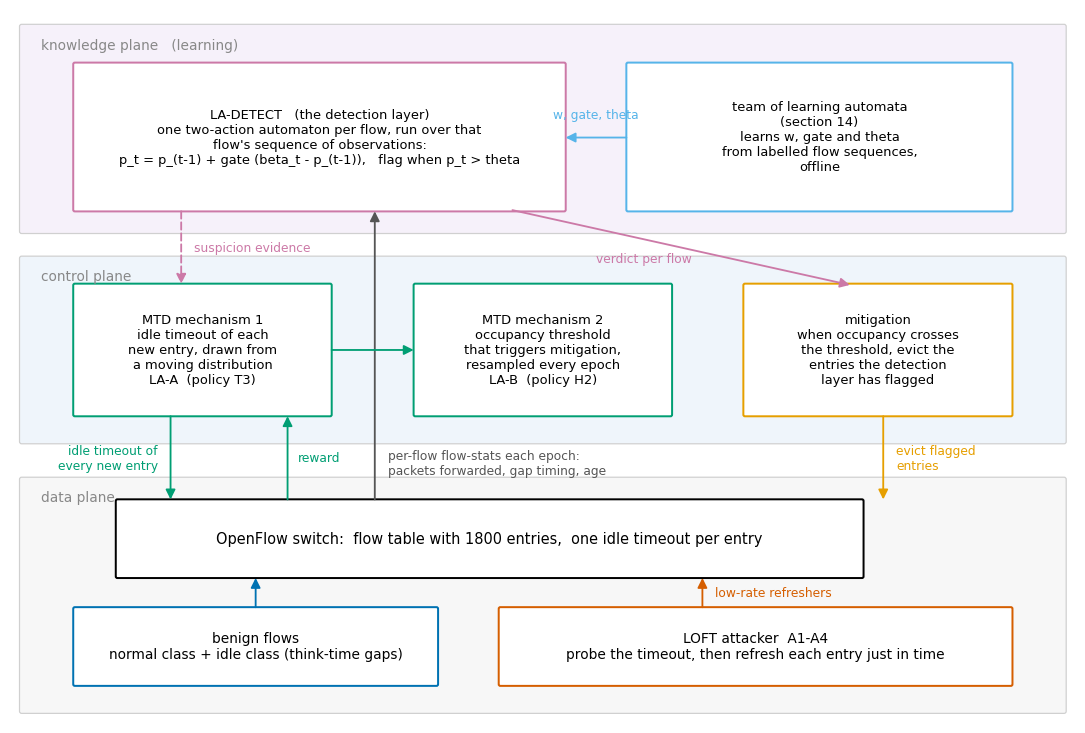

In [12]:
# --- the architecture this notebook simulates, drawn from the code above --- #
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _box(ax, x0, y0, x1, y1, text, edge, fs=9.5):
    ax.add_patch(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0, boxstyle="round,pad=0.015",
                                linewidth=1.3, facecolor="white", edgecolor=edge))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, text, ha="center", va="center", fontsize=fs)

def _arrow(ax, p0, p1, color="#555555", ls="-"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=13,
                                 linewidth=1.2, color=color, linestyle=ls, shrinkA=1, shrinkB=1))

_cap = (CFG if "CFG" in globals() else Config.default()).sim.capacity
fig, ax = plt.subplots(figsize=(10, 6.8))
ax.set_xlim(0, 10); ax.set_ylim(0, 6.6); ax.axis("off"); ax.grid(False)

# --- the three planes ----------------------------------------------------- #
for y0, y1, label, face in [(0.10, 2.25, "data plane", "#f7f7f7"),
                            (2.60, 4.30, "control plane", "#eff5fb"),
                            (4.55, 6.45, "knowledge plane   (learning)", "#f6f1fa")]:
    ax.add_patch(FancyBboxPatch((0.10, y0), 9.8, y1 - y0, boxstyle="round,pad=0.02",
                                linewidth=0.8, facecolor=face, edgecolor="#d0d0d0"))
    ax.text(0.28, y1 - 0.17, label, fontsize=9, color="#888888", ha="left", va="center")

# --- data plane ----------------------------------------------------------- #
_box(ax, 1.0, 1.35, 8.0, 2.05,
     f"OpenFlow switch:  flow table with {_cap} entries,  one idle timeout per entry", CB[7])
_box(ax, 0.6, 0.35, 4.0, 1.05, "benign flows\nnormal class + idle class (think-time gaps)", CB[0], fs=9)
_box(ax, 4.6, 0.35, 9.4, 1.05, "LOFT attacker  A1-A4\nprobe the timeout, then refresh each entry just in time", CB[3], fs=9)
_arrow(ax, (2.3, 1.05), (2.3, 1.35), CB[0])
_arrow(ax, (6.5, 1.05), (6.5, 1.35), CB[3])
ax.text(6.62, 1.20, "low-rate refreshers", fontsize=8, color=CB[3], ha="left", va="center")

# --- control plane -------------------------------------------------------- #
_box(ax, 0.6, 2.85, 3.0, 4.05,
     "MTD mechanism 1\nidle timeout of each\nnew entry, drawn from\na moving distribution\nLA-A  (policy T3)", CB[2], fs=8.5)
_box(ax, 3.8, 2.85, 6.2, 4.05,
     "MTD mechanism 2\noccupancy threshold\nthat triggers mitigation,\nresampled every epoch\nLA-B  (policy H2)", CB[2], fs=8.5)
_box(ax, 6.9, 2.85, 9.4, 4.05,
     "mitigation\nwhen occupancy crosses\nthe threshold, evict the\nentries the detection\nlayer has flagged", CB[1], fs=8.5)

# --- knowledge plane ------------------------------------------------------ #
_box(ax, 0.6, 4.75, 5.2, 6.10,
     "LA-DETECT   (the detection layer)\none two-action automaton per flow, run over that\n"
     "flow's sequence of observations:\n"
     "p_t = p_(t-1) + gate (beta_t - p_(t-1)),   flag when p_t > theta", CB[4], fs=8.5)
_box(ax, 5.8, 4.75, 9.4, 6.10,
     "team of learning automata\n(section 14)\nlearns w, gate and theta\nfrom labelled flow sequences,\noffline", CB[5], fs=8.5)
_arrow(ax, (5.8, 5.42), (5.2, 5.42), CB[5])
ax.text(5.5, 5.60, "w, gate, theta", fontsize=8, color=CB[5], ha="center")

# --- the loops that close the system -------------------------------------- #
_arrow(ax, (1.5, 2.85), (1.5, 2.05), CB[2])
ax.text(1.38, 2.45, "idle timeout of\nevery new entry", fontsize=8, color=CB[2], ha="right", va="center")
_arrow(ax, (2.6, 2.05), (2.6, 2.85), CB[2])
ax.text(2.70, 2.45, "reward", fontsize=8, color=CB[2], ha="left", va="center")
_arrow(ax, (3.42, 2.05), (3.42, 4.75))
ax.text(3.54, 2.40, "per-flow flow-stats each epoch:\npackets forwarded, gap timing, age",
        fontsize=8, color="#555555", ha="left", va="center")
_arrow(ax, (4.7, 4.75), (7.9, 4.05), CB[4])
ax.text(5.95, 4.26, "verdict per flow", fontsize=8, color=CB[4], ha="center")
_arrow(ax, (1.6, 4.75), (1.6, 4.05), CB[4], ls=(0, (4, 2)))
ax.text(1.72, 4.40, "suspicion evidence", fontsize=8, color=CB[4], ha="left", va="center")
_arrow(ax, (8.2, 2.85), (8.2, 2.05), CB[1])
ax.text(8.32, 2.45, "evict flagged\nentries", fontsize=8, color=CB[1], ha="left", va="center")
_arrow(ax, (3.0, 3.45), (3.8, 3.45), CB[2])
finish(fig, "fig01_architecture",
       "the two-layer defence as simulated: MTD in the control plane, LA-DETECT in the detection layer")


## 12. Automated validity checks — run them before trusting anything


A simulation is worth exactly as much as its validity. Ten **invariants** are
defined here: statements that must hold if the model corresponds to reality.
They are not unit tests of code paths — they are tests of simulation *behaviour*,
and a failure means the results below are not trustworthy.

| Check | Guarantees | A failure would mean |
|---|---|---|
| C1 | With no attacker the table stabilises below 70% | The benign generator or expiry logic is wrong |
| C2 | A fixed timeout is inferred within 5% | The RTT side-channel model is broken |
| C3 | Mutation degrades inference (disjoint CIs) | Mutation is not really reaching the entries |
| C4 | The attack succeeds undefended (>95%) | The attack model is too weak; every comparison is void |
| C5 | A2 evades a fixed threshold | The mitigation trigger is not wired correctly |
| C6 | Automaton invariants (p sums to 1, floor holds) | The automaton is broken |
| C7 | The predictability metric is calibrated | The new metric is not trustworthy |
| C8 | The same seed gives identical results | Unseeded randomness has leaked in |
| C9 | Conservation: installed − evicted − expired = held | Table bookkeeping is wrong |
| C10 | Monotonicity (higher rate must not lower occupancy) | A modelling error |

The cell below defines all ten, runs them, prints the result of each and
**asserts** they pass, so the notebook stops
here rather than presenting results built on a broken model. This is the answer
to "how do I know your simulation isn't wrong?" — and most published work in
this area has no answer to that question at all.


In [13]:
@dataclass
class SanityCheck:
    name: str
    passed: bool
    observed: str
    expected: str
    meaning: str
    cause: str = ""


def _inference_errors(policy_name: str, cfg: Config, algo, seeds) -> np.ndarray:
    errs = []
    for s in seeds:
        c = cfg.merged({"timeout": {"policy": policy_name}})
        rng = np.random.default_rng(4000 + int(s))
        pol = make_timeout_policy(c, rng)
        orc = ProbeOracle(c, pol, rng)
        inf, _ = algo.infer(orc)
        errs.append(abs(inf - c.timeout.fixed_s) / c.timeout.fixed_s)
    return np.array(errs)


# --------------------------------------------------------------------------- #
# Individual checks
# --------------------------------------------------------------------------- #
def check_c1(cfg: Config, seeds) -> SanityCheck:
    peaks = [run_config(cfg, s, with_attacker=False).peak_occ for s in seeds]
    peak = float(np.mean(peaks))
    ok = peak < 0.70 and max(peaks) < 1.0
    return SanityCheck(
        "C1_no_attack_stability", ok, f"mean peak occupancy={peak:.3f}",
        "< 0.70 and never full",
        "With no attacker the table must settle below 70% and never saturate.",
        "" if ok else "benign traffic generator over-produces or expiry logic is wrong",
    )


def check_c2(cfg: Config, seeds) -> SanityCheck:
    inc = _inference_errors("T0", cfg, IncrementalSearchProbe(), seeds)
    bina = _inference_errors("T0", cfg, BinarySearchProbe(), seeds)
    worst = max(float(np.mean(inc)), float(np.mean(bina)))
    ok = worst < 0.05
    return SanityCheck(
        "C2_fixed_timeout_inference", ok,
        f"incremental={np.mean(inc):.3f}, binary={np.mean(bina):.3f} (rel err)",
        "both < 0.05",
        "Against a fixed 10 s timeout both probes must recover it within 5%.",
        "" if ok else "the RTT side-channel model is broken; later inference results are meaningless",
    )


def check_c3(cfg: Config, seeds) -> SanityCheck:
    algo = BinarySearchProbe()
    t0 = _inference_errors("T0", cfg, algo, seeds)
    t1 = _inference_errors("T1", cfg, algo, seeds)
    t3 = _inference_errors("T3", cfg, algo, seeds)
    m0, c0 = mean_ci95(t0)
    m1, c1 = mean_ci95(t1)
    m3, c3 = mean_ci95(t3)
    ok = (m1 - c1) > (m0 + c0) and (m3 - c3) > (m0 + c0)
    return SanityCheck(
        "C3_mutation_degrades_inference", ok,
        f"T0={m0:.3f}±{c0:.3f}, T1={m1:.3f}±{c1:.3f}, T3={m3:.3f}±{c3:.3f}",
        "T1 and T3 error CIs strictly above T0",
        "Mutation must make inference significantly worse (non-overlapping 95% CIs).",
        "" if ok else "mutation is not really being applied per entry",
    )


def check_c4(cfg: Config, seeds) -> SanityCheck:
    # computed minimum viable rate to hold ~capacity entries at the fixed timeout
    ri = cfg.timeout.fixed_s * (1.0 - cfg.attacker.refresh_margin_frac)
    min_rate = cfg.sim.capacity / ri
    c = cfg.merged({"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
                    "detection": {"detector": "none"},
                    "attacker": {"kind": "A1", "rate_pps": 1.6 * min_rate,
                                 "target_entries": cfg.sim.capacity}})
    peaks = [run_config(c, s).peak_occ for s in seeds]
    peak = float(np.mean(peaks))
    ok = peak > 0.95
    return SanityCheck(
        "C4_attack_without_defense", ok,
        f"mean peak occupancy={peak:.3f} at rate={1.6*min_rate:.0f} pps",
        "> 0.95",
        "Undefended (T0+H0), A1 near its minimum viable rate must fill the table.",
        "" if ok else "the attack model is too weak; the whole comparison is invalid",
    )


def check_c5(cfg: Config, seeds) -> SanityCheck:
    c = cfg.merged({"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
                    "detection": {"detector": "simple"},
                    "attacker": {"kind": "A2", "rate_pps": 300,
                                 "target_entries": cfg.sim.capacity}})
    errs, occs = [], []
    thr = cfg.threshold.fixed
    for s in seeds:
        r = run_config(c, s)
        if np.isfinite(r.inferred_threshold):
            errs.append(abs(r.inferred_threshold - thr) / thr)
        occs.append(r.final_occ)
    err = float(np.mean(errs)) if errs else float("nan")
    occ = float(np.mean(occs))
    ok = np.isfinite(err) and err < 0.10 and (thr - 0.15) <= occ <= (thr + 0.03)
    return SanityCheck(
        "C5_threshold_evasion", ok,
        f"inferred-threshold err={err:.3f}, sustained occupancy={occ:.3f} (true thr={thr})",
        "err < 0.10 and occupancy parked just below threshold",
        "A2 must infer a fixed threshold and sit just under it without triggering mitigation.",
        "" if ok else "the mitigation trigger is not wired correctly",
    )


def check_c6(cfg: Config, seeds) -> SanityCheck:
    c = cfg.merged({"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                    "detection": {"detector": "simple"},
                    "attacker": {"kind": "A1", "rate_pps": 300}})
    hmin_a = cfg.automaton.h_min_frac * np.log(len(cfg.timeout.la_candidates_s))
    hmin_b = cfg.automaton.h_min_frac * np.log(len(cfg.threshold.la_candidates))
    bad = 0
    worst_sum = 0.0
    worst_floor = np.inf
    for s in seeds:
        r = run_config(c, s)
        for p in r.la_a_p:
            worst_sum = max(worst_sum, abs(float(p.sum()) - 1.0))
            if (p < -1e-12).any():
                bad += 1
        for h in r.la_a_entropy:
            worst_floor = min(worst_floor, h - hmin_a)
        for h in r.la_b_entropy:
            worst_floor = min(worst_floor, h - hmin_b)
    ok = worst_sum < 1e-9 and bad == 0 and worst_floor >= -1e-9
    return SanityCheck(
        "C6_automaton_invariants", ok,
        f"max|sum(p)-1|={worst_sum:.1e}, neg-entries={bad}, min(H-Hmin)={worst_floor:.3f}",
        "sum=1 (<1e-9), no negatives, H>=Hmin",
        "The automaton must stay a valid distribution and never breach the entropy floor.",
        "" if ok else "LA update or entropy-floor enforcement is wrong",
    )


def check_c7(cfg: Config, seeds) -> SanityCheck:
    const = [7.0] * 200
    rng = np.random.default_rng(99)
    unif = rng.uniform(2, 20, 400).tolist()
    sc_const = predictability_score(const, cfg).score
    sc_unif = predictability_score(unif, cfg).score
    ok = abs(sc_const - 1.0) < 0.05 and sc_unif < 0.10
    return SanityCheck(
        "C7_predictability_calibration", ok,
        f"constant={sc_const:.3f}, uniform-random={sc_unif:.3f}",
        "constant ~1.0, uniform < 0.10",
        "The PredictabilityScore must read 1 for a constant and ~0 for noise.",
        "" if ok else "the predictability metric is not trustworthy and must not be reported",
    )


def check_c8(cfg: Config, seeds) -> SanityCheck:
    c = cfg.merged({"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                    "detection": {"detector": "la_detect"},
                    "attacker": {"kind": "A4", "rate_pps": 250}})
    a = run_config(c, 123)
    b = run_config(c, 123)
    ok = (a.occ == b.occ and a.timeout_seq == b.timeout_seq
          and a.installs == b.installs and a.threshold_seq == b.threshold_seq)
    return SanityCheck(
        "C8_determinism", ok,
        f"identical={ok}",
        "byte-identical result frames",
        "The same seed must reproduce identical results.",
        "" if ok else "unseeded randomness has leaked in",
    )


def check_c9(cfg: Config, seeds) -> SanityCheck:
    c = cfg.merged({"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                    "detection": {"detector": "simple"},
                    "attacker": {"kind": "A4", "rate_pps": 400}})
    viol = 0
    for s in list(seeds)[:3]:
        sim = Simulator(c, int(s), check_conservation=True)
        sim.run()
        viol += sim.conservation_violations
    ok = viol == 0
    return SanityCheck(
        "C9_conservation", ok,
        f"per-step conservation violations={viol}",
        "0",
        "installed - evicted - expired must equal entries held, every step.",
        "" if ok else "table bookkeeping is wrong",
    )


def check_c10(cfg: Config, seeds) -> SanityCheck:
    # (a) peak occupancy non-decreasing in attack rate
    base = {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
            "detection": {"detector": "none"}, "attacker": {"kind": "A1"}}
    rates = [40, 80, 160, 320]
    peaks = []
    for rt in rates:
        c = cfg.merged({**base, "attacker": {"kind": "A1", "rate_pps": rt}})
        peaks.append(float(np.mean([run_config(c, s).peak_occ for s in list(seeds)[:6]])))
    mono_rate = all(peaks[i + 1] >= peaks[i] - 0.03 for i in range(len(peaks) - 1))
    # (b) larger capacity must not increase attacker success at fixed rate
    caps = [800, 1500, 3000]
    succ = []
    for cp in caps:
        c = cfg.merged({**base, "sim": {"capacity": cp},
                        "attacker": {"kind": "A1", "rate_pps": 160,
                                     "target_entries": cp}})
        succ.append(float(np.mean([run_config(c, s).peak_occ for s in list(seeds)[:6]])))
    mono_cap = all(succ[i + 1] <= succ[i] + 0.03 for i in range(len(succ) - 1))
    ok = mono_rate and mono_cap
    return SanityCheck(
        "C10_monotonicity", ok,
        f"peak vs rate={['%.2f' % p for p in peaks]}, peak vs capacity={['%.2f' % p for p in succ]}",
        "peak non-decreasing in rate; non-increasing in capacity",
        "Higher attack rate can't reduce peak occupancy; more capacity can't help the attacker.",
        "" if ok else "a modelling error in fill or capacity handling",
    )


CHECKS: List[Callable[[Config, list], SanityCheck]] = [
    check_c1, check_c2, check_c3, check_c4, check_c5,
    check_c6, check_c7, check_c8, check_c9, check_c10,
]


def run_all_checks(cfg: Config, n_seeds: int = 12) -> List[SanityCheck]:
    seeds = list(range(1, n_seeds + 1))
    results = []
    for chk in CHECKS:
        results.append(chk(cfg, seeds))
    return results


# ---- run all ten, show them, and refuse to continue if any fails ---------- #
_t0 = time.time()
CHECK_RESULTS = run_all_checks(Config.default())
print(f"{'check':32s} {'result':6s}  observed")
print("-" * 100)
for c in CHECK_RESULTS:
    print(f"{c.name:32s} {'PASS' if c.passed else 'FAIL':6s}  {c.observed}")
print(f"\n{sum(c.passed for c in CHECK_RESULTS)}/{len(CHECK_RESULTS)} passed "
      f"in {time.time() - _t0:.0f} s")
_failed = [c for c in CHECK_RESULTS if not c.passed]
assert not _failed, ("validity check failed -- results below are not trustworthy: "
                     + "; ".join(f"{c.name}: {c.cause}" for c in _failed))


check                            result  observed
----------------------------------------------------------------------------------------------------
C1_no_attack_stability           PASS    mean peak occupancy=0.436
C2_fixed_timeout_inference       PASS    incremental=0.000, binary=0.006 (rel err)
C3_mutation_degrades_inference   PASS    T0=0.006±0.000, T1=0.287±0.100, T3=0.303±0.103
C4_attack_without_defense        PASS    mean peak occupancy=1.000 at rate=320 pps
C5_threshold_evasion             PASS    inferred-threshold err=0.024, sustained occupancy=0.705 (true thr=0.8)
C6_automaton_invariants          PASS    max|sum(p)-1|=2.2e-16, neg-entries=0, min(H-Hmin)=0.004
C7_predictability_calibration    PASS    constant=1.000, uniform-random=0.019
C8_determinism                   PASS    identical=True
C9_conservation                  PASS    per-step conservation violations=0
C10_monotonicity                 PASS    peak vs rate=['0.64', '0.84', '1.00', '1.00'], peak vs capacity=['1.

## 13. Experiment harness


Three helpers every experiment below uses.

`SWEEP` is the coarse profile: rate searches need many runs, so they use a 10 ms
step. The horizon comes from the config (60 s), **not** hard-coded, and it must
comfortably exceed the largest candidate timeout (20 s): with a horizon shorter
than the candidates, long-timeout entries never expire inside a run and half the
candidate set becomes indistinguishable.

`min_attack_rate` is the headline metric: the slowest attack rate that still
reaches 95% occupancy. Higher is better for the defender. It is read by
interpolating each seed's peak-occupancy-versus-rate curve, and the grid is
extended upward for cells that would otherwise be right-censored — because a
censored value is a lower bound, not an estimate, and averaging censored values
silently makes strong defences look identical.


In [14]:
RATE_GRID     = [40.0, 110.0, 210.0, 360.0, 550.0]
RATE_GRID_EXT = [800.0, 1200.0, 1800.0]

def sweep_cfg(cfg):
    """Coarse profile for rate-search experiments; horizon comes from cfg."""
    return cfg.merged({"sim": {"dt_ms": cfg.experiment.sweep_dt_ms,
                               "horizon_s": cfg.experiment.sweep_horizon_s}})

def peak_at(over, seed, cfg_exp, rate):
    return run_config(cfg_exp.merged(over).merged(
        {"attacker": {"rate_pps": rate}}), seed).peak_occ

def min_attack_rate(over, seed, cfg_exp, target=0.95):
    """Slowest attack rate reaching `target` occupancy. Returns (rate, censored)."""
    rates = list(RATE_GRID)
    peaks = [peak_at(over, seed, cfg_exp, r) for r in rates]
    for r in RATE_GRID_EXT:                 # only paid for by strong defences
        if peaks[-1] >= target:
            break
        rates.append(r); peaks.append(peak_at(over, seed, cfg_exp, r))
    censored = peaks[-1] < target
    if peaks[0] >= target:
        return float(rates[0]), censored
    for i in range(1, len(rates)):
        if peaks[i] >= target:
            p0, p1 = peaks[i-1], peaks[i]; r0, r1 = rates[i-1], rates[i]
            if p1 == p0:
                return float(r1), censored
            return float(r0 + (target - p0) * (r1 - r0) / (p1 - p0)), censored
    return float(rates[-1]), censored

def _call(job):
    fn, args = job
    return fn(*args)

def pmap(fn, arg_tuples):
    """fn(*args) for every tuple, in order, spread over N_WORKERS cores.

    Uses fork-based worker processes (Linux, Colab).  If that is not available
    (e.g. Windows) it silently runs the same calls one after another, so the
    results never depend on whether it ran in parallel.
    """
    import multiprocessing as _mp       # local import: a notebook variable named `mp` cannot break it
    jobs = [(fn, tuple(a)) for a in arg_tuples]
    if N_WORKERS > 1 and len(jobs) > 1:
        try:
            with _mp.get_context("fork").Pool(min(N_WORKERS, len(jobs))) as pool:
                return pool.map(_call, jobs)
        except Exception as exc:
            global _PMAP_WARNED
            if not globals().get("_PMAP_WARNED"):
                print(f"[pmap] running on one core ({type(exc).__name__}: {exc})")
                _PMAP_WARNED = True
    return [_call(j) for j in jobs]

def arm_stats(over, cfg_exp, seeds=None, ref_rate=300.0):
    """Security AND cost for one configuration, averaged over seeds.

    Also returns the per-seed values, so two policies run on the same seeds can
    be compared seed by seed (a paired comparison)."""
    seeds = [int(s) for s in (seeds or SEEDS)]
    mc = pmap(min_attack_rate, [(over, s, cfg_exp) for s in seeds])
    mins, cens = [m for m, _ in mc], [c for _, c in mc]
    run_cfg = cfg_exp.merged(over).merged({"attacker": {"rate_pps": ref_rate}})
    runs = pmap(run_config, [(run_cfg, s) for s in seeds])
    quiet = pmap(run_config, [(cfg_exp.merged(over), s, False) for s in seeds])
    m, ci = mean_ci95(np.array(mins))
    return {"min_attack_rate": m, "ci95": ci, "censored": float(np.mean(cens)),
            "benign_expired": float(np.mean([q.benign_expired for q in quiet])),
            "packet_ins_per_s": float(np.mean([q.packet_ins for q in quiet]))
                                / cfg_exp.sim.horizon_s,
            "benign_evict_rate": float(np.mean([r.benign_eviction_rate for r in runs])),
            "peak_occ": float(np.mean([r.peak_occ for r in runs])),
            "per_seed_rate": np.array(mins),
            "per_seed_expired": np.array([q.benign_expired for q in quiet], dtype=float)}

CFG  = Config.default()
CFGS = sweep_cfg(CFG)
print(f"sweep profile: dt={CFGS.sim.dt_ms} ms, horizon={CFGS.sim.horizon_s} s, "
      f"capacity={CFGS.sim.capacity}")
print(f"largest candidate timeout = {max(CFG.timeout.la_candidates_s)} s "
      f"-> {CFGS.sim.horizon_s/max(CFG.timeout.la_candidates_s):.1f} timeout cycles per run")

# ---- helpers for the "Reading the result" cells --------------------------- #
def say(*paragraphs):
    """Render interpretation text (written from the results) as Markdown."""
    display(Markdown("\n\n".join(p for p in paragraphs if p)))

def overlaps(m1, c1, m2, c2):
    """True when two mean +/- half-width intervals overlap."""
    return abs(m1 - m2) <= (c1 + c2)

def md_table(header, rows):
    """A markdown table, rendered by the notebook."""
    out = ["| " + " | ".join(map(str, header)) + " |", "|" + "---|" * len(header)]
    return "\n".join(out + ["| " + " | ".join(str(c) for c in r) + " |" for r in rows])

def paired(a, b):
    """Mean and 95% CI of the per-seed difference a - b (same seeds, same order)."""
    return mean_ci95(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))


sweep profile: dt=10.0 ms, horizon=60.0 s, capacity=1800
largest candidate timeout = 20 s -> 3.0 timeout cycles per run


## 14. Training LA-DETECT: a learning automaton in the GRU's position and role

**Where the GRU sits in the literature.** In the GRU–CatBoost detector for
low-rate flow-table attacks in Knowledge-Defined Networking (Bahrami and Haj
Seyyed Javadi, *MCA* 31(4):117, 2026), the GRU sits in the **hybrid detection
layer** of the knowledge plane. Each flow becomes a sequence of feature vectors
over a time window, `S_k = [x_k,1, ..., x_k,l]` (packet-in frequency,
inter-arrival time, byte count, timeout duration, ...). The GRU reads that
sequence and turns it into an embedding `h_k`, a compact temporal summary, and
CatBoost makes the final call on `[h_k, c_k]`. The GRU is trained offline on
labelled flows (about 350,000 of them). FloRa (Mudgal et al., IEEE TNSM 2024)
uses no GRU: it is a feature-based CatBoost classifier.

**The same position and role here.** LA-DETECT is not a GRU and does not copy
its internals. It is a learning automaton that takes the GRU's **position** in
the pipeline and plays the GRU's **role** there:

| | GRU–CatBoost paper | this notebook |
|---|---|---|
| layer | hybrid detection layer (knowledge plane) | detection layer of the controller |
| input | flow statistics collected through the controller, as a per-flow sequence | `FlowTelemetry`: packets per epoch and inter-arrival regularity, polled every epoch, as a per-flow sequence |
| role | reads each flow's sequence and builds a compact temporal summary | a per-flow automaton reads each flow's sequence; its state `p_t` is the temporal summary |
| final call | CatBoost decides on the summary | the flow is flagged when `p_t > theta`, and mitigation evicts it |
| how it gets good | trained on labelled flows | its parameters are learned by a team of learning automata on labelled flow sequences |

**How the team learns.** Each of the five parameters is chosen by its own
pursuit automaton (Thathachar and Sastry) from a small set of values. In every
round, each member picks a value, the resulting detector is run over a random
batch of labelled flow sequences, and every member receives the same reward:
the balanced accuracy of the detector the team just built (a common-payoff
game of automata). A member's probability moves toward the value whose
running reward estimate is highest. A team converges to a local optimum of this
game, so it is trained from several independent starts, and the start with the
best balanced accuracy on the training set is kept. The validation set is
never used to choose.

**Why an automaton in that position.** The GRU is a trained network: in the
published detector it carries on the order of tens of thousands of weights (two
layers of 64 and 32 units over 24 features), is trained for 50 epochs with Adam,
and feeds a 500-tree gradient-boosted classifier. LA-DETECT keeps the same
position and the same job with five learned numbers and one float of state per
live flow, updated with one multiply-add per flow per epoch, on the controller's
own CPU. §20 measures what that costs in accuracy and what it saves in compute.
What this notebook does **not** do is train a GRU on these same sequences, so
the comparison with the published numbers is context, not a head-to-head.

**Data.** Labelled sequences are recorded from simulation runs under a classic
attack (A1) against a fixed (T0) and a uniformly mutating (T1) timeout, on seeds
kept apart from every seed the evaluation uses. A validation set comes from two
more unseen seeds. The attackers A2 to A4 are never seen in training, so
section 23 is a test of generalisation.

**Why the old LA-DETECT did not fill this slot.** It was in the detection layer,
per flow, but it read static features: each flow's regularity was handed to it
directly and never changed, so there was no sequence to summarise. Its weights
were also set by hand, so nothing was learned. Its automaton added +0.003 F1.
Now the latent regularity is hidden behind noisy telemetry, and every
parameter of the automaton is learned.

Two things to check below: whether the learned detector beats the hand-set
one on unseen validation seeds, and how close the team gets to an exhaustive
search over the same parameter grid.


training set  :  35138 flow sequences (31% attacker),  626207 labelled flow-epochs
validation set:  23227 flow sequences (30% attacker),  417599 labelled flow-epochs  (unseen seeds)


**The labelled dataset this section trains on**

| property | value |
|---|---|
| source | the simulator of section 11, 2 configurations (attacker A1 at 300 pps against timeout policies T0 and T1, threshold H0) |
| runs | 6 training runs on seeds [900001, 900002, 900003], 4 validation runs on seeds [900011, 900012] -- disjoint from the 32 evaluation seeds |
| flow sequences | 35,138 training, 23,227 validation |
| labelled flow-epochs | 626,207 training, 417,599 validation |
| class balance | 30.7% attacker flows (training), 29.9% (validation) |
| observation per flow-epoch | 3 features in [0, 1]: low forwarding this epoch, gap regularity of the inter-arrival times, entry age |
| sequence length | up to 60 epochs of 1 s (a 60 s run), one observation per epoch per entry |
| labels | the owner of the entry, used only to train and to score -- never as a feature |
| table under attack | 1800 entries, benign arrivals 70 flows/s |


8 independent team runs (6000 rounds each), trained in 65 s:
 start  la_w_low  la_w_reg  la_w_age  la_gate  la_theta  train balanced acc
     0       1.0      0.25      0.25     0.50      0.60               0.890
     1       1.0      0.00      0.25     0.50      0.60               0.895
     2       1.0      0.25      0.25     0.10      0.55               0.893
     3       1.0      0.00      0.25     0.50      0.65               0.908
     4       1.0      0.50      0.50     1.00      0.60               0.895
     5       1.0      0.00      0.25     0.35      0.55               0.876
     6       1.0      0.25      0.50     0.35      0.55               0.900
     7       1.0      0.00      0.25     0.50      0.65               0.908
kept start 3: {'la_w_low': 1.0, 'la_w_reg': 0.0, 'la_w_age': 0.25, 'la_gate': 0.5, 'la_theta': 0.65}



Offline, on whole sequences (no mitigation):
                       detector      split  accuracy  precision  recall  specificity   fpr    f1  balanced_acc   mcc
score (hand weights, no memory)      train     0.851      0.809     1.0        0.597 0.403 0.894         0.799 0.695
score (hand weights, no memory) validation     0.852      0.810     1.0        0.601 0.399 0.895         0.801 0.698
la_hand (hand weights + memory)      train     0.849      0.807     1.0        0.591 0.409 0.893         0.795 0.690
la_hand (hand weights + memory) validation     0.850      0.808     1.0        0.596 0.404 0.894         0.798 0.693
la_detect (learned by the team)      train     0.932      0.903     1.0        0.817 0.183 0.949         0.908 0.858
la_detect (learned by the team) validation     0.932      0.903     1.0        0.818 0.182 0.949         0.909 0.859



Exhaustive search over all 6696 combinations (same objective, 3000 training flows): best balanced accuracy 0.913 at (1.0, 0.25, 0.25, 1.0, 0.75); the team reached 0.906 while trying 6000 of them, one per round.
Best balanced accuracy for each memory gate (1.0 = no memory): 0.05: 0.912, 0.1: 0.911, 0.2: 0.909, 0.35: 0.910, 0.5: 0.912, 1: 0.913

CFG and CFGS now carry the learned LA-DETECT parameters (la_trained=True); every later section uses them.


[figures/fig02_training_and_validation.png]  LA-DETECT training: the team's reward, and its leading values scored on training and validation flows


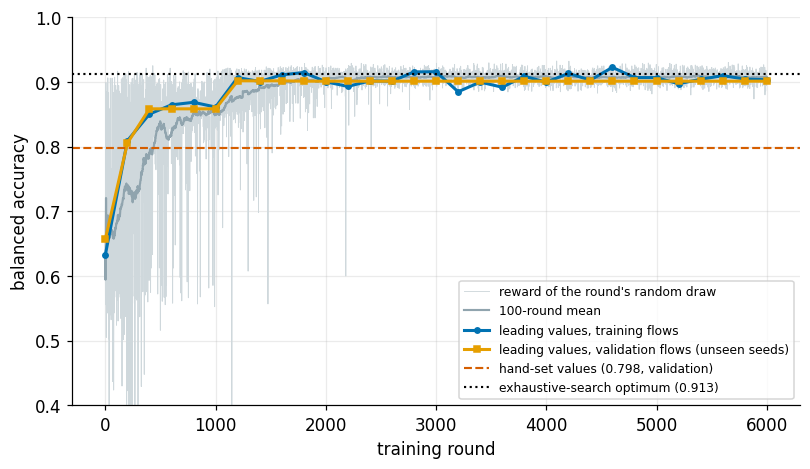

[figures/fig03_team_convergence.png]  LA-DETECT training: convergence of each team member


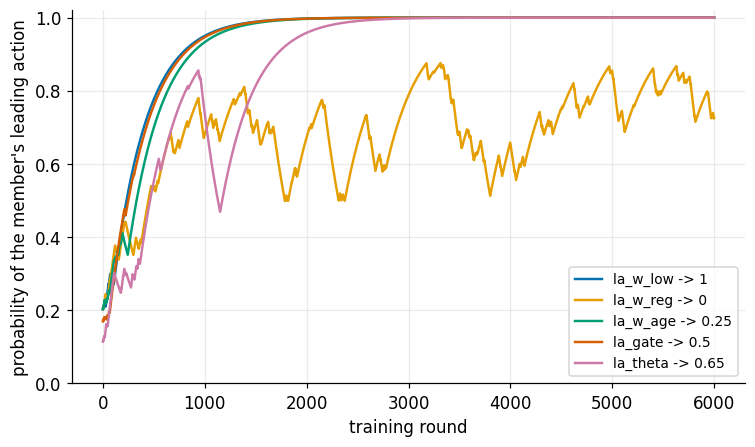

In [15]:
# --- 1. a labelled dataset of flow sequences (the counterpart of the paper's ~350k flows)
class TraceRecorder(Detector):
    """Records every polled entry's observation, epoch by epoch, with its label.

    Flags nothing, so no flow is cut short by mitigation.  The label (who owns
    the entry) is ground truth used ONLY to build the training set, exactly as
    a labelled dataset is used to train the GRU."""

    name = "trace"
    uses_telemetry = True

    def __init__(self, cfg):
        self.rows, self.t, self.y, self.X = [], [], [], []
        self._k = 0

    def epoch_update(self, cfg, table, now):
        tel = table.telemetry
        if tel.rows.size:
            self.rows.append(tel.rows.copy())
            self.t.append(np.full(tel.rows.size, self._k))
            self.y.append(table.owner[tel.slots].astype(np.int8))
            self.X.append(evidence_features(cfg, table, now))
        self._k += 1

    def arrays(self):
        return (np.concatenate(self.rows), np.concatenate(self.t),
                np.concatenate(self.y), np.vstack(self.X), self._k)


def collect_trace(cfg, seed):
    sim = Simulator(cfg, seed, detector_factory=TraceRecorder)
    sim.run()
    return sim.detector.arrays()


def to_sequences(traces):
    """Stack traces into padded tensors: X [flows, T, 3], M [flows, T], y [flows]."""
    Xs, Ms, ys = [], [], []
    for rows, t, y, X, T in traces:
        n = rows.max() + 1
        Xt = np.zeros((n, T, 3)); Mt = np.zeros((n, T), dtype=bool); yt = np.zeros(n, dtype=np.int8)
        Xt[rows, t] = X; Mt[rows, t] = True; yt[rows] = y
        keep = Mt.any(axis=1)
        Xs.append(Xt[keep]); Ms.append(Mt[keep]); ys.append(yt[keep])
    T = max(x.shape[1] for x in Xs)
    pad = lambda a, fill: np.pad(a, [(0, 0), (0, T - a.shape[1])] + [(0, 0)] * (a.ndim - 2),
                                 constant_values=fill)
    return (np.concatenate([pad(x, 0.0) for x in Xs]),
            np.concatenate([pad(m, False) for m in Ms]), np.concatenate(ys))


def run_recurrent(X, M, y, w, gate, theta):
    """Run the per-flow automaton over whole sequences; flow-epoch confusion counts."""
    beta = evidence_score(X.reshape(-1, 3), w).reshape(M.shape)
    yb = y.astype(bool)
    p = np.full(M.shape[0], 0.5)
    tp = fp = fn = tn = 0
    for t in range(M.shape[1]):
        m = M[:, t]
        if not m.any():
            continue
        p = np.where(m, p + gate * (beta[:, t] - p), p)
        pred = p > theta
        tp += np.count_nonzero(m & pred & yb);  fp += np.count_nonzero(m & pred & ~yb)
        fn += np.count_nonzero(m & ~pred & yb); tn += np.count_nonzero(m & ~pred & ~yb)
    return tp, fp, fn, tn


def detection_metrics(tp, fp, fn, tn):
    """Everything the detection papers report, from one confusion matrix."""
    tp, fp, fn, tn = (float(v) for v in (tp, fp, fn, tn))
    n = tp + fp + fn + tn
    prec = tp / (tp + fp) if tp + fp else float("nan")
    rec = tp / (tp + fn) if tp + fn else float("nan")
    spec = tn / (tn + fp) if tn + fp else float("nan")
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float("nan")
    den = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return {"accuracy": (tp + tn) / n if n else float("nan"), "precision": prec,
            "recall": rec, "specificity": spec, "fpr": 1 - spec, "f1": f1,
            "balanced_acc": 0.5 * (rec + spec),
            "mcc": (tp * tn - fp * fn) / den if den else float("nan")}


def seq_metrics(X, M, y, w, gate, theta):
    return detection_metrics(*run_recurrent(X, M, y, w, gate, theta))


# --- 2. the team of automata that learns LA-DETECT's parameters ----------- #
class PursuitAutomaton:
    """Estimator (pursuit) automaton, Thathachar & Sastry: p moves toward the
    action whose running reward estimate is currently the highest."""

    def __init__(self, values, rate, rng, alpha=0.05):
        self.values = list(values)
        self.p = np.full(len(values), 1.0 / len(values))
        self.est = np.full(len(values), 0.5)
        self.seen = np.zeros(len(values))
        self.rate, self.alpha, self.rng = rate, alpha, rng
        self.last = 0

    def choose(self):
        self.last = int(self.rng.choice(len(self.p), p=self.p))
        return self.values[self.last]

    def learn(self, reward):
        i = self.last
        self.seen[i] += 1
        a = max(self.alpha, 1.0 / self.seen[i])            # plain mean first, then recency
        self.est[i] += a * (reward - self.est[i])
        best = np.zeros_like(self.p); best[int(np.argmax(self.est))] = 1.0
        self.p += self.rate * (best - self.p)
        self.p /= self.p.sum()

    def value(self):
        return self.values[int(np.argmax(self.p))]


TEAM_SPACE = {
    "la_w_low": [0.0, 0.25, 0.5, 0.75, 1.0],
    "la_w_reg": [0.0, 0.25, 0.5, 0.75, 1.0],
    "la_w_age": [0.0, 0.25, 0.5, 0.75, 1.0],
    "la_gate":  [0.05, 0.1, 0.2, 0.35, 0.5, 1.0],       # 1.0 = no memory at all
    "la_theta": [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80],
}


def train_team(X, M, y, val=None, iters=6000, batch=1024, rate=0.003, seed=0, eval_every=200):
    """Common-payoff game: every member is rewarded with the balanced accuracy
    the whole team's detector achieves on a random batch of labelled flows.

    Every ``eval_every`` rounds the team's current leading values are scored on
    the held-out validation flows, which is the training-versus-validation
    curve every detection paper shows."""
    rng = np.random.default_rng(seed)
    team = {k: PursuitAutomaton(v, rate, rng) for k, v in TEAM_SPACE.items()}
    curve, val_curve = [], []
    for it in range(iters):
        pick = {k: a.choose() for k, a in team.items()}
        idx = rng.choice(len(y), size=min(batch, len(y)), replace=False)
        w = (pick["la_w_low"], pick["la_w_reg"], pick["la_w_age"])
        r = 0.0 if sum(w) == 0 else seq_metrics(X[idx], M[idx], y[idx], w, pick["la_gate"],
                                                pick["la_theta"])["balanced_acc"]
        r = 0.0 if not np.isfinite(r) else r
        for a in team.values():
            a.learn(r)
        curve.append((it, r, *(float(a.p.max()) for a in team.values())))
        if val is not None and (it % eval_every == 0 or it == iters - 1):
            lead = {k: a.value() for k, a in team.items()}
            wv = (lead["la_w_low"], lead["la_w_reg"], lead["la_w_age"])
            tr_s = seq_metrics(X[idx], M[idx], y[idx], wv, lead["la_gate"], lead["la_theta"])
            va_s = seq_metrics(*val, wv, lead["la_gate"], lead["la_theta"])
            val_curve.append({"iter": it, "train": tr_s["balanced_acc"],
                              "validation": va_s["balanced_acc"]})
    learned = {k: float(a.value()) for k, a in team.items()}
    return (learned,
            pd.DataFrame(curve, columns=["iter", "reward"] + [f"maxp {k}" for k in team]),
            pd.DataFrame(val_curve), team)


# --- 3. train on labelled runs, validate on unseen seeds, hand the result on -
TRAIN_SEEDS = [900_001, 900_002, 900_003]      # disjoint from SEEDS and from DIAG_SEEDS
VAL_SEEDS   = [900_011, 900_012]
TRAIN_CFGS = [CFGS.merged({"timeout": {"policy": p}, "threshold": {"policy": "H0"},
                           "attacker": {"kind": "A1", "rate_pps": 300,
                                        "target_entries": CFG.sim.capacity}})
              for p in ("T0", "T1")]
t0 = time.time()
tr = pmap(collect_trace, [(c, s) for c in TRAIN_CFGS for s in TRAIN_SEEDS])
va = pmap(collect_trace, [(c, s) for c in TRAIN_CFGS for s in VAL_SEEDS])
Xtr, Mtr, ytr = to_sequences(tr)
Xva, Mva, yva = to_sequences(va)
print(f"training set  : {len(ytr):6d} flow sequences ({ytr.mean():.0%} attacker), "
      f"{Mtr.sum():7d} labelled flow-epochs")
print(f"validation set: {len(yva):6d} flow sequences ({yva.mean():.0%} attacker), "
      f"{Mva.sum():7d} labelled flow-epochs  (unseen seeds)")

display(Markdown("\n".join(["**The labelled dataset this section trains on**", "", md_table(
    ["property", "value"],
    [["source", f"the simulator of section 11, {len(TRAIN_CFGS)} configurations "
                f"(attacker A1 at 300 pps against timeout policies T0 and T1, threshold H0)"],
     ["runs", f"{len(tr)} training runs on seeds {TRAIN_SEEDS}, {len(va)} validation runs on "
              f"seeds {VAL_SEEDS} -- disjoint from the {len(SEEDS)} evaluation seeds"],
     ["flow sequences", f"{len(ytr):,} training, {len(yva):,} validation"],
     ["labelled flow-epochs", f"{int(Mtr.sum()):,} training, {int(Mva.sum()):,} validation"],
     ["class balance", f"{ytr.mean():.1%} attacker flows (training), {yva.mean():.1%} (validation)"],
     ["observation per flow-epoch", "3 features in [0, 1]: low forwarding this epoch, gap "
      "regularity of the inter-arrival times, entry age"],
     ["sequence length", f"up to {Mtr.shape[1]} epochs of {CFG.threshold.epoch_s:g} s "
                         f"(a {CFGS.sim.horizon_s:.0f} s run), one observation per epoch per entry"],
     ["labels", "the owner of the entry, used only to train and to score -- never as a feature"],
     ["table under attack", f"{CFG.sim.capacity} entries, benign arrivals "
                            f"{CFG.benign.arrival_fps:g} flows/s"]])])))

# A team of automata converges to A local optimum of the common-payoff game, so it
# is trained from several independent starts and the start with the highest
# balanced accuracy on the TRAINING set is kept (validation is never consulted).
N_STARTS = 8
_VAL_SUB = np.random.default_rng(5).choice(len(yva), min(6000, len(yva)), replace=False)
VAL_EVAL = (Xva[_VAL_SUB], Mva[_VAL_SUB], yva[_VAL_SUB])
def _one_start(seed):
    return train_team(Xtr, Mtr, ytr, val=VAL_EVAL, seed=seed)[:3]
_starts = pmap(_one_start, [(BASE_SEED + k,) for k in range(N_STARTS)])
_train_score = lambda L: seq_metrics(Xtr, Mtr, ytr, (L["la_w_low"], L["la_w_reg"], L["la_w_age"]),
                                     L["la_gate"], L["la_theta"])["balanced_acc"]
start_df = pd.DataFrame([{"start": k, **L, "train balanced acc": _train_score(L)}
                         for k, (L, _, _) in enumerate(_starts)])
_best = int(start_df["train balanced acc"].idxmax())
LEARNED, team_curve, val_curve = _starts[_best]
TRAIN_SECONDS = time.time() - t0
print(f"\n{N_STARTS} independent team runs ({len(team_curve)} rounds each), "
      f"trained in {TRAIN_SECONDS:.0f} s:")
print(start_df.round(3).to_string(index=False))
print(f"kept start {_best}: {LEARNED}")

d0 = CFG.detection
HAND = {"weights": (d0.w_low_forward, d0.w_regularity, d0.w_longevity), "gate": d0.la_detect_a, "theta": 0.5}
VARIANTS = {
    "score (hand weights, no memory)": (HAND["weights"], 1.0, 0.5),
    "la_hand (hand weights + memory)": (HAND["weights"], HAND["gate"], HAND["theta"]),
    "la_detect (learned by the team)": ((LEARNED["la_w_low"], LEARNED["la_w_reg"], LEARNED["la_w_age"]),
                                        LEARNED["la_gate"], LEARNED["la_theta"]),
}
rows = []
for name, (w, g, th) in VARIANTS.items():
    for split, (X_, M_, y_) in (("train", (Xtr, Mtr, ytr)), ("validation", (Xva, Mva, yva))):
        rows.append({"detector": name, "split": split, **seq_metrics(X_, M_, y_, w, g, th)})
team_eval = pd.DataFrame(rows)
print("\nOffline, on whole sequences (no mitigation):")
print(team_eval.round(3).to_string(index=False))

# --- 4. how close did the team get?  exhaustive search over the same space - #
import itertools
_sub = np.random.default_rng(1).choice(len(ytr), min(3000, len(ytr)), replace=False)
_grid = []
for wl, wr, wa, g, th in itertools.product(*TEAM_SPACE.values()):
    if wl + wr + wa > 0:
        _grid.append((seq_metrics(Xtr[_sub], Mtr[_sub], ytr[_sub], (wl, wr, wa), g, th)["balanced_acc"],
                      (wl, wr, wa, g, th)))
grid_best, grid_arg = max(_grid)
team_on_sub = seq_metrics(Xtr[_sub], Mtr[_sub], ytr[_sub],
                          (LEARNED["la_w_low"], LEARNED["la_w_reg"], LEARNED["la_w_age"]),
                          LEARNED["la_gate"], LEARNED["la_theta"])["balanced_acc"]
grid_by_gate = {g: max(v for v, a in _grid if a[3] == g) for g in TEAM_SPACE["la_gate"]}
print(f"\nExhaustive search over all {len(_grid)} combinations (same objective, "
      f"{len(_sub)} training flows): best balanced accuracy {grid_best:.3f} at {grid_arg}; "
      f"the team reached {team_on_sub:.3f} while trying {len(team_curve)} of them, one per round.")
print("Best balanced accuracy for each memory gate (1.0 = no memory): "
      + ", ".join(f"{g:g}: {v:.3f}" for g, v in grid_by_gate.items()))

CFG = CFG.merged({"detection": {**LEARNED, "la_trained": True}})
CFGS = sweep_cfg(CFG)
print(f"\nCFG and CFGS now carry the learned LA-DETECT parameters "
      f"(la_trained={CFGS.detection.la_trained}); every later section uses them.")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
sm = team_curve.reward.rolling(100, min_periods=1).mean()
ax.plot(team_curve.iter, team_curve.reward, color="#cfd8dc", lw=0.6, label="reward of the round's random draw")
ax.plot(team_curve.iter, sm, color="#90a4ae", lw=1.4, label="100-round mean")
ax.plot(val_curve.iter, val_curve.train, color=CB[0], lw=2, marker="o", ms=3.5,
        label="leading values, training flows")
ax.plot(val_curve.iter, val_curve.validation, color=CB[1], lw=2, marker="s", ms=3.5,
        label="leading values, validation flows (unseen seeds)")
_hand_va = team_eval[(team_eval.detector.str.startswith("la_hand")) & (team_eval.split == "validation")].balanced_acc.iloc[0]
ax.axhline(_hand_va, ls="--", color=CB[3], lw=1.4, label=f"hand-set values ({_hand_va:.3f}, validation)")
ax.axhline(grid_best, ls=":", color=CB[7], lw=1.4, label=f"exhaustive-search optimum ({grid_best:.3f})")
ax.set_xlabel("training round"); ax.set_ylabel("balanced accuracy")
ax.set_ylim(0.4, 1.0); ax.legend(fontsize=8, loc="lower right")
finish(fig, "fig02_training_and_validation",
       "LA-DETECT training: the team's reward, and its leading values scored on training and validation flows")

fig, ax = plt.subplots(figsize=(7, 4.2))
for i, k in enumerate(TEAM_SPACE):
    ax.plot(team_curve.iter, team_curve[f"maxp {k}"], color=CB[i], lw=1.6,
            label=f"{k} -> {LEARNED[k]:g}")
ax.set_xlabel("training round"); ax.set_ylabel("probability of the member's leading action")
ax.set_ylim(0, 1.02); ax.legend(fontsize=9, loc="lower right")
finish(fig, "fig03_team_convergence",
       "LA-DETECT training: convergence of each team member")


In [16]:
# Reading the result -- written from the numbers above
_te = team_eval.set_index(["detector", "split"])
_v = lambda d, k: _te.loc[(d, "validation"), k]
_hand, _score, _lrn = ("la_hand (hand weights + memory)", "score (hand weights, no memory)",
                       "la_detect (learned by the team)")
_gain = _v(_lrn, "balanced_acc") - _v(_hand, "balanced_acc")
_gap_tv = _te.loc[(_lrn, "train"), "balanced_acc"] - _v(_lrn, "balanced_acc")
_mem_spread = max(grid_by_gate.values()) - min(grid_by_gate.values())
say(
    f"**What the team learned.** Weights {LEARNED['la_w_low']:g} (low forwarding), "
    f"{LEARNED['la_w_reg']:g} (gap regularity), {LEARNED['la_w_age']:g} (age); memory gate "
    f"{LEARNED['la_gate']:g}; decision threshold {LEARNED['la_theta']:g}. The hand-set values were "
    f"{HAND['weights']}, gate {HAND['gate']:g} and threshold {HAND['theta']:g}.",
    f"**Does learning help, on seeds it never saw?** On the validation seeds the learned "
    f"detector reaches balanced accuracy {_v(_lrn, 'balanced_acc'):.3f}, accuracy "
    f"{_v(_lrn, 'accuracy'):.1%}, F1 {_v(_lrn, 'f1'):.3f} and a false-positive rate of "
    f"{_v(_lrn, 'fpr'):.1%}. With the hand-set values it reaches {_v(_hand, 'balanced_acc'):.3f}, "
    f"{_v(_hand, 'accuracy'):.1%}, {_v(_hand, 'f1'):.3f} and {_v(_hand, 'fpr'):.1%}. "
    + (f"Learning adds {_gain:+.3f} balanced accuracy, and most of it comes from the "
       "false-positive rate." if _gain > 0.01 else
       f"Learning changes balanced accuracy by only {_gain:+.3f}.")
    + f" Train and validation differ by {_gap_tv:+.3f}, "
    + ("so the learned parameters are not overfitted." if abs(_gap_tv) < 0.02 else
       "which is a sign of overfitting."),
    f"**Did the team optimise well?** A team of automata settles on a local optimum, so it was "
    f"trained from {N_STARTS} independent starts, which ended between "
    f"{start_df['train balanced acc'].min():.3f} and {start_df['train balanced acc'].max():.3f} "
    f"training balanced accuracy; the best start was kept. It reaches {team_on_sub:.3f} on the "
    "reference subset. "
    f"An exhaustive search over all {len(_grid)} combinations reaches {grid_best:.3f}, "
    + ("so the team found a near-optimal detector while trying one combination per round."
       if grid_best - team_on_sub < 0.01 else
       f"a gap of {grid_best - team_on_sub:.3f}, so the team stopped at a local optimum.")
    ,
    f"**How much does memory matter?** Across memory gates, the best reachable balanced "
    f"accuracy spans only {_mem_spread:.3f} (gate 1.0 means no memory at all). "
    + ("With this telemetry, most of the evidence is in the current epoch. A slow flow sends "
       "only a few packets over its whole life in the table, so there is little rhythm to "
       "integrate, and the learned gate mostly trades detection delay against false "
       "positives. The learned parameters, not the memory, are what move the numbers. Say "
       "that plainly: the automaton holds the GRU's position and role, "
       "but in this model the sequence carries little that a single epoch does not."
       if _mem_spread < 0.01 else
       "Memory changes what the detector can reach, so reading the sequence matters here."),
)


**What the team learned.** Weights 1 (low forwarding), 0 (gap regularity), 0.25 (age); memory gate 0.5; decision threshold 0.65. The hand-set values were (0.4, 0.35, 0.15), gate 0.2 and threshold 0.5.

**Does learning help, on seeds it never saw?** On the validation seeds the learned detector reaches balanced accuracy 0.909, accuracy 93.2%, F1 0.949 and a false-positive rate of 18.2%. With the hand-set values it reaches 0.798, 85.0%, 0.894 and 40.4%. Learning adds +0.111 balanced accuracy, and most of it comes from the false-positive rate. Train and validation differ by -0.001, so the learned parameters are not overfitted.

**Did the team optimise well?** A team of automata settles on a local optimum, so it was trained from 8 independent starts, which ended between 0.876 and 0.908 training balanced accuracy; the best start was kept. It reaches 0.906 on the reference subset. An exhaustive search over all 6696 combinations reaches 0.913, so the team found a near-optimal detector while trying one combination per round.

**How much does memory matter?** Across memory gates, the best reachable balanced accuracy spans only 0.004 (gate 1.0 means no memory at all). With this telemetry, most of the evidence is in the current epoch. A slow flow sends only a few packets over its whole life in the table, so there is little rhythm to integrate, and the learned gate mostly trades detection delay against false positives. The learned parameters, not the memory, are what move the numbers. Say that plainly: the automaton holds the GRU's position and role, but in this model the sequence carries little that a single epoch does not.

## 15. The timing side channel, measured


Start at the beginning: the attack's first phase depends entirely on being able
to tell "rule still there" from "rule gone" by timing alone. If that does not
work here, nothing downstream means anything.

The cell probes a switch with a known 10 s fixed timeout, waiting different
amounts of time before each probe, and prints the round-trip time it sees. The
attacker is never told the true timeout.


In [17]:
rng = np.random.default_rng(7)
pol = make_timeout_policy(CFG.merged({"timeout": {"policy": "T0", "fixed_s": 10.0}}), rng)
oracle = ProbeOracle(CFG, pol, rng)

print("True idle timeout = 10.0 s   (the attacker is never told this)\n")
print(" wait (s) |  RTT (ms) | what the attacker concludes")
print("-" * 52)
probe_rows = []
for wait in [2, 5, 9, 9.9, 10.1, 12, 20]:
    rtt = oracle.measure_rtt(wait)
    verdict = "MISS -> the entry expired" if rtt > 2.5 else "HIT  -> the entry is alive"
    probe_rows.append((wait, rtt, rtt > 2.5))
    print(f"   {wait:5.1f}  |  {rtt:6.2f}   | {verdict}")

print("\n--- Phase 1: recovering the timeout from RTT alone ---")
phase1 = {}
for algo in (IncrementalSearchProbe(), BinarySearchProbe()):
    r = np.random.default_rng(3)
    o = ProbeOracle(CFG, make_timeout_policy(
        CFG.merged({"timeout": {"policy": "T0", "fixed_s": 10.0}}), r), r)
    inferred, cost = algo.infer(o)
    phase1[algo.name] = (inferred, cost)
    print(f"  {algo.name:12s}: inferred {inferred:5.2f} s   "
          f"error {abs(inferred-10.0)/10.0*100:5.2f}%   cost {cost} probe packets")


True idle timeout = 10.0 s   (the attacker is never told this)

 wait (s) |  RTT (ms) | what the attacker concludes
----------------------------------------------------
     2.0  |    0.10   | HIT  -> the entry is alive
     5.0  |    0.10   | HIT  -> the entry is alive
     9.0  |    0.10   | HIT  -> the entry is alive
     9.9  |    0.09   | HIT  -> the entry is alive
    10.1  |    4.67   | MISS -> the entry expired
    12.0  |    4.31   | MISS -> the entry expired
    20.0  |    5.05   | MISS -> the entry expired

--- Phase 1: recovering the timeout from RTT alone ---
  incremental : inferred 10.00 s   error  0.00%   cost 117 probe packets
  binary      : inferred 10.06 s   error  0.64%   cost 21 probe packets


In [18]:
# Reading the result -- written from the numbers above
hit_w  = [w for w, rtt, miss in probe_rows if not miss]
miss_w = [w for w, rtt, miss in probe_rows if miss]
hit_ms  = np.mean([rtt for w, rtt, miss in probe_rows if not miss])
miss_ms = np.mean([rtt for w, rtt, miss in probe_rows if miss])
(inc_t, inc_c), (bin_t, bin_c) = phase1["incremental"], phase1["binary"]
edge_ok = max(hit_w) < 10.0 <= min(miss_w)

say(
    f"**What this shows.** Waiting up to {max(hit_w):g} s before probing returns about "
    f"{hit_ms:.2f} ms: the rule is still in the switch. Waiting {min(miss_w):g} s or more "
    f"returns about {miss_ms:.1f} ms: the packet had to go to the controller. "
    + ("The change from fast to slow happens exactly at the true 10 s timeout, so timing "
       "alone tells the attacker whether a rule exists."
       if edge_ok else
       "The change from fast to slow does NOT line up with the true timeout -- the RTT "
       "model needs checking before anything below is trusted."),
    f"Repeating the probe with different waits recovers the timeout: binary search finds "
    f"{bin_t:.2f} s ({abs(bin_t-10)/10*100:.1f}% error) with {bin_c} probe packets; "
    f"incremental search finds {inc_t:.2f} s but needs {inc_c}. This is the mechanism Cao et "
    "al. measured on real hardware. While the timeout is one fixed number, the attacker's "
    "phase-1 measurement is reliable and its phase-2 rate calculation is correct -- that is "
    "what the defence has to break.",
)


**What this shows.** Waiting up to 9.9 s before probing returns about 0.10 ms: the rule is still in the switch. Waiting 10.1 s or more returns about 4.7 ms: the packet had to go to the controller. The change from fast to slow happens exactly at the true 10 s timeout, so timing alone tells the attacker whether a rule exists.

Repeating the probe with different waits recovers the timeout: binary search finds 10.06 s (0.6% error) with 21 probe packets; incremental search finds 10.00 s but needs 117. This is the mechanism Cao et al. measured on real hardware. While the timeout is one fixed number, the attacker's phase-1 measurement is reliable and its phase-2 rate calculation is correct -- that is what the defence has to break.

## 16. Does mutation actually break inference?


The core claim of the thesis, measured rather than asserted: against a mutating
timeout the attacker's phase-1 number should be wrong.

T2 is reported separately and **without an error figure**. Its timeout is a
function of each flow's own activity, so no single "true" timeout exists to be
wrong about. Scoring T2 against an arbitrary nominal value would produce a spurious
"error" that looks like a win for the defence. Instead the cell reports what the
attacker measures against T2, and scores the sequence of timeouts a probe flow
actually receives with the PredictabilityScore of §9.


policy       probe  inferred_s  rel_error  ci95
    T0      binary      10.064      0.006 0.000
    T0 incremental      10.000      0.000 0.000
    T1      binary      11.894      0.238 0.054
    T1 incremental       5.891      0.464 0.054
    T3      binary      12.211      0.252 0.063
    T3 incremental       5.250      0.523 0.062


[figures/fig04_inference_error.png]  timeout inference error per policy and probe algorithm


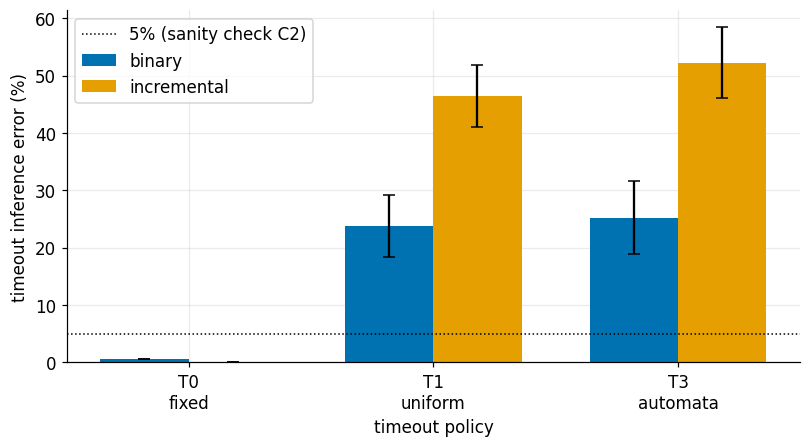


T2: mean inferred 19.97 s -- activity-dependent, so there is no
single true value to score an error against.
Timeouts a fresh probe flow receives from T2: [np.float64(20.0)] s, PredictabilityScore = 1.000


In [19]:
NOMINAL = {"T0": 10.0, "T1": 11.0, "T3": 11.0}   # T2 has no single true value
rows = []
for p in ("T0", "T1", "T3"):
    for algo in (BinarySearchProbe(), IncrementalSearchProbe()):
        errs, infs = [], []
        for s in SEEDS + list(range(20000, 20000 + max(0, 12 - len(SEEDS)))):
            r = np.random.default_rng(1000 + s)
            o = ProbeOracle(CFG, make_timeout_policy(
                CFG.merged({"timeout": {"policy": p}}), r), r)
            inf, _ = algo.infer(o)
            infs.append(inf); errs.append(abs(inf - NOMINAL[p]) / NOMINAL[p])
        m, ci = mean_ci95(np.array(errs))
        rows.append({"policy": p, "probe": algo.name, "inferred_s": np.mean(infs),
                     "rel_error": m, "ci95": ci})
inf_df = pd.DataFrame(rows)
print(inf_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
pols = ["T0", "T1", "T3"]; w = 0.36
for i, algo in enumerate(["binary", "incremental"]):
    d = inf_df[inf_df.probe == algo]
    m = [d[d.policy == p]["rel_error"].iloc[0] * 100 for p in pols]
    e = [d[d.policy == p]["ci95"].iloc[0] * 100 for p in pols]
    ax.bar(np.arange(len(pols)) + (i - 0.5) * w, m, w,
           yerr=[np.minimum(m, e), e], capsize=4, label=algo, color=CB[i])
ax.set_xticks(range(len(pols)))
ax.set_xticklabels(["T0\nfixed", "T1\nuniform", "T3\nautomata"])
ax.set_ylabel("timeout inference error (%)"); ax.set_xlabel("timeout policy")
ax.axhline(5, ls=":", color=CB[7], lw=1, label="5% (sanity check C2)")
ax.legend()
finish(fig, "fig04_inference_error", "timeout inference error per policy and probe algorithm")

# T2, reported honestly
t2 = [BinarySearchProbe().infer(ProbeOracle(CFG, make_timeout_policy(
        CFG.merged({"timeout": {"policy": "T2"}}), np.random.default_rng(1000+s)),
        np.random.default_rng(1000+s)))[0] for s in SEEDS]
# what a fresh probe flow actually receives from T2, scored with section 9's metric
_t2pol = make_timeout_policy(CFG.merged({"timeout": {"policy": "T2"}}), np.random.default_rng(0))
t2_seq = [_t2pol.assign_timeout(FlowCtx(now=0.0, owner=1, src=-1)) for _ in range(300)]
t2_pred = predictability_score(t2_seq, CFG).score
print(f"\nT2: mean inferred {np.mean(t2):.2f} s -- activity-dependent, so there is no")
print("single true value to score an error against.")
print(f"Timeouts a fresh probe flow receives from T2: {sorted(set(np.round(t2_seq, 2)))} s, "
      f"PredictabilityScore = {t2_pred:.3f}")


In [20]:
# Reading the result -- written from the numbers above
e = inf_df.set_index(["policy", "probe"])
t0_m, t0_c = e.loc[("T0", "binary"), "rel_error"], e.loc[("T0", "binary"), "ci95"]
mut = {p: (e.loc[(p, "binary"), "rel_error"], e.loc[(p, "binary"), "ci95"]) for p in ("T1", "T3")}
inc = {p: e.loc[(p, "incremental"), "rel_error"] for p in ("T1", "T3")}
separated = all((m - c) > (t0_m + t0_c) for m, c in mut.values())
t2_values = sorted(set(np.round(t2_seq, 2)))

say(
    f"**What this shows.** Against the fixed policy T0 the attacker's error is "
    f"{t0_m*100:.1f}%. Against the mutating policies it is {mut['T1'][0]*100:.0f}% (T1) and "
    f"{mut['T3'][0]*100:.0f}% (T3) with binary search, and {inc['T1']*100:.0f}% / "
    f"{inc['T3']*100:.0f}% with incremental search. "
    + ("Both mutating policies' confidence intervals sit entirely above T0's, so the "
       "degradation is not noise."
       if separated else
       "At least one mutating policy's interval reaches down to T0's, so at this scale the "
       "degradation is not established for both."),
    "Why it happens: every probe flow draws a fresh timeout, so the hit-to-miss transition "
    "the attacker is searching for is no longer at one value. Each phase-1 measurement "
    "lands somewhere in the candidate range, and the phase-2 rate built on it is wrong for "
    "most of the attacker's entries.",
    f"T2 behaves differently: a fresh probe flow always receives "
    f"{', '.join(f'{v:g} s' for v in t2_values)}, and the attacker measures "
    f"{np.mean(t2):.1f} s. "
    + (f"Its PredictabilityScore is {t2_pred:.2f}: to the attacker's probes T2 is not a "
       "moving target at all."
       if t2_pred > 0.8 else
       f"Its PredictabilityScore is {t2_pred:.2f}."),
    "What this does not yet say: breaking the measurement is not the same as buying "
    "security. §17 tests that link.",
)


**What this shows.** Against the fixed policy T0 the attacker's error is 0.6%. Against the mutating policies it is 24% (T1) and 25% (T3) with binary search, and 46% / 52% with incremental search. Both mutating policies' confidence intervals sit entirely above T0's, so the degradation is not noise.

Why it happens: every probe flow draws a fresh timeout, so the hit-to-miss transition the attacker is searching for is no longer at one value. Each phase-1 measurement lands somewhere in the candidate range, and the phase-2 rate built on it is wrong for most of the attacker's entries.

T2 behaves differently: a fresh probe flow always receives 20 s, and the attacker measures 20.0 s. Its PredictabilityScore is 1.00: to the attacker's probes T2 is not a moving target at all.

What this does not yet say: breaking the measurement is not the same as buying security. §17 tests that link.

## 17. The control experiment — is the gain from unpredictability, or just from short timeouts?


This is the most important experiment in the notebook.

§16 established that mutation breaks the attacker's measurement. The tempting
next step is to report that mutation raises the minimum attack rate and call it
security. But recall from §7 that the required rate is roughly `N / T`. **Any**
policy that lowers the effective timeout raises the required rate, whether it is
unpredictable or not.

So a fair comparison must include short **fixed** timeouts. Comparing the
mutating policies only against `T0` at its default 10 s would credit mutation
with an effect that any shorter timeout also has. "Shorten the timeout" is precisely the classic countermeasure the
literature review dismisses as inadequate, so it is exactly the baseline a
reviewer reaches for first.

This cell sweeps `T0` across its whole plausible range and puts `T1` and `T3` on
the same axis. Everything else is identical: same attacker, same detector, same
seeds.


In [21]:
base = {"threshold": {"policy": "H0"}, "detection": {"detector": "simple"},
        "attacker": {"kind": "A1", "target_entries": CFG.sim.capacity}}
ARMS = {}
for t in (2.0, 4.0, 6.0, 10.0, 20.0):
    ARMS[f"fixed {t:g}s"] = {**base, "timeout": {"policy": "T0", "fixed_s": t}}
ARMS["T1 uniform"] = {**base, "timeout": {"policy": "T1"}}
ARMS["T3 automata"] = {**base, "timeout": {"policy": "T3"}}

t0 = time.time(); ctrl = {}
for name, over in ARMS.items():
    ctrl[name] = arm_stats(over, CFGS)
    print(f"  {name:12s} min rate {ctrl[name]['min_attack_rate']:7.1f} "
          f"+/- {ctrl[name]['ci95']:4.0f}   "
          f"benign expired {ctrl[name]['benign_expired']:6.0f}   "
          f"({time.time()-t0:.0f}s)")
ctrl_df = pd.DataFrame(ctrl).T
print()
print(ctrl_df[["min_attack_rate", "ci95", "benign_expired", "packet_ins_per_s"]]
      .round(1).to_string())


  fixed 2s     min rate   517.9 +/-    5   benign expired   4581   (44s)


  fixed 4s     min rate   299.4 +/-    2   benign expired   3849   (85s)


  fixed 6s     min rate   260.1 +/-    7   benign expired   3558   (121s)


  fixed 10s    min rate   248.4 +/-    4   benign expired   3391   (151s)


  fixed 20s    min rate   259.2 +/-    4   benign expired   3349   (174s)


  T1 uniform   min rate   273.2 +/-    6   benign expired   3453   (221s)


  T3 automata  min rate   268.9 +/-    6   benign expired   3434   (281s)

            min_attack_rate      ci95 benign_expired packet_ins_per_s
fixed 2s         517.934108  4.864498      4580.5625        88.843229
fixed 4s         299.436848  1.782517       3849.125        77.364063
fixed 6s         260.124752  7.341459       3558.125        72.833854
fixed 10s        248.439076  4.485695      3390.5625         70.26875
fixed 20s          259.2265  4.282889     3348.53125        69.648438
T1 uniform       273.242026  5.739009     3452.96875        71.224479
T3 automata      268.887674  6.286021     3434.40625        70.958854


In [22]:
# Reading the result -- written from the numbers above
fixed = {n: v for n, v in ctrl.items() if n.startswith("fixed")}
mutating = {n: v for n, v in ctrl.items() if not n.startswith("fixed")}
bf_name = max(fixed, key=lambda n: fixed[n]["min_attack_rate"])
bm_name = max(mutating, key=lambda n: mutating[n]["min_attack_rate"])
bf, bm = ctrl[bf_name], ctrl[bm_name]
t1, t3 = ctrl["T1 uniform"], ctrl["T3 automata"]
d_rate = paired(t3["per_seed_rate"], t1["per_seed_rate"])        # T3 - T1, same seeds
d_cost = paired(t3["per_seed_expired"], t1["per_seed_expired"])
long_fixed = {n: v for n, v in fixed.items() if float(n.split()[1].rstrip("s")) >= 6}
lf_name = max(long_fixed, key=lambda n: long_fixed[n]["min_attack_rate"])
lf = ctrl[lf_name]

# The N/T arithmetic of section 7, with this notebook's own numbers
benign_occ = run_config(CFGS, SEEDS[0], with_attacker=False).mean_occ
n_needed = (CFG.experiment.occupancy_target_frac - benign_occ) * CFG.sim.capacity
t_short = float(bf_name.split()[1].rstrip("s"))
predicted = n_needed / (t_short * (1 - CFG.attacker.refresh_margin_frac))

say(
    f"**Read the first column.** The best fixed timeout ({bf_name}) forces the attacker to "
    f"{bf['min_attack_rate']:.0f} ± {bf['ci95']:.0f} pps; the best mutating policy "
    f"({bm_name}) forces {bm['min_attack_rate']:.0f} ± {bm['ci95']:.0f}. "
    + ("The short fixed timeout is higher, beyond the error bars. "
       if bf["min_attack_rate"] - bf["ci95"] > bm["min_attack_rate"] + bm["ci95"] else
       "The two overlap. " if overlaps(bf["min_attack_rate"], bf["ci95"],
                                        bm["min_attack_rate"], bm["ci95"]) else
       "The mutating policy is higher, beyond the error bars. "),
    f"The arithmetic of §7 explains it. With benign traffic holding {benign_occ:.0%} of the "
    f"table, the attacker needs about {n_needed:.0f} entries to reach 95%; refreshing each "
    f"one every {t_short*(1-CFG.attacker.refresh_margin_frac):.1f} s (just under a {t_short:g} s "
    f"timeout) costs about {predicted:.0f} pps, against {bf['min_attack_rate']:.0f} measured. "
    "So this metric mostly measures how SHORT the timeout is, not how unpredictable it is. "
    "That limits what the metric can show, not the thesis.",
    f"T1 (uniform) and T3 (automaton) force {t1['min_attack_rate']:.0f} ± {t1['ci95']:.0f} and "
    f"{t3['min_attack_rate']:.0f} ± {t3['ci95']:.0f} pps. Because both ran on the same "
    f"{len(SEEDS)} seeds, the sharper test is seed by seed: T3 minus T1 is "
    f"{d_rate[0]:+.1f} ± {d_rate[1]:.1f} pps on security and {d_cost[0]:+.0f} ± {d_cost[1]:.0f} "
    "benign expiries on cost. "
    + ("Neither difference is distinguishable from zero: learning does not change the "
       "outcome relative to uniform mutation on these two axes."
       if abs(d_rate[0]) <= d_rate[1] and abs(d_cost[0]) <= d_cost[1] else
       ("The automaton is " + ("more" if d_rate[0] > 0 else "less") + " secure beyond the error "
        "bars" if abs(d_rate[0]) > d_rate[1] else "Security is indistinguishable")
       + (", and " + ("cheaper" if d_cost[0] < 0 else "more costly") + " beyond the error bars."
          if abs(d_cost[0]) > d_cost[1] else ", and cost is indistinguishable.")),
    f"**Now read the second column.** With no attacker present, {bf_name} expires "
    f"{bf['benign_expired']:.0f} benign entries; {bm_name} expires {bm['benign_expired']:.0f} "
    f"({bf['benign_expired']/bm['benign_expired']:.2f}x fewer), close to the "
    f"{ctrl['fixed 10s']['benign_expired']:.0f} of a fixed 10 s timeout. "
    + ("That is the real argument for mutation: "
       + (f"more security than any fixed timeout of 6 s or longer (best: {lf_name}, "
          f"{lf['min_attack_rate']:.0f} pps) "
          if bm["min_attack_rate"] - bm["ci95"] > lf["min_attack_rate"] + lf["ci95"] else
          f"security comparable to the long fixed timeouts (best: {lf_name}, "
          f"{lf['min_attack_rate']:.0f} pps) ")
       + "at a much lower collateral cost than the short one, because most benign flows "
       "still get a long timeout while the attacker can rely on no single value."
       if bf["benign_expired"] > 1.05 * bm["benign_expired"] else
       "The costs are close, so cost does not separate them either."),
)


**Read the first column.** The best fixed timeout (fixed 2s) forces the attacker to 518 ± 5 pps; the best mutating policy (T1 uniform) forces 273 ± 6. The short fixed timeout is higher, beyond the error bars. 

The arithmetic of §7 explains it. With benign traffic holding 40% of the table, the attacker needs about 991 entries to reach 95%; refreshing each one every 1.8 s (just under a 2 s timeout) costs about 550 pps, against 518 measured. So this metric mostly measures how SHORT the timeout is, not how unpredictable it is. That limits what the metric can show, not the thesis.

T1 (uniform) and T3 (automaton) force 273 ± 6 and 269 ± 6 pps. Because both ran on the same 32 seeds, the sharper test is seed by seed: T3 minus T1 is -4.4 ± 3.7 pps on security and -19 ± 5 benign expiries on cost. The automaton is less secure beyond the error bars, and cheaper beyond the error bars.

**Now read the second column.** With no attacker present, fixed 2s expires 4581 benign entries; T1 uniform expires 3453 (1.33x fewer), close to the 3391 of a fixed 10 s timeout. That is the real argument for mutation: more security than any fixed timeout of 6 s or longer (best: fixed 6s, 260 pps) at a much lower collateral cost than the short one, because most benign flows still get a long timeout while the attacker can rely on no single value.

## 18. The security-cost trade-off


Both axes of the same data. Left: what each policy forces the attacker to do.
Right: what it costs legitimate traffic. A defence is only interesting if it is
on the efficient frontier of both.

Collateral is measured as **benign entries expired with no attacker present**,
not as packet-ins at a reference attack rate. The latter conflates two opposite
things: a defence that stops the attack outright records fewer attacker installs
and so looks cheap, which reverses the ranking. Measuring it with the attacker
switched off isolates the harm the timeout policy does on its own.


[figures/fig05_security_per_policy.png]  security forced by each timeout policy (min attack rate, higher = better)


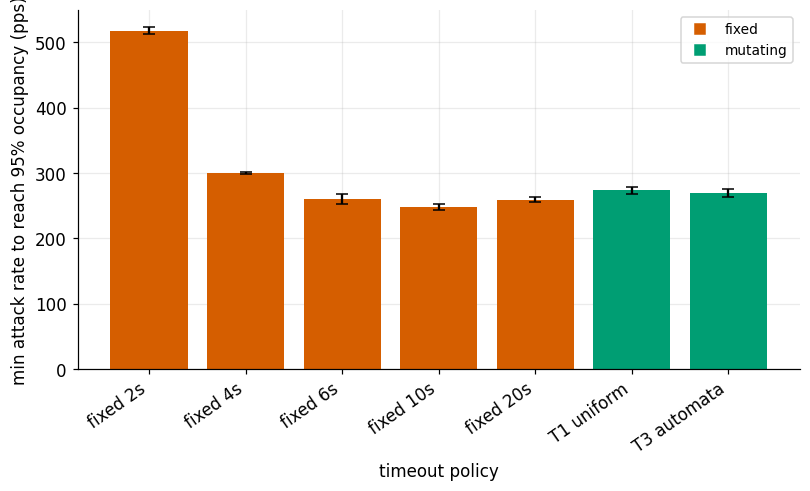

[figures/fig06_cost_per_policy.png]  collateral cost of each timeout policy (benign expiries, lower = better)


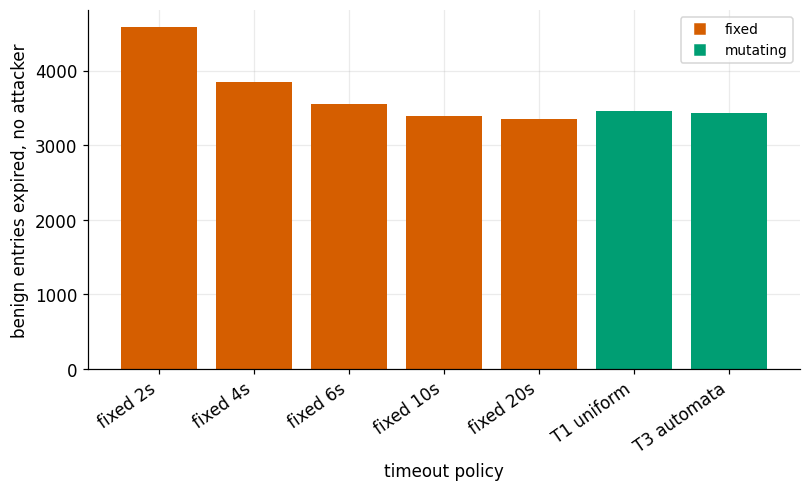

[figures/fig07_security_cost_frontier.png]  security against collateral cost per timeout policy (up and left is better)


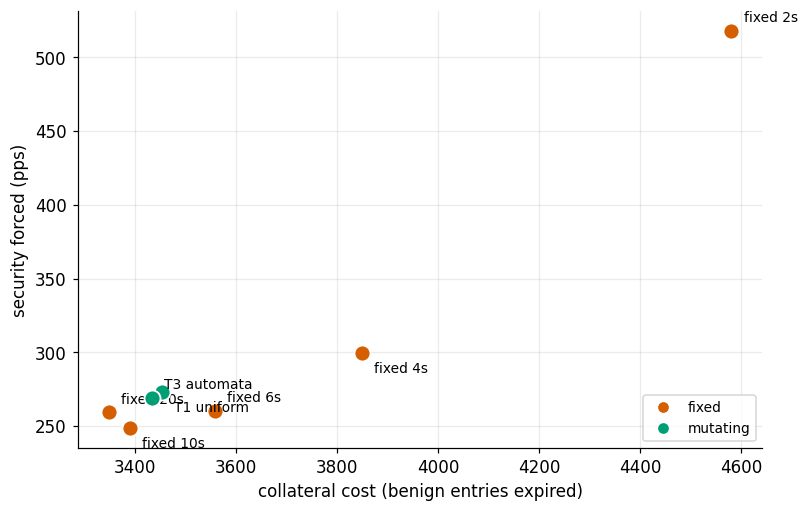

Cost of each pps of extra security, relative to a fixed 10 s timeout:
policy          d(security)    d(cost)   cost per pps
------------------------------------------------------
fixed 2s              269.5       1190           4.42
fixed 4s               51.0        459           8.99
fixed 6s               11.7        168          14.34
fixed 10s               0.0          0            nan
fixed 20s              10.8        -42          -3.90
T1 uniform             24.8         62           2.52
T3 automata            20.4         44           2.14


In [23]:
names = list(ctrl.keys())
is_mut = [not n.startswith("fixed") for n in names]
cols = [CB[2] if m else CB[3] for m in is_mut]
x = np.arange(len(names))

from matplotlib.lines import Line2D
_leg = [Line2D([], [], marker="s", ls="", color=CB[3], label="fixed"),
        Line2D([], [], marker="s", ls="", color=CB[2], label="mutating")]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.bar(x, [ctrl[n]["min_attack_rate"] for n in names],
       yerr=[ctrl[n]["ci95"] for n in names], capsize=4, color=cols)
ax.set_ylabel("min attack rate to reach 95% occupancy (pps)")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=35, ha="right")
ax.set_xlabel("timeout policy"); ax.legend(handles=_leg, fontsize=9)
finish(fig, "fig05_security_per_policy",
       "security forced by each timeout policy (min attack rate, higher = better)")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.bar(x, [ctrl[n]["benign_expired"] for n in names], color=cols)
ax.set_ylabel("benign entries expired, no attacker")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=35, ha="right")
ax.set_xlabel("timeout policy"); ax.legend(handles=_leg, fontsize=9)
finish(fig, "fig06_cost_per_policy",
       "collateral cost of each timeout policy (benign expiries, lower = better)")

# the frontier: cost on x, security on y -- up and to the left is better
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for k, (n, m) in enumerate(zip(names, is_mut)):
    ax.scatter(ctrl[n]["benign_expired"], ctrl[n]["min_attack_rate"],
               s=110, color=CB[2] if m else CB[3], zorder=3,
               edgecolor="white", linewidth=1.2)
    ax.annotate(n, (ctrl[n]["benign_expired"], ctrl[n]["min_attack_rate"]),
                textcoords="offset points", xytext=(8, 6 if k % 2 == 0 else -13), fontsize=9)
ax.set_xlabel("collateral cost (benign entries expired)")
ax.set_ylabel("security forced (pps)")
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=CB[3], label="fixed"),
                   Line2D([], [], marker="o", ls="", color=CB[2], label="mutating")],
          fontsize=9, loc="lower right")
finish(fig, "fig07_security_cost_frontier",
       "security against collateral cost per timeout policy (up and left is better)")

ref = ctrl["fixed 10s"]
print("Cost of each pps of extra security, relative to a fixed 10 s timeout:")
print(f"{'policy':14s} {'d(security)':>12s} {'d(cost)':>10s} {'cost per pps':>14s}")
print("-" * 54)
for n in names:
    ds = ctrl[n]["min_attack_rate"] - ref["min_attack_rate"]
    dc = ctrl[n]["benign_expired"]  - ref["benign_expired"]
    per = (dc / ds) if ds > 1 else float("nan")
    print(f"{n:14s} {ds:12.1f} {dc:10.0f} {per:14.2f}")


In [24]:
# Reading the result -- written from the numbers above
names = list(ctrl.keys())
sec  = {n: ctrl[n]["min_attack_rate"] for n in names}
cost = {n: ctrl[n]["benign_expired"] for n in names}
# efficient frontier: no other policy is at least as secure AND at least as cheap
frontier = [n for n in names
            if not any(sec[m] >= sec[n] and cost[m] <= cost[n] and (sec[m], cost[m]) != (sec[n], cost[n])
                       for m in names)]
ref10 = ctrl["fixed 10s"]
per_pps, reliable = {}, {}
for n in names:
    ds = sec[n] - ref10["min_attack_rate"]
    if ds > 1:
        per_pps[n] = (cost[n] - ref10["benign_expired"]) / ds
        # is the security gain itself established? paired over the same seeds
        dm_, dc_ = paired(ctrl[n]["per_seed_rate"], ref10["per_seed_rate"])
        reliable[n] = dm_ - dc_ > 0
mut_on_front = [n for n in frontier if not n.startswith("fixed")]
solid = {n: v for n, v in per_pps.items() if reliable[n]}
shaky = {n: v for n, v in per_pps.items() if not reliable[n] and v > 0}

say(
    "**How to read the frontier (`fig06`).** Up and to the left is better: more security for less "
    "collateral. A point below and to the right of another is strictly worse.",
    f"**On the frontier (on the means):** {', '.join(frontier)}. "
    + (f"The mutating polic{'y' if len(mut_on_front) == 1 else 'ies'} "
       f"{' and '.join(mut_on_front)} {'is' if len(mut_on_front) == 1 else 'are'} on it, so "
       "mutation is an efficient choice, not a dominated one."
       if mut_on_front else
       "No mutating policy is on it: on these two axes timeout mutation is dominated by some "
       "fixed timeout, and the case for it has to rest on §16 (inference) instead."),
    "**The number to quote:** benign entries lost per extra pps of forced attack rate, "
    "relative to a fixed 10 s timeout (last table). "
    + (("Where the security gain over a fixed 10 s timeout is established seed by seed: "
        + ", ".join(f"{n} {v:.2f}" for n, v in solid.items()) + ". ") if solid else "")
    + (("The mutating policies' ratios are lower — "
        + ", ".join(f"{n} {v:.2f}" for n, v in shaky.items() if not n.startswith("fixed"))
        + " — but their security gains over a fixed 10 s timeout are not established seed "
        "by seed at this scale, so these ratios are indicative. ")
       if any(not n.startswith("fixed") for n in shaky) else ""),
    "The structure of the argument is what matters: a short fixed timeout wins on raw "
    "security and pays for it in benign traffic, and a mutating policy's case rests on this "
    "ratio, not on raw security.",
)


**How to read the frontier (`fig06`).** Up and to the left is better: more security for less collateral. A point below and to the right of another is strictly worse.

**On the frontier (on the means):** fixed 2s, fixed 4s, fixed 20s, T1 uniform, T3 automata. The mutating policies T1 uniform and T3 automata are on it, so mutation is an efficient choice, not a dominated one.

**The number to quote:** benign entries lost per extra pps of forced attack rate, relative to a fixed 10 s timeout (last table). Where the security gain over a fixed 10 s timeout is established seed by seed: fixed 2s 4.42, fixed 4s 8.99, fixed 6s 14.34, fixed 20s -3.90, T1 uniform 2.52, T3 automata 2.14. 

The structure of the argument is what matters: a short fixed timeout wins on raw security and pays for it in benign traffic, and a mutating policy's case rests on this ratio, not on raw security.

## 19. Does the automaton actually learn? And does the entropy floor bind?


Three questions that are easy to conflate.

**First, the mechanism under maximum pressure.** Make the same action the best
300 times running and watch what the floor does.

**Second, does it learn at all?** An automaton's probabilities always move, so
movement proves nothing: an automaton fed pure noise also "converges" some way,
simply by drift. The test is a comparison against a control. Run each situation
over several seeds, measure how much probability the automaton ends up putting
on short timeouts (≤6 s) and on long ones (≥14 s), and compare with the same
automaton whose feedback is replaced by noise (`control_noise_reward`). Learning
means a difference beyond the error bars, in the direction the situation calls
for. A naive credit assignment (`defense_update = "legacy"`: one table-wide
reward per second credited to whichever timeout was installed last, with L_RI)
is run the same way as an ablation.

**Third, what does it learn, and is that sensible?** Under attack, with no
attacker, and with no detector to supply suspicion evidence, a working automaton
should behave differently in each.


H_max (uniform) = 2.303 nats,  floor = 1.266 nats
admissible max single probability = 0.910

 epoch | max p_i | entropy | above floor?
--------------------------------------------
    50 |  0.684  |  1.317  | yes
   100 |  0.682  |  1.323  | yes
   150 |  0.672  |  1.355  | yes
   200 |  0.666  |  1.370  | yes
   250 |  0.663  |  1.378  | yes
   300 |  0.656  |  1.400  | yes

Final p_eff = [0.038 0.038 0.038 0.038 0.656 0.038 0.038 0.038 0.038 0.038]
PredictabilityScore of 400 draws from this converged vector: 0.330



What LA-A ends up preferring, 32 seeds per condition, 95% CI over seeds
(a uniform distribution puts 0.30 on timeouts <= 6 s and 0.40 on timeouts >= 14 s):
                            condition                                                                                           favoured timeout per seed  mass on <=6 s  ci short  mass on >=14 s  ci long  suspicious re-installs  suspicious refreshed  security evidence weight
   under attack (A1), simple verdicts                 [4, 4, 6, 4, 6, 10, 4, 8, 4, 4, 4, 8, 6, 4, 4, 6, 10, 4, 4, 8, 6, 4, 4, 6, 4, 4, 20, 4, 8, 4, 4, 4]           0.65      0.07            0.12     0.04                 1140.41                815.53                   1273.88
under attack (A3), LA-DETECT verdicts                    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]           0.74      0.01            0.15     0.01                 2865.28               1032.62                    801.07
               

[figures/fig08_la_probabilities_over_time.png]  LA-A probability of each timeout candidate over one run under attack (A1)


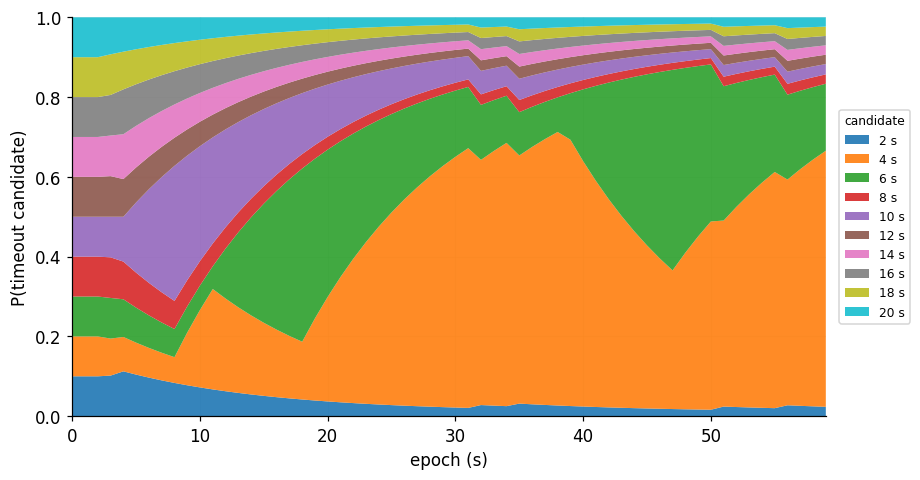

[figures/fig09_la_entropy_vs_floor.png]  entropy of LA-A and LA-B in the same run, against each entropy floor


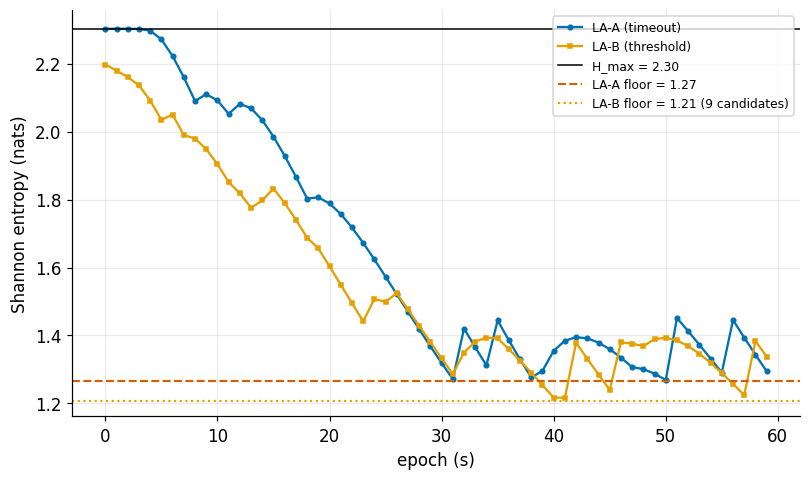

[figures/fig10_la_learned_distribution.png]  what LA-A ends up preferring in each condition, against the noise control


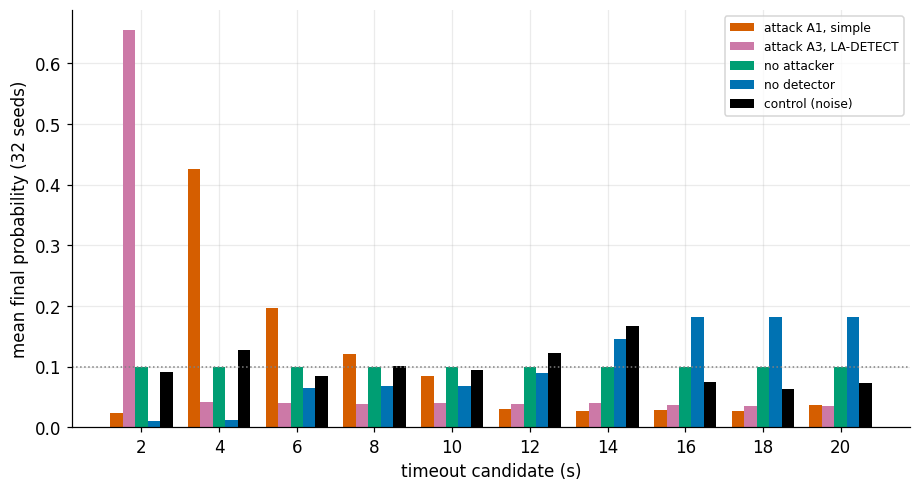

LA-A entropy in this run: start 2.303 -> end 1.295 (97% of the way from H_max to the floor)
outcome events that trained it: {'suspicious_reinstall': 1549, 'suspicious_refreshed': 575, 'benign_reinstall': 394, 'security_evidence_weight': 1571.6592592592642}


In [25]:
# --- 1. the mechanism, under maximum pressure ------------------------------ #
la = LinearAutomaton(n_actions=10, scheme=CFG.automaton.scheme, a=CFG.automaton.a,
                     epsilon=CFG.automaton.epsilon,
                     h_min_frac=CFG.automaton.h_min_frac, rng=np.random.default_rng(0))
print(f"H_max (uniform) = {np.log(10):.3f} nats,  floor = {la.h_min:.3f} nats")
print(f"admissible max single probability = {(1-CFG.automaton.epsilon) + CFG.automaton.epsilon/10:.3f}\n")
hist = []
for epoch in range(1, 301):
    la.pursue(4)                      # the same action is the best, 300 times running
    hist.append((epoch, la.p_eff().max(), la.entropy()))
print(" epoch | max p_i | entropy | above floor?")
print("-" * 44)
for e, pmax, h in hist[49::50]:
    print(f" {e:5d} |  {pmax:.3f}  |  {h:.3f}  | {'yes' if h >= la.h_min-1e-9 else 'NO'}")
print(f"\nFinal p_eff = {np.round(la.p_eff(), 3)}")
seq = [CFG.timeout.la_candidates_s[la.sample_index()] for _ in range(400)]
stress_pred = predictability_score(seq, CFG, alphabet=CFG.timeout.la_candidates_s).score
stress_maxp = float(la.p_eff().max())
print(f"PredictabilityScore of 400 draws from this converged vector: {stress_pred:.3f}")

# --- 2. does it learn?  consistency across seeds, against a no-information control
cands = CFG.timeout.la_candidates_s
DIAG_SEEDS = list(range(BASE_SEED, BASE_SEED + max(8, N_SEEDS)))

def _live(det, atk="A3", extra=None):
    c = CFGS.merged({"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                     "detection": {"detector": det},
                     "attacker": {"kind": atk, "rate_pps": 300,
                                  "target_entries": CFG.sim.capacity}})
    return c.merged(extra) if extra else c

CONDITIONS = {
  "under attack (A1), simple verdicts":    (_live("simple", "A1"), True),   # the T3 row of section 17
  "under attack (A3), LA-DETECT verdicts": (_live("la_detect"), True),      # the full defence
  "no attacker at all":                    (_live("la_detect"), False),
  "no detector (no suspicion evidence)":   (_live("none", "A1"), True),
  "CONTROL: feedback replaced by noise":   (_live("la_detect", extra={
                                              "automaton": {"control_noise_reward": True}}), True),
  "ABLATION: naive credit (legacy)":       (_live("la_detect", extra={
                                              "automaton": {"defense_update": "legacy"}}), True),
}
LABELS = {"under attack (A1), simple verdicts": "under a classic attack (the §17 setting)",
          "under attack (A3), LA-DETECT verdicts": "under the adaptive attack, full defence",
          "no attacker at all": "with no attacker",
          "no detector (no suspicion evidence)": "with no detector"}
learn_rows, P_final, P_seeds = [], {}, {}
for name, (cfg_c, atk_on) in CONDITIONS.items():
    fav, P, ev = [], [], []
    for r_ in pmap(run_config, [(cfg_c, int(s), atk_on) for s in DIAG_SEEDS]):
        p = r_.la_a_p[-1]
        P.append(p); fav.append(cands[int(np.argmax(p))]); ev.append(r_.meta["la_events"])
    P = np.array(P); P_final[name] = P.mean(axis=0); P_seeds[name] = P
    short, long_ = P[:, :3].sum(axis=1), P[:, 6:].sum(axis=1)
    ms, cs = mean_ci95(short); ml, cl = mean_ci95(long_)
    learn_rows.append({"condition": name, "favoured timeout per seed": fav,
                       "mass on <=6 s": ms, "ci short": cs,
                       "mass on >=14 s": ml, "ci long": cl,
                       "suspicious re-installs": np.mean([e["suspicious_reinstall"] for e in ev]),
                       "suspicious refreshed": np.mean([e["suspicious_refreshed"] for e in ev]),
                       "security evidence weight": np.mean([e["security_evidence_weight"] for e in ev])})
learn_df = pd.DataFrame(learn_rows)
pd.set_option("display.width", 220)
print(f"\nWhat LA-A ends up preferring, {len(DIAG_SEEDS)} seeds per condition, 95% CI over seeds")
print("(a uniform distribution puts 0.30 on timeouts <= 6 s and 0.40 on timeouts >= 14 s):")
print(learn_df.round(2).to_string(index=False))

# --- 3. one live run in the section-16 configuration, for the figure ------- #
r = run_config(_live("simple", "A1"), BASE_SEED)
ent_a = np.array(r.la_a_entropy); ent_b = np.array(r.la_b_entropy)
P = np.array(r.la_a_p)
cols10 = plt.get_cmap("tab10").colors
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.stackplot(range(len(P)), P.T, colors=cols10, alpha=0.9,
             labels=[f"{c:g} s" for c in cands])
ax.set_xlabel("epoch (s)"); ax.set_ylabel("P(timeout candidate)"); ax.set_ylim(0, 1)
ax.set_xlim(0, len(P) - 1)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5),
          title="candidate", title_fontsize=8)
finish(fig, "fig08_la_probabilities_over_time",
       "LA-A probability of each timeout candidate over one run under attack (A1)")

hmax = np.log(len(cands)); hmin = CFG.automaton.h_min_frac * hmax
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ent_a, marker="o", ms=3, color=CB[0], label="LA-A (timeout)")
if len(ent_b):
    ax.plot(ent_b, marker="s", ms=3, color=CB[1], label="LA-B (threshold)")
ax.axhline(hmax, ls="-",  color=CB[7], lw=1, label=f"H_max = {hmax:.2f}")
ax.axhline(hmin, ls="--", color=CB[3], lw=1.4, label=f"LA-A floor = {hmin:.2f}")
hmin_b = CFG.automaton.h_min_frac * np.log(len(CFG.threshold.la_candidates))
ax.axhline(hmin_b, ls=":", color=CB[1], lw=1.4, label=f"LA-B floor = {hmin_b:.2f} (9 candidates)")
ax.set_xlabel("epoch (s)"); ax.set_ylabel("Shannon entropy (nats)")
ax.legend(fontsize=8, loc="upper right")
finish(fig, "fig09_la_entropy_vs_floor",
       "entropy of LA-A and LA-B in the same run, against each entropy floor")

show = [("under attack (A1), simple verdicts", "attack A1, simple", CB[3]),
        ("under attack (A3), LA-DETECT verdicts", "attack A3, LA-DETECT", CB[4]),
        ("no attacker at all", "no attacker", CB[2]),
        ("no detector (no suspicion evidence)", "no detector", CB[0]),
        ("CONTROL: feedback replaced by noise", "control (noise)", CB[7])]
w = 0.16; x = np.arange(len(cands))
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for i, (name, lab, col) in enumerate(show):
    ax.bar(x + (i - 2) * w, P_final[name], w, color=col, label=lab)
ax.axhline(1 / len(cands), ls=":", color="grey", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"{c:g}" for c in cands])
ax.set_xlabel("timeout candidate (s)"); ax.set_ylabel(f"mean final probability ({len(DIAG_SEEDS)} seeds)")
ax.legend(fontsize=8)
finish(fig, "fig10_la_learned_distribution",
       "what LA-A ends up preferring in each condition, against the noise control")

ent_travelled = (hmax - ent_a[-1]) / (hmax - hmin)
print(f"LA-A entropy in this run: start {ent_a[0]:.3f} -> end {ent_a[-1]:.3f} "
      f"({ent_travelled*100:.0f}% of the way from H_max to the floor)")
print(f"outcome events that trained it: {r.meta['la_events']}")


In [26]:
# Reading the result -- written from the numbers above
L = learn_df.set_index("condition")
CTL = "CONTROL: feedback replaced by noise"
NAIVE = "ABLATION: naive credit (legacy)"
A1C, A3C = "under attack (A1), simple verdicts", "under attack (A3), LA-DETECT verdicts"
floor_ok = all(h >= CFG.automaton.h_min_frac * np.log(10) - 1e-9 for _, _, h in hist)

def _cmp(cond, col, ci):
    """'higher' / 'lower' than the noise control beyond both intervals, else 'same'."""
    m, c, mc, cc = L.loc[cond, col], L.loc[cond, ci], L.loc[CTL, col], L.loc[CTL, ci]
    return "higher" if m - c > mc + cc else "lower" if m + c < mc - cc else "same"

# expected direction: under attack -> more on short timeouts; calm -> less on short or more on long
verdicts, bullets = {}, []
for cond, label in LABELS.items():
    s_v = _cmp(cond, "mass on <=6 s", "ci short"); l_v = _cmp(cond, "mass on >=14 s", "ci long")
    attack = cond.startswith("under attack")
    ok = (s_v == "higher") if attack else (s_v == "lower" or l_v == "higher")
    verdicts[cond] = ("short" if attack else "long", "higher" if ok else "same")
    bullets.append(
        f"- {label}: {L.loc[cond, 'mass on <=6 s']:.2f} ± {L.loc[cond, 'ci short']:.2f} on "
        f"short timeouts (≤6 s) and {L.loc[cond, 'mass on >=14 s']:.2f} ± "
        f"{L.loc[cond, 'ci long']:.2f} on long ones (≥14 s) — "
        + ("**differs from the noise control in the expected direction**" if ok else
           "not distinguishable from the noise control"))
learned = [c for c, (k, v) in verdicts.items() if v == "higher"]
naive_same = _cmp(NAIVE, "mass on <=6 s", "ci short") == "same"
why = []
if verdicts[A1C][1] == "higher":
    why.append("under a classic attack it moves toward short timeouts, which make the "
               "attacker's refreshers arrive too late")
if any(verdicts[c][1] == "higher" for c in ("no attacker at all", "no detector (no suspicion evidence)")):
    why.append("when there is no pressure or no suspicion evidence, the only evidence it gets is "
               "collateral damage to benign flows, so it moves away from short timeouts")
_w = lambda c: L.loc[c, "security evidence weight"]
_n = lambda c: L.loc[c, "suspicious re-installs"] + L.loc[c, "suspicious refreshed"]
weak_a3 = verdicts[A3C][1] != "higher" and _w(A3C) < 0.5 * _w(A1C)

say(
    f"**The mechanism.** With one action the best for 300 epochs running, the entropy "
    + ("stays above the floor throughout" if floor_ok else "DROPS BELOW the floor -- the floor is broken")
    + f", and the favoured action tops out at p = {stress_maxp:.2f}. The automaton cannot "
    f"collapse onto one timeout, but draws from that vector still score {stress_pred:.2f} on "
    "PredictabilityScore (0 = unpredictable): \"cannot collapse\" is not \"cannot be predicted\".",
    "**Does it learn, and what?** The test is whether the distribution it ends up with "
    f"differs from the one it ends up with when its feedback is pure noise (control: "
    f"{L.loc[CTL, 'mass on <=6 s']:.2f} ± {L.loc[CTL, 'ci short']:.2f} short, "
    f"{L.loc[CTL, 'mass on >=14 s']:.2f} ± {L.loc[CTL, 'ci long']:.2f} long):\n\n"
    + "\n".join(bullets),
    (f"It learns in {len(learned)} of the 4 situations" + (": " + "; ".join(why) + ". " if why else ". ")
     if learned else
     "In none of the situations does it differ from the noise control beyond the error bars, "
     "so learning is not established at this scale. ")
    + (f"Under the adaptive attack with the full defence the signal is weaker, and the "
       f"reason is measurable: the automaton sees about as many suspicious-flow outcomes "
       f"({_n(A3C):.0f} per run, against {_n(A1C):.0f} under the classic attack), but LA-DETECT "
       "keeps the table under less pressure, so those outcomes carry less weight "
       f"(total {_w(A3C):.0f} against {_w(A1C):.0f}). By design, LA-A only "
       "tightens timeouts when the detection layer is not already holding the table. "
       if weak_a3 else "")
    + ("With naive credit assignment (one table-wide reward credited to the last install) the "
       "result is indistinguishable from noise: correct credit assignment is what makes "
       "learning possible here. " if naive_same else ""),
    "Whether this learned behaviour buys *security* is a separate question, answered in "
    "§17, §18 and Appendix B.",
)


**The mechanism.** With one action the best for 300 epochs running, the entropy stays above the floor throughout, and the favoured action tops out at p = 0.66. The automaton cannot collapse onto one timeout, but draws from that vector still score 0.33 on PredictabilityScore (0 = unpredictable): "cannot collapse" is not "cannot be predicted".

**Does it learn, and what?** The test is whether the distribution it ends up with differs from the one it ends up with when its feedback is pure noise (control: 0.30 ± 0.06 short, 0.38 ± 0.08 long):

- under a classic attack (the §17 setting): 0.65 ± 0.07 on short timeouts (≤6 s) and 0.12 ± 0.04 on long ones (≥14 s) — **differs from the noise control in the expected direction**
- under the adaptive attack, full defence: 0.74 ± 0.01 on short timeouts (≤6 s) and 0.15 ± 0.01 on long ones (≥14 s) — **differs from the noise control in the expected direction**
- with no attacker: 0.30 ± 0.00 on short timeouts (≤6 s) and 0.40 ± 0.00 on long ones (≥14 s) — not distinguishable from the noise control
- with no detector: 0.09 ± 0.02 on short timeouts (≤6 s) and 0.69 ± 0.07 on long ones (≥14 s) — **differs from the noise control in the expected direction**

It learns in 3 of the 4 situations: under a classic attack it moves toward short timeouts, which make the attacker's refreshers arrive too late; when there is no pressure or no suspicion evidence, the only evidence it gets is collateral damage to benign flows, so it moves away from short timeouts. With naive credit assignment (one table-wide reward credited to the last install) the result is indistinguishable from noise: correct credit assignment is what makes learning possible here. 

Whether this learned behaviour buys *security* is a separate question, answered in §17, §18 and Appendix B.

## 20. Detection quality, and the two Learning-Automata roles


Two things at once, because they share an experimental design.

**Detection.** Four detectors on the same seeds: the published fixed-rule
baseline (`simple`), the hand-weighted evidence of the current epoch with no
memory (`score`), the per-flow automaton with hand-set values (`la_hand`), and
LA-DETECT with the values learned in §14 (`la_detect`). `la_hand` minus `score`
is what reading the sequence adds; `la_detect` minus `la_hand` is what learning
adds. Every metric the detection papers report is computed from the confusion
counts of each run: accuracy, precision, recall, specificity, false-positive
rate, F1, balanced accuracy, MCC and detection latency, plus the wall-clock
cost of one classification round. §8 explained the trap: with disjoint feature
ranges the task is separable by construction and F1 comes out at exactly 1.000
with zero variance. The interpretation cell checks for that symptom.

**The two LA roles**, as a genuine 2×2. There is an easy confound here: a
"neither" cell with `detector="none"` disables mitigation *entirely* (§11), so
the step from "neither" to "LA-DEFENSE only" would change three things at once —
timeout mutation, threshold mutation, and whether any mitigation exists — and
most of the apparent gain would come from simply switching the detector on.

Here mitigation is switched on in all four cells, so the only thing varying
is the LA role. The true no-defence reference is reported separately, beside the
2×2 rather than inside it.


--- detector comparison: attack A1, fixed timeout, threshold H0 ---


                accuracy      precision         recall    specificity            fpr             f1   balanced_acc            mcc      latency_s   ms_per_epoch
detector                                                                                                                                                       
simple     0.582 ± 0.001  0.902 ± 0.002  0.305 ± 0.003  0.956 ± 0.001  0.044 ± 0.001  0.456 ± 0.004  0.631 ± 0.002  0.326 ± 0.003  3.505 ± 0.000  0.055 ± 0.002
score      0.828 ± 0.003  0.736 ± 0.005  1.000 ± 0.000  0.669 ± 0.002  0.331 ± 0.002  0.848 ± 0.003  0.834 ± 0.001  0.701 ± 0.003  0.495 ± 0.000  0.102 ± 0.002
la_hand    0.832 ± 0.003  0.742 ± 0.005  1.000 ± 0.000  0.675 ± 0.003  0.325 ± 0.003  0.852 ± 0.003  0.838 ± 0.001  0.708 ± 0.003  0.495 ± 0.000  0.117 ± 0.007
la_detect  0.929 ± 0.001  0.866 ± 0.003  0.999 ± 0.000  0.868 ± 0.002  0.132 ± 0.002  0.928 ± 0.002  0.934 ± 0.001  0.866 ± 0.002  0.505 ± 0.000  0.121 ± 0.008
(mean ± 95% CI over seeds; latency = sim

  neither           min rate   248.4 +/-    4


  LA-DEFENSE only   min rate   221.3 +/-   13


  LA-DETECT only    min rate   254.5 +/-    4


  both              min rate   332.6 +/-   32



  [reported separately, NOT part of the 2x2]
  no defence at all min rate    98.9 +/-    0   (detector=none -> no mitigation whatsoever)


[figures/fig11_detection_quality.png]  detection quality of the four detectors (attack A1, 95% CI over seeds)


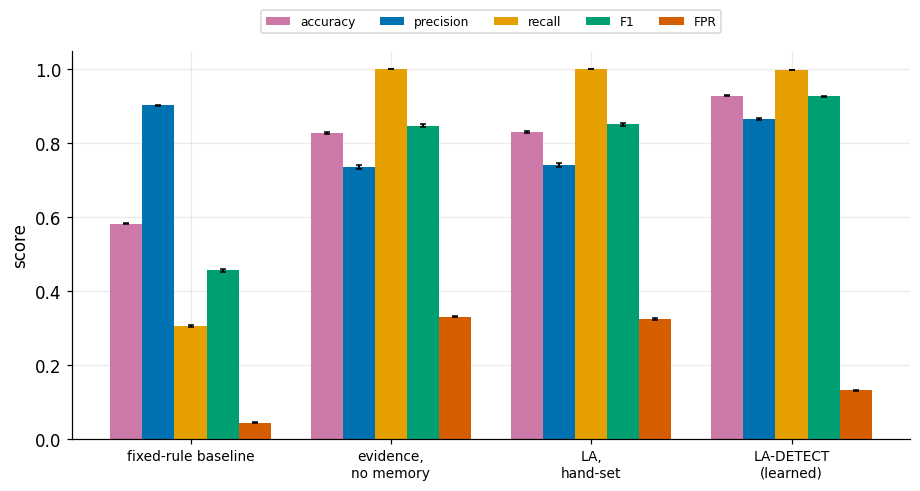

[figures/fig12_la_roles.png]  contribution of each LA role (2x2, mitigation on in every cell)


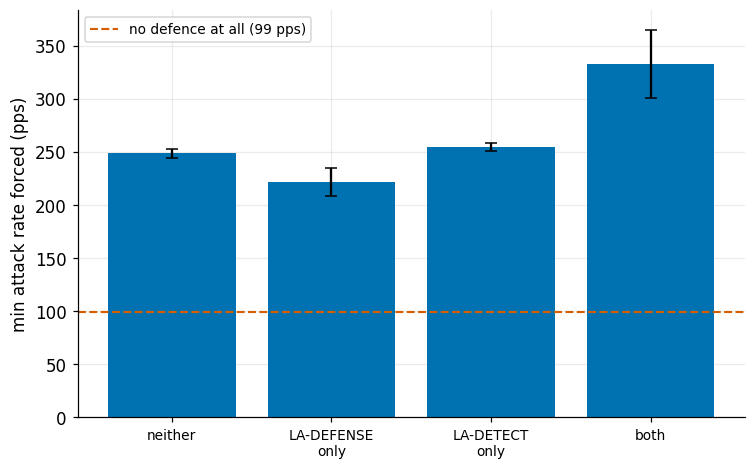


If precision is EXACTLY 1.000 with ZERO variance across seeds, the
classification task has become separable again -- check the feature ranges
in the config before believing any of these numbers.


In [27]:
# --- detection quality ---
DETECTORS = {"simple": "fixed-rule baseline", "score": "evidence, no memory",
             "la_hand": "LA, hand-set", "la_detect": "LA-DETECT (learned)"}
print("--- detector comparison: attack A1, fixed timeout, threshold H0 ---")
det_rows = []
for det in DETECTORS:
    det_cfg = CFGS.merged({"detection": {"detector": det}, "threshold": {"policy": "H0"},
                           "attacker": {"kind": "A1", "rate_pps": 300,
                                        "target_entries": CFG.sim.capacity}})
    rs = pmap(run_config, [(det_cfg, int(s)) for s in SEEDS])
    for k, r in zip(SEEDS, rs):
        det_rows.append({"detector": det, "seed": k, "tp": r.tp, "fp": r.fp, "fn": r.fn, "tn": r.tn,
                         **detection_metrics(r.tp, r.fp, r.fn, r.tn),
                         "latency_s": r.detect_latency,
                         "ms_per_epoch": r.meta["detect_ms_per_epoch"],
                         "us_per_flow": r.meta["detect_us_per_flow"]})
dd = pd.DataFrame(det_rows)
DET_METRICS = ["accuracy", "precision", "recall", "specificity", "fpr", "f1",
               "balanced_acc", "mcc", "latency_s", "ms_per_epoch"]
det_table = (dd.groupby("detector")[DET_METRICS]
               .agg(lambda v: f"{np.mean(v):.3f} ± {mean_ci95(np.asarray(v, float))[1]:.3f}")
               .loc[list(DETECTORS)])
print(det_table.to_string())
print("(mean ± 95% CI over seeds; latency = simulated seconds from install to first flag;")
print(" ms_per_epoch = wall-clock time to classify every entry in the table once)")
_f = dd.groupby("detector")["f1"].mean()
_b = dd.groupby("detector")["balanced_acc"].mean()
print(f"\nReading the sequence (la_hand - score): F1 {_f['la_hand'] - _f['score']:+.3f}, "
      f"balanced accuracy {_b['la_hand'] - _b['score']:+.3f}")
print(f"Learning         (la_detect - la_hand): F1 {_f['la_detect'] - _f['la_hand']:+.3f}, "
      f"balanced accuracy {_b['la_detect'] - _b['la_hand']:+.3f}")

# --- the 2x2, all cells sharing the same baseline inspection ---
ROLES = {
  "neither":         {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
                      "detection": {"detector": "simple"}},
  "LA-DEFENSE only": {"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                      "detection": {"detector": "simple"}},
  "LA-DETECT only":  {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
                      "detection": {"detector": "la_detect"}},
  "both":            {"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                      "detection": {"detector": "la_detect"}},
}
REF_NO_DEF = {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
              "detection": {"detector": "none"}}

print("\n--- RQ2: the 2x2 on LA roles (mitigation is on in every cell, so only the roles vary) ---")
role = {}
for name, over in ROLES.items():
    role[name] = arm_stats({**over, "attacker": {"kind": "A1",
                            "target_entries": CFG.sim.capacity}}, CFGS)
    print(f"  {name:17s} min rate {role[name]['min_attack_rate']:7.1f} "
          f"+/- {role[name]['ci95']:4.0f}")
ref = arm_stats({**REF_NO_DEF, "attacker": {"kind": "A1",
                 "target_entries": CFG.sim.capacity}}, CFGS)
ref_nodef = ref                       # kept under its own name for the reading cell
print(f"\n  [reported separately, NOT part of the 2x2]")
print(f"  {'no defence at all':17s} min rate {ref['min_attack_rate']:7.1f} "
      f"+/- {ref['ci95']:4.0f}   (detector=none -> no mitigation whatsoever)")

dets = list(DETECTORS)
mets = [("accuracy", CB[4]), ("precision", CB[0]), ("recall", CB[1]), ("f1", CB[2]), ("fpr", CB[3])]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
w = 0.16
for i, (met, col) in enumerate(mets):
    m = [dd[dd.detector == d][met].mean() for d in dets]
    e = [mean_ci95(dd[dd.detector == d][met].values)[1] for d in dets]
    ax.bar(np.arange(len(dets)) + (i - 2) * w, m, w, yerr=e, capsize=2,
           label={"fpr": "FPR", "f1": "F1"}.get(met, met), color=col)
ax.set_xticks(range(len(dets)))
ax.set_xticklabels([DETECTORS[d].replace(", ", ",\n").replace(" (", "\n(") for d in dets], fontsize=9)
ax.set_ylabel("score"); ax.set_ylim(0, 1.05); ax.legend(fontsize=8, ncol=5, loc="upper center",
                                                        bbox_to_anchor=(0.5, 1.12))
finish(fig, "fig11_detection_quality",
       "detection quality of the four detectors (attack A1, 95% CI over seeds)")

rn = list(role.keys())
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.bar(range(len(rn)), [role[n]["min_attack_rate"] for n in rn],
       yerr=[role[n]["ci95"] for n in rn], capsize=4, color=CB[0])
ax.axhline(ref["min_attack_rate"], ls="--", color=CB[3], lw=1.4,
           label=f"no defence at all ({ref['min_attack_rate']:.0f} pps)")
ax.set_xticks(range(len(rn)))
ax.set_xticklabels([n.replace(" ", "\n") for n in rn], fontsize=9)
ax.set_ylabel("min attack rate forced (pps)"); ax.legend(fontsize=9)
finish(fig, "fig12_la_roles", "contribution of each LA role (2x2, mitigation on in every cell)")

print("\nIf precision is EXACTLY 1.000 with ZERO variance across seeds, the")
print("classification task has become separable again -- check the feature ranges")
print("in the config before believing any of these numbers.")


In [28]:
# Reading the result -- written from the numbers above
g = dd.groupby("detector")
M_ = {k: g[k].mean() for k in DET_METRICS}
C_ = {k: g[k].agg(lambda v: mean_ci95(np.asarray(v, float))[1]) for k in DET_METRICS}
prec_sd = g["precision"].std()
degenerate = (M_["precision"] > 0.999).any() and (prec_sd < 1e-9).any()
d_seq = paired(dd[dd.detector == "la_hand"].sort_values("seed").balanced_acc.values,
               dd[dd.detector == "score"].sort_values("seed").balanced_acc.values)
d_lrn = paired(dd[dd.detector == "la_detect"].sort_values("seed").balanced_acc.values,
               dd[dd.detector == "la_hand"].sort_values("seed").balanced_acc.values)
d_fpr = paired(dd[dd.detector == "la_detect"].sort_values("seed").fpr.values,
               dd[dd.detector == "la_hand"].sort_values("seed").fpr.values)
nei = role["neither"]
distinct = [n for n in role if n != "neither"
            and not overlaps(role[n]["min_attack_rate"], role[n]["ci95"],
                             nei["min_attack_rate"], nei["ci95"])]
_v = lambda d, k, f="{:.3f}": f.format(M_[k][d])
say(
    f"**Detection, in the terms the detection papers use.** LA-DETECT: accuracy "
    f"{M_['accuracy']['la_detect']:.1%} ± {C_['accuracy']['la_detect']:.1%}, precision "
    f"{_v('la_detect', 'precision')}, recall {_v('la_detect', 'recall')}, F1 "
    f"{_v('la_detect', 'f1')} ± {C_['f1']['la_detect']:.3f}, false-positive rate "
    f"{M_['fpr']['la_detect']:.1%}, MCC {_v('la_detect', 'mcc')}, first detection "
    f"{M_['latency_s']['la_detect']:.1f} s after the entry is installed, and "
    f"{M_['ms_per_epoch']['la_detect']:.2f} ms to classify the whole table once. The fixed-rule "
    f"baseline reaches {M_['accuracy']['simple']:.1%} accuracy and F1 {_v('simple', 'f1')}: "
    f"its precision is high ({_v('simple', 'precision')}) but its recall is only "
    f"{_v('simple', 'recall')}, because its `age > 3 s` condition skips young attacker entries. "
    + ("WARNING: a detector has precision exactly 1.000 with zero variance -- the task has "
       "become separable; check the feature ranges before believing these numbers."
       if degenerate else
       "Precision is below 1.0 and varies across seeds, so the task is not separable by "
       "construction and the numbers are meaningful."),
    f"**Where the gain comes from, seed by seed.** Reading the sequence with hand-set values "
    f"(la_hand minus score) changes balanced accuracy by {d_seq[0]:+.3f} ± {d_seq[1]:.3f}; "
    f"learning the values (la_detect minus la_hand) changes it by {d_lrn[0]:+.3f} ± "
    f"{d_lrn[1]:.3f} and the false-positive rate by {d_fpr[0]:+.1%} ± {d_fpr[1]:.1%}. "
    + ("So the gain is from learning, established over the same seeds. "
       if d_lrn[0] - d_lrn[1] > 0 else "The learning gain is not established at this scale. ")
    + ("Memory with hand-set values adds little: §14 showed why. A slow flow gives only a few "
       "noisy gap pairs over its life, so there is not much rhythm to integrate."
       if abs(d_seq[0]) < 0.02 else
       ("Reading the sequence adds a real margin by itself." if d_seq[0] > 0 else
        "With hand-set values, memory costs accuracy.")),
    f"**Next to the published detectors.** FloRa reports 99.49% accuracy with a 0.01% "
    f"false-positive rate, and GRU-CatBoost reports 96.8% accuracy, F1 0.968 and a 1.9% "
    f"false-positive rate, each on its own testbed dataset. LA-DETECT's "
    f"{M_['accuracy']['la_detect']:.1%} is lower, and the numbers are not directly comparable. "
    "Here, one benign class (idle flows with think-time gaps of seconds) sends packets as "
    "slowly as the LOFT refresher, and the two classes' timing regularity overlaps by "
    "construction. Every slow benign flow a detector cannot tell apart from the refresher "
    "becomes a false positive. The simulation deliberately keeps these hard cases in.",
    f"**RQ2: the two LA roles.** Mitigation is switched on in all four cells, so their gaps "
    f"are the roles' contributions. \"Neither\" forces {nei['min_attack_rate']:.0f} ± "
    f"{nei['ci95']:.0f} pps; "
    + ", ".join(f"{n} {role[n]['min_attack_rate']:.0f} ± {role[n]['ci95']:.0f}"
                for n in role if n != "neither") + ". "
    + (f"Only {', '.join(distinct)} differ{'s' if len(distinct) == 1 else ''} from "
       "\"neither\" beyond the error bars." if distinct else
       "None differs from \"neither\" beyond the error bars at this scale.")
    + f" The dashed line is the true no-defence reference ({ref_nodef['min_attack_rate']:.0f} pps): "
    "most of the distance above it comes from simply having mitigation at all.",
)


**Detection, in the terms the detection papers use.** LA-DETECT: accuracy 92.9% ± 0.1%, precision 0.866, recall 0.999, F1 0.928 ± 0.002, false-positive rate 13.2%, MCC 0.866, first detection 0.5 s after the entry is installed, and 0.12 ms to classify the whole table once. The fixed-rule baseline reaches 58.2% accuracy and F1 0.456: its precision is high (0.902) but its recall is only 0.305, because its `age > 3 s` condition skips young attacker entries. Precision is below 1.0 and varies across seeds, so the task is not separable by construction and the numbers are meaningful.

**Where the gain comes from, seed by seed.** Reading the sequence with hand-set values (la_hand minus score) changes balanced accuracy by +0.003 ± 0.000; learning the values (la_detect minus la_hand) changes it by +0.096 ± 0.001 and the false-positive rate by -19.3% ± 0.2%. So the gain is from learning, established over the same seeds. Memory with hand-set values adds little: §14 showed why. A slow flow gives only a few noisy gap pairs over its life, so there is not much rhythm to integrate.

**Next to the published detectors.** FloRa reports 99.49% accuracy with a 0.01% false-positive rate, and GRU-CatBoost reports 96.8% accuracy, F1 0.968 and a 1.9% false-positive rate, each on its own testbed dataset. LA-DETECT's 92.9% is lower, and the numbers are not directly comparable. Here, one benign class (idle flows with think-time gaps of seconds) sends packets as slowly as the LOFT refresher, and the two classes' timing regularity overlaps by construction. Every slow benign flow a detector cannot tell apart from the refresher becomes a false positive. The simulation deliberately keeps these hard cases in.

**RQ2: the two LA roles.** Mitigation is switched on in all four cells, so their gaps are the roles' contributions. "Neither" forces 248 ± 4 pps; LA-DEFENSE only 221 ± 13, LA-DETECT only 254 ± 4, both 333 ± 32. Only LA-DEFENSE only, both differ from "neither" beyond the error bars. The dashed line is the true no-defence reference (99 pps): most of the distance above it comes from simply having mitigation at all.

[figures/fig13_feature_importance.png]  what each observed feature contributes to LA-DETECT: learned weight, and the loss when it is removed


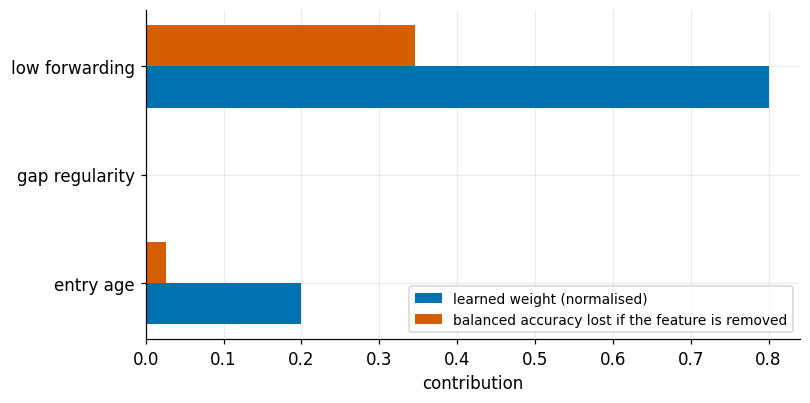

### Model comparison

| detector | Accuracy | Precision | Recall | F1 | FPR | Balanced acc. |
|---|---|---|---|---|---|---|
| fixed-rule baseline (`simple`) | 58.2% ± 0.1% | 0.902 ± 0.002 | 0.305 ± 0.003 | 0.456 ± 0.004 | 4.4% ± 0.1% | 0.631 ± 0.002 |
| evidence, no memory (`score`) | 82.8% ± 0.3% | 0.736 ± 0.005 | 1.000 ± 0.000 | 0.848 ± 0.003 | 33.1% ± 0.2% | 0.834 ± 0.001 |
| LA, hand-set (`la_hand`) | 83.2% ± 0.3% | 0.742 ± 0.005 | 1.000 ± 0.000 | 0.852 ± 0.003 | 32.5% ± 0.3% | 0.838 ± 0.001 |
| LA-DETECT (learned) (`la_detect`) | 92.9% ± 0.1% | 0.866 ± 0.003 | 0.999 ± 0.000 | 0.928 ± 0.002 | 13.2% ± 0.2% | 0.934 ± 0.001 |
| *FloRa (CatBoost), Mudgal et al. 2024 — reported on its own dataset* | 99.49% | -- | -- | -- | 0.01% | -- |
| *GRU–CatBoost, Bahrami & Haj Seyyed Javadi 2026 — reported on its own dataset* | 96.8% ± 0.4% | -- | -- | 0.968 | 1.9% | -- |

*Mean ± 95% CI over 32 seeds, attack A1. The two published rows are context only: they are measured on their own datasets, not on this one.*

### Ablation of the architecture

| variant | w (low, reg, age) | gate | theta | Accuracy | Precision | Recall | F1 | FPR | Balanced acc. | delta |
|---|---|---|---|---|---|---|---|---|---|---|
| full LA-DETECT (learned) | (1, 0, 0.25) | 0.5 | 0.65 | 93.2% | 0.903 | 1.000 | 0.949 | 18.2% | 0.909 | -- |
| without learning (hand-set values) | (0.4, 0.35, 0.15) | 0.2 | 0.5 | 85.0% | 0.808 | 1.000 | 0.894 | 40.4% | 0.798 | -0.111 |
| without memory (gate = 1) | (1, 0, 0.25) | 1 | 0.65 | 92.3% | 0.891 | 1.000 | 0.942 | 20.7% | 0.896 | -0.012 |
| without a learned threshold (0.5) | (1, 0, 0.25) | 0.5 | 0.5 | 88.8% | 0.849 | 1.000 | 0.919 | 30.1% | 0.850 | -0.059 |
| without the forwarding feature | (0, 0, 0.25) | 0.5 | 0.65 | 45.4% | 0.936 | 0.141 | 0.245 | 1.6% | 0.562 | -0.346 |
| without the regularity feature | (1, 0, 0.25) | 0.5 | 0.65 | 93.2% | 0.903 | 1.000 | 0.949 | 18.2% | 0.909 | +0.000 |
| without the age feature | (1, 0, 0) | 0.5 | 0.65 | 91.3% | 0.879 | 1.000 | 0.935 | 23.4% | 0.883 | -0.026 |

*Offline on the validation sequences (unseen seeds, no mitigation), so every row differs only in the component named.*

### Computational cost

| detector | parameters learned | state kept | training | one decision round | per flow |
|---|---|---|---|---|---|
| LA-DETECT (learned) | 5 (3 weights, gate, threshold) | 1 float per live flow (~14 KB at 1800 entries) | 65 s on 2 CPU cores, 8 starts x 6000 rounds | 0.12 ms | 0.10 µs |
| LA, hand-set | 0 (values set by hand) | 1 float per live flow | -- | 0.12 ms | 0.10 µs |
| evidence, no memory | 0 | none | -- | 0.10 ms | 0.09 µs |
| fixed-rule baseline | 0 | none | -- | 0.06 ms | 0.04 µs |
| *GRU of the published detector, for scale* | ~26,688 weights (counted from the two layers of 64 and 32 units over 24 features its paper reports), plus a 500-tree CatBoost | hidden state per sequence | *50 epochs, batch 128, Adam (as reported)* | -- | -- |

--- paired tests over the same seeds (95% t-CI, and Wilcoxon signed-rank) ---
  balanced_acc  la_detect  - la_hand    +0.0963 ± 0.0009   W = 0, p = 4.7e-10
  f1            la_detect  - la_hand    +0.0761 ± 0.0026   W = 0, p = 4.7e-10
  fpr           la_detect  - la_hand    -0.1931 ± 0.0018   W = 0, p = 4.7e-10
  balanced_acc  la_hand    - score      +0.0034 ± 0.0005   W = 0, p = 4.7e-10
  f1            la_hand    - score      +0.0037 ± 0.0004   W = 0, p = 4.7e-10
  fpr           la_hand    - score      -0.0067 ± 0.0009   W = 0, p = 4.7e-10
  balanced_acc  la_detect  - simple     +0.3034 ± 0.0018   W = 0, p = 4.7e-10
  f1            la_detect  - simple     +0.4713 ± 0.0033   W = 0, p = 4.7e-10
  fpr           la_detect  - simple     +0.0873 ± 0.0014   W = 0, p = 4.7e-10
Ten seeds would be enough for the signed-rank test; this runs on all of them.


In [29]:
# --- the tables a detection paper reports, for this detector --------------- #
from scipy.stats import wilcoxon

# 1. model comparison, in the shape the published detectors are reported in --- #
_g = dd.groupby("detector")
_m = lambda d, k: float(_g[k].mean()[d])
_c = lambda d, k: float(_g[k].agg(lambda v: mean_ci95(np.asarray(v, float))[1])[d])
_pm = lambda d, k, pct=False: (f"{_m(d, k):.1%} ± {_c(d, k):.1%}" if pct
                               else f"{_m(d, k):.3f} ± {_c(d, k):.3f}")
comparison = md_table(
    ["detector", "Accuracy", "Precision", "Recall", "F1", "FPR", "Balanced acc."],
    [[f"{DETECTORS[d]} (`{d}`)", _pm(d, "accuracy", True), _pm(d, "precision"), _pm(d, "recall"),
      _pm(d, "f1"), _pm(d, "fpr", True), _pm(d, "balanced_acc")] for d in DETECTORS]
    + [["*FloRa (CatBoost), Mudgal et al. 2024 — reported on its own dataset*",
        "99.49%", "--", "--", "--", "0.01%", "--"],
       ["*GRU–CatBoost, Bahrami & Haj Seyyed Javadi 2026 — reported on its own dataset*",
        "96.8% ± 0.4%", "--", "--", "0.968", "1.9%", "--"]])

# 2. ablation of the architecture, offline on the validation sequences ------- #
_W = (LEARNED["la_w_low"], LEARNED["la_w_reg"], LEARNED["la_w_age"])
_G, _T = LEARNED["la_gate"], LEARNED["la_theta"]
ABLATIONS = {
    "full LA-DETECT (learned)":            (_W, _G, _T),
    "without learning (hand-set values)":  (HAND["weights"], HAND["gate"], HAND["theta"]),
    "without memory (gate = 1)":           (_W, 1.0, _T),
    "without a learned threshold (0.5)":   (_W, _G, 0.5),
    "without the forwarding feature":      ((0.0, _W[1], _W[2]), _G, _T),
    "without the regularity feature":      ((_W[0], 0.0, _W[2]), _G, _T),
    "without the age feature":             ((_W[0], _W[1], 0.0), _G, _T),
}
abl_rows = []
for name, (w, g, th) in ABLATIONS.items():
    m = ({"accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan,
          "fpr": np.nan, "balanced_acc": 0.0} if sum(w) == 0 else
         seq_metrics(Xva, Mva, yva, w, g, th))
    abl_rows.append({"variant": name, "w_low": w[0], "w_reg": w[1], "w_age": w[2],
                     "gate": g, "theta": th, **{k: m[k] for k in
                     ("accuracy", "precision", "recall", "f1", "fpr", "balanced_acc")}})
abl = pd.DataFrame(abl_rows)
abl["d balanced acc"] = abl.balanced_acc - abl.balanced_acc.iloc[0]
def _f(v, pct=False, nd=3):
    if not np.isfinite(v):
        return "--"
    return f"{v:.1%}" if pct else f"{v:.{nd}f}"
ablation = md_table(
    ["variant", "w (low, reg, age)", "gate", "theta", "Accuracy", "Precision", "Recall",
     "F1", "FPR", "Balanced acc.", "delta"],
    [[r["variant"], f"({r['w_low']:g}, {r['w_reg']:g}, {r['w_age']:g})", f"{r['gate']:g}",
      f"{r['theta']:g}", _f(r["accuracy"], True), _f(r["precision"]), _f(r["recall"]),
      _f(r["f1"]), _f(r["fpr"], True), _f(r["balanced_acc"]),
      "--" if i == 0 else f"{r['d balanced acc']:+.3f}"]
     for i, r in abl.iterrows()])

# 3. what each feature contributes ------------------------------------------ #
FEATS = ["low forwarding", "gap regularity", "entry age"]
_wn = np.array(_W) / max(sum(_W), 1e-9)
_drop = [abl.set_index("variant").loc[f"without the {n} feature", "balanced_acc"]
         for n in ("forwarding", "regularity", "age")]
_loss = abl.balanced_acc.iloc[0] - np.array(_drop)
imp = pd.DataFrame({"feature": FEATS, "learned weight (normalised)": _wn,
                    "balanced accuracy lost if removed": _loss})
fig, ax = plt.subplots(figsize=(7.5, 3.8))
yb = np.arange(len(FEATS)); h = 0.38
ax.barh(yb + h / 2, _wn, h, color=CB[0], label="learned weight (normalised)")
ax.barh(yb - h / 2, _loss, h, color=CB[3], label="balanced accuracy lost if the feature is removed")
ax.set_yticks(yb); ax.set_yticklabels(FEATS); ax.invert_yaxis()
ax.set_xlabel("contribution"); ax.legend(fontsize=9)
finish(fig, "fig13_feature_importance",
       "what each observed feature contributes to LA-DETECT: learned weight, and the loss when it is removed")

# 4. computational cost ------------------------------------------------------ #
# The GRU of the published detector, counted from the architecture its paper states
# (two layers of 64 and 32 units over 24 features): 3(n_in*n_h + n_h^2 + 2*n_h) per layer.
_gru = 3 * (24 * 64 + 64 ** 2 + 2 * 64) + 3 * (64 * 32 + 32 ** 2 + 2 * 32)
_state_bytes = 8 * CFG.sim.capacity
cost = md_table(
    ["detector", "parameters learned", "state kept", "training", "one decision round", "per flow"],
    [["LA-DETECT (learned)", f"{len(TEAM_SPACE)} (3 weights, gate, threshold)",
      f"1 float per live flow (~{_state_bytes/1024:.0f} KB at {CFG.sim.capacity} entries)",
      f"{TRAIN_SECONDS:.0f} s on {N_WORKERS} CPU cores, {N_STARTS} starts x {len(team_curve)} rounds",
      f"{_m('la_detect', 'ms_per_epoch'):.2f} ms", f"{_m('la_detect', 'us_per_flow'):.2f} µs"],
     ["LA, hand-set", "0 (values set by hand)", "1 float per live flow", "--",
      f"{_m('la_hand', 'ms_per_epoch'):.2f} ms", f"{_m('la_hand', 'us_per_flow'):.2f} µs"],
     ["evidence, no memory", "0", "none", "--",
      f"{_m('score', 'ms_per_epoch'):.2f} ms", f"{_m('score', 'us_per_flow'):.2f} µs"],
     ["fixed-rule baseline", "0", "none", "--",
      f"{_m('simple', 'ms_per_epoch'):.2f} ms", f"{_m('simple', 'us_per_flow'):.2f} µs"],
     [f"*GRU of the published detector, for scale*", f"~{_gru:,} weights (counted from the "
      "two layers of 64 and 32 units over 24 features its paper reports), plus a 500-tree CatBoost",
      "hidden state per sequence", "*50 epochs, batch 128, Adam (as reported)*", "--", "--"]])

display(Markdown("\n".join([
    "### Model comparison", "", comparison, "",
    f"*Mean ± 95% CI over {len(SEEDS)} seeds, attack A1. The two published rows are context only: "
    "they are measured on their own datasets, not on this one.*", "",
    "### Ablation of the architecture", "", ablation, "",
    "*Offline on the validation sequences (unseen seeds, no mitigation), so every row differs "
    "only in the component named.*", "",
    "### Computational cost", "", cost])))

# 5. the same comparisons as signed-rank tests, seed by seed ------------------ #
print("--- paired tests over the same seeds (95% t-CI, and Wilcoxon signed-rank) ---")
_v = lambda d, k: dd[dd.detector == d].sort_values("seed")[k].values
for a, b in [("la_detect", "la_hand"), ("la_hand", "score"), ("la_detect", "simple")]:
    for k in ("balanced_acc", "f1", "fpr"):
        mdiff, ci = paired(_v(a, k), _v(b, k))
        try:
            st, pv = wilcoxon(_v(a, k), _v(b, k))
            w = f"W = {st:.0f}, p = {pv:.2g}"
        except ValueError as exc:                 # all differences identical
            w = f"not applicable ({exc})"
        print(f"  {k:13s} {a:10s} - {b:10s} {mdiff:+.4f} ± {ci:.4f}   {w}")
print("Ten seeds would be enough for the signed-rank test; this runs on all of them.")


In [30]:
# Reading the result -- written from the numbers above
_A = abl.set_index("variant")
_full = _A.loc["full LA-DETECT (learned)"]
_worst = _A["d balanced acc"].idxmin()
_zero = [f for f, w in zip(FEATS, _W) if w == 0]
_used = [f for f, w in zip(FEATS, _W) if w > 0]
_top = FEATS[int(np.argmax(_loss))]
_ms = _m("la_detect", "ms_per_epoch")
_agree = _ntest = 0
for _a, _b in [("la_detect", "la_hand"), ("la_hand", "score"), ("la_detect", "simple")]:
    for _k in ("balanced_acc", "f1", "fpr"):
        _md, _ci = paired(_v(_a, _k), _v(_b, _k))
        try:
            _p = wilcoxon(_v(_a, _k), _v(_b, _k))[1]
        except ValueError:
            continue
        _ntest += 1
        _agree += int((abs(_md) > _ci) == (_p < 0.05))
say(
    f"**Ablation.** Taking any one component out of the architecture costs balanced accuracy, "
    f"and the component that costs the most is *{_worst.replace('without ', '')}* "
    f"({_A.loc[_worst, 'd balanced acc']:+.3f}). "
    + (f"Removing the memory (gate = 1) changes it by "
       f"{_A.loc['without memory (gate = 1)', 'd balanced acc']:+.3f}, and using the hand-set "
       f"values instead of the learned ones by "
       f"{_A.loc['without learning (hand-set values)', 'd balanced acc']:+.3f}: the learning is "
       "what the architecture depends on."),
    f"**What the features contribute.** The team gave its weight to "
    + ", ".join(f"{f} ({w:g})" for f, w in zip(FEATS, _W) if w > 0) + ". "
    + (f"It set the weight of {' and '.join(_zero)} to zero, so removing "
       f"{'them' if len(_zero) > 1 else 'it'} changes nothing: with this telemetry, "
       f"{' and '.join(_zero)} carries no information the other features do not already carry. "
       if _zero else "Every feature carries weight. ")
    + f"The feature whose removal costs the most is {_top} ({_loss[int(np.argmax(_loss))]:+.3f} "
    "balanced accuracy), which is also what the published detectors report as their strongest "
    "signal: a rule that exists yet forwards almost nothing.",
    f"**Cost.** LA-DETECT is {len(TEAM_SPACE)} learned numbers plus one float per live flow. It "
    f"classifies the whole table in {_ms:.2f} ms, about "
    f"{_m('la_detect', 'us_per_flow'):.2f} µs per flow, on one CPU core and with no GPU. For "
    f"scale, the GRU of the published detector carries about {_gru:,} weights (counted from the "
    "architecture its paper reports) and a 500-tree gradient-boosted classifier on top, trained "
    "for 50 epochs. That is the trade this work is making: a far smaller model in the same "
    "position, at some cost in accuracy on a deliberately harder classification task.",
    (f"**Signed-rank tests.** The two procedures agree on all {_ntest} comparisons printed "
     "above: where the confidence interval excludes zero, the signed-rank test also rejects at "
     "p < 0.05. Both are reported because they assume different things -- the interval assumes "
     "a roughly symmetric error, the signed-rank test does not."
     if _agree == _ntest else
     f"**Signed-rank tests.** The two procedures agree on {_agree} of the {_ntest} comparisons "
     f"printed above. With {len(SEEDS)} seeds the smallest p value the signed-rank test can "
     f"produce is {2.0 ** (1 - len(SEEDS)):.3g}, so at this scale it cannot reject even when "
     "every seed moves the same way; the confidence interval is the informative one here. Run "
     "the notebook at `SCALE = \"full\"` and both agree."),
)


**Ablation.** Taking any one component out of the architecture costs balanced accuracy, and the component that costs the most is *the forwarding feature* (-0.346). Removing the memory (gate = 1) changes it by -0.012, and using the hand-set values instead of the learned ones by -0.111: the learning is what the architecture depends on.

**What the features contribute.** The team gave its weight to low forwarding (1), entry age (0.25). It set the weight of gap regularity to zero, so removing it changes nothing: with this telemetry, gap regularity carries no information the other features do not already carry. The feature whose removal costs the most is low forwarding (+0.346 balanced accuracy), which is also what the published detectors report as their strongest signal: a rule that exists yet forwards almost nothing.

**Cost.** LA-DETECT is 5 learned numbers plus one float per live flow. It classifies the whole table in 0.12 ms, about 0.10 µs per flow, on one CPU core and with no GPU. For scale, the GRU of the published detector carries about 26,688 weights (counted from the architecture its paper reports) and a 500-tree gradient-boosted classifier on top, trained for 50 epochs. That is the trade this work is making: a far smaller model in the same position, at some cost in accuracy on a deliberately harder classification task.

**Signed-rank tests.** The two procedures agree on all 9 comparisons printed above: where the confidence interval excludes zero, the signed-rank test also rejects at p < 0.05. Both are reported because they assume different things -- the interval assumes a roughly symmetric error, the signed-rank test does not.

## 21. What the attack looks like


The clearest single picture of the whole problem, and the one to put on a slide:
table occupancy over time, split into the attacker's share, the benign share and
free space, undefended versus defended at the same attack rate.


[figures/fig14_occupancy_undefended.png]  flow-table occupancy over time, undefended (T0 fixed, no mitigation), attack A1


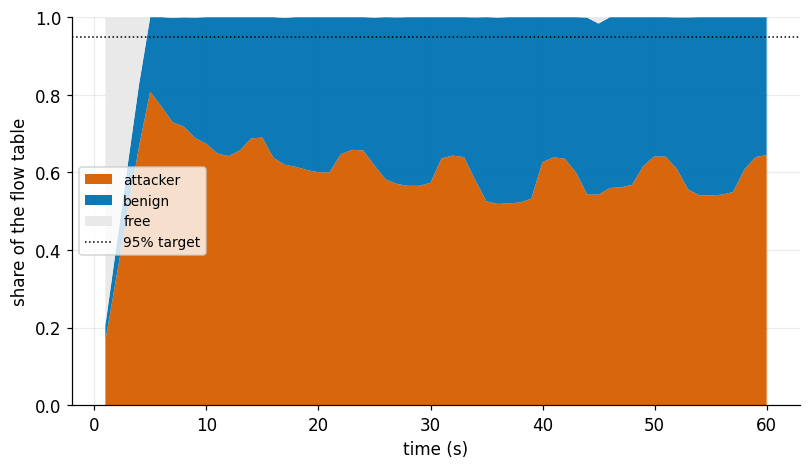

[figures/fig15_occupancy_defended.png]  flow-table occupancy over time, full defence (T3 + H2 + LA-DETECT), attack A1


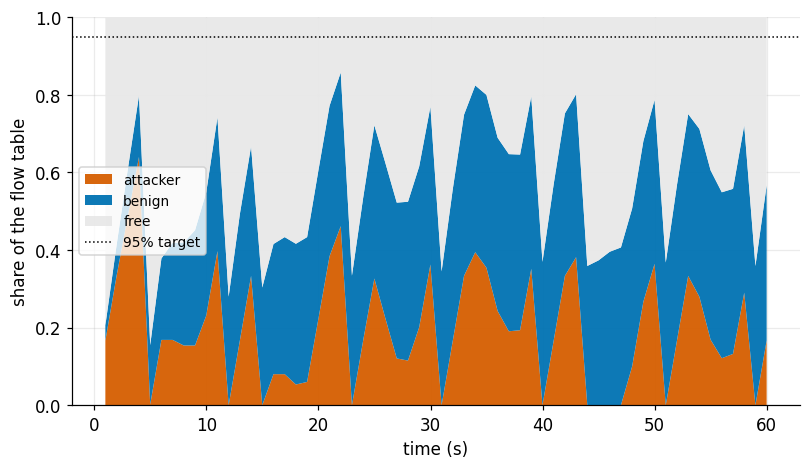

In [31]:
pics = {}
for key, name, what, over in [
    ("undefended", "fig14_occupancy_undefended",
     "flow-table occupancy over time, undefended (T0 fixed, no mitigation), attack A1",
     {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
      "detection": {"detector": "none"}}),
    ("defended", "fig15_occupancy_defended",
     "flow-table occupancy over time, full defence (T3 + H2 + LA-DETECT), attack A1",
     {"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
      "detection": {"detector": "la_detect"}})]:
    r = run_config(CFGS.merged(over).merged(
        {"attacker": {"kind": "A1", "rate_pps": 300,
                      "target_entries": CFG.sim.capacity}}), 12345)
    pics[key] = r
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    ax.stackplot(r.t, r.occ_attack, r.occ_benign, r.occ_free,
                 labels=["attacker", "benign", "free"],
                 colors=[CB[3], CB[0], "#e8e8e8"], alpha=0.95)
    ax.axhline(0.95, ls=":", color="black", lw=1, label="95% target")
    ax.set_xlabel("time (s)"); ax.set_ylabel("share of the flow table"); ax.set_ylim(0, 1)
    ax.legend(loc="center left", fontsize=9)
    finish(fig, name, what)


In [32]:
# Reading the result -- written from the numbers above
def _summ(r, t_from=10.0):
    t = np.array(r.t); k = t >= t_from
    return {"atk": np.mean(np.array(r.occ_attack)[k]), "ben": np.mean(np.array(r.occ_benign)[k]),
            "free": np.mean(np.array(r.occ_free)[k]), "occ_max": max(r.occ),
            "full": np.mean(np.array(r.occ)[k] >= 0.95)}
U, D = _summ(pics["undefended"]), _summ(pics["defended"])

say(
    f"**What this shows.** Undefended, the attacker holds on average {U['atk']:.0%} of the "
    f"table after the first 10 s and free space is {U['free']:.0%}; the table is at or above "
    f"95% in {U['full']:.0%} of the epochs. "
    + ("That is the denial of service: new benign flows find no free entry and every packet "
       "of theirs goes to the controller." if U["full"] > 0.5 else
       "At this rate the undefended table is not held full, so this seed understates the attack."),
    f"Under the full defence, at the same attack rate, the attacker's share averages "
    f"{D['atk']:.0%} and free space averages {D['free']:.0%}, so new benign flows can still "
    f"get an entry. The table is at or above 95% in {D['full']:.0%} of the epochs (peak "
    f"{D['occ_max']:.0%}). The saw-tooth is the mechanism at work: the attacker builds up, "
    "occupancy crosses the (moving) threshold, and the detector's flagged entries are purged.",
    "This is one seed at one attack rate, chosen to illustrate the mechanism; the effect "
    "sizes, with error bars, are in §17, §18 and Appendix B.",
)


**What this shows.** Undefended, the attacker holds on average 60% of the table after the first 10 s and free space is 0%; the table is at or above 95% in 100% of the epochs. That is the denial of service: new benign flows find no free entry and every packet of theirs goes to the controller.

Under the full defence, at the same attack rate, the attacker's share averages 19% and free space averages 42%, so new benign flows can still get an entry. The table is at or above 95% in 0% of the epochs (peak 96%). The saw-tooth is the mechanism at work: the attacker builds up, occupancy crosses the (moving) threshold, and the detector's flagged entries are purged.

This is one seed at one attack rate, chosen to illustrate the mechanism; the effect sizes, with error bars, are in §17, §18 and Appendix B.

## 22. Mechanism 2 on its own — threshold inference and the mechanism comparison


Everything so far varied the timeout. Mechanism 2 mutates the **occupancy
threshold** that triggers mitigation, and it has to be tested against the
attacker it was designed for.

That is attacker **A2**, which ramps up slowly, detects when mitigation starts,
and parks just below the threshold. Against A1 — which ignores the threshold
entirely — mutating it can only add cost, so any H0/H1/H2 comparison run against A1
measures noise on that axis by construction. This is the cell where
mechanism 2 gets a fair test.

Two metrics, because `min_attack_rate` is the wrong one for A2: A2 is not trying
to reach 95% occupancy, it is trying to sit just under the threshold
indefinitely. So this reports **how accurately A2 recovers the threshold** and
**the occupancy it sustains**, which is what A2 is actually optimising.


--- A2 trying to recover the occupancy threshold (true H0 value = 0.8) ---
                  inferred  rel_error  sustained_occ  benign_evict_rate
threshold_policy                                                       
H0                   0.830      0.044          0.763              0.133
H1                   0.808      0.045          0.744              0.129
H2                   0.811      0.051          0.746              0.123



--- mechanism comparison: sustained occupancy (LOWER = defence holding) ---
attacker            A1     A2
mechanism                    
M1 only (T3,H0)  0.809  0.752
M2 only (T0,H2)  0.848  0.746
both (T3,H2)     0.801  0.715
neither (T0,H0)  0.852  0.763


[figures/fig16_threshold_inference_error.png]  error of attacker A2 in locating the mitigation threshold, per threshold policy


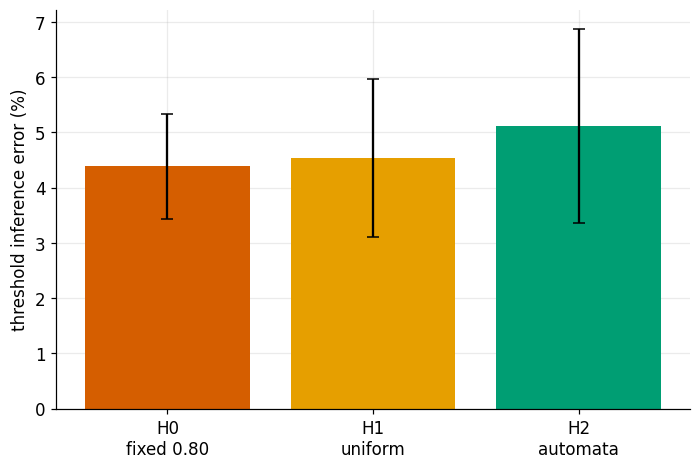

[figures/fig17_mechanism_comparison.png]  sustained occupancy with M1 alone, M2 alone and both, against A1 and A2


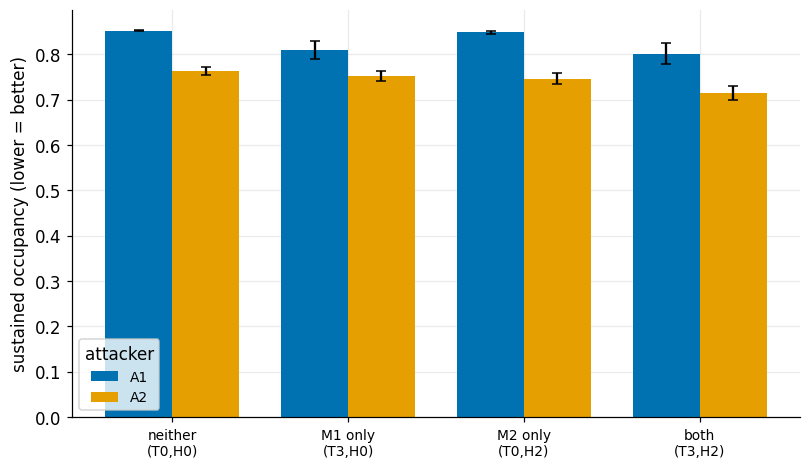

In [33]:
TRUE_THR = CFG.threshold.fixed          # 0.80, the H0 value A2 hunts for
rows = []
for hp in ("H0", "H1", "H2"):
    hp_cfg = CFGS.merged({"threshold": {"policy": hp}, "timeout": {"policy": "T0"},
                          "detection": {"detector": "simple"},
                          "attacker": {"kind": "A2", "rate_pps": 300,
                                       "target_entries": CFG.sim.capacity}})
    for s, r in zip(SEEDS, pmap(run_config, [(hp_cfg, int(s)) for s in SEEDS])):
        err = (abs(r.inferred_threshold - TRUE_THR) / TRUE_THR
               if np.isfinite(r.inferred_threshold) else np.nan)
        rows.append({"threshold_policy": hp, "seed": int(s),
                     "inferred": r.inferred_threshold, "rel_error": err,
                     "sustained_occ": r.mean_occ, "peak_occ": r.peak_occ,
                     "benign_evict_rate": r.benign_eviction_rate})
thr_df = pd.DataFrame(rows)
print("--- A2 trying to recover the occupancy threshold (true H0 value = "
      f"{TRUE_THR}) ---")
print(thr_df.groupby("threshold_policy")[
      ["inferred", "rel_error", "sustained_occ", "benign_evict_rate"]]
      .mean().round(3).to_string())

# --- mechanism comparison: M1 alone, M2 alone, both, against BOTH attackers ---
MECH = {"neither (T0,H0)":  {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"}},
        "M1 only (T3,H0)":  {"timeout": {"policy": "T3"}, "threshold": {"policy": "H0"}},
        "M2 only (T0,H2)":  {"timeout": {"policy": "T0"}, "threshold": {"policy": "H2"}},
        "both (T3,H2)":     {"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"}}}
mech_rows = []
for name, over in MECH.items():
    for atk in ("A1", "A2"):
        m_cfg = CFGS.merged(over).merged({"detection": {"detector": "simple"},
                                          "attacker": {"kind": atk, "rate_pps": 300,
                                                       "target_entries": CFG.sim.capacity}})
        rs = pmap(run_config, [(m_cfg, int(s)) for s in SEEDS])
        m, ci = mean_ci95(np.array([r.mean_occ for r in rs]))
        mech_rows.append({"mechanism": name, "attacker": atk,
                          "sustained_occ": m, "ci95": ci,
                          "benign_evict": float(np.mean(
                              [r.benign_eviction_rate for r in rs]))})
mech_df = pd.DataFrame(mech_rows)
print("\n--- mechanism comparison: sustained occupancy (LOWER = defence holding) ---")
print(mech_df.pivot_table(index="mechanism", columns="attacker",
                          values="sustained_occ").round(3).to_string())

hp = ["H0", "H1", "H2"]
m = [thr_df[thr_df.threshold_policy == h]["rel_error"].mean() * 100 for h in hp]
e = [mean_ci95(thr_df[thr_df.threshold_policy == h]["rel_error"].values)[1] * 100
     for h in hp]
fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.bar(range(3), m, yerr=[np.minimum(m, e), e], capsize=4, color=[CB[3], CB[1], CB[2]])
ax.set_xticks(range(3))
ax.set_xticklabels(["H0\nfixed 0.80", "H1\nuniform", "H2\nautomata"])
ax.set_ylabel("threshold inference error (%)")
finish(fig, "fig16_threshold_inference_error",
       "error of attacker A2 in locating the mitigation threshold, per threshold policy")

names = list(MECH.keys()); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for i, atk in enumerate(["A1", "A2"]):
    d = mech_df[mech_df.attacker == atk]
    vals = [d[d.mechanism == n]["sustained_occ"].iloc[0] for n in names]
    errs = [d[d.mechanism == n]["ci95"].iloc[0] for n in names]
    ax.bar(np.arange(len(names)) + (i-0.5)*w, vals, w, yerr=errs, capsize=3,
           label=atk, color=CB[i])
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=9)
ax.set_ylabel("sustained occupancy (lower = better)")
ax.legend(fontsize=9, title="attacker")
finish(fig, "fig17_mechanism_comparison",
       "sustained occupancy with M1 alone, M2 alone and both, against A1 and A2")


In [34]:
# Reading the result -- written from the numbers above
te = {h: mean_ci95(thr_df[thr_df.threshold_policy == h]["rel_error"].values) for h in ("H0", "H1", "H2")}
inf_mean = thr_df.groupby("threshold_policy")["inferred"].mean()
hidden = all((te[h][0] - te[h][1]) > (te["H0"][0] + te["H0"][1]) for h in ("H1", "H2"))
M = mech_df.set_index(["mechanism", "attacker"])
def _best(atk):
    d = mech_df[mech_df.attacker == atk].set_index("mechanism")
    b = d.sustained_occ.idxmin(); n = "neither (T0,H0)"
    return b, d.loc[b], d.loc[n], overlaps(d.loc[b].sustained_occ, d.loc[b].ci95,
                                           d.loc[n].sustained_occ, d.loc[n].ci95)
b1, v1, n1, ov1 = _best("A1"); b2, v2, n2, ov2 = _best("A2")

say(
    f"**Can A2 still find the threshold? (`fig16`)** Its error is {te['H0'][0]:.1%} against "
    f"the fixed threshold, {te['H1'][0]:.1%} against H1 and {te['H2'][0]:.1%} against H2. "
    + ("Mutation makes the threshold measurably harder to find."
       if hidden else
       f"Mutation does not hide it: under H1/H2, A2 lands on about {inf_mean['H1']:.2f} — the "
       "centre of the range the threshold moves in — which is all it needs to park below it "
       "most of the time."),
    f"**M1 alone, M2 alone, both (`fig17`; sustained occupancy, lower is better).** "
    f"Against A1 the lowest is {b1} at {v1.sustained_occ:.3f} versus {n1.sustained_occ:.3f} for "
    f"neither{' — within the error bars' if ov1 else ''}; against A2 it is {b2} at "
    f"{v2.sustained_occ:.3f} versus {n2.sustained_occ:.3f}"
    f"{' — within the error bars' if ov2 else ''}. "
    f"Threshold mutation alone (M2) gives {M.loc[('M2 only (T0,H2)', 'A1'), 'sustained_occ']:.3f} "
    f"against A1 and {M.loc[('M2 only (T0,H2)', 'A2'), 'sustained_occ']:.3f} against A2.",
    "The answer to RQ1 is therefore conditional: mechanism 2 can only matter against an "
    "attacker that hunts the threshold (A2), never against A1, which ignores it"
    + (", and at this scale even against A2 the effect is within the error bars."
       if ov2 or b2 not in ("M2 only (T0,H2)", "both (T3,H2)") else "."),
)


**Can A2 still find the threshold? (`fig16`)** Its error is 4.4% against the fixed threshold, 4.5% against H1 and 5.1% against H2. Mutation does not hide it: under H1/H2, A2 lands on about 0.81 — the centre of the range the threshold moves in — which is all it needs to park below it most of the time.

**M1 alone, M2 alone, both (`fig17`; sustained occupancy, lower is better).** Against A1 the lowest is both (T3,H2) at 0.801 versus 0.852 for neither; against A2 it is both (T3,H2) at 0.715 versus 0.763. Threshold mutation alone (M2) gives 0.848 against A1 and 0.746 against A2.

The answer to RQ1 is therefore conditional: mechanism 2 can only matter against an attacker that hunts the threshold (A2), never against A1, which ignores it.

## 23. Where the defence fails — adaptive attackers A1 to A4


A study that reports only its successes is less trustworthy than one that maps
its own limits. This cell puts all four attacker models against the best
defence and reports what each achieves.

**Check the A1/A3 and A2/A4 rows against each other.** A3's counter-MTD logic
shortens its refresh interval online, but it needs several rounds to engage; if
the horizon is too short it never does, and A3 becomes an expensive copy of A1.
The cell prints the pairwise differences explicitly so this cannot hide. If they
are identical, then this notebook has *two* attacker models, not four, and no
claim about adaptive adversaries is supported.


--- all four attackers against the best defence ---
attacker  sustained_occ  sust_ci  peak_occ  benign_evict
      A1         0.6177   0.0150    0.9566        0.1212
      A2         0.6316   0.0158    0.8422        0.1320
      A3         0.6785   0.0071    0.9873        0.1168
      A4         0.6878   0.0075    0.8525        0.1313

--- LA-DETECT under each attacker (confusion counts pooled over seeds) ---
attacker  accuracy  precision  recall  specificity   fpr    f1  balanced_acc   mcc  latency_s
      A1     0.912      0.820   0.999        0.853 0.147 0.901         0.926 0.836      0.506
      A2     0.906      0.813   1.000        0.841 0.159 0.896         0.920 0.826      0.591
      A3     0.931      0.872   0.999        0.871 0.129 0.931         0.935 0.871      0.506
      A4     0.918      0.850   1.000        0.849 0.151 0.919         0.924 0.849      0.591

--- are the adaptive variants actually distinct? ---
  A3 vs A1: |d sustained occupancy| = 0.060819  -> distinct
  A

[figures/fig18_adaptive_attackers.png]  sustained and peak occupancy for attackers A1-A4 against the full defence


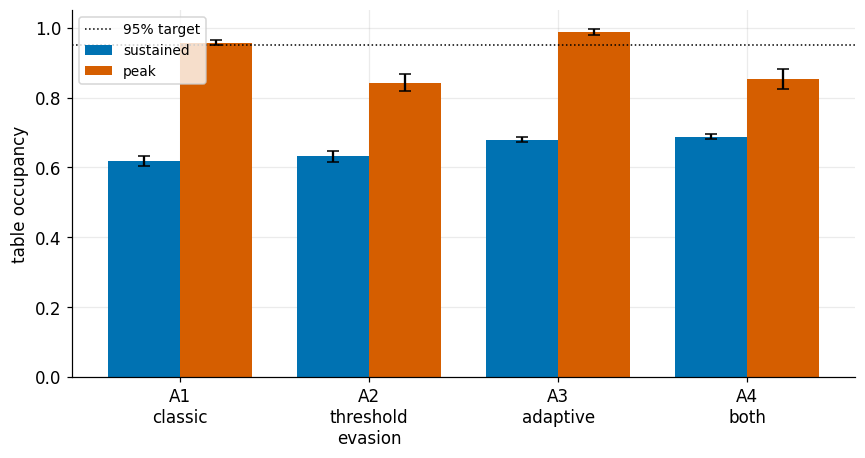

In [35]:
BEST = {"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
        "detection": {"detector": "la_detect"}}
rows = []
for atk in ("A1", "A2", "A3", "A4"):
    a_cfg = CFGS.merged(BEST).merged({"attacker": {"kind": atk, "rate_pps": 300,
                                                   "target_entries": CFG.sim.capacity}})
    rs = pmap(run_config, [(a_cfg, int(s)) for s in SEEDS])
    mo, ci = mean_ci95(np.array([r.mean_occ for r in rs]))
    po, pci = mean_ci95(np.array([r.peak_occ for r in rs]))
    rows.append({"attacker": atk, "sustained_occ": mo, "sust_ci": ci,
                 "peak_occ": po, "peak_ci": pci,
                 "f1": float(np.nanmean([r.f1 for r in rs])),
                 "accuracy": float(np.nanmean([r.accuracy for r in rs])),
                 "acc_ci": float(mean_ci95(np.array([r.accuracy for r in rs]))[1]),
                 # every detection metric, from the confusion counts pooled over seeds
                 **{f"pooled_{k}": v for k, v in detection_metrics(
                     sum(r.tp for r in rs), sum(r.fp for r in rs),
                     sum(r.fn for r in rs), sum(r.tn for r in rs)).items()},
                 "latency_s": float(np.nanmean([r.detect_latency for r in rs])),
                 "benign_evict": float(np.mean([r.benign_eviction_rate for r in rs]))})
adv = pd.DataFrame(rows)
print("--- all four attackers against the best defence ---")
print(adv[["attacker", "sustained_occ", "sust_ci", "peak_occ", "benign_evict"]]
      .round(4).to_string(index=False))
print("\n--- LA-DETECT under each attacker (confusion counts pooled over seeds) ---")
print(adv[["attacker"] + [c for c in adv.columns if c.startswith("pooled_")] + ["latency_s"]]
      .rename(columns=lambda c: c.replace("pooled_", "")).round(3).to_string(index=False))

print("\n--- are the adaptive variants actually distinct? ---")
for a, b in (("A1", "A3"), ("A2", "A4")):
    x = adv[adv.attacker == a].iloc[0]; y = adv[adv.attacker == b].iloc[0]
    d = abs(x.sustained_occ - y.sustained_occ)
    same = d < 1e-6
    print(f"  {b} vs {a}: |d sustained occupancy| = {d:.6f}  "
          f"-> {'IDENTICAL: the adaptive logic never engaged' if same else 'distinct'}")
if abs(adv[adv.attacker=='A1'].iloc[0].sustained_occ
       - adv[adv.attacker=='A3'].iloc[0].sustained_occ) < 1e-6:
    print("\n  NOTE: raise sweep_horizon_s or lower attacker.adaptive_rounds so A3/A4")
    print("  reach their adaptive phase, or report only A1 and A2 and say why.")

fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(4); w = 0.38
ax.bar(x - w/2, adv.sustained_occ, w, yerr=adv.sust_ci, capsize=4,
       label="sustained", color=CB[0])
ax.bar(x + w/2, adv.peak_occ, w, yerr=adv.peak_ci, capsize=4,
       label="peak", color=CB[3])
ax.axhline(0.95, ls=":", color="black", lw=1, label="95% target")
ax.set_xticks(x); ax.set_xticklabels(
    ["A1\nclassic", "A2\nthreshold\nevasion", "A3\nadaptive", "A4\nboth"])
ax.set_ylabel("table occupancy"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
finish(fig, "fig18_adaptive_attackers",
       "sustained and peak occupancy for attackers A1-A4 against the full defence")


In [36]:
# Reading the result -- written from the numbers above
A = adv.set_index("attacker")
worst = A.sustained_occ.idxmax()
over95 = [a for a in A.index if A.loc[a, "peak_occ"] >= 0.95]
d31 = A.loc["A3", "sustained_occ"] - A.loc["A1", "sustained_occ"]
d42 = A.loc["A4", "sustained_occ"] - A.loc["A2", "sustained_occ"]
distinct31 = not overlaps(A.loc["A3", "sustained_occ"], A.loc["A3", "sust_ci"],
                          A.loc["A1", "sustained_occ"], A.loc["A1", "sust_ci"])
acc_rng = A.pooled_accuracy.max() - A.pooled_accuracy.min()
say(
    f"**Where the defence is weakest.** Against the full defence (T3 + H2 + LA-DETECT), the "
    f"attacker that holds the most of the table is {worst}, at {A.loc[worst, 'sustained_occ']:.3f} "
    f"sustained occupancy. "
    + (f"{', '.join(over95)} still reach{'es' if len(over95) == 1 else ''} 95% at some moment "
       "(peak), so the defence slows the attack rather than preventing every overflow."
       if over95 else "No attacker reaches 95% even momentarily."),
    f"The adaptive attacker A3, which shortens its refresh interval online when it starts "
    f"missing, holds {d31:+.3f} of the table relative to the classic A1"
    + (" (beyond the error bars)" if distinct31 else " (within the error bars)")
    + f"; A4 holds {d42:+.3f} relative to A2.",
    "**Detection under attackers it was never trained on.** LA-DETECT was trained only on "
    "A1 (§14). Its accuracy here is "
    + ", ".join(f"{a} {A.loc[a, 'pooled_accuracy']:.1%}" for a in A.index)
    + "; its F1 is " + ", ".join(f"{a} {A.loc[a, 'pooled_f1']:.3f}" for a in A.index)
    + "; its false-positive rate is " + ", ".join(f"{a} {A.loc[a, 'pooled_fpr']:.1%}" for a in A.index)
    + ". "
    + ("The learned detector generalises: accuracy varies by only "
       f"{acc_rng:.1%} across the four attackers. A shorter refresh interval does not buy "
       "evasion, because the attacker's packet budget is spread over every entry it holds, "
       "so each entry still forwards almost nothing."
       if acc_rng < 0.05 else
       f"Accuracy varies by {acc_rng:.1%} across attackers, so the detector does not "
       "fully generalise beyond the attacker it was trained on."),
    (("The adaptive logic engages at this horizon (A3/A4 do not reproduce A1/A2's numbers)"
      + (", and A3's gain over A1 is beyond the error bars." if distinct31 else
         ", though with this many seeds A3's gain over A1 is within the error bars."))
     if abs(d31) > 1e-6 and abs(d42) > 1e-6 else
     "A3/A4 are identical to A1/A2 at this horizon: no claim about adaptive attackers is supported."),
)


**Where the defence is weakest.** Against the full defence (T3 + H2 + LA-DETECT), the attacker that holds the most of the table is A4, at 0.688 sustained occupancy. A1, A3 still reach 95% at some moment (peak), so the defence slows the attack rather than preventing every overflow.

The adaptive attacker A3, which shortens its refresh interval online when it starts missing, holds +0.061 of the table relative to the classic A1 (beyond the error bars); A4 holds +0.056 relative to A2.

**Detection under attackers it was never trained on.** LA-DETECT was trained only on A1 (§14). Its accuracy here is A1 91.2%, A2 90.6%, A3 93.1%, A4 91.8%; its F1 is A1 0.901, A2 0.896, A3 0.931, A4 0.919; its false-positive rate is A1 14.7%, A2 15.9%, A3 12.9%, A4 15.1%. The learned detector generalises: accuracy varies by only 2.5% across the four attackers. A shorter refresh interval does not buy evasion, because the attacker's packet budget is spread over every entry it holds, so each entry still forwards almost nothing.

The adaptive logic engages at this horizon (A3/A4 do not reproduce A1/A2's numbers), and A3's gain over A1 is beyond the error bars.

## 24. Sensitivity — how much does the result depend on the assumptions?


The question every examiner asks, and the one a parameter study must answer. Each
parameter is swept while everything else is held fixed, and the headline metric
is re-measured.

This is also where the configuration choices of §2 get justified empirically
rather than by argument. Watch `capacity` in particular: if the metric moves
steeply with it, then every absolute number in the study depends on using the
cited figure (1800 entries, Cao et al.) rather than a convenient one.

One reading note: a value of exactly 40 pps with a zero interval is the bottom of
the rate grid, not a measurement. It means even the slowest attack tested filled
the table — at 140 and 280 benign flows per second, benign traffic alone nearly
fills it (Little's law), so those points say nothing about the defence.


         parameter   value  min_attack_rate  ci95
          capacity  600.00            40.00  0.00
          capacity 1200.00            88.85  1.31
          capacity 1800.00           268.89  6.29
          capacity 3000.00           480.74  8.97
benign arrival_fps   35.00           302.90  7.12
benign arrival_fps   70.00           268.89  6.29
benign arrival_fps  140.00            40.00  0.00
benign arrival_fps  280.00            40.00  0.00
  benign idle_frac    0.00           235.38  9.63
  benign idle_frac    0.10           254.76  7.68
  benign idle_frac    0.20           268.89  6.29
  benign idle_frac    0.40           280.99  5.08
         LA rate a    0.02           276.23  5.00
         LA rate a    0.08           268.89  6.29
         LA rate a    0.20           268.52  6.36
entropy floor frac    0.30           267.34  6.68
entropy floor frac    0.55           268.89  6.29
entropy floor frac    0.85           275.57  5.01
[figures/fig19_sensitivity_capacity.png]  sensitiv

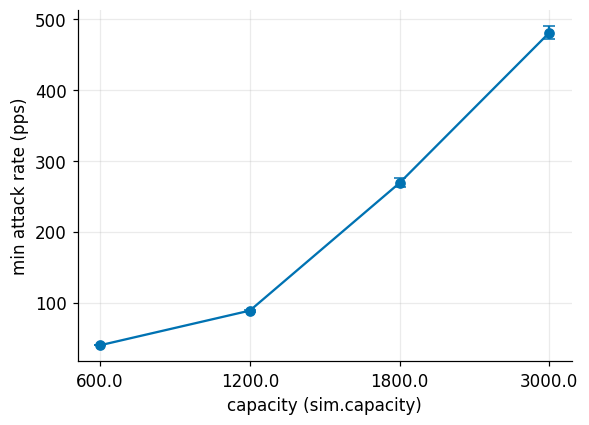

[figures/fig20_sensitivity_arrival_fps.png]  sensitivity of the min attack rate to benign arrival_fps


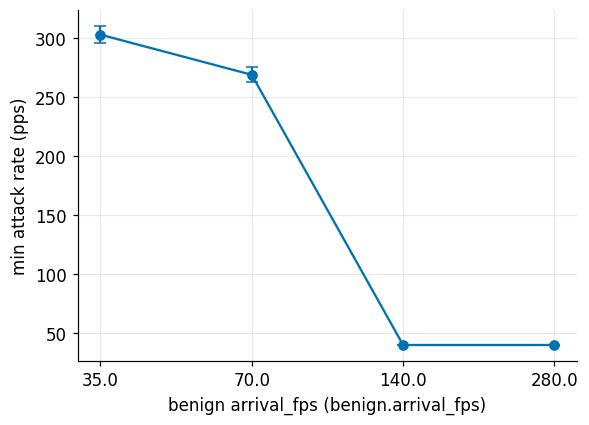

[figures/fig21_sensitivity_idle_frac.png]  sensitivity of the min attack rate to benign idle_frac


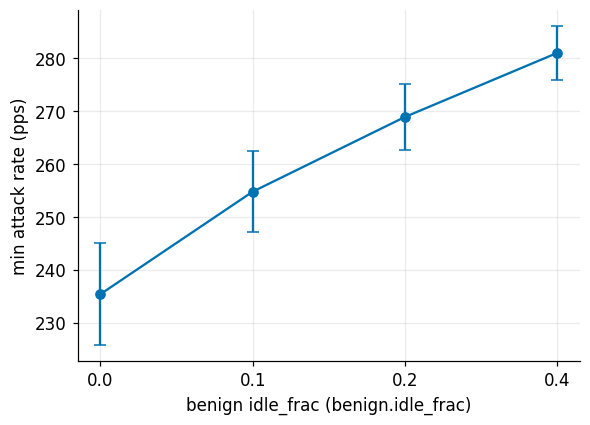

[figures/fig22_sensitivity_a.png]  sensitivity of the min attack rate to LA rate a


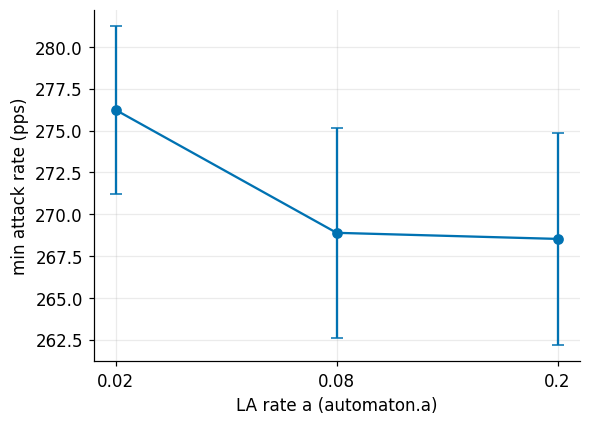

[figures/fig23_sensitivity_h_min_frac.png]  sensitivity of the min attack rate to entropy floor frac


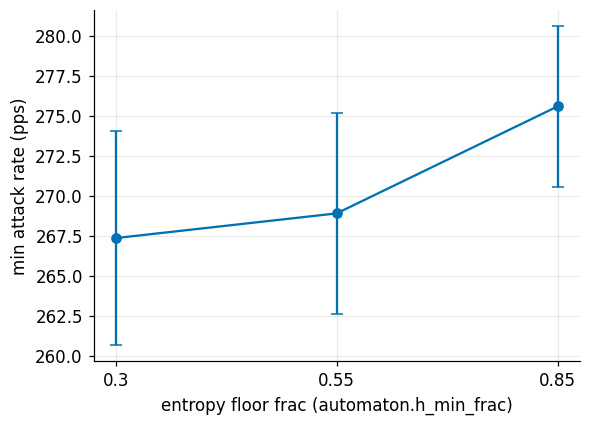


Spread of the headline metric caused by each parameter (max - min across its sweep):
  capacity                  440.7 pps
  benign arrival_fps        262.9 pps
  benign idle_frac           45.6 pps
  LA rate a                   7.7 pps
  entropy floor frac          8.2 pps

The parameter with the largest spread is the one your conclusions are
most hostage to, and the one whose value most needs a citation.


In [37]:
SWEEPS = {
  "capacity":            ("sim",       "capacity",      [600, 1200, 1800, 3000]),
  "benign arrival_fps":  ("benign",    "arrival_fps",   [35.0, 70.0, 140.0, 280.0]),
  "benign idle_frac":    ("benign",    "idle_frac",     [0.0, 0.10, 0.20, 0.40]),
  "LA rate a":           ("automaton", "a",             [0.02, 0.08, 0.20]),
  "entropy floor frac":  ("automaton", "h_min_frac",    [0.30, 0.55, 0.85]),
}
base_over = {"timeout": {"policy": "T3"}, "threshold": {"policy": "H0"},
             "detection": {"detector": "simple"},
             "attacker": {"kind": "A1", "target_entries": CFG.sim.capacity}}
rows = []
for label, (grp, key, vals) in SWEEPS.items():
    for v in vals:
        c = CFGS.merged({grp: {key: v}})
        over = dict(base_over)
        if grp == "sim" and key == "capacity":
            over = {**base_over, "attacker": {"kind": "A1", "target_entries": v}}
        mins = [m for m, _ in pmap(min_attack_rate, [(over, int(s), c) for s in SEEDS])]
        m, ci = mean_ci95(np.array(mins))
        rows.append({"parameter": label, "value": v, "min_attack_rate": m, "ci95": ci})
sens = pd.DataFrame(rows)
print(sens.round(2).to_string(index=False))

for j, (label, (grp, key, vals)) in enumerate(SWEEPS.items()):
    d = sens[sens.parameter == label]
    fig, ax = plt.subplots(figsize=(5.5, 4.0))
    ax.errorbar(range(len(d)), d.min_attack_rate, yerr=d.ci95,
                marker="o", capsize=4, color=CB[0])
    ax.set_xticks(range(len(d))); ax.set_xticklabels([str(v) for v in d.value])
    ax.set_xlabel(f"{label} ({grp}.{key})"); ax.set_ylabel("min attack rate (pps)")
    finish(fig, f"fig{19 + j:02d}_sensitivity_{key}",
           f"sensitivity of the min attack rate to {label}")
print("\nSpread of the headline metric caused by each parameter "
      "(max - min across its sweep):")
for label in SWEEPS:
    d = sens[sens.parameter == label]
    print(f"  {label:22s} {d.min_attack_rate.max()-d.min_attack_rate.min():8.1f} pps")
print("\nThe parameter with the largest spread is the one your conclusions are")
print("most hostage to, and the one whose value most needs a citation.")


In [38]:
# Reading the result -- written from the numbers above
spread = {p: d.min_attack_rate.max() - d.min_attack_rate.min() for p, d in sens.groupby("parameter")}
order = sorted(spread, key=spread.get, reverse=True)
floor_pts = sens[(sens.min_attack_rate <= RATE_GRID[0] + 1e-9) & (sens.ci95 < 1e-9)]
la_params = [p for p in ("LA rate a", "entropy floor frac") if p in spread]
typical_ci = sens.ci95[sens.ci95 > 0].median()

say(
    f"**Which assumption matters most.** Ranked by how far each one moves the headline metric: "
    + ", ".join(f"{p} ({spread[p]:.0f} pps)" for p in order) + ". "
    f"The top one, {order[0]}, is the one every absolute number in this study is hostage to, "
    "and the one whose value most needs its citation.",
    ("**Points at the bottom of the rate grid.** "
     + "; ".join(f"{r.parameter} = {r.value:g}" for r in floor_pts.itertuples())
     + f" read exactly {RATE_GRID[0]:g} pps with a zero interval. That is the lowest rate "
     "tested, not a measurement: even the slowest attack filled the table. For the benign "
     "arrival rate this is Little's law — at those loads benign traffic alone nearly fills "
     "the table — so those points say nothing about the defence."
     if len(floor_pts) else ""),
    (f"**The learning parameters barely matter here:** "
     + ", ".join(f"{p} moves the metric by {spread[p]:.0f} pps" for p in la_params)
     + f", against a typical 95% interval of ±{typical_ci:.0f} pps. On this metric the "
     "automaton's settings are not what decides the outcome — consistent with §17, where "
     "the automaton and uniform mutation cannot be told apart."
     if la_params and max(spread[p] for p in la_params) < typical_ci else ""),
)


**Which assumption matters most.** Ranked by how far each one moves the headline metric: capacity (441 pps), benign arrival_fps (263 pps), benign idle_frac (46 pps), entropy floor frac (8 pps), LA rate a (8 pps). The top one, capacity, is the one every absolute number in this study is hostage to, and the one whose value most needs its citation.

**Points at the bottom of the rate grid.** capacity = 600; benign arrival_fps = 140; benign arrival_fps = 280 read exactly 40 pps with a zero interval. That is the lowest rate tested, not a measurement: even the slowest attack filled the table. For the benign arrival rate this is Little's law — at those loads benign traffic alone nearly fills the table — so those points say nothing about the defence.

## 25. Overhead — what the defence costs when nobody is attacking


**Overhead.** A defence that halves the attack but doubles controller load is not
obviously a win. `flow_mods` and `packet_ins` are what the controller actually
pays. Measured with no attacker, so this is the standing cost of running the
defence at all.


--- standing controller cost, no attacker present ---
      config  flow_mods_per_s  packet_ins_per_s  benign_expired
  no defence             70.3              70.3          3390.6
 timeout MTD             71.0              71.0          3434.4
  thresh MTD             70.3              70.3          3390.6
full defence             71.5              71.5          3472.3

full defence adds +1.8% packet-in load over no defence at all


[figures/fig24_controller_cost.png]  standing controller cost of each defence, no attacker


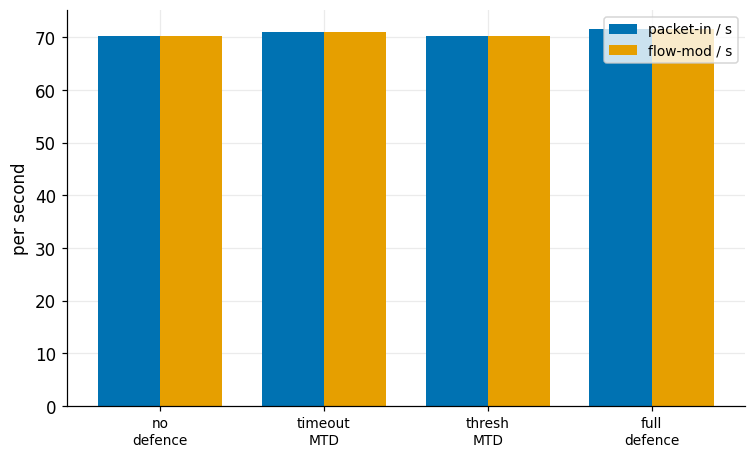

In [39]:
# --- overhead: the standing cost of each defence, attacker OFF ---
OVER = {"no defence":  {"timeout": {"policy": "T0"}, "threshold": {"policy": "H0"},
                        "detection": {"detector": "none"}},
        "timeout MTD": {"timeout": {"policy": "T3"}, "threshold": {"policy": "H0"},
                        "detection": {"detector": "simple"}},
        "thresh MTD":  {"timeout": {"policy": "T0"}, "threshold": {"policy": "H2"},
                        "detection": {"detector": "simple"}},
        "full defence":{"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                        "detection": {"detector": "la_detect"}}}
rows = []
for name, over in OVER.items():
    rs = pmap(run_config, [(CFGS.merged(over), int(s), False) for s in SEEDS])
    rows.append({"config": name,
                 "flow_mods_per_s": np.mean([r.flow_mods for r in rs])/CFGS.sim.horizon_s,
                 "packet_ins_per_s": np.mean([r.packet_ins for r in rs])/CFGS.sim.horizon_s,
                 "benign_expired": np.mean([r.benign_expired for r in rs])})
ov = pd.DataFrame(rows)
print("--- standing controller cost, no attacker present ---")
print(ov.round(1).to_string(index=False))
ref = ov[ov.config == "no defence"].iloc[0]
print(f"\nfull defence adds "
      f"{(ov[ov.config=='full defence'].iloc[0].packet_ins_per_s/ref.packet_ins_per_s-1)*100:+.1f}% "
      f"packet-in load over no defence at all")

x = np.arange(len(ov)); w = 0.38
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.bar(x - w/2, ov.packet_ins_per_s, w, label="packet-in / s", color=CB[0])
ax.bar(x + w/2, ov.flow_mods_per_s, w, label="flow-mod / s", color=CB[1])
ax.set_xticks(x); ax.set_xticklabels([c.replace(" ", "\n") for c in ov.config], fontsize=9)
ax.set_ylabel("per second"); ax.legend(fontsize=9)
finish(fig, "fig24_controller_cost", "standing controller cost of each defence, no attacker")


In [40]:
# Reading the result -- written from the numbers above
O = ov.set_index("config")
base_pin = O.loc["no defence", "packet_ins_per_s"]
extra = {c: (O.loc[c, "packet_ins_per_s"] / base_pin - 1) for c in O.index if c != "no defence"}

say(
    "**Overhead.** With no attacker present, the controller handles "
    f"{base_pin:.1f} packet-ins per second with no defence and "
    + ", ".join(f"{extra[c]:+.1%} with {c}" for c in extra) + ". "
    + ("Running the defence costs almost nothing when nobody is attacking — consistent with "
       "§19, where LA-A moves away from short timeouts when there is no attacker, because the "
       "only evidence it receives is collateral damage."
       if max(abs(v) for v in extra.values()) < 0.05 else
       "The standing cost is noticeable and belongs in any comparison of defences."),
)


**Overhead.** With no attacker present, the controller handles 70.3 packet-ins per second with no defence and +1.0% with timeout MTD, +0.0% with thresh MTD, +1.8% with full defence. Running the defence costs almost nothing when nobody is attacking — consistent with §19, where LA-A moves away from short timeouts when there is no attacker, because the only evidence it receives is collateral damage.

## 26. Conclusions, generated from the cells above

The cell below writes the conclusions **from the results computed in this
notebook**, so the text cannot drift away from the numbers. Re-run the notebook
with a different `SCALE` or a changed config and these paragraphs change with it.


In [41]:
def _overlap(a, ca, b, cb):
    """Do two mean +/- CI intervals overlap?"""
    return abs(a - b) <= (ca + cb)

best_fixed = max((n for n in ctrl if n.startswith("fixed")),
                 key=lambda n: ctrl[n]["min_attack_rate"])
best_mut   = max((n for n in ctrl if not n.startswith("fixed")),
                 key=lambda n: ctrl[n]["min_attack_rate"])
bf, bm = ctrl[best_fixed], ctrl[best_mut]
t1, t3 = ctrl["T1 uniform"], ctrl["T3 automata"]
_dr = paired(t3["per_seed_rate"], t1["per_seed_rate"])
_dc = paired(t3["per_seed_expired"], t1["per_seed_expired"])
acc = dd.groupby("detector")["accuracy"].mean(); fpr = dd.groupby("detector")["fpr"].mean()
f1 = dd.groupby("detector")["f1"].mean(); pr = dd.groupby("detector")["precision"].mean()
_bal = lambda d: dd[dd.detector == d].sort_values("seed").balanced_acc.values
_dl = paired(_bal("la_detect"), _bal("la_hand"))
L = learn_df.set_index("condition")
C_CTL = "CONTROL: feedback replaced by noise"
_learned = [c for c, (k, v) in verdicts.items() if v == "higher"]   # from section 19
_a1 = float(adv[adv.attacker == "A1"].iloc[0].sustained_occ)
_a3 = float(adv[adv.attacker == "A3"].iloc[0].sustained_occ)
_err = inf_df[inf_df.probe == "binary"].set_index("policy")["rel_error"]
_ovr = ov.set_index("config")
_pin = _ovr.loc["full defence", "packet_ins_per_s"] / _ovr.loc["no defence", "packet_ins_per_s"] - 1

# contributions, each stated only if this run supports it
_sep = all((inf_df.set_index(["policy", "probe"]).loc[(p, "binary"), "rel_error"]
            - inf_df.set_index(["policy", "probe"]).loc[(p, "binary"), "ci95"])
           > (_err["T0"] + inf_df.set_index(["policy", "probe"]).loc[("T0", "binary"), "ci95"])
           for p in ("T1", "T3"))
_learns = len(_learned) >= 2
_det_learns = _dl[0] - _dl[1] > 0
_contrib = [
  ("**LA-DETECT: a learning automaton in the position and role of the GRU in the GRU-CatBoost "
   "detector** -- in the detection layer, reading each flow's sequence of observations and "
   "keeping a temporal summary of it, with the final call made on that summary. Its weights, "
   "its memory gate and its threshold are learned by a team of automata on labelled flow "
   f"sequences (§14). On the same seeds it beats its own hand-set version by {_dl[0]:+.3f} "
   f"balanced accuracy, with {len(TEAM_SPACE)} learned numbers and one float of state per flow "
   f"(§20)." if _det_learns else ""),
  f"**A simulation that checks itself.** All {sum(c.passed for c in CHECK_RESULTS)} of "
  f"{len(CHECK_RESULTS)} behavioural invariants pass before any result is produced (§12).",
  ("**Measured degradation of the attacker's reconnaissance**, with confidence intervals "
   "that do not overlap the fixed-timeout case (§16)." if _sep else ""),
  ("**A learning MTD controller whose learning is demonstrated**, not assumed: its learned "
   "distribution differs from a no-information control beyond the error bars, in the "
   "direction each situation calls for (§19)." if _learns else ""),
  (f"**The convergence-versus-unpredictability tension, measured.** A fully converged "
   f"automaton still keeps its favoured timeout at p = {stress_maxp:.2f}, whose draws score "
   f"{stress_pred:.2f} on PredictabilityScore; the floor bounds collapse, not "
   "predictability, and it also bounds how much the learning can buy (§5, §19, Appendix A)."),
  "**A benchmark and two further studies**: LOFT-Bench's eight scenarios (Appendix B), the "
  "predictability-security question (Appendix A) and the iterated game (Appendix C).",
]

lines = [
 "## Answers, computed from the cells above",
 "",
 f"*Scale: `{SCALE}`, {len(SEEDS)} seeds, horizon {CFGS.sim.horizon_s:.0f} s, "
 f"capacity {CFG.sim.capacity}. All intervals are 95% Student-t.*",
 "",
 "**1. Does mutation break the attacker's inference?** "
 f"Fixed T0 is inferred to within {_err['T0']*100:.1f}%; T1 and T3 push the "
 f"binary-search error to {_err['T1']*100:.0f}% and {_err['T3']*100:.0f}%. "
 "This is the most solid result here.",
 "",
 f"**2. Does that buy security on the min-attack-rate metric?** The best fixed "
 f"timeout ({best_fixed}) forces {bf['min_attack_rate']:.0f} ± {bf['ci95']:.0f} pps; "
 f"the best mutating policy ({best_mut}) forces {bm['min_attack_rate']:.0f} ± "
 f"{bm['ci95']:.0f} pps. "
 + ("These overlap, so on this metric the two cannot be told apart."
    if _overlap(bf["min_attack_rate"], bf["ci95"], bm["min_attack_rate"], bm["ci95"]) else
    ("The fixed timeout is higher: min attack rate is roughly N/T, so it rewards a "
     "SHORT timeout, not an unpredictable one."
     if bf["min_attack_rate"] > bm["min_attack_rate"] else
     "The mutating policy is higher, beyond the error bars.")),
 "",
 f"**3. And the cost?** With no attacker, {best_fixed} expires "
 f"{bf['benign_expired']:.0f} benign entries against {bm['benign_expired']:.0f} for "
 f"{best_mut} ({bf['benign_expired']/max(bm['benign_expired'],1):.2f}x). "
 + ("Relative to the shortest fixed timeout, mutation trades raw security for a clearly "
    "lower collateral cost; that, not raw security, is the claim to make for it (§18)."
    if bf["benign_expired"] > bm["benign_expired"] * 1.05 else
    "The costs are close, so cost does not separate them either."),
 "",
 "**4. Does the automaton learn?** "
 + (f"Yes, in {len(_learned)} of 4 situations tested (§19). Compared with the same automaton fed "
    "noise, beyond the error bars: "
    + "; ".join(
        f"{LABELS[c]}, {L.loc[c, 'mass on <=6 s']:.2f} of its probability on short timeouts "
        f"(control {L.loc[C_CTL, 'mass on <=6 s']:.2f})"
        for c in _learned) + ". "
    if _learned else
    "Not established at this scale: no learned distribution differs from the noise control "
    "beyond the error bars. ")
 + ("With naive credit assignment the result is indistinguishable from noise." if naive_same else ""),
 "",
 "**5. Does that learning buy security?** "
 f"On min attack rate, T3 forces {t3['min_attack_rate']:.0f} ± {t3['ci95']:.0f} pps "
 f"against uniform T1's {t1['min_attack_rate']:.0f} ± {t1['ci95']:.0f}"
 + (" -- the intervals overlap. " if _overlap(t3["min_attack_rate"], t3["ci95"],
                                                 t1["min_attack_rate"], t1["ci95"])
    else " -- a difference beyond the error bars. ")
 + f"Seed by seed (same {len(SEEDS)} seeds), T3 minus T1 is {_dr[0]:+.1f} ± {_dr[1]:.1f} pps "
 f"and {_dc[0]:+.0f} ± {_dc[1]:.0f} benign expiries"
 + (" -- neither distinguishable from zero. " if abs(_dr[0]) <= _dr[1] and abs(_dc[0]) <= _dc[1]
    else ", so what the automaton learns shows up in the cost, not in raw security. ")
 + "That is the convergence-versus-unpredictability tension of section 5: the entropy "
 "floor that keeps the timeout unpredictable also caps how far a learned preference can "
 "be pushed, and an adaptive attacker (A3/A4) tracks whatever concentration remains "
 "through its miss rate. Appendix B repeats the comparison across eight scenarios.",
 "",
 f"**6. Detection.** LA-DETECT takes the position and role of the GRU in the GRU-CatBoost "
 "detector: a per-flow recurrent summary of the flow's sequence of observations, with a "
 "decision on that summary. Its weights, memory gate and threshold are learned by a team of "
 f"automata on labelled flow sequences (§14). It reaches {acc['la_detect']:.1%} accuracy, F1 "
 f"{f1['la_detect']:.3f}, precision {pr['la_detect']:.3f} and a false-positive rate of "
 f"{fpr['la_detect']:.1%}, against {acc['simple']:.1%} and F1 {f1['simple']:.3f} for the "
 f"fixed-rule baseline. With hand-set values the same automaton reaches F1 {f1['la_hand']:.3f} "
 f"(false-positive rate {fpr['la_hand']:.1%}), and the evidence of one epoch with no memory "
 f"reaches {f1['score']:.3f}. "
 + ("So learning is what moves the numbers: seed by seed it changes balanced accuracy by "
    f"{_dl[0]:+.3f} ± {_dl[1]:.3f}. " if _det_learns else
    f"Learning changes balanced accuracy by {_dl[0]:+.3f} ± {_dl[1]:.3f}, which is not "
    "established at this scale. ")
 + f"Its whole model is {len(TEAM_SPACE)} learned numbers and one float per live flow, and it "
 f"classifies the entire table in {dd[dd.detector == 'la_detect'].ms_per_epoch.mean():.2f} ms "
 "on one core.",
 "",
 f"**7. What it costs to run.** With no attacker present the full defence adds {_pin:+.1%} "
 f"packet-in load over no defence at all (§25), and detection adds "
 f"{dd[dd.detector == 'la_detect'].ms_per_epoch.mean():.2f} ms of controller time per epoch.",
 "",
 "## What this work contributes",
 "",
] + [f"{i}. {t}" for i, t in enumerate([t for t in _contrib if t], 1)] + [
 "",
 "## Limitations, stated plainly",
 "",
 "1. **Numerical simulation, not a testbed.** No packets, no real switch. "
 "Appropriate for a parameter study over many combinations and seeds; validation on "
 "Mininet/Open vSwitch/Ryu is separate work.",
 "2. **Flow telemetry is modelled, not captured.** Packets are generated as a renewal "
 "process from each flow's latent rate and regularity, and the detector sees only counts "
 "and gap timing, never the latent values. Real flow-stats and inter-arrival data from a "
 "Mininet/Ryu testbed would replace this generator directly.",
 "3. **The comparison with published detectors is context, not a head-to-head.** FloRa and "
 "the GRU-CatBoost detector are measured on their own datasets. A like-for-like comparison "
 "would mean training those models on the sequences of §14, which this notebook does not do.",
 "4. **A benign entry is released the moment its flow ends.** In OpenFlow it would "
 "linger for one idle timeout, so the real space cost of LONG timeouts is not "
 "modelled; the comparison is tilted slightly in favour of long timeouts.",
 "5. **A2 reads a noisy global occupancy estimate.** A real attacker would infer it "
 "indirectly, so A2/A4 results favour the attacker.",
 "6. **LA-A learns only as well as the detection layer tells it.** Its security "
 "evidence is the detector's verdict; false positives are damped by the pressure "
 "gate, not removed.",
 ("7. **The adaptive logic engages at this horizon.** A3 sustains "
  f"{_a3:.3f} occupancy against A1's {_a1:.3f} (95% intervals ±"
  f"{float(adv[adv.attacker == 'A3'].iloc[0].sust_ci):.3f} and ±"
  f"{float(adv[adv.attacker == 'A1'].iloc[0].sust_ci):.3f}); report the horizon with any "
  "adaptive-attacker claim."
  if abs(_a3 - _a1) > 1e-6 else
  "7. **A3's adaptive logic never engaged at this horizon** -- raise it before "
  "claiming anything about adaptive attackers."),
 "8. **The novelty claims still need a systematic database search** against the "
 "published literature.",
]
display(Markdown("\n".join(lines)))


# =========================================================================== #
# Detection accuracy, in the form the detection papers report it
# =========================================================================== #
def _pm(v, ci, pct=False, nd=3):
    return (f"{v:.1%} ± {ci:.1%}" if pct else f"{v:.{nd}f} ± {ci:.{nd}f}") if np.isfinite(v) else "n/a"

_g = dd.groupby("detector")
_m = lambda d, k: float(_g[k].mean()[d])
_c = lambda d, k: float(_g[k].agg(lambda v: mean_ci95(np.asarray(v, float))[1])[d])
_hdr = ["detector (setting)", "Accuracy", "Precision", "Recall (TPR)", "Specificity", "FPR",
        "F1", "Balanced acc.", "MCC", "Latency", "Compute / round"]
_rows = []
for d, lab in DETECTORS.items():
    _rows.append([f"**{lab}** (`{d}`)" if d == "la_detect" else f"{lab} (`{d}`)",
                  _pm(_m(d, "accuracy"), _c(d, "accuracy"), True), _pm(_m(d, "precision"), _c(d, "precision")),
                  _pm(_m(d, "recall"), _c(d, "recall")), _pm(_m(d, "specificity"), _c(d, "specificity")),
                  _pm(_m(d, "fpr"), _c(d, "fpr"), True), _pm(_m(d, "f1"), _c(d, "f1")),
                  _pm(_m(d, "balanced_acc"), _c(d, "balanced_acc")), _pm(_m(d, "mcc"), _c(d, "mcc")),
                  f"{_m(d, 'latency_s'):.1f} s", f"{_m(d, 'ms_per_epoch'):.2f} ms"])
for a_, r_ in adv.set_index("attacker").iterrows():
    _rows.append([f"LA-DETECT in the full defence, attacker {a_}",
                  f"{r_.pooled_accuracy:.1%}", f"{r_.pooled_precision:.3f}", f"{r_.pooled_recall:.3f}",
                  f"{r_.pooled_specificity:.3f}", f"{r_.pooled_fpr:.1%}", f"{r_.pooled_f1:.3f}",
                  f"{r_.pooled_balanced_acc:.3f}", f"{r_.pooled_mcc:.3f}", f"{r_.latency_s:.1f} s", "--"])
_tv = team_eval.set_index(["detector", "split"]).loc[("la_detect (learned by the team)", "validation")]
_rows.append(["LA-DETECT offline, unseen validation seeds (§14)", f"{_tv.accuracy:.1%}",
              f"{_tv.precision:.3f}", f"{_tv.recall:.3f}", f"{_tv.specificity:.3f}", f"{_tv.fpr:.1%}",
              f"{_tv.f1:.3f}", f"{_tv.balanced_acc:.3f}", f"{_tv.mcc:.3f}", "--", "--"])
_rows.append(["*FloRa, Mudgal et al. 2024 (reported, own dataset)*", "99.49%", "--", "--", "--",
              "0.01%", "--", "--", "--", "--", "--"])
_rows.append(["*GRU-CatBoost, Bahrami & Haj Seyyed Javadi 2026 (reported, own dataset)*",
              "96.8% ± 0.4%", "--", "--", "--", "1.9%", "0.968", "--", "--", "--", "--"])

_la = "la_detect"
display(Markdown("\n".join([
 "## Detection accuracy, reported the way the detection papers report it", "",
 f"**Headline:** LA-DETECT classifies flows with **{_m(_la, 'accuracy'):.1%} accuracy** "
 f"(95% CI ± {_c(_la, 'accuracy'):.1%}), **precision {_m(_la, 'precision'):.3f}, recall "
 f"{_m(_la, 'recall'):.3f}, F1 {_m(_la, 'f1'):.3f}**, and a **false-positive rate of "
 f"{_m(_la, 'fpr'):.1%}** ({len(SEEDS)} seeds, every entry scored at every epoch), from "
 f"{len(TEAM_SPACE)} learned numbers and one float of state per flow.", "",
 md_table(_hdr, _rows), "",
 "*Rows 1-4: mean ± 95% Student-t CI over seeds, attack A1, fixed timeout, threshold H0 (§20). "
 "Rows 5-8: confusion counts pooled over seeds, full defence T3 + H2 + LA-DETECT (§23); A2-A4 "
 "were never seen in training. Latency is simulated time from an entry's installation to its "
 "first flag (decisions are taken once per 1 s epoch). Compute / round is the wall-clock time "
 "to classify every entry in the table once. Published figures come from the papers' own "
 "testbeds and datasets, so they are context, not a head-to-head comparison: here slow benign "
 "flows and the LOFT refresher overlap by construction, and every such benign flow a detector "
 "cannot separate is a false positive.*",
])))


## Answers, computed from the cells above

*Scale: `full`, 32 seeds, horizon 60 s, capacity 1800. All intervals are 95% Student-t.*

**1. Does mutation break the attacker's inference?** Fixed T0 is inferred to within 0.6%; T1 and T3 push the binary-search error to 24% and 25%. This is the most solid result here.

**2. Does that buy security on the min-attack-rate metric?** The best fixed timeout (fixed 2s) forces 518 ± 5 pps; the best mutating policy (T1 uniform) forces 273 ± 6 pps. The fixed timeout is higher: min attack rate is roughly N/T, so it rewards a SHORT timeout, not an unpredictable one.

**3. And the cost?** With no attacker, fixed 2s expires 4581 benign entries against 3453 for T1 uniform (1.33x). Relative to the shortest fixed timeout, mutation trades raw security for a clearly lower collateral cost; that, not raw security, is the claim to make for it (§18).

**4. Does the automaton learn?** Yes, in 3 of 4 situations tested (§19). Compared with the same automaton fed noise, beyond the error bars: under a classic attack (the §17 setting), 0.65 of its probability on short timeouts (control 0.30); under the adaptive attack, full defence, 0.74 of its probability on short timeouts (control 0.30); with no detector, 0.09 of its probability on short timeouts (control 0.30). With naive credit assignment the result is indistinguishable from noise.

**5. Does that learning buy security?** On min attack rate, T3 forces 269 ± 6 pps against uniform T1's 273 ± 6 -- the intervals overlap. Seed by seed (same 32 seeds), T3 minus T1 is -4.4 ± 3.7 pps and -19 ± 5 benign expiries, so what the automaton learns shows up in the cost, not in raw security. That is the convergence-versus-unpredictability tension of section 5: the entropy floor that keeps the timeout unpredictable also caps how far a learned preference can be pushed, and an adaptive attacker (A3/A4) tracks whatever concentration remains through its miss rate. Appendix B repeats the comparison across eight scenarios.

**6. Detection.** LA-DETECT takes the position and role of the GRU in the GRU-CatBoost detector: a per-flow recurrent summary of the flow's sequence of observations, with a decision on that summary. Its weights, memory gate and threshold are learned by a team of automata on labelled flow sequences (§14). It reaches 92.9% accuracy, F1 0.928, precision 0.866 and a false-positive rate of 13.2%, against 58.2% and F1 0.456 for the fixed-rule baseline. With hand-set values the same automaton reaches F1 0.852 (false-positive rate 32.5%), and the evidence of one epoch with no memory reaches 0.848. So learning is what moves the numbers: seed by seed it changes balanced accuracy by +0.096 ± 0.001. Its whole model is 5 learned numbers and one float per live flow, and it classifies the entire table in 0.12 ms on one core.

**7. What it costs to run.** With no attacker present the full defence adds +1.8% packet-in load over no defence at all (§25), and detection adds 0.12 ms of controller time per epoch.

## What this work contributes

1. **LA-DETECT: a learning automaton in the position and role of the GRU in the GRU-CatBoost detector** -- in the detection layer, reading each flow's sequence of observations and keeping a temporal summary of it, with the final call made on that summary. Its weights, its memory gate and its threshold are learned by a team of automata on labelled flow sequences (§14). On the same seeds it beats its own hand-set version by +0.096 balanced accuracy, with 5 learned numbers and one float of state per flow (§20).
2. **A simulation that checks itself.** All 10 of 10 behavioural invariants pass before any result is produced (§12).
3. **Measured degradation of the attacker's reconnaissance**, with confidence intervals that do not overlap the fixed-timeout case (§16).
4. **A learning MTD controller whose learning is demonstrated**, not assumed: its learned distribution differs from a no-information control beyond the error bars, in the direction each situation calls for (§19).
5. **The convergence-versus-unpredictability tension, measured.** A fully converged automaton still keeps its favoured timeout at p = 0.66, whose draws score 0.33 on PredictabilityScore; the floor bounds collapse, not predictability, and it also bounds how much the learning can buy (§5, §19, Appendix A).
6. **A benchmark and two further studies**: LOFT-Bench's eight scenarios (Appendix B), the predictability-security question (Appendix A) and the iterated game (Appendix C).

## Limitations, stated plainly

1. **Numerical simulation, not a testbed.** No packets, no real switch. Appropriate for a parameter study over many combinations and seeds; validation on Mininet/Open vSwitch/Ryu is separate work.
2. **Flow telemetry is modelled, not captured.** Packets are generated as a renewal process from each flow's latent rate and regularity, and the detector sees only counts and gap timing, never the latent values. Real flow-stats and inter-arrival data from a Mininet/Ryu testbed would replace this generator directly.
3. **The comparison with published detectors is context, not a head-to-head.** FloRa and the GRU-CatBoost detector are measured on their own datasets. A like-for-like comparison would mean training those models on the sequences of §14, which this notebook does not do.
4. **A benign entry is released the moment its flow ends.** In OpenFlow it would linger for one idle timeout, so the real space cost of LONG timeouts is not modelled; the comparison is tilted slightly in favour of long timeouts.
5. **A2 reads a noisy global occupancy estimate.** A real attacker would infer it indirectly, so A2/A4 results favour the attacker.
6. **LA-A learns only as well as the detection layer tells it.** Its security evidence is the detector's verdict; false positives are damped by the pressure gate, not removed.
7. **The adaptive logic engages at this horizon.** A3 sustains 0.679 occupancy against A1's 0.618 (95% intervals ±0.007 and ±0.015); report the horizon with any adaptive-attacker claim.
8. **The novelty claims still need a systematic database search** against the published literature.

## Detection accuracy, reported the way the detection papers report it

**Headline:** LA-DETECT classifies flows with **92.9% accuracy** (95% CI ± 0.1%), **precision 0.866, recall 0.999, F1 0.928**, and a **false-positive rate of 13.2%** (32 seeds, every entry scored at every epoch), from 5 learned numbers and one float of state per flow.

| detector (setting) | Accuracy | Precision | Recall (TPR) | Specificity | FPR | F1 | Balanced acc. | MCC | Latency | Compute / round |
|---|---|---|---|---|---|---|---|---|---|---|
| fixed-rule baseline (`simple`) | 58.2% ± 0.1% | 0.902 ± 0.002 | 0.305 ± 0.003 | 0.956 ± 0.001 | 4.4% ± 0.1% | 0.456 ± 0.004 | 0.631 ± 0.002 | 0.326 ± 0.003 | 3.5 s | 0.06 ms |
| evidence, no memory (`score`) | 82.8% ± 0.3% | 0.736 ± 0.005 | 1.000 ± 0.000 | 0.669 ± 0.002 | 33.1% ± 0.2% | 0.848 ± 0.003 | 0.834 ± 0.001 | 0.701 ± 0.003 | 0.5 s | 0.10 ms |
| LA, hand-set (`la_hand`) | 83.2% ± 0.3% | 0.742 ± 0.005 | 1.000 ± 0.000 | 0.675 ± 0.003 | 32.5% ± 0.3% | 0.852 ± 0.003 | 0.838 ± 0.001 | 0.708 ± 0.003 | 0.5 s | 0.12 ms |
| **LA-DETECT (learned)** (`la_detect`) | 92.9% ± 0.1% | 0.866 ± 0.003 | 0.999 ± 0.000 | 0.868 ± 0.002 | 13.2% ± 0.2% | 0.928 ± 0.002 | 0.934 ± 0.001 | 0.866 ± 0.002 | 0.5 s | 0.12 ms |
| LA-DETECT in the full defence, attacker A1 | 91.2% | 0.820 | 0.999 | 0.853 | 14.7% | 0.901 | 0.926 | 0.836 | 0.5 s | -- |
| LA-DETECT in the full defence, attacker A2 | 90.6% | 0.813 | 1.000 | 0.841 | 15.9% | 0.896 | 0.920 | 0.826 | 0.6 s | -- |
| LA-DETECT in the full defence, attacker A3 | 93.1% | 0.872 | 0.999 | 0.871 | 12.9% | 0.931 | 0.935 | 0.871 | 0.5 s | -- |
| LA-DETECT in the full defence, attacker A4 | 91.8% | 0.850 | 1.000 | 0.849 | 15.1% | 0.919 | 0.924 | 0.849 | 0.6 s | -- |
| LA-DETECT offline, unseen validation seeds (§14) | 93.2% | 0.903 | 1.000 | 0.818 | 18.2% | 0.949 | 0.909 | 0.859 | -- | -- |
| *FloRa, Mudgal et al. 2024 (reported, own dataset)* | 99.49% | -- | -- | -- | 0.01% | -- | -- | -- | -- | -- |
| *GRU-CatBoost, Bahrami & Haj Seyyed Javadi 2026 (reported, own dataset)* | 96.8% ± 0.4% | -- | -- | -- | 1.9% | 0.968 | -- | -- | -- | -- |

*Rows 1-4: mean ± 95% Student-t CI over seeds, attack A1, fixed timeout, threshold H0 (§20). Rows 5-8: confusion counts pooled over seeds, full defence T3 + H2 + LA-DETECT (§23); A2-A4 were never seen in training. Latency is simulated time from an entry's installation to its first flag (decisions are taken once per 1 s epoch). Compute / round is the wall-clock time to classify every entry in the table once. Published figures come from the papers' own testbeds and datasets, so they are context, not a head-to-head comparison: here slow benign flows and the LOFT refresher overlap by construction, and every such benign flow a detector cannot separate is a false positive.*

## Appendix A. PredictabilityScore — calibration, and does less predictable mean more secure?

*This appendix answers a question of its own (RQ3) and is not needed to follow the detection and MTD results in §15–§25.*


First calibrate the metric on three sequences whose answers are known in
advance. A metric that gets these wrong cannot be trusted on anything else, and
the middle row is the whole point: `2, 20, 2, 20, …` has maximum entropy over
two values, so an entropy-only metric rates it a good mutation while it is in
fact completely predictable.

Then the actual hypothesis: does lower predictability buy more security? The
cell sweeps the mutation **intensity** knob, which widens the candidate set
around its centre, and plots predictability against security — with the
*shortest candidate* annotated at each point, because that is the confound.


sequence                      | Score | entropy | predictor | autocorr | verdict
--------------------------------------------------------------------------------------
constant    [10,10,10,...]    | 1.000 |  1.000  |   1.000   |  1.000   | fully predictable
alternating [2,20,2,20,...]   | 0.898 |  0.699  |   1.000   |  1.000   | fully predictable
uniform random over [2..20]   | 0.024 |  0.007  |   0.007   |  0.058   | unpredictable

The middle row is why entropy alone is not enough: maximum entropy over two
values, yet the autocorrelation and predictor terms correctly expose it.



 intensity  min_timeout_s  predictability  min_attack_rate  ci95
     0.000           11.0           1.000          249.856 4.067
     0.167            9.5           0.069          248.812 5.431
     0.333            8.0           0.063          246.604 6.494
     0.500            6.5           0.130          249.619 5.416
     0.667            5.0           0.156          252.105 6.805
     0.833            3.5           0.144          260.326 8.015
     1.000            2.0           0.181          268.888 6.286


[figures/fig25_predictability_vs_security.png]  security against PredictabilityScore across the intensity sweep (labels: shortest candidate)


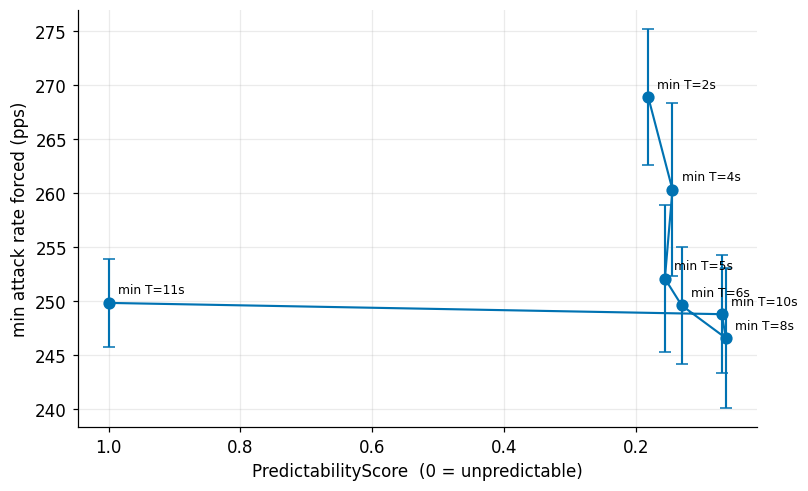

[figures/fig26_intensity_sweep.png]  what moves with mutation intensity: predictability, security, shortest candidate


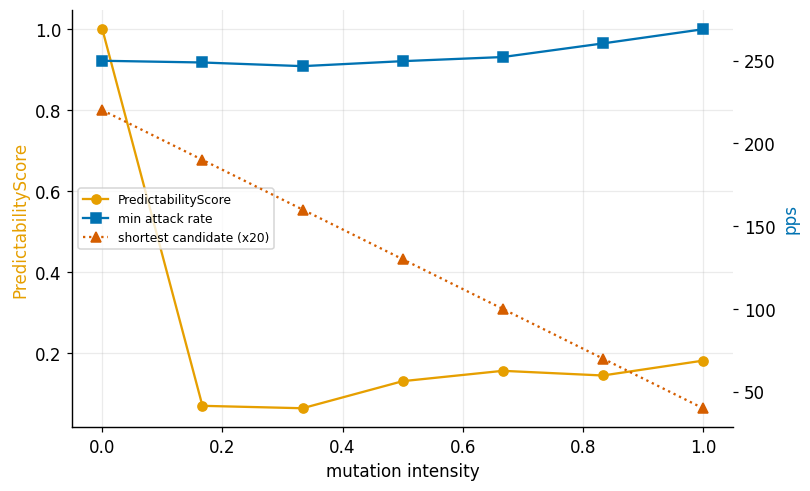


Pearson r(predictability, security) = -0.112  over n = 7 points
Pearson r(shortest candidate, security) = -0.827


In [42]:
cands = CFG.timeout.la_candidates_s
rng = np.random.default_rng(0)
demos = {
    "constant    [10,10,10,...]": [10.0] * 300,
    "alternating [2,20,2,20,...]": [2.0, 20.0] * 150,
    "uniform random over [2..20]": list(rng.choice(cands, 300)),
}
print("sequence                      | Score | entropy | predictor | autocorr | verdict")
print("-" * 86)
calib = {}
for name, s_ in demos.items():
    r = predictability_score(s_, CFG, alphabet=cands)   # the known candidate set
    calib[name.split()[0]] = r
    v = ("fully predictable" if r.score > 0.8 else
         "unpredictable" if r.score < 0.2 else "partly predictable")
    print(f"{name:29s} | {r.score:.3f} |  {r.entropy:.3f}  |   "
          f"{r.advantage:.3f}   |  {r.autocorr:.3f}   | {v}")
print("\nThe middle row is why entropy alone is not enough: maximum entropy over two")
print("values, yet the autocorrelation and predictor terms correctly expose it.")

# --- the hypothesis: intensity sweep ---
base = {"threshold": {"policy": "H0"}, "detection": {"detector": "simple"},
        "attacker": {"kind": "A1", "target_entries": CFG.sim.capacity}}
intens = np.linspace(0.0, 1.0, 7)
rows = []
centre = float(np.mean(cands))
for it in intens:
    scaled = [centre + (v - centre) * it for v in cands]
    over = {**base, "timeout": {"policy": "T3"}}
    cfg_it = CFGS.merged({"timeout": {"la_candidates_s": scaled}})
    mins = [m for m, _ in pmap(min_attack_rate, [(over, int(s), cfg_it) for s in SEEDS])]
    run_it = CFGS.merged(over).merged({"timeout": {"la_candidates_s": scaled},
                                       "attacker": {"rate_pps": 300}})
    seqs = []
    for r in pmap(run_config, [(run_it, int(s)) for s in SEEDS]):
        seqs += list(r.timeout_seq)
    m, ci = mean_ci95(np.array(mins))
    rows.append({"intensity": it, "min_timeout_s": min(scaled),
                 "predictability": predictability_score(seqs, CFG, alphabet=scaled).score,
                 "min_attack_rate": m, "ci95": ci})
fr = pd.DataFrame(rows)
print()
print(fr.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.errorbar(fr.predictability, fr.min_attack_rate, yerr=fr.ci95,
            marker="o", ms=7, lw=1.4, capsize=4, color=CB[0])
for _, r_ in fr.iterrows():
    ax.annotate(f"min T={r_.min_timeout_s:.0f}s",
                (r_.predictability, r_.min_attack_rate),
                textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_xlabel("PredictabilityScore  (0 = unpredictable)")
ax.set_ylabel("min attack rate forced (pps)")
ax.invert_xaxis()
finish(fig, "fig25_predictability_vs_security",
       "security against PredictabilityScore across the intensity sweep (labels: shortest candidate)")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(fr.intensity, fr.predictability, marker="o", color=CB[1], label="PredictabilityScore")
axb = ax.twinx()
axb.plot(fr.intensity, fr.min_attack_rate, marker="s", color=CB[0], label="min attack rate")
axb.plot(fr.intensity, fr.min_timeout_s * 20, marker="^", ls=":", color=CB[3],
         label="shortest candidate (x20)")
ax.set_xlabel("mutation intensity"); ax.set_ylabel("PredictabilityScore", color=CB[1])
axb.set_ylabel("pps", color=CB[0]); axb.grid(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center left")
finish(fig, "fig26_intensity_sweep",
       "what moves with mutation intensity: predictability, security, shortest candidate")

r_pear = np.corrcoef(fr.predictability, fr.min_attack_rate)[0, 1]
print(f"\nPearson r(predictability, security) = {r_pear:.3f}  over n = {len(fr)} points")
print(f"Pearson r(shortest candidate, security) = "
      f"{np.corrcoef(fr.min_timeout_s, fr.min_attack_rate)[0,1]:.3f}")


In [43]:
# Reading the result -- written from the numbers above
c_const, c_alt, c_unif = calib["constant"].score, calib["alternating"].score, calib["uniform"].score
calibrated = c_const > 0.95 and c_alt > 0.8 and c_unif < 0.1
r_short = np.corrcoef(fr.min_timeout_s, fr.min_attack_rate)[0, 1]
pred_nonzero = fr[fr.intensity > 0].predictability
two_groups = fr.predictability.iloc[0] > 0.9 and pred_nonzero.max() < 0.5
rise = fr.predictability.iloc[-1] - pred_nonzero.min()

say(
    f"**Calibration.** Constant sequence {c_const:.2f}, uniform random {c_unif:.2f}, and the "
    f"alternating 2, 20, 2, 20 … sequence {c_alt:.2f} despite having maximum entropy over "
    "its two values. "
    + ("The metric gets all three right, which is sanity check C7 and what makes it usable "
       "on its own: an entropy-only measure would call the alternating sequence a good "
       "mutation."
       if calibrated else
       "At least one known case is scored wrongly, so the metric should not be relied on "
       "until that is fixed."),
    f"**The hypothesis — does less predictable mean more secure?** Across the intensity "
    f"sweep, r(predictability, security) = {r_pear:.2f}, while r(shortest candidate, "
    f"security) = {r_short:.2f}. "
    + ("Security follows how short the shortest timeout is, not how unpredictable the "
       "sequence is — the same N/T effect as §17. Widening the candidate set lowers "
       "predictability and adds shorter timeouts at the same time, and it is the second "
       "that moves the attack rate."
       if abs(r_short) > abs(r_pear) + 0.2 else
       "Neither explanation clearly dominates at this scale."),
    ("The predictability values also fall into two groups (1.0 at intensity 0, low "
     f"everywhere else), so with {len(fr)} points this is really a two-group comparison, "
     "not a correlation. " if two_groups else "")
    + (f"Note the rise in predictability at the highest intensities (+{rise:.2f}). The likely "
       "cause is the automaton learning (§19): once the candidate set includes timeouts short "
       "enough to make the attacker miss, it concentrates on them, and a concentrated "
       "sequence is more predictable — the tension of §5 showing up in the metric. "
       if rise > 0.05 else "")
    + "**The defensible claim here is the metric itself, not a causal arrow from it to "
    "security.**",
)


**Calibration.** Constant sequence 1.00, uniform random 0.02, and the alternating 2, 20, 2, 20 … sequence 0.90 despite having maximum entropy over its two values. The metric gets all three right, which is sanity check C7 and what makes it usable on its own: an entropy-only measure would call the alternating sequence a good mutation.

**The hypothesis — does less predictable mean more secure?** Across the intensity sweep, r(predictability, security) = -0.11, while r(shortest candidate, security) = -0.83. Security follows how short the shortest timeout is, not how unpredictable the sequence is — the same N/T effect as §17. Widening the candidate set lowers predictability and adds shorter timeouts at the same time, and it is the second that moves the attack rate.

The predictability values also fall into two groups (1.0 at intensity 0, low everywhere else), so with 7 points this is really a two-group comparison, not a correlation. Note the rise in predictability at the highest intensities (+0.12). The likely cause is the automaton learning (§19): once the candidate set includes timeouts short enough to make the attacker miss, it concentrates on them, and a concentrated sequence is more predictable — the tension of §5 showing up in the metric. **The defensible claim here is the metric itself, not a causal arrow from it to security.**

In [ ]:
# --- the cost model (paper, Section III-D): what sets the attacker's rate ---
# A rule with timeout tau needs a packet at least every (1 - m) tau seconds, so holding
# N rules costs sum_i 1 / ((1 - m) tau_i), about N / ((1 - m) tau_H) packets/s, where
# tau_H is the harmonic mean of the timeout distribution. The order of the draws does
# not appear in that sum.
m_ref = CFG.attacker.refresh_margin_frac
N_tab = CFG.sim.capacity
c_arr = np.asarray(cands, dtype=float)
u = np.full(len(c_arr), 1.0 / len(c_arr))


def tau_harmonic(p, values):
    p = np.asarray(p, dtype=float)
    return 1.0 / np.sum(p / np.asarray(values, dtype=float))


def tracking_rate(tau_h, n=N_tab):
    return n / ((1.0 - m_ref) * tau_h)


t_u = tau_harmonic(u, c_arr)
print(f"to hold {N_tab} rules: fixed 11 s needs {tracking_rate(11.0):.0f} pps, fixed 2 s "
      f"{tracking_rate(2.0):.0f} pps, uniform over {c_arr.min():.0f}..{c_arr.max():.0f} s "
      f"(tau_H = {t_u:.2f} s) {tracking_rate(t_u):.0f} pps")

# 1. the intensity sweep above, with the harmonic mean of each scaled candidate set
cost = fr[["intensity", "min_timeout_s", "predictability", "min_attack_rate"]].copy()
centre = float(np.mean(c_arr))
cost.insert(2, "tau_H", [tau_harmonic(u, centre + (c_arr - centre) * i) for i in cost.intensity])
print()
print(cost.round(3).to_string(index=False))
r_h = np.corrcoef(1.0 / cost.tau_H, cost.min_attack_rate)[0, 1]
r_s = np.corrcoef(cost.min_timeout_s, cost.min_attack_rate)[0, 1]
r_p = np.corrcoef(cost.predictability, cost.min_attack_rate)[0, 1]
print(f"\ncorrelation with the attack rate: 1/tau_H {r_h:.3f}, shortest candidate {r_s:.3f}, "
      f"PredictabilityScore {r_p:.3f}")

# 2. the distributions LA-A ended with earlier (P_final), read through the same model
print(f"\n{'final LA-A distribution':38s} {'tau_H (s)':>9s} {'pps for all':>12s} {'rules at 300 pps':>17s}")
for name, p in P_final.items():
    th = tau_harmonic(p, c_arr)
    print(f"{name:38s} {th:9.2f} {tracking_rate(th):12.0f} {300 * (1 - m_ref) * th:17.0f}")

to hold 1800 rules: fixed 11 s needs 182 pps, fixed 2 s 1000 pps, uniform over 2..20 s (tau_H = 6.83 s) 293 pps

 intensity  min_timeout_s  tau_H  predictability  min_attack_rate
     0.000           11.0 11.000           1.000          249.856
     0.167            9.5 10.916           0.069          248.812
     0.333            8.0 10.658           0.063          246.604
     0.500            6.5 10.206           0.130          249.619
     0.667            5.0  9.512           0.156          252.105
     0.833            3.5  8.478           0.144          260.326
     1.000            2.0  6.828           0.181          268.888

correlation with the attack rate: 1/tau_H 0.978, shortest candidate -0.827, PredictabilityScore -0.112

final LA-A distribution                tau_H (s)  pps for all  rules at 300 pps
under attack (A1), simple verdicts          5.44          368              1468
under attack (A3), LA-DETECT verdicts       2.74          731               739
no attacker at

## Appendix B. LOFT-Bench — a reusable benchmark

*A contribution in its own right, kept out of the main line: it repeats the comparison of §17 and §20 across eight scenarios instead of one.*

Every published study in this area picks its own topology, traffic rate and
table size, so two papers' results are simply not comparable. A benchmark is a
fixed, seeded set of scenarios that everyone reports on, and building one is a
contribution in its own right.

Eight scenarios, and **one hard rule: a single defence configuration runs across
all eight with no per-scenario tuning.** That is what stops a defence from being
quietly fitted to the test. Note the rule constrains the *defence*, not the
*scenario*: choosing a scenario's difficulty so that it can separate defences is
benchmark design, and refusing to do it just produces a benchmark that measures
nothing.

### Three design rules that make the benchmark discriminate

**Benign traffic must not pre-fill the table.** Little's law:
`occupied = arrival_fps x mean flow life`. With a 10 s mean holding time, pairing
a small table or heavy traffic with a fixed arrival rate gives a benign
occupancy above 1.0 — the scenario would measure benign overload, not the attack.
So each scenario declares a **target benign occupancy** and derives its arrival
rate from its own capacity. "Heavy traffic" still means heavy — 0.65 instead of
0.45 — but heavy enough to stress the defence rather than pre-fill the table.

**The attack rate must sit in the band where defences differ.** Past roughly
2.5x the minimum viable rate every defence fails, and every configuration
returns the same number. Each scenario's attack rate is a multiple (0.5x-2x) of
its own minimum viable rate.

**The primary metric must not saturate.** Peak occupancy is close to binary: it
reaches 1.00 if the table ever fills, even momentarily. Sustained (mean)
occupancy separates "briefly touched the ceiling" from "held the table full",
which is the distinction a defence is judged on. Peak is shown alongside it.

The last cell grades the benchmark against itself and names any scenario that
still fails to discriminate. A benchmark that cannot report its own blind spots
should not be proposed as a standard.

**How to read the result.** `full_two_layer` and `both_la` run the same automata
and differ only in the detector (LA-DETECT versus the fixed rule), and
`both_la` and `naive_mtd` differ only in learned versus uniform mutation. So the
first gap measures the detection layer, the second measures the learning.


scenario             capacity  benign fps  benign occ  attack pps
--------------------------------------------------------------------
S1_baseline              1800        67.7        0.45       250.0
S2_small_table            600        22.6        0.45        83.3
S3_large_table           5000       187.9        0.45       694.4
S4_heavy_traffic         1800        97.7        0.65       250.0
S5_bursty                1800        67.7        0.45       250.0
S6_slow_attacker         1800        67.7        0.45       100.0
S7_aggressive            1800        67.7        0.45       400.0
S8_multi_attacker        1800        67.7        0.45       360.0

Benign occupancy is now BELOW the ceiling in every scenario, so the
attack is what fills the table -- which is the thing being measured.



=== PRIMARY: sustained (mean) occupancy -- lower = defence holding ===
scenario        S1_baseline  S2_small_table  S3_large_table  S4_heavy_traffic  S5_bursty  S6_slow_attacker  S7_aggressive  S8_multi_attacker
config                                                                                                                                      
both_la               0.782           0.780           0.780             0.869      0.772             0.663          0.779              0.775
full_two_layer        0.623           0.625           0.620             0.707      0.620             0.613          0.585              0.595
naive_mtd             0.793           0.791           0.793             0.871      0.783             0.667          0.781              0.791
no_defense            0.960           0.960           0.960             0.965      0.959             0.859          0.975              0.972
threshold_la          0.843           0.842           0.843             0.921     

[figures/fig27_bench_sustained_occupancy.png]  LOFT-Bench: sustained (mean) occupancy per configuration and scenario (primary)


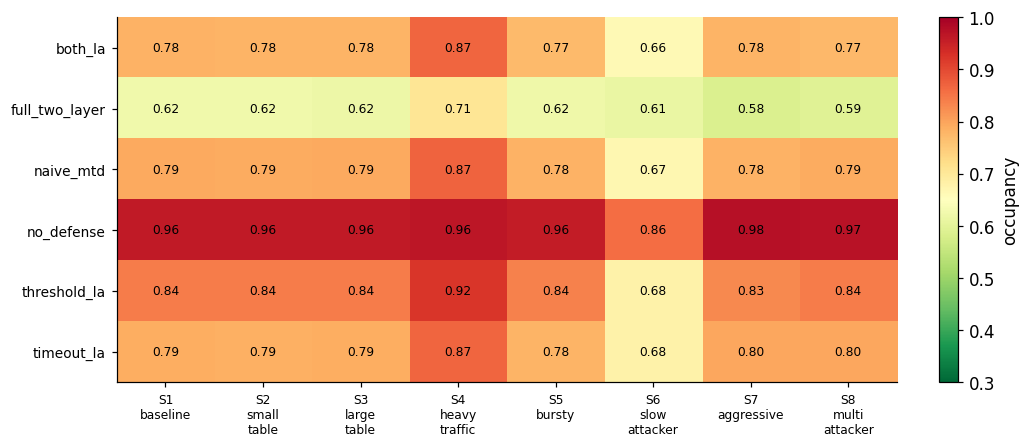

[figures/fig28_bench_peak_occupancy.png]  LOFT-Bench: peak occupancy per configuration and scenario (saturates)


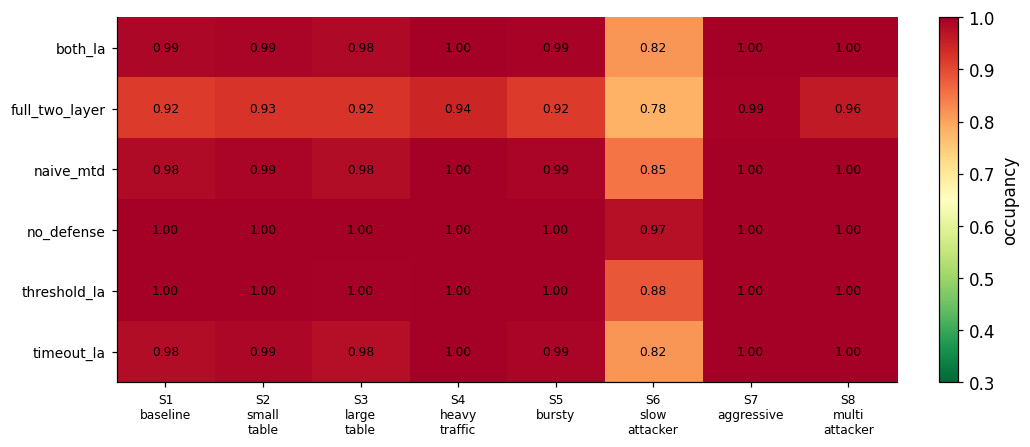


SELF-ASSESSMENT: 8/8 scenarios discriminate on the primary metric.
Every scenario separates the configurations. The benchmark is usable.


In [44]:
# --------------------------------------------------------------------------- #
# Defense registry (public API)
# --------------------------------------------------------------------------- #
@dataclass
class Defense:
    name: str
    timeout_policy: str = "T0"
    threshold_policy: str = "H0"
    detector: str = "none"
    timeout_factory: Optional[Callable] = None
    threshold_factory: Optional[Callable] = None
    detector_factory: Optional[Callable] = None


_REGISTRY: Dict[str, Defense] = {}


def register_defense(name: str, timeout_policy: str = "T0",
                     threshold_policy: str = "H0", detector: str = "none",
                     timeout_factory: Optional[Callable] = None,
                     threshold_factory: Optional[Callable] = None,
                     detector_factory: Optional[Callable] = None) -> None:
    """Register a defense for the benchmark.

    ``timeout_policy`` / ``threshold_policy`` / ``detector`` are the built-in
    policy names (e.g. ``"T3"``, ``"H2"``, ``"la_detect"``).  To plug in a
    custom mechanism, pass a factory instead: ``timeout_factory(cfg, rng) ->
    TimeoutPolicy``, ``threshold_factory(cfg, rng) -> ThresholdPolicy``,
    ``detector_factory(cfg) -> Detector``.
    """
    _REGISTRY[name] = Defense(name, timeout_policy, threshold_policy, detector,
                              timeout_factory, threshold_factory, detector_factory)


def registered_defenses() -> List[str]:
    return list(_REGISTRY.keys())


def _register_defaults() -> None:
    register_defense("no_defense", "T0", "H0", "none")
    register_defense("naive_mtd", "T1", "H1", "simple")
    register_defense("timeout_la", "T3", "H0", "simple")
    register_defense("threshold_la", "T0", "H2", "simple")
    register_defense("both_la", "T3", "H2", "simple")
    register_defense("full_two_layer", "T3", "H2", "la_detect")


_register_defaults()


# --------------------------------------------------------------------------- #
# Scenarios
# --------------------------------------------------------------------------- #
# Each scenario declares the ONE thing it varies plus a target benign occupancy.
# The arrival rate is DERIVED from that target and the scenario's own capacity
# (Little's law), so "small table" means a small table rather than "a table
# already full of benign traffic before the attacker arrives".
#
# rate_mult is a multiple of the scenario's own minimum viable attack rate.
# Section 17 measured the discriminating band at this capacity: undefended
# ~100 pps, strongest defence ~500 pps, min viable 200 pps. Past ~2.5x every
# defence fails and the scenario stops separating anything, so the multipliers
# below stay inside 0.5x .. 2.0x.
BENCH_SCENARIOS = {
  "S1_baseline":      {"description": "Baseline table and load, attacker at 1.25x min viable.",
                       "sim": {"capacity": 1800}, "target_benign_occ": 0.45,
                       "attacker": {"rate_mult": 1.25}},
  "S2_small_table":   {"description": "Small TCAM (C=600), benign load scaled to match.",
                       "sim": {"capacity": 600}, "target_benign_occ": 0.45,
                       "attacker": {"rate_mult": 1.25}},
  "S3_large_table":   {"description": "Large TCAM (C=5000), benign load scaled to match.",
                       "sim": {"capacity": 5000}, "target_benign_occ": 0.45,
                       "attacker": {"rate_mult": 1.25}},
  "S4_heavy_traffic": {"description": "Heavy benign load: 0.65 occupancy before the attack.",
                       "sim": {"capacity": 1800}, "target_benign_occ": 0.65,
                       "attacker": {"rate_mult": 1.25}},
  "S5_bursty":        {"description": "Bursty benign arrivals, same mean load as S1.",
                       "sim": {"capacity": 1800}, "target_benign_occ": 0.45,
                       "bursty": True, "attacker": {"rate_mult": 1.25}},
  "S6_slow_attacker": {"description": "Patient attacker at 0.5x the min viable rate.",
                       "sim": {"capacity": 1800}, "target_benign_occ": 0.45,
                       "attacker": {"rate_mult": 0.5}},
  "S7_aggressive":    {"description": "Aggressive attacker at 2.0x the min viable rate.",
                       "sim": {"capacity": 1800}, "target_benign_occ": 0.45,
                       "attacker": {"rate_mult": 2.0}},
  "S8_multi_attacker": {"description": "Three attackers sharing 1.8x the min viable rate.",
                       "sim": {"capacity": 1800}, "target_benign_occ": 0.45,
                       "attacker": {"n_instances": 3, "rate_mult": 0.6}},
}


def load_scenarios(path=None):
    """The eight scenarios, inlined -- no configs/benchmark.yaml needed."""
    return BENCH_SCENARIOS


def arrival_for_occupancy(cfg, capacity, target_occ):
    """Little's law: the arrival rate that puts benign occupancy at `target_occ`.

    occupied = arrival_fps x mean flow life, and for a lognormal lifetime the
    mean is median * exp(sigma^2 / 2).  Solving for the arrival rate is what
    keeps a scenario measuring the dimension it claims to vary.
    """
    b = cfg.benign
    mean_life = b.lifetime_median_s * np.exp(b.lifetime_sigma ** 2 / 2.0)
    return float(target_occ * capacity / mean_life)


def _min_viable_rate(capacity: int, cfg: Config) -> float:
    ri = cfg.timeout.fixed_s * (1.0 - cfg.attacker.refresh_margin_frac)
    return capacity / ri


def scenario_config(base: Config, scen: dict, defense: Defense) -> Config:
    """Build a runnable Config for one (scenario, defense) pair.

    Two things are derived rather than hard-coded, and both are what make the
    benchmark discriminate between defences:

    1. The benign arrival rate comes from the scenario's ``target_benign_occ``
       and its OWN capacity, so a small-table scenario tests a small table
       instead of a table already full of benign traffic.
    2. The attacker rate is a multiple of that scenario's minimum viable rate,
       so "aggressive" means the same difficulty at any table size.
    """
    over = {k: dict(v) for k, v in scen.items() if k in
            ("sim", "benign", "attacker", "timeout", "threshold", "detection")}
    cap = over.get("sim", {}).get("capacity", base.sim.capacity)

    ben = over.setdefault("benign", {})
    target = scen.get("target_benign_occ")
    if target is not None:
        ben["arrival_fps"] = arrival_for_occupancy(base, cap, target)
    if scen.get("bursty"):
        # same MEAN load as the target, swinging +/- 45% around it
        mean_fps = ben.get("arrival_fps", base.benign.arrival_fps)
        ben.update({"bursty": True, "burst_high_fps": mean_fps * 1.45,
                    "burst_low_fps": mean_fps * 0.55, "burst_switch_hz": 0.5})

    atk = over.setdefault("attacker", {})
    mult = atk.pop("rate_mult", 1.25)
    n_inst = atk.get("n_instances", 1)
    atk["rate_pps"] = mult * _min_viable_rate(cap, base) * n_inst
    atk["target_entries"] = cap
    atk.setdefault("kind", "A1")

    over.setdefault("timeout", {})["policy"] = defense.timeout_policy
    over.setdefault("threshold", {})["policy"] = defense.threshold_policy
    over.setdefault("detection", {})["detector"] = defense.detector
    return base.merged(over)


# --------------------------------------------------------------------------- #
# Running
# --------------------------------------------------------------------------- #
def _run_cell(cfg: Config, defense: Defense, seed: int):
    return Simulator(cfg, seed,
                     timeout_factory=defense.timeout_factory,
                     threshold_factory=defense.threshold_factory,
                     detector_factory=defense.detector_factory).run()


def run_benchmark(name: str, base: Optional[Config] = None, seeds=range(12),
                  scenarios: Optional[Dict[str, dict]] = None) -> pd.DataFrame:
    """Run one registered defense across all scenarios; tidy DataFrame back."""
    base = base or Config.default()
    scenarios = scenarios or load_scenarios()
    defense = _REGISTRY[name]
    rows = []
    for scen_name, scen in scenarios.items():
        cfg = scenario_config(base, scen, defense)
        for s, r in zip(seeds, pmap(_run_cell, [(cfg, defense, int(s)) for s in seeds])):
            metrics = {"peak_occ": r.peak_occ, "mean_occ": r.mean_occ,
                       "benign_eviction_rate": r.benign_eviction_rate,
                       "recall": r.recall, "f1": r.f1, "flow_mods": r.flow_mods}
            for m, v in metrics.items():
                rows.append({"scenario": scen_name, "config": name, "seed": int(s),
                             "metric": m, "value": v})
    return pd.DataFrame(rows)


def run_all_benchmarks(base: Optional[Config] = None, seeds=range(12),
                       scenarios: Optional[Dict[str, dict]] = None) -> pd.DataFrame:
    base = base or Config.default()
    scenarios = scenarios or load_scenarios()
    frames = [run_benchmark(name, base, seeds, scenarios) for name in _REGISTRY]
    return pd.concat(frames, ignore_index=True)


def benchmark_card(df: pd.DataFrame) -> str:
    """Model-card style markdown summary, one block per configuration."""
    from .metrics import mean_ci95
    lines = ["# LOFT-Bench model cards", "",
             "One card per defense configuration, summarising its behaviour across "
             "all eight scenarios. All numbers are mean over seeds. **Baselines are "
             "constructed within this study; no numbers are taken from or compared "
             "against any published system.**", ""]
    for cfg_name in df["config"].unique():
        sub = df[df["config"] == cfg_name]
        lines.append(f"## {cfg_name}")
        lines.append("")
        lines.append("| Scenario | peak occ | benign-evict rate | detection F1 | flow_mods |")
        lines.append("|---|---|---|---|---|")
        for scen in sub["scenario"].unique():
            s = sub[sub["scenario"] == scen]
            def m(metric):
                vals = s[s["metric"] == metric]["value"].values
                mm, _ = mean_ci95(vals)
                return mm
            peak = m("peak_occ"); be = m("benign_eviction_rate")
            f1 = m("f1"); fm = m("flow_mods")
            f1s = "n/a" if not np.isfinite(f1) else f"{f1:.2f}"
            lines.append(f"| {scen} | {peak:.2f} | {be:.2f} | {f1s} | {fm:.0f} |")
        lines.append("")
    return "\n".join(lines)



# --- what each scenario actually asks ------------------------------------- #
print("scenario             capacity  benign fps  benign occ  attack pps")
print("-" * 68)
for nm, sc in BENCH_SCENARIOS.items():
    c = scenario_config(CFGS, sc, _REGISTRY["no_defense"])
    occ = (c.benign.arrival_fps
           * c.benign.lifetime_median_s * np.exp(c.benign.lifetime_sigma**2/2)
           / c.sim.capacity)
    print(f"{nm:20s} {c.sim.capacity:8d} {c.benign.arrival_fps:11.1f} "
          f"{occ:11.2f} {c.attacker.rate_pps:11.1f}")
print("\nBenign occupancy is now BELOW the ceiling in every scenario, so the")
print("attack is what fills the table -- which is the thing being measured.")

# --- run it ---------------------------------------------------------------- #
bench = run_all_benchmarks(CFGS, seeds=SEEDS[:max(2, len(SEEDS)//2)])

def grade(metric, lo, hi, title):
    piv = bench[bench.metric == metric].pivot_table(
            index="config", columns="scenario", values="value", aggfunc="mean")
    spread = (piv.max() - piv.min()).sort_values(ascending=False)
    print(f"\n=== {title} ===")
    print(piv.round(3).to_string())
    print(f"\nspread across configurations, per scenario (higher = better test):")
    for sc, v in spread.items():
        mark = "discriminates" if v > 0.03 else "FLAT - tells you nothing"
        print(f"  {sc:20s} {v:.3f}   {mark}")
    return piv, spread

piv_m, spread_m = grade("mean_occ", 0.3, 1.0,
                        "PRIMARY: sustained (mean) occupancy -- lower = defence holding")
piv_p, spread_p = grade("peak_occ", 0.4, 1.0,
                        "SECONDARY: peak occupancy -- saturates easily, shown for comparison")

for piv, name, what in [
        (piv_m, "fig27_bench_sustained_occupancy",
         "LOFT-Bench: sustained (mean) occupancy per configuration and scenario (primary)"),
        (piv_p, "fig28_bench_peak_occupancy",
         "LOFT-Bench: peak occupancy per configuration and scenario (saturates)")]:
    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0.3, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([c.replace("_", "\n") for c in piv.columns], fontsize=8)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=9)
    ax.grid(False)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i,j]:.2f}", ha="center", va="center",
                    fontsize=8, color="black")
    fig.colorbar(im, ax=ax, fraction=0.03, label="occupancy")
    finish(fig, name, what)

# --- the benchmark grades itself ------------------------------------------- #
flat = [sc for sc, v in spread_m.items() if v <= 0.03]
print("\n" + "=" * 68)
print(f"SELF-ASSESSMENT: {len(spread_m) - len(flat)}/{len(spread_m)} scenarios "
      f"discriminate on the primary metric.")
if flat:
    print(f"Still flat: {flat}")
    print("Those scenarios need their rate_mult or target_benign_occ adjusted")
    print("before this benchmark is proposed as a standard.")
else:
    print("Every scenario separates the configurations. The benchmark is usable.")
print("=" * 68)


In [45]:
# Reading the result -- written from the numbers above
avg = piv_m.mean(axis=1).sort_values()
gap_detect = piv_m.loc["both_la"].mean() - piv_m.loc["full_two_layer"].mean()
gap_learn  = piv_m.loc["naive_mtd"].mean() - piv_m.loc["both_la"].mean()
gap_mitig  = piv_m.loc["no_defense"].mean() - piv_m.loc["naive_mtd"].mean()
flat_peak = [s for s, v in spread_p.items() if v <= 0.03]
flat_main = [s for s, v in spread_m.items() if v <= 0.03]

say(
    "**Ranking, by sustained occupancy averaged over the eight scenarios (lower = defence "
    "holding):** " + ", ".join(f"{n} {v:.3f}" for n, v in avg.items()) + ".",
    f"**Reading the gaps.** Going from no defence to uniform mutation with the baseline "
    f"detector lowers occupancy by {gap_mitig:.3f}. Replacing uniform mutation with the "
    f"learning automata (naive_mtd → both_la) changes it by {gap_learn:+.3f}. Replacing the "
    f"baseline detector with LA-DETECT (both_la → full_two_layer) lowers it by "
    f"{gap_detect:.3f}. "
    + ("So the detection layer carries most of the protection, and learned mutation is "
       "not distinguishable from uniform mutation."
       if gap_detect > 3 * abs(gap_learn) and abs(gap_learn) < 0.02 else
       "Both the detection layer and the learning contribute measurably."),
    ("Every scenario separates the configurations on the primary metric, so the benchmark "
     "is usable." if not flat_main else
     f"Still flat on the primary metric: {', '.join(flat_main)} — adjust them before "
     "proposing the benchmark as a standard.")
    + (f" On peak occupancy, {', '.join(flat_peak)} {'is' if len(flat_peak) == 1 else 'are'} "
       "flat, which is why peak is only the secondary metric." if flat_peak else ""),
)


**Ranking, by sustained occupancy averaged over the eight scenarios (lower = defence holding):** full_two_layer 0.623, both_la 0.775, naive_mtd 0.784, timeout_la 0.785, threshold_la 0.829, no_defense 0.951.

**Reading the gaps.** Going from no defence to uniform mutation with the baseline detector lowers occupancy by 0.168. Replacing uniform mutation with the learning automata (naive_mtd → both_la) changes it by +0.009. Replacing the baseline detector with LA-DETECT (both_la → full_two_layer) lowers it by 0.152. So the detection layer carries most of the protection, and learned mutation is not distinguishable from uniform mutation.

Every scenario separates the configurations on the primary metric, so the benchmark is usable. On peak occupancy, S7_aggressive is flat, which is why peak is only the secondary metric.

## Appendix C. The iterated game — does memory change the outcome?

*Outside the main line: every other experiment is single-shot, this one runs several rounds with memory on both sides.*


**The iterated game.** Both sides adapt over several rounds and **remember**:
the defence keeps its automata (probabilities and reward estimates) from one
round to the next; the attacker (A4) keeps the threshold it inferred and
probes the defence as it now is at the start of every round. A single-shot experiment cannot show whether an advantage is
stable or just a first-mover effect; this can, because each round is compared
against a **no-memory control on the same seed**. With one seed per round, read
the paired difference, not the shape of either line.



--- iterated adversarial game (same seed per round in both arms) ---
 round  attacker_occ_carried  attacker_occ_fresh  la_entropy_end_carried  la_entropy_end_fresh
     1                 0.273               0.273                   1.414                 1.414
     2                 0.282               0.171                   1.380                 1.430
     3                 0.281               0.278                   1.375                 1.435
     4                 0.293               0.265                   1.364                 1.308
     5                 0.284               0.313                   1.342                 1.268
     6                 0.300               0.247                   1.321                 1.370
     7                 0.200               0.303                   1.313                 1.421
     8                 0.303               0.267                   1.298                 1.268
     9                 0.271               0.223                   1.268   

[figures/fig29_iterated_game.png]  iterated game over 10 rounds: memory against no memory


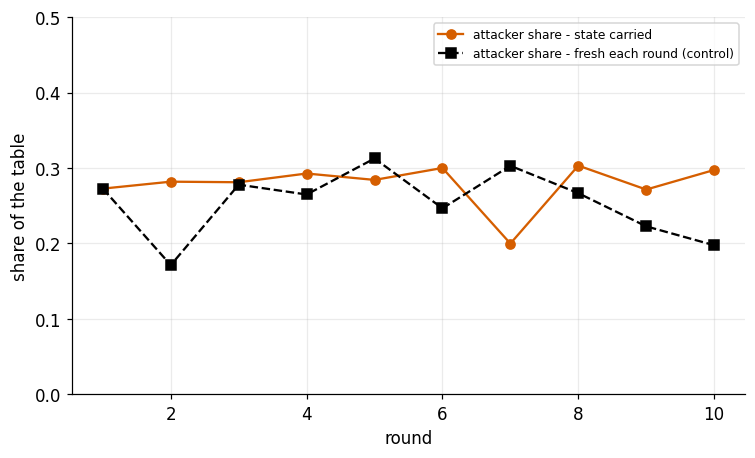


carried minus fresh, attacker share: +0.025 +/- 0.045 (95% CI over rounds; negative = memory helps the defence)
trend of the carried arm: -0.0000 per round
One seed per round: read this as a paired comparison, not as a converged game.


In [46]:
# --- iterated game: both sides adapt, and remember -------------------------- #
# Each round is a fresh 60 s of traffic.  In the CARRIED arm the defence keeps
# its automata (probabilities AND reward estimates) from round to round, and the
# attacker (A4) keeps the threshold it inferred and re-probes the defence as it
# now is at the start of every round.  In the FRESH arm nothing is remembered.
# Both arms use the same seed in each round, so the difference is paired.
ROUNDS = 6 if SCALE == "demo" else 10
GAME = CFGS.merged({"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                    "detection": {"detector": "la_detect"},
                    "attacker": {"kind": "A4", "rate_pps": 300,
                                 "target_entries": CFG.sim.capacity}})

def play(carry: bool) -> pd.DataFrame:
    rows, T, H, mem = [], None, None, {}
    for rd in range(1, ROUNDS + 1):
        seed = BASE_SEED + 100 + rd
        if carry and T is not None:
            sim = Simulator(GAME, seed, timeout_factory=lambda c, g: T,
                            threshold_factory=lambda c, g: H, attacker_carry=mem)
        else:
            sim = Simulator(GAME, seed)
        r = sim.run()
        if carry:
            T, H = sim.timeout_policy, sim.threshold_policy
            mem = {"inferred_threshold": getattr(sim.attacker, "inferred_threshold", None),
                   "_setpoint": getattr(sim.attacker, "_setpoint", None)}
        rows.append({"round": rd, "attacker_occ": float(np.mean(r.occ_attack)),
                     "total_occ": r.mean_occ,
                     "la_entropy_end": float(r.la_a_entropy[-1]) if r.la_a_entropy else np.nan,
                     "benign_evict": r.benign_eviction_rate})
    return pd.DataFrame(rows)

gm_c, gm_f = play(True), play(False)
gm = gm_c.merge(gm_f, on="round", suffixes=("_carried", "_fresh"))
print("\n--- iterated adversarial game (same seed per round in both arms) ---")
print(gm[["round", "attacker_occ_carried", "attacker_occ_fresh",
          "la_entropy_end_carried", "la_entropy_end_fresh"]].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(gm["round"], gm.attacker_occ_carried, marker="o", color=CB[3],
        label="attacker share - state carried")
ax.plot(gm["round"], gm.attacker_occ_fresh, marker="s", ls="--", color=CB[7],
        label="attacker share - fresh each round (control)")
ax.set_xlabel("round"); ax.set_ylabel("share of the table")
ax.set_ylim(0, max(0.5, float(gm[["attacker_occ_carried", "attacker_occ_fresh"]].max().max()) * 1.3))
ax.legend(fontsize=8)
finish(fig, "fig29_iterated_game", f"iterated game over {ROUNDS} rounds: memory against no memory")

d = gm.attacker_occ_carried - gm.attacker_occ_fresh
dm, dci = mean_ci95(d.values)
sl = np.polyfit(gm["round"], gm.attacker_occ_carried, 1)[0]
print(f"\ncarried minus fresh, attacker share: {dm:+.3f} +/- {dci:.3f} (95% CI over rounds; "
      f"negative = memory helps the defence)")
print(f"trend of the carried arm: {sl:+.4f} per round")
print("One seed per round: read this as a paired comparison, not as a converged game.")


In [47]:
# Reading the result -- written from the numbers above
say(
    f"**Iterated game.** With memory on both sides, the attacker's share of the table differs "
    f"from the no-memory control by {dm:+.3f} ± {dci:.3f} per round (paired over "
    f"{len(gm)} rounds). "
    + ("That interval includes zero: over this many rounds, remembering helps neither side "
       "measurably, so any advantage in the single-shot experiments is not just a "
       "first-mover effect that memory would erase."
       if abs(dm) <= dci else
       ("Memory helps the defence: what the automata learned in earlier rounds carries over."
        if dm < 0 else
        "Memory helps the attacker: what it learned about the defence carries over, and the "
        "defence's learning does not keep up.")),
)


**Iterated game.** With memory on both sides, the attacker's share of the table differs from the no-memory control by +0.025 ± 0.045 per round (paired over 10 rounds). That interval includes zero: over this many rounds, remembering helps neither side measurably, so any advantage in the single-shot experiments is not just a first-mover effect that memory would erase.

## Every result in one table

The cell below collects the headline number of every section and appendix, and
lists the figures saved for the paper. Nothing here is computed for the first
time: each row points at the section that produced it.


In [48]:
# --- every headline number, and the figures ------------------------------- #
_e = inf_df[inf_df.probe == "binary"].set_index("policy")
_ben = {n: ctrl[n]["benign_expired"] for n in ctrl}
_bm = piv_m.mean(axis=1)
_ovr = ov.set_index("config")
_acc = dd.groupby("detector")["accuracy"].mean()
_f1 = dd.groupby("detector")["f1"].mean(); _fpr = dd.groupby("detector")["fpr"].mean()
rows = [
 ["Timing side channel (§15)", "RTT of a hit vs a miss",
  f"{np.mean([r for w_, r, m_ in probe_rows if not m_]):.2f} ms vs "
  f"{np.mean([r for w_, r, m_ in probe_rows if m_]):.2f} ms"],
 ["Attacker's inference (§16)", "timeout inference error, binary search: T0 / T1 / T3",
  f"{_e.loc['T0','rel_error']:.1%} / {_e.loc['T1','rel_error']:.1%} / {_e.loc['T3','rel_error']:.1%}"],
 ["Security (§17)", "min attack rate: no defence / best fixed / T1 / T3 (pps)",
  f"{ref_nodef['min_attack_rate']:.0f} / {bf['min_attack_rate']:.0f} ({best_fixed}) / "
  f"{t1['min_attack_rate']:.0f} ± {t1['ci95']:.0f} / {t3['min_attack_rate']:.0f} ± {t3['ci95']:.0f}"],
 ["Cost (§18)", "benign expiries, no attacker: fixed 2 s / T1 / T3",
  f"{_ben['fixed 2s']:.0f} / {_ben['T1 uniform']:.0f} / {_ben['T3 automata']:.0f}"],
 ["Learning vs uniform (§17)", "T3 minus T1, paired over seeds: rate / expiries",
  f"{_dr[0]:+.1f} ± {_dr[1]:.1f} pps / {_dc[0]:+.0f} ± {_dc[1]:.0f}"],
 ["LA-A learns (§19)", "differs from the noise control, in the expected direction",
  f"{len(_learned)} of 4 situations" if _learned else "not established"],
 ["Detection (§20)", "LA-DETECT accuracy / F1 / FPR",
  f"{_acc['la_detect']:.1%} / {_f1['la_detect']:.3f} / {_fpr['la_detect']:.1%}"],
 ["Detection (§20)", "learned minus hand-set, balanced accuracy, paired over seeds",
  f"{_dl[0]:+.3f} ± {_dl[1]:.3f}"],
 ["Detection cost (§20)", "learned numbers / state per flow / time per decision round",
  f"{len(TEAM_SPACE)} / 1 float / {dd[dd.detector=='la_detect'].ms_per_epoch.mean():.2f} ms"],
 ["Threshold mechanism (§22)", "A2's error in locating the threshold: H0 / H1 / H2",
  " / ".join(f"{thr_df[thr_df.threshold_policy==h].rel_error.mean():.1%}" for h in ("H0","H1","H2"))],
 ["Full defence (§23)", "sustained occupancy A1 / A2 / A3 / A4",
  " / ".join(f"{v:.3f}" for v in adv.sustained_occ)],
 ["Sensitivity (§24)", "parameter with the widest spread of the headline metric",
  (lambda g: f"{g.idxmax()} ({g.max():.0f} pps)")(
      sens.groupby("parameter").min_attack_rate.agg(lambda v: v.max() - v.min()))],
 ["Overhead (§25)", "packet-in / s, no attacker: no defence vs full defence",
  f"{_ovr.loc['no defence','packet_ins_per_s']:.1f} vs "
  f"{_ovr.loc['full defence','packet_ins_per_s']:.1f} ({_pin:+.1%})"],
 ["Predictability (Appendix A)", "calibration: constant / alternating / uniform random",
  f"{calib['constant'].score:.3f} / {calib['alternating'].score:.3f} / {calib['uniform'].score:.3f}"],
 ["Predictability (Appendix A)", "r(predictability, security) vs r(shortest candidate, security)",
  f"{r_pear:+.2f} vs {np.corrcoef(fr.min_timeout_s, fr.min_attack_rate)[0,1]:+.2f}"],
 ["LOFT-Bench (Appendix B)", "mean sustained occupancy: no defence / naive MTD / both LA / full",
  f"{_bm['no_defense']:.3f} / {_bm['naive_mtd']:.3f} / {_bm['both_la']:.3f} / {_bm['full_two_layer']:.3f}"],
 ["Iterated game (Appendix C)", "attacker share, memory minus no memory",
  f"{dm:+.3f} ± {dci:.3f} over {len(gm)} rounds"],
]
display(Markdown("\n".join([
    "## Every result in one table", "",
    f"*Scale `{SCALE}`, {len(SEEDS)} seeds, 95% Student-t intervals.*", "",
    md_table(["section", "metric", "result"], rows)])))

import shutil
_zip = shutil.make_archive("LOFT_MTD_LA_figures", "zip", FIG_DIR)
display(Markdown("\n".join(["## Figures for the paper", "",
    f"{len(FIGS)} figures, each drawn on its own and with no title inside the image, saved as a "
    f"300-dpi PNG and a vector PDF in `{FIG_DIR}/` and zipped into "
    f"`{os.path.basename(_zip)}` (in Colab: Files panel, right-click, Download).", "",
    md_table(["file", "what it shows"], [[f"`{n}.png`", w_] for n, w_ in FIGS])])))


## Every result in one table

*Scale `full`, 32 seeds, 95% Student-t intervals.*

| section | metric | result |
|---|---|---|
| Timing side channel (§15) | RTT of a hit vs a miss | 0.10 ms vs 4.67 ms |
| Attacker's inference (§16) | timeout inference error, binary search: T0 / T1 / T3 | 0.6% / 23.8% / 25.2% |
| Security (§17) | min attack rate: no defence / best fixed / T1 / T3 (pps) | 99 / 518 (fixed 2s) / 273 ± 6 / 269 ± 6 |
| Cost (§18) | benign expiries, no attacker: fixed 2 s / T1 / T3 | 4581 / 3453 / 3434 |
| Learning vs uniform (§17) | T3 minus T1, paired over seeds: rate / expiries | -4.4 ± 3.7 pps / -19 ± 5 |
| LA-A learns (§19) | differs from the noise control, in the expected direction | 3 of 4 situations |
| Detection (§20) | LA-DETECT accuracy / F1 / FPR | 92.9% / 0.928 / 13.2% |
| Detection (§20) | learned minus hand-set, balanced accuracy, paired over seeds | +0.096 ± 0.001 |
| Detection cost (§20) | learned numbers / state per flow / time per decision round | 5 / 1 float / 0.12 ms |
| Threshold mechanism (§22) | A2's error in locating the threshold: H0 / H1 / H2 | 4.4% / 4.5% / 5.1% |
| Full defence (§23) | sustained occupancy A1 / A2 / A3 / A4 | 0.618 / 0.632 / 0.679 / 0.688 |
| Sensitivity (§24) | parameter with the widest spread of the headline metric | capacity (441 pps) |
| Overhead (§25) | packet-in / s, no attacker: no defence vs full defence | 70.3 vs 71.5 (+1.8%) |
| Predictability (Appendix A) | calibration: constant / alternating / uniform random | 1.000 / 0.898 / 0.024 |
| Predictability (Appendix A) | r(predictability, security) vs r(shortest candidate, security) | -0.11 vs -0.83 |
| LOFT-Bench (Appendix B) | mean sustained occupancy: no defence / naive MTD / both LA / full | 0.951 / 0.784 / 0.775 / 0.623 |
| Iterated game (Appendix C) | attacker share, memory minus no memory | +0.025 ± 0.045 over 10 rounds |

## Figures for the paper

29 figures, each drawn on its own and with no title inside the image, saved as a 300-dpi PNG and a vector PDF in `figures/` and zipped into `LOFT_MTD_LA_figures.zip` (in Colab: Files panel, right-click, Download).

| file | what it shows |
|---|---|
| `fig01_architecture.png` | the two-layer defence as simulated: MTD in the control plane, LA-DETECT in the detection layer |
| `fig02_training_and_validation.png` | LA-DETECT training: the team's reward, and its leading values scored on training and validation flows |
| `fig03_team_convergence.png` | LA-DETECT training: convergence of each team member |
| `fig04_inference_error.png` | timeout inference error per policy and probe algorithm |
| `fig05_security_per_policy.png` | security forced by each timeout policy (min attack rate, higher = better) |
| `fig06_cost_per_policy.png` | collateral cost of each timeout policy (benign expiries, lower = better) |
| `fig07_security_cost_frontier.png` | security against collateral cost per timeout policy (up and left is better) |
| `fig08_la_probabilities_over_time.png` | LA-A probability of each timeout candidate over one run under attack (A1) |
| `fig09_la_entropy_vs_floor.png` | entropy of LA-A and LA-B in the same run, against each entropy floor |
| `fig10_la_learned_distribution.png` | what LA-A ends up preferring in each condition, against the noise control |
| `fig11_detection_quality.png` | detection quality of the four detectors (attack A1, 95% CI over seeds) |
| `fig12_la_roles.png` | contribution of each LA role (2x2, mitigation on in every cell) |
| `fig13_feature_importance.png` | what each observed feature contributes to LA-DETECT: learned weight, and the loss when it is removed |
| `fig14_occupancy_undefended.png` | flow-table occupancy over time, undefended (T0 fixed, no mitigation), attack A1 |
| `fig15_occupancy_defended.png` | flow-table occupancy over time, full defence (T3 + H2 + LA-DETECT), attack A1 |
| `fig16_threshold_inference_error.png` | error of attacker A2 in locating the mitigation threshold, per threshold policy |
| `fig17_mechanism_comparison.png` | sustained occupancy with M1 alone, M2 alone and both, against A1 and A2 |
| `fig18_adaptive_attackers.png` | sustained and peak occupancy for attackers A1-A4 against the full defence |
| `fig19_sensitivity_capacity.png` | sensitivity of the min attack rate to capacity |
| `fig20_sensitivity_arrival_fps.png` | sensitivity of the min attack rate to benign arrival_fps |
| `fig21_sensitivity_idle_frac.png` | sensitivity of the min attack rate to benign idle_frac |
| `fig22_sensitivity_a.png` | sensitivity of the min attack rate to LA rate a |
| `fig23_sensitivity_h_min_frac.png` | sensitivity of the min attack rate to entropy floor frac |
| `fig24_controller_cost.png` | standing controller cost of each defence, no attacker |
| `fig25_predictability_vs_security.png` | security against PredictabilityScore across the intensity sweep (labels: shortest candidate) |
| `fig26_intensity_sweep.png` | what moves with mutation intensity: predictability, security, shortest candidate |
| `fig27_bench_sustained_occupancy.png` | LOFT-Bench: sustained (mean) occupancy per configuration and scenario (primary) |
| `fig28_bench_peak_occupancy.png` | LOFT-Bench: peak occupancy per configuration and scenario (saturates) |
| `fig29_iterated_game.png` | iterated game over 10 rounds: memory against no memory |

## Appendix D. The defence on a real OpenFlow stack: Ryu and Open vSwitch

*Everything above runs in the simulator. This appendix moves the defence into a real controller.*

The defence is written as a **Ryu application for OpenFlow 1.3**. The automata live in one module, `la_core.py`, which does not import Ryu. The application, `la_mtd_controller.py`, only turns OpenFlow events into calls on that module:

| step of the defence | OpenFlow event / message in Ryu |
|---|---|
| a new flow arrives; LA-A draws its idle timeout | `EventOFPPacketIn` → `OFPFlowMod` (5-tuple match, `idle_timeout = τ`, `OFPFF_SEND_FLOW_REM`, `cookie = rule id`) + `OFPPacketOut` |
| a rule expires; its candidate is remembered | `EventOFPFlowRemoved` with reason `OFPRR_IDLE_TIMEOUT` |
| every epoch (Δ = 1 s) | a `hub.spawn` thread sends `OFPFlowStatsRequest` to every switch |
| LA-DETECT, LA-A credit, occupancy, LA-B | `EventOFPFlowStatsReply` (multipart), from `packet_count` and `duration` of every rule |
| mitigation | `OFPFlowMod(command=OFPFC_DELETE, cookie=rule id, cookie_mask=all ones)` for each flagged rule |

Three things are different on a real switch, and the code says so where it matters:

1. **Gap regularity is not observable.** OpenFlow flow statistics carry counters, not packet times, so a controller cannot compute the regularity feature of §8. The learned detector gives it weight 0 (§14), so nothing is lost; the core feeds it the neutral value 0.5.
2. **LA-B's collateral term.** In the simulator, the share of benign rules among those mitigation evicted comes from ground truth. The controller replaces it with an observable proxy: the share of evicted rules whose match comes back as a packet-in within 1 s (an active flow does; a refresher does not).
3. **Silent evictions.** When its table is full, Open vSwitch evicts the rule closest to expiry without sending `FLOW_REMOVED` under OpenFlow 1.3. The core treats a rule that is missing from a stats reply as evicted by the switch.

**The cells below, in order.** The first nine write the application and the testbed to `ryu_la_mtd/`: the defence core, the Ryu application, the traffic generator, the Mininet testbed, the script with every run of the paper, the analysis script, the scalability benchmark and the script that repeats the checks of §12 on the switch's logs. The next cell checks that the controller core makes **exactly** the same updates as the simulator's classes. The last one shows the testbed results, including the optional second stage of Appendix E (part 3), the checks on the switch, and runs the scalability benchmark.

The testbed needs root, Mininet, Open vSwitch and Ryu 4.34 (Python 3.9 with `eventlet==0.30.2`), which Colab does not provide. The last cell therefore shows the numbers of the runs we made, and repeats the runs only when `RUN_TESTBED = True` on a machine that has all of these. To run it by hand:

```
sudo /usr/share/openvswitch/scripts/ovs-ctl start     # Open vSwitch
cd ryu_la_mtd
sudo RYU_MANAGER=/path/to/venv39/bin/ryu-manager bash run_all.sh     # about 50 minutes
python3 analyze_testbed.py              # writes runs/summary.json
python3 validity_testbed.py             # writes runs/validity.json
```


In [ ]:
# Appendix D, step 1: write the Ryu application and the testbed scripts to ./ryu_la_mtd/
import os
os.makedirs("ryu_la_mtd", exist_ok=True)
print("files go to", os.path.abspath("ryu_la_mtd"))


files go to /content/ryu_la_mtd


In [ ]:
%%writefile ryu_la_mtd/la_core.py
"""Defence logic of the LA-MTD controller, independent of Ryu.

The same three automata as the simulator (LA-A, LA-B, LA-DETECT), written so
that a Ryu application only has to feed them OpenFlow events:

    new_rule(key, now)            -> (rule_id, idle_timeout)   on PacketIn
    rule_removed(rule_id, reason, now)                          on FLOW_REMOVED
    epoch(stats, now)             -> list of rule_ids to evict  on FlowStatsReply

Everything here uses only what an OpenFlow 1.3 controller can observe:
packet-ins, FLOW_REMOVED messages, per-rule packet counters and durations from
flow-statistics polling, and the verdicts of its own detection layer.
"""
from __future__ import annotations

import math
import time
from dataclasses import dataclass, field
from typing import Dict, Hashable, List, Optional, Tuple

import numpy as np


# ----------------------------------------------------------------- config --
@dataclass
class CoreConfig:
    capacity: int = 1800                      # flow-table size the defence plans for
    epoch_s: float = 1.0
    # LA-A (idle timeout) and LA-B (threshold) candidates
    timeout_candidates: Tuple[int, ...] = (2, 4, 6, 8, 10, 12, 14, 16, 18, 20)
    threshold_candidates: Tuple[float, ...] = (0.70, 0.725, 0.75, 0.775, 0.80, 0.825, 0.85, 0.875, 0.90)
    timeout_policy: str = "la"                # "la" | "fixed" | "uniform"
    fixed_timeout: int = 10
    threshold_policy: str = "la"              # "la" | "fixed" | "uniform"
    fixed_threshold: float = 0.80
    # automaton constants (as in the simulator)
    a: float = 0.08
    epsilon: float = 0.10
    h_min_frac: float = 0.55
    decay: float = 0.90
    prior_w: float = 1.0
    tie_tol: float = 0.01
    reinstall_window_s: float = 30.0
    target_occ_lo: float = 0.40
    target_occ_hi: float = 0.70
    w_occupancy: float = 0.4
    w_benign_evict: float = 0.4
    w_packetin: float = 0.2
    packetin_spike_ref: float = 3.0
    baseline_packetin_rate: float = 70.0      # expected benign new flows per second
    benign_cost_weight: float = 1.0
    quick_return_s: float = 1.0               # observable proxy for a wrongly evicted benign rule
    quick_return_exempt_s: float = 0.0        # >0: a match that returns that fast is spared this long
    # LA-DETECT (learned values from the team of automata)
    detector: bool = True
    w_low: float = 1.0
    w_reg: float = 0.0
    w_age: float = 0.25
    gate: float = 0.5
    theta: float = 0.65
    ref_rate_pps: float = 15.0
    ref_age_s: float = 30.0
    # optional second stage: boosted trees that re-check flagged rules, only when mitigation acts
    second_stage: str = ""                    # path of a joblib file {"model", "thr"}; "" = off
    seed: int = 1


# -------------------------------------------------------------- automaton --
class PursuitAutomaton:
    """Estimator automaton with generalised pursuit, uniform mixing and an
    entropy floor (Section IV-B of the paper)."""

    def __init__(self, values, a, epsilon, h_min_frac, decay, prior_w, tie_tol, rng):
        self.values = np.asarray(values, dtype=float)
        r = len(self.values)
        self.r = r
        self.a, self.eps = float(a), float(epsilon)
        self.h_min = float(h_min_frac) * math.log(r)
        self.decay, self.prior_w, self.tie_tol = float(decay), float(prior_w), float(tie_tol)
        self.rng = rng
        self.p = np.full(r, 1.0 / r)
        self.u = np.full(r, 1.0 / r)
        self.S = np.zeros(r)
        self.W = np.zeros(r)

    # distributions
    def p_eff(self) -> np.ndarray:
        return (1.0 - self.eps) * self.p + self.eps * self.u

    def entropy(self) -> float:
        q = self.p_eff()
        q = q[q > 0]
        return float(-(q * np.log(q)).sum())

    def sample_index(self) -> int:
        c = np.cumsum(self.p_eff())
        return int(np.searchsorted(c, self.rng.random() * c[-1]))

    # learning
    def observe(self, action: int, reward: float, weight: float = 1.0) -> None:
        if action is None or action < 0 or weight <= 0:
            return
        self.S[action] += weight * min(max(reward, 0.0), 1.0)
        self.W[action] += weight

    def estimates(self) -> np.ndarray:
        return (self.S + 0.5 * self.prior_w) / (self.W + self.prior_w)

    def end_epoch(self) -> None:
        if self.W.sum() > 0:
            e = self.estimates()
            best = np.flatnonzero(e >= e.max() - self.tie_tol)
            target = np.zeros(self.r)
            target[best] = 1.0 / best.size
            p = (1.0 - self.a) * self.p + self.a * target
            self.p = np.clip(p, 0.0, None) / p.sum()
            for _ in range(200):                     # entropy floor
                if self.entropy() >= self.h_min - 1e-12:
                    break
                self.p = 0.90 * self.p + 0.10 * self.u
                self.p /= self.p.sum()
        self.S *= self.decay
        self.W *= self.decay


# ------------------------------------------------------------------- rules --
@dataclass
class Rule:
    rule_id: int
    key: Hashable
    cand: int                 # index of the LA-A candidate that gave the timeout (-1 if not LA)
    timeout: int
    installed: float
    last_count: int = 0
    p: float = 0.5            # LA-DETECT state
    flagged: bool = False
    seen: bool = False        # has appeared in at least one stats reply
    n_obs: int = 0            # epochs observed (second-stage features)
    fwd_sum: float = 0.0      # sum of (1 - x_low) over those epochs
    x_low: float = 0.0
    x_age: float = 0.0


@dataclass
class EpochReport:
    t: float
    occupancy: float
    threshold: float
    n_rules: int
    n_flagged: int
    evict_ids: List[int]
    reward: float
    packet_ins: int
    la_a_entropy: float
    la_b_entropy: float
    la_a_peff: List[float] = field(default_factory=list)
    proc_ms: float = 0.0
    s2_checked: List[int] = field(default_factory=list)    # rule ids the second stage examined
    s2_cleared: List[int] = field(default_factory=list)    # ... and spared
    s2_ms: float = 0.0


class DefenceCore:
    """One instance per switch (datapath)."""

    def __init__(self, cfg: CoreConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        c = cfg
        self.la_a = PursuitAutomaton(c.timeout_candidates, c.a, c.epsilon, c.h_min_frac, c.decay,
                                     c.prior_w, c.tie_tol, self.rng)
        self.la_b = PursuitAutomaton(c.threshold_candidates, c.a, c.epsilon, c.h_min_frac, c.decay,
                                     c.prior_w, c.tie_tol, self.rng)
        self.rules: Dict[int, Rule] = {}
        self.by_key: Dict[Hashable, int] = {}
        self._next_id = 1
        self._recent_exp: Dict[Hashable, Tuple[float, int]] = {}     # key -> (expiry time, candidate)
        self._suspect: Dict[Hashable, bool] = {}                     # last verdict per match
        self._evicted_at: Dict[Hashable, float] = {}                 # mitigation evictions
        self._exempt_until: Dict[Hashable, float] = {}               # matches spared by mitigation
        self._quick_returns = 0
        self._evicted_last = 0
        self._pending_b: Optional[int] = None
        self.b_idx = self._draw_threshold()
        self.threshold = self._threshold_value()
        self._packet_ins = 0
        self.counters = {"installs": 0, "idle_expiries": 0, "evictions": 0, "switch_evictions": 0,
                         "suspicious_reinstall": 0, "suspicious_refreshed": 0, "benign_reinstall": 0}
        self.second = None
        if cfg.second_stage:
            import joblib                                           # only needed for the second stage
            self.second = joblib.load(cfg.second_stage)

    # ------------------------------------------------------------ policies --
    def _draw_timeout(self) -> Tuple[int, int]:
        c = self.cfg
        if c.timeout_policy == "fixed":
            return -1, int(c.fixed_timeout)
        if c.timeout_policy == "uniform":
            return -1, int(round(self.rng.uniform(min(c.timeout_candidates), max(c.timeout_candidates))))
        i = self.la_a.sample_index()
        return i, int(c.timeout_candidates[i])

    def _draw_threshold(self) -> int:
        if self.cfg.threshold_policy == "la":
            return self.la_b.sample_index()
        return -1

    def _threshold_value(self) -> float:
        c = self.cfg
        if c.threshold_policy == "fixed":
            return c.fixed_threshold
        if c.threshold_policy == "uniform":
            return float(self.rng.uniform(min(c.threshold_candidates), max(c.threshold_candidates)))
        return float(c.threshold_candidates[self.b_idx])

    def pressure(self, occ: float) -> float:
        hi = self.cfg.target_occ_hi
        return min(1.0, max(0.0, (occ - hi) / max(1.0 - hi, 1e-6)))

    # -------------------------------------------------------------- events --
    def new_rule(self, key: Hashable, now: float, occupancy: float) -> Tuple[int, int]:
        """PacketIn for a match with no rule: choose the idle timeout (LA-A),
        credit the candidate of a rule of the same match that expired recently."""
        self._packet_ins += 1
        ev = self._evicted_at.pop(key, None)
        if ev is not None and now - ev <= self.cfg.quick_return_s:
            self._quick_returns += 1
            if self.cfg.quick_return_exempt_s > 0:
                # an active flow came straight back: do not evict it again for a while
                self._exempt_until[key] = now + self.cfg.quick_return_exempt_s
        rec = self._recent_exp.pop(key, None)
        if rec is not None and now - rec[0] <= self.cfg.reinstall_window_s and rec[1] >= 0:
            if self._suspect.get(key, False):
                w = self.pressure(occupancy)
                if w > 0:
                    self.la_a.observe(rec[1], 1.0, w)
                self.counters["suspicious_reinstall"] += 1
            else:
                self.la_a.observe(rec[1], 0.0, self.cfg.benign_cost_weight)
                self.counters["benign_reinstall"] += 1
        cand, tau = self._draw_timeout()
        rid = self._next_id
        self._next_id += 1
        self.rules[rid] = Rule(rid, key, cand, tau, now)
        self.by_key[key] = rid
        self.counters["installs"] += 1
        return rid, tau

    def rule_removed(self, rule_id: int, reason: str, now: float) -> None:
        """FLOW_REMOVED: reason is 'idle', 'hard', 'delete' (ours) or 'evict' (switch)."""
        r = self.rules.pop(rule_id, None)
        if r is None:
            return
        if self.by_key.get(r.key) == rule_id:
            del self.by_key[r.key]
        if reason == "idle":
            self._recent_exp[r.key] = (now, r.cand)
            self.counters["idle_expiries"] += 1
        elif reason == "evict":
            self.counters["switch_evictions"] += 1

    # --------------------------------------------------------------- epoch --
    def epoch(self, stats: List[Tuple[int, int, float]], now: float) -> EpochReport:
        """stats: (rule_id, packet_count, duration_s) for every rule the switch
        reported.  Returns the report with the rule ids to evict."""
        c = self.cfg
        present = []
        for rid, pkts, dur in stats:
            r = self.rules.get(rid)
            if r is None:
                continue
            present.append((r, pkts, dur))
        occ = len(present) / float(c.capacity)
        # rules the switch no longer reports and that did not leave through a
        # FLOW_REMOVED message were evicted by the switch itself (OVS does this
        # silently under OpenFlow 1.3 when the table is full)
        seen_ids = {r.rule_id for r, _, _ in present}
        gone = [r for rid, r in self.rules.items()
                if rid not in seen_ids and now - r.installed > 1.5 * c.epoch_s]
        for r in gone:
            self.rule_removed(r.rule_id, "evict", now)
        # 1. reward of the epoch that ended; credit LA-B for the threshold that acted
        benign_frac = (self._quick_returns / self._evicted_last) if self._evicted_last else 0.0
        pin_ratio = (self._packet_ins / c.epoch_s) / max(c.baseline_packetin_rate, 1e-6)
        reward = self._reward(occ, benign_frac, pin_ratio)
        if c.threshold_policy == "la" and self._pending_b is not None:
            self.la_b.observe(self._pending_b, reward, 1.0)
            self.la_b.end_epoch()
        # 2-3. LA-DETECT update and verdicts
        wsum = max(c.w_low + c.w_reg + c.w_age, 1e-9)
        w = self.pressure(occ)
        n_flag = 0
        for r, pkts, dur in present:
            d = pkts - r.last_count if r.seen else pkts
            refreshed = r.seen and d > 0
            if c.detector:
                x_low = min(1.0, max(0.0, 1.0 - d / (c.ref_rate_pps * c.epoch_s)))
                x_age = min(1.0, max(0.0, dur / c.ref_age_s))
                beta = (c.w_low * x_low + c.w_reg * 0.5 + c.w_age * x_age) / wsum
                r.p += c.gate * (beta - r.p)
                r.flagged = r.p > c.theta
                r.n_obs += 1
                r.fwd_sum += 1.0 - x_low
                r.x_low, r.x_age = x_low, x_age
            # 4. LA-A: a flagged rule refreshed in time -> its candidate was long enough
            if c.timeout_policy == "la" and r.flagged and refreshed and r.cand >= 0:
                if w > 0:
                    self.la_a.observe(r.cand, 0.0, w)
                self.counters["suspicious_refreshed"] += 1
            self._suspect[r.key] = r.flagged
            r.last_count, r.seen = pkts, True
            n_flag += int(r.flagged)
        if c.timeout_policy == "la":
            self.la_a.end_epoch()
        horizon = now - c.reinstall_window_s
        if len(self._recent_exp) > 4 * c.capacity:
            self._recent_exp = {k: v for k, v in self._recent_exp.items() if v[0] >= horizon}
        # 5. mitigation
        evict, checked, cleared, s2_ms = [], [], [], 0.0
        if c.detector and occ >= self.threshold:
            evict = [r.rule_id for r, _, _ in present
                     if r.flagged and self._exempt_until.get(r.key, -1.0) < now]
            if self.second is not None and evict:
                # second stage: only now, only on the rules mitigation is about to remove
                tic = time.perf_counter()
                rs = [self.rules[rid] for rid in evict]
                X = np.array([[r.x_low, r.x_age, r.fwd_sum / max(r.n_obs, 1), r.n_obs / 60.0] for r in rs])
                keep = self.second["model"].predict_proba(X)[:, 1] > self.second["thr"]
                checked = evict
                cleared = [rid for rid, k in zip(evict, keep) if not k]
                evict = [rid for rid, k in zip(evict, keep) if k]
                s2_ms = (time.perf_counter() - tic) * 1e3
            for rid in evict:
                self._evicted_at[self.rules[rid].key] = now
            self.counters["evictions"] += len(evict)
        self._evicted_last = len(evict)
        self._quick_returns = 0
        stale = [k for k, t in self._evicted_at.items() if now - t > c.quick_return_s + c.epoch_s]
        for k in stale:
            del self._evicted_at[k]
        if len(self._exempt_until) > 4 * c.capacity:
            self._exempt_until = {k: t for k, t in self._exempt_until.items() if t >= now}
        # 6. next threshold
        self._pending_b = self.b_idx if c.threshold_policy == "la" else None
        thr_used = self.threshold
        self.b_idx = self._draw_threshold()
        self.threshold = self._threshold_value()
        rep = EpochReport(now, occ, thr_used, len(present), n_flag, evict, reward, self._packet_ins,
                          self.la_a.entropy(), self.la_b.entropy(), self.la_a.p_eff().round(4).tolist())
        rep.gone_keys = [r.key for r in gone]
        rep.s2_checked, rep.s2_cleared, rep.s2_ms = checked, cleared, s2_ms
        self._packet_ins = 0
        return rep

    def _reward(self, occ: float, benign_frac: float, pin_ratio: float) -> float:
        c = self.cfg
        if occ < c.target_occ_lo:
            ot = 1.0 - (c.target_occ_lo - occ) / max(c.target_occ_lo, 1e-6)
        elif occ > c.target_occ_hi:
            ot = 1.0 - (occ - c.target_occ_hi) / max(1.0 - c.target_occ_hi, 1e-6)
        else:
            ot = 1.0
        ot = min(1.0, max(0.0, ot))
        bt = min(1.0, max(0.0, 1.0 - benign_frac))
        pt = min(1.0, max(0.0, 1.0 - (pin_ratio - 1.0) / max(c.packetin_spike_ref - 1.0, 1e-6)))
        s = c.w_occupancy + c.w_benign_evict + c.w_packetin
        return (c.w_occupancy * ot + c.w_benign_evict * bt + c.w_packetin * pt) / s


Writing ryu_la_mtd/la_core.py


In [ ]:
%%writefile ryu_la_mtd/la_mtd_controller.py
"""LA-MTD: a Ryu (OpenFlow 1.3) application that runs the learning-automata
moving target defence against low-rate flow-table overflow (LOFT) attacks.

    ryu-manager la_mtd_controller.py            # config from LA_MTD_CONFIG (JSON file)

Event handlers
  * EventOFPSwitchFeatures : table-miss rule, drop rules for ICMP and IPv6 noise
  * EventOFPPacketIn       : LA-A draws the idle timeout of the new rule -> OFPFlowMod
  * EventOFPFlowRemoved    : idle expiries are logged for LA-A's credit assignment
  * epoch thread (hub)     : every epoch, OFPFlowStatsRequest to every switch
  * EventOFPFlowStatsReply : LA-DETECT updates every rule, LA-A / LA-B learn,
                             and if occupancy >= threshold the flagged rules are
                             deleted with OFPFC_DELETE (by cookie)

One DefenceCore (la_core.py) per datapath, so several switches are defended
independently.  Each rule carries a unique cookie that maps it back to the
LA-A candidate that chose its timeout.
"""
import json
import os
import time

from ryu.base import app_manager
from ryu.controller import ofp_event
from ryu.controller.handler import CONFIG_DISPATCHER, MAIN_DISPATCHER, DEAD_DISPATCHER, set_ev_cls
from ryu.lib import hub
from ryu.lib.packet import packet, ethernet, ipv4, udp, tcp, ether_types
from ryu.ofproto import ofproto_v1_3

from la_core import CoreConfig, DefenceCore

RULE_PRIORITY = 10
COOKIE_MASK = 0xFFFFFFFFFFFFFFFF


def _load_config():
    path = os.environ.get("LA_MTD_CONFIG")
    raw = {}
    if path and os.path.exists(path):
        with open(path) as f:
            raw = json.load(f)
    core_fields = {k: v for k, v in raw.get("core", {}).items() if k in CoreConfig.__dataclass_fields__}
    for k in ("timeout_candidates", "threshold_candidates"):
        if k in core_fields:
            core_fields[k] = tuple(core_fields[k])
    return CoreConfig(**core_fields), raw.get("log_path", "la_mtd_epochs.jsonl"), raw.get("ground_truth", {})


class LAMTDController(app_manager.RyuApp):
    OFP_VERSIONS = [ofproto_v1_3.OFP_VERSION]

    def __init__(self, *args, **kwargs):
        super(LAMTDController, self).__init__(*args, **kwargs)
        self.cfg, self.log_path, self.truth = _load_config()
        self.datapaths = {}
        self.cores = {}                 # dpid -> DefenceCore
        self.ip_to_port = {}            # dpid -> {ipv4: port}
        self.pending = {}               # dpid -> {key: time}  (rule being installed)
        self.stats_buf = {}             # dpid -> list of stats entries (multipart)
        self.stats_sent = {}            # dpid -> time the request left
        self.last_removed = {}          # dpid -> {key: (time, cause)} for re-install accounting
        self.pin_src = {}               # dpid -> {source: packet-ins this epoch}  (logged for scoring)
        self.errors = {}                # dpid -> OpenFlow error messages this epoch (e.g. table full)
        self.t0 = time.time()
        self.log = open(self.log_path, "w")
        self.log.write(json.dumps({"ev": "start", "t0": self.t0}) + "\n")
        self.monitor = hub.spawn(self._epoch_loop)
        self.logger.info("LA-MTD: %s", json.dumps(self.cfg.__dict__, default=list))

    # ------------------------------------------------------------ helpers --
    def now(self):
        return time.time() - self.t0

    def _add_flow(self, dp, priority, match, actions, idle=0, cookie=0, flags=0):
        ofp, parser = dp.ofproto, dp.ofproto_parser
        inst = [parser.OFPInstructionActions(ofp.OFPIT_APPLY_ACTIONS, actions)]
        dp.send_msg(parser.OFPFlowMod(datapath=dp, cookie=cookie, priority=priority, match=match,
                                      instructions=inst, idle_timeout=idle, hard_timeout=0, flags=flags))

    # ---------------------------------------------------------- handshake --
    @set_ev_cls(ofp_event.EventOFPSwitchFeatures, CONFIG_DISPATCHER)
    def switch_features_handler(self, ev):
        dp = ev.msg.datapath
        ofp, parser = dp.ofproto, dp.ofproto_parser
        self._add_flow(dp, 0, parser.OFPMatch(),
                       [parser.OFPActionOutput(ofp.OFPP_CONTROLLER, ofp.OFPCML_NO_BUFFER)])
        # keep ICMP errors and IPv6 neighbour discovery away from the controller
        self._add_flow(dp, 5, parser.OFPMatch(eth_type=0x0800, ip_proto=1), [])
        self._add_flow(dp, 5, parser.OFPMatch(eth_type=0x86DD), [])

    @set_ev_cls(ofp_event.EventOFPStateChange, [MAIN_DISPATCHER, DEAD_DISPATCHER])
    def state_change_handler(self, ev):
        dp = ev.datapath
        if ev.state == MAIN_DISPATCHER:
            self.datapaths[dp.id] = dp
            self.cores.setdefault(dp.id, DefenceCore(self.cfg))
            self.ip_to_port.setdefault(dp.id, {})
            self.pending.setdefault(dp.id, {})
            self.last_removed.setdefault(dp.id, {})
        elif ev.state == DEAD_DISPATCHER:
            self.datapaths.pop(dp.id, None)

    # ----------------------------------------------------------- PacketIn --
    @set_ev_cls(ofp_event.EventOFPPacketIn, MAIN_DISPATCHER)
    def packet_in_handler(self, ev):
        msg = ev.msg
        dp = msg.datapath
        ofp, parser = dp.ofproto, dp.ofproto_parser
        in_port = msg.match["in_port"]
        pkt = packet.Packet(msg.data)
        eth = pkt.get_protocol(ethernet.ethernet)
        ip = pkt.get_protocol(ipv4.ipv4)
        if eth is None or eth.ethertype != ether_types.ETH_TYPE_IP or ip is None:
            return
        ps = self.pin_src.setdefault(dp.id, {})
        ps[ip.src] = ps.get(ip.src, 0) + 1
        ports = self.ip_to_port.setdefault(dp.id, {})
        ports[ip.src] = in_port
        out_port = ports.get(ip.dst, ofp.OFPP_FLOOD)
        l4 = pkt.get_protocol(udp.udp) or pkt.get_protocol(tcp.tcp)
        if l4 is None:
            return
        proto = 17 if isinstance(l4, udp.udp) else 6
        key = (ip.src, ip.dst, proto, l4.src_port, l4.dst_port)
        actions = [parser.OFPActionOutput(out_port)]
        t = self.now()
        pend = self.pending[dp.id]
        if key not in pend or t - pend[key] > 0.5:          # one rule per match, even if packets race
            pend[key] = t
            core = self.cores[dp.id]
            occ = len(core.rules) / float(self.cfg.capacity)
            # LA-A: the idle timeout of this new rule is drawn from its moving distribution
            rid, tau = core.new_rule(key, t, occ)
            gone = self.last_removed[dp.id].pop(key, None)
            if gone is not None and t - gone[0] <= self.cfg.reinstall_window_s:
                # this match lost its rule while its flow was still sending: log why
                self.log.write(json.dumps({"ev": "reinstall", "t": round(t, 3), "cause": gone[1],
                                           "src": ip.src, "after_s": round(t - gone[0], 3)}) + "\n")
            fields = dict(eth_type=0x0800, ip_proto=proto, ipv4_src=ip.src, ipv4_dst=ip.dst)
            fields.update({"udp_src": l4.src_port, "udp_dst": l4.dst_port} if proto == 17
                          else {"tcp_src": l4.src_port, "tcp_dst": l4.dst_port})
            self._add_flow(dp, RULE_PRIORITY, parser.OFPMatch(**fields), actions, idle=tau, cookie=rid,
                           flags=ofp.OFPFF_SEND_FLOW_REM)
        dp.send_msg(parser.OFPPacketOut(datapath=dp, buffer_id=ofp.OFP_NO_BUFFER, in_port=in_port,
                                        actions=actions, data=msg.data))

    @set_ev_cls(ofp_event.EventOFPErrorMsg, MAIN_DISPATCHER)
    def error_handler(self, ev):
        dp = ev.msg.datapath
        key = "%d/%d" % (ev.msg.type, ev.msg.code)
        e = self.errors.setdefault(dp.id, {})
        e[key] = e.get(key, 0) + 1

    # -------------------------------------------------------- FlowRemoved --
    @set_ev_cls(ofp_event.EventOFPFlowRemoved, MAIN_DISPATCHER)
    def flow_removed_handler(self, ev):
        msg = ev.msg
        dp = msg.datapath
        ofp = dp.ofproto
        if msg.cookie == 0 or dp.id not in self.cores:
            return
        reason = {ofp.OFPRR_IDLE_TIMEOUT: "idle", ofp.OFPRR_HARD_TIMEOUT: "hard",
                  ofp.OFPRR_DELETE: "delete"}.get(msg.reason, "evict")
        core = self.cores[dp.id]
        r = core.rules.get(msg.cookie)
        if reason == "delete" and r is not None and not getattr(r, "_deleting", False):
            reason = "evict"            # removed by the switch (table full), not by us
        if r is not None:
            self.pending[dp.id].pop(r.key, None)
            self.last_removed[dp.id][r.key] = (self.now(), reason)
        core.rule_removed(msg.cookie, reason, self.now())
        self.log.write(json.dumps({"ev": "removed", "t": round(self.now(), 3), "dpid": dp.id,
                                   "reason": reason, "raw": msg.reason, "known": r is not None,
                                   "cookie": msg.cookie, "src": msg.match.get("ipv4_src"),
                                   "timeout": msg.idle_timeout, "packets": msg.packet_count}) + "\n")

    # ------------------------------------------------------ epoch thread --
    def _epoch_loop(self):
        while True:
            for dp in list(self.datapaths.values()):
                parser = dp.ofproto_parser
                self.stats_buf[dp.id] = []
                self.stats_sent[dp.id] = time.time()
                dp.send_msg(parser.OFPFlowStatsRequest(dp, table_id=0))
            hub.sleep(self.cfg.epoch_s)

    @set_ev_cls(ofp_event.EventOFPFlowStatsReply, MAIN_DISPATCHER)
    def flow_stats_reply_handler(self, ev):
        msg = ev.msg
        dp = msg.datapath
        ofp, parser = dp.ofproto, dp.ofproto_parser
        buf = self.stats_buf.setdefault(dp.id, [])
        buf.extend(msg.body)
        if msg.flags & ofp.OFPMPF_REPLY_MORE:
            return
        t_reply = time.time()
        t = self.now()
        tic = time.perf_counter()
        stats = [(s.cookie, s.packet_count, s.duration_sec + s.duration_nsec * 1e-9)
                 for s in buf if s.priority == RULE_PRIORITY and s.cookie]
        core = self.cores[dp.id]
        rep = core.epoch(stats, t)
        for rid in rep.evict_ids:                      # mitigation: delete flagged rules by cookie
            r = core.rules.get(rid)
            if r is not None:
                r._deleting = True
            dp.send_msg(parser.OFPFlowMod(datapath=dp, command=ofp.OFPFC_DELETE, table_id=0,
                                          cookie=rid, cookie_mask=COOKIE_MASK,
                                          out_port=ofp.OFPP_ANY, out_group=ofp.OFPG_ANY,
                                          match=parser.OFPMatch()))
        proc_ms = (time.perf_counter() - tic) * 1e3
        for key in rep.gone_keys:                     # silent evictions by the switch
            self.pending[dp.id].pop(key, None)
            self.last_removed[dp.id][key] = (t, "evict")
            self.log.write(json.dumps({"ev": "removed", "t": round(t, 3), "dpid": dp.id, "reason": "evict",
                                       "raw": -1, "known": True, "cookie": 0, "src": key[0]}) + "\n")
        # per-epoch log; source addresses are written for scoring only
        verdicts = {}
        for rid, _, _ in stats:
            r = core.rules.get(rid)
            if r is not None:
                src = r.key[0]
                a = verdicts.setdefault(src, [0, 0])
                a[0] += 1
                a[1] += int(r.flagged)
        s2 = {}                                        # second stage: examined / spared, per source
        cleared = set(rep.s2_cleared)
        for rid in rep.s2_checked:
            r = core.rules.get(rid)
            if r is not None:
                a = s2.setdefault(r.key[0], [0, 0])
                a[0] += 1
                a[1] += int(rid in cleared)
        self.log.write(json.dumps({
            "ev": "epoch", "t": round(t, 3), "dpid": dp.id, "occ": round(rep.occupancy, 4),
            "thr": round(rep.threshold, 3), "rules": rep.n_rules, "flagged": rep.n_flagged,
            "evicted": len(rep.evict_ids), "reward": round(rep.reward, 4), "packet_ins": rep.packet_ins,
            "Ha": round(rep.la_a_entropy, 4), "Hb": round(rep.la_b_entropy, 4), "peff_a": rep.la_a_peff,
            "by_src": verdicts, "proc_ms": round(proc_ms, 3),
            "stats_rtt_ms": round((t_reply - self.stats_sent.get(dp.id, t_reply)) * 1e3, 3),
            "counters": core.counters, "pin_src": self.pin_src.pop(dp.id, {}),
            "errors": self.errors.pop(dp.id, {}), "s2": s2, "s2_ms": round(rep.s2_ms, 3)}) + "\n")
        self.log.flush()


Writing ryu_la_mtd/la_mtd_controller.py


In [ ]:
%%writefile ryu_la_mtd/traffic.py
"""Workload for the Mininet testbed, run inside a host's network namespace.

    python3 traffic.py benign    --dst 10.0.0.3 --duration 80 --seed 1
    python3 traffic.py refresher --dst 10.0.0.3 --duration 70 --rate 300 --rules 1800 --tau-hat 10

benign    : flows arrive as a Poisson process; each flow lives for a log-normal
            time and sends UDP packets as a gamma renewal process (80% normal
            class, median 12 pps; 20% idle class, median 0.2 pps), exactly the
            benign model of the simulator.
refresher : the maintenance phase of the classic LOFT attacker (A1) with a
            given timeout belief tau_hat: create up to --rules distinct matches
            and refresh each one every (1 - m) * tau_hat seconds, within a
            packet budget of --rate packets per second.  There is no probing
            phase here; the belief is a parameter of the experiment.

Packets are written through one raw UDP socket so that every flow can use its
own source port without holding a socket per flow.
"""
import argparse
import heapq
import json
import socket
import struct
import time

import numpy as np


def udp_sender():
    s = socket.socket(socket.AF_INET, socket.SOCK_RAW, socket.IPPROTO_UDP)
    payload = b"x" * 18

    def send(dst, sport, dport):
        hdr = struct.pack("!HHHH", sport, dport, 8 + len(payload), 0)
        s.sendto(hdr + payload, (dst, 0))
    return send


def run_benign(a):
    rng = np.random.default_rng(a.seed)
    send = udp_sender()
    t0 = time.perf_counter()
    heap = [(float(rng.exponential(1.0 / a.arrival)), 0, -1)]   # (time, seq, flow id); -1 = arrival
    flows = {}
    seq = 1
    next_port = 1024
    sent = late = created = 0
    while heap:
        t_ev, _, fid = heapq.heappop(heap)
        if t_ev > a.duration:
            break
        d = t_ev - (time.perf_counter() - t0)
        if d > 0.0005:
            time.sleep(d)
        elif d < -0.05:
            late += 1
        now = t_ev
        if fid < 0:                                              # a new flow arrives
            life = a.life_median * float(np.exp(rng.normal(0.0, a.life_sigma)))
            idle = rng.random() < a.idle_frac
            rate = (a.idle_rate if idle else a.normal_rate) * float(np.exp(rng.normal(0.0, a.idle_sigma if idle else a.normal_sigma)))
            reg = float(rng.uniform(0.10, 0.70))
            cv = max(1.0 - reg, 0.02)
            sport = next_port
            next_port = next_port + 1 if next_port < 65000 else 1024
            dport = int(rng.integers(5000, 60000))
            flows[seq] = (sport, dport, now + life, rate, 1.0 / cv ** 2)
            created += 1
            heapq.heappush(heap, (now, seq, seq))                   # first packet now
            seq += 1
            heapq.heappush(heap, (now + float(rng.exponential(1.0 / a.arrival)), seq, -1))
            seq += 1
            continue
        sport, dport, death, rate, k = flows[fid]
        if now > death:
            del flows[fid]
            continue
        send(a.dst, sport, dport)
        sent += 1
        gap = float(rng.gamma(k, (1.0 / rate) / k))
        heapq.heappush(heap, (now + gap, seq, fid))
        seq += 1
    print(json.dumps({"mode": "benign", "flows": created, "packets": sent, "late": late}))


def run_refresher(a):
    send = udp_sender()
    t0 = time.perf_counter()
    interval = (1.0 - a.margin) * a.tau_hat
    heap = []                                                     # (next refresh, key)
    budget = 0.0
    n_keys = sent = 0
    dt = 0.01
    t_next = 0.0
    while t_next <= a.duration:
        d = t_next - (time.perf_counter() - t0)
        if d > 0:
            time.sleep(d)
        now = t_next
        budget += a.rate * dt
        while heap and heap[0][0] <= now and budget >= 1.0:       # refresh what is due
            _, k = heapq.heappop(heap)
            budget -= 1.0
            send(a.dst, a.sport, 10000 + k)
            sent += 1
            heapq.heappush(heap, (now + interval, k))
        while budget >= 1.0 and n_keys < a.rules:                 # create new rules with the rest
            budget -= 1.0
            k = n_keys
            n_keys += 1
            send(a.dst, a.sport, 10000 + k)
            sent += 1
            heapq.heappush(heap, (now + interval, k))
        budget = min(budget, a.rate)                               # unused budget does not pile up
        t_next += dt
    print(json.dumps({"mode": "refresher", "rules": n_keys, "packets": sent}))


if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("mode", choices=["benign", "refresher"])
    p.add_argument("--dst", default="10.0.0.3")
    p.add_argument("--duration", type=float, default=70.0)
    p.add_argument("--seed", type=int, default=1)
    p.add_argument("--arrival", type=float, default=70.0)
    p.add_argument("--life-median", dest="life_median", type=float, default=10.0)
    p.add_argument("--life-sigma", dest="life_sigma", type=float, default=0.6)
    p.add_argument("--idle-frac", dest="idle_frac", type=float, default=0.2)
    p.add_argument("--normal-rate", dest="normal_rate", type=float, default=12.0)
    p.add_argument("--normal-sigma", dest="normal_sigma", type=float, default=0.5)
    p.add_argument("--idle-rate", dest="idle_rate", type=float, default=0.2)
    p.add_argument("--idle-sigma", dest="idle_sigma", type=float, default=0.8)
    p.add_argument("--rate", type=float, default=300.0)
    p.add_argument("--rules", type=int, default=1800)
    p.add_argument("--tau-hat", dest="tau_hat", type=float, default=10.0)
    p.add_argument("--margin", type=float, default=0.10)
    p.add_argument("--sport", type=int, default=40000)
    a = p.parse_args()
    run_benign(a) if a.mode == "benign" else run_refresher(a)


Writing ryu_la_mtd/traffic.py


In [ ]:
%%writefile ryu_la_mtd/testbed.py
"""Mininet + Open vSwitch testbed for the LA-MTD Ryu controller.

    sudo python3 testbed.py --name full --timeout la --threshold la --detector on --seed 1

Topology: one OVS switch (OpenFlow 1.3) with a flow table limited to
--capacity rules and evict-on-overflow, three hosts:
    h1 10.0.0.1  benign clients          h2 10.0.0.2  refresher (attacker)
    h3 10.0.0.3  server / sink
Ryu runs the controller from la_mtd_controller.py; its per-epoch log is written
to runs/<name>_s<seed>.jsonl.  The source address in that log is used only to
score the detector afterwards, never by the controller.
"""
import argparse
import json
import os
import signal
import subprocess
import sys
import time
from functools import partial

from mininet.log import setLogLevel
from mininet.net import Mininet
from mininet.node import OVSSwitch, RemoteController
from mininet.topo import Topo

HERE = os.path.dirname(os.path.abspath(__file__))
RYU = os.environ.get("RYU_MANAGER", "ryu-manager")


class OneSwitch(Topo):
    def build(self):
        s1 = self.addSwitch("s1")
        for h in ("h1", "h2", "h3"):
            self.addLink(self.addHost(h), s1)


def cpu_seconds(pid):
    """User + system CPU time of a process, from /proc (Linux)."""
    with open(f"/proc/{pid}/stat") as f:
        parts = f.read().rsplit(")", 1)[1].split()
    return (int(parts[11]) + int(parts[12])) / os.sysconf("SC_CLK_TCK")


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--name", required=True)
    p.add_argument("--seed", type=int, default=1)
    p.add_argument("--capacity", type=int, default=1800)
    p.add_argument("--timeout", default="la", choices=["la", "fixed", "uniform"])
    p.add_argument("--threshold", default="la", choices=["la", "fixed", "uniform"])
    p.add_argument("--detector", default="on", choices=["on", "off"])
    p.add_argument("--attack", default="on", choices=["on", "off"])
    p.add_argument("--rate", type=float, default=300.0)
    p.add_argument("--tau-hat", dest="tau_hat", type=float, default=10.0)
    p.add_argument("--arrival", type=float, default=40.0)
    p.add_argument("--duration", type=float, default=70.0)
    p.add_argument("--attack-start", dest="attack_start", type=float, default=10.0)
    p.add_argument("--port", type=int, default=6653)
    p.add_argument("--exempt", type=float, default=0.0, help="quick-return exemption (s), 0 = off")
    p.add_argument("--theta", type=float, default=0.65, help="LA-DETECT decision threshold")
    p.add_argument("--overflow", default="evict", choices=["evict", "refuse"], help="switch policy when full")
    p.add_argument("--second-stage", dest="second_stage", default="",
                   help="joblib file of the second-stage trees (empty = off)")
    a = p.parse_args()

    os.makedirs(os.path.join(HERE, "runs"), exist_ok=True)
    tag = f"{a.name}_s{a.seed}"
    log_path = os.path.join(HERE, "runs", tag + ".jsonl")
    cfg = {"log_path": log_path,
           "core": {"capacity": a.capacity, "timeout_policy": a.timeout, "threshold_policy": a.threshold,
                    "detector": a.detector == "on", "seed": a.seed, "baseline_packetin_rate": a.arrival,
                    "quick_return_exempt_s": a.exempt, "theta": a.theta,
                    "second_stage": os.path.abspath(a.second_stage) if a.second_stage else ""}}
    cfg_path = os.path.join(HERE, "runs", tag + ".config.json")
    json.dump(cfg, open(cfg_path, "w"), indent=1)

    env = dict(os.environ, LA_MTD_CONFIG=cfg_path)
    ryu = subprocess.Popen([RYU, "--ofp-tcp-listen-port", str(a.port), "la_mtd_controller.py"],
                           cwd=HERE, env=env, stdout=open(os.path.join(HERE, "runs", tag + ".ryu.log"), "w"),
                           stderr=subprocess.STDOUT)
    time.sleep(3)

    setLogLevel("warning")
    net = Mininet(topo=OneSwitch(), switch=partial(OVSSwitch, datapath="user", protocols="OpenFlow13"),
                  controller=partial(RemoteController, ip="127.0.0.1", port=a.port),
                  autoSetMacs=True, autoStaticArp=True)
    net.start()
    s1 = net["s1"]
    # the table the attacker fills: a hard limit, and the switch evicts the rule closest to expiry
    s1.cmd(f"ovs-vsctl -- --id=@ft create Flow_Table flow_limit={a.capacity + 3} overflow_policy={a.overflow} "
           f"-- set Bridge s1 flow_tables:0=@ft")
    for h in net.hosts:
        h.cmd("sysctl -qw net.ipv6.conf.all.disable_ipv6=1")
    for _ in range(40):
        if "is_connected: true" in s1.cmd("ovs-vsctl show"):
            break
        time.sleep(0.25)
    time.sleep(1.0)

    procs = []
    t_start = time.time()
    cpu0 = cpu_seconds(ryu.pid)
    procs.append(net["h1"].popen(["python3", os.path.join(HERE, "traffic.py"), "benign", "--dst", "10.0.0.3",
                                  "--duration", str(a.duration), "--seed", str(a.seed),
                                  "--arrival", str(a.arrival)], stdout=subprocess.PIPE))
    if a.attack == "on":
        time.sleep(a.attack_start)
        procs.append(net["h2"].popen(["python3", os.path.join(HERE, "traffic.py"), "refresher", "--dst", "10.0.0.3",
                                      "--duration", str(a.duration - a.attack_start), "--rate", str(a.rate),
                                      "--rules", str(a.capacity), "--tau-hat", str(a.tau_hat)],
                                     stdout=subprocess.PIPE))
    outs = [pr.communicate()[0].decode().strip() for pr in procs]
    cpu1, t_end = cpu_seconds(ryu.pid), time.time()
    time.sleep(1.5)
    net.stop()
    ryu.send_signal(signal.SIGINT)
    try:
        ryu.wait(timeout=5)
    except subprocess.TimeoutExpired:
        ryu.kill()
    meta = {"name": a.name, "seed": a.seed, "args": vars(a), "t_start": t_start, "generators": outs,
            "controller_cpu_s": cpu1 - cpu0, "wall_s": t_end - t_start}
    json.dump(meta, open(os.path.join(HERE, "runs", tag + ".meta.json"), "w"), indent=1)
    print(json.dumps(meta))


if __name__ == "__main__":
    main()


Writing ryu_la_mtd/testbed.py


In [ ]:
%%writefile ryu_la_mtd/run_all.sh
#!/bin/bash
# All testbed runs of the paper (Table XVI): 5 defence configurations x 3 seeds under attack,
# the theta = 0.80 operating point, the refuse-on-full switch and the second stage x 3 seeds,
# and 2 configurations x 2 seeds without attacker.  Run as root; about 50 minutes.
cd "$(dirname "$0")"
export RYU_MANAGER=${RYU_MANAGER:-ryu-manager}
run() { mn -c >/dev/null 2>&1; python3 testbed.py "$@" > /dev/null 2>&1; echo "done $*"; }
for s in 1 2 3; do
  run --name none    --timeout fixed   --threshold fixed --detector off --seed $s
  run --name detect  --timeout fixed   --threshold fixed --detector on  --seed $s
  run --name uniform --timeout uniform --threshold fixed --detector on  --seed $s
  run --name full    --timeout la      --threshold la    --detector on  --seed $s
  run --name fullx   --timeout la      --threshold la    --detector on  --exempt 30 --seed $s
done
for s in 1 2 3; do
  run --name full_t80    --timeout la    --threshold la    --detector on  --theta 0.80 --seed $s
  run --name none_refuse --timeout fixed --threshold fixed --detector off --overflow refuse --seed $s
  run --name full_refuse --timeout la    --threshold la    --detector on  --overflow refuse --seed $s
  run --name full_2st    --timeout la    --threshold la    --detector on  --second-stage second_stage.joblib --seed $s
done
for s in 1 2; do
  run --name none_noatk --timeout fixed --threshold fixed --detector off --attack off --seed $s
  run --name full_noatk --timeout la    --threshold la    --detector on  --attack off --seed $s
done
echo ALL DONE


Writing ryu_la_mtd/run_all.sh


In [ ]:
%%writefile ryu_la_mtd/analyze_testbed.py
"""Summarise the testbed runs in runs/ into one table (and a JSON file).

The attacker's address (10.0.0.2) is used here, after the fact, to score the
controller's verdicts and to split the table by owner; the controller never
reads it.
"""
import glob
import json
import os
import sys

import numpy as np

HERE = os.path.dirname(os.path.abspath(__file__))
ATK, BEN = "10.0.0.2", "10.0.0.1"


def summarise(tag):
    meta = json.load(open(os.path.join(HERE, "runs", tag + ".meta.json")))
    ev = [json.loads(l) for l in open(os.path.join(HERE, "runs", tag + ".jsonl"))]
    t0 = next(e["t0"] for e in ev if e["ev"] == "start")
    a = meta["args"]
    C = a["capacity"]
    shift = meta["t_start"] - t0                              # controller time of traffic start
    atk_on = a["attack"] == "on"
    w0 = shift + (a["attack_start"] + 10.0 if atk_on else 20.0)
    w1 = shift + a["duration"] - 1.0
    ep = [e for e in ev if e["ev"] == "epoch" and w0 <= e["t"] <= w1]
    rem = [e for e in ev if e["ev"] == "removed" and w0 <= e["t"] <= w1]
    rei = [e for e in ev if e["ev"] == "reinstall" and w0 <= e["t"] <= w1]
    minutes = (w1 - w0) / 60.0
    tp = fn = fp = tn = 0
    atk_share, ben_share = [], []
    for e in ep:
        at = e["by_src"].get(ATK, [0, 0]); be = e["by_src"].get(BEN, [0, 0])
        tp += at[1]; fn += at[0] - at[1]; fp += be[1]; tn += be[0] - be[1]
        atk_share.append(at[0] / C); ben_share.append(be[0] / C)
    occ = np.array([e["occ"] for e in ep])

    def per_min(src, reason):
        return sum(1 for e in rem if e["src"] == src and e["reason"] == reason) / minutes

    out = {"tag": tag, "name": a["name"], "seed": a["seed"], "epochs": len(ep),
           "occ_mean": float(occ.mean()), "occ_peak": float(occ.max()),
           "atk_share": float(np.mean(atk_share)), "ben_share": float(np.mean(ben_share)),
           "ben_idle_per_min": per_min(BEN, "idle"), "ben_switch_evict_per_min": per_min(BEN, "evict"),
           "ben_mitig_per_min": per_min(BEN, "delete"), "atk_mitig_per_min": per_min(ATK, "delete"),
           "atk_idle_per_min": per_min(ATK, "idle"),
           "ben_back_idle": sum(1 for e in rei if e["src"] == BEN and e["cause"] == "idle") / minutes,
           "ben_back_mitig": sum(1 for e in rei if e["src"] == BEN and e["cause"] == "delete") / minutes,
           "ben_back_evict": sum(1 for e in rei if e["src"] == BEN and e["cause"] == "evict") / minutes,
           "atk_back_idle": sum(1 for e in rei if e["src"] == ATK and e["cause"] == "idle") / minutes,
           "atk_back_mitig": sum(1 for e in rei if e["src"] == ATK and e["cause"] == "delete") / minutes,
           "atk_back_evict": sum(1 for e in rei if e["src"] == ATK and e["cause"] == "evict") / minutes,
           "packet_in_per_s": float(np.mean([e["packet_ins"] for e in ep])),
           "ben_pin_per_s": float(np.mean([e.get("pin_src", {}).get(BEN, 0) for e in ep])) if "pin_src" in ep[0] else None,
           "atk_pin_per_s": float(np.mean([e.get("pin_src", {}).get(ATK, 0) for e in ep])) if "pin_src" in ep[0] else None,
           "tablefull_err_per_s": float(np.mean([e.get("errors", {}).get("5/1", 0) for e in ep])) if "errors" in ep[0] else None,
           "proc_ms_mean": float(np.mean([e["proc_ms"] for e in ep])),
           "proc_ms_p95": float(np.percentile([e["proc_ms"] for e in ep], 95)),
           "stats_rtt_ms_mean": float(np.mean([e["stats_rtt_ms"] for e in ep])),
           "rules_mean": float(np.mean([e["rules"] for e in ep])),
           "cpu_frac": meta["controller_cpu_s"] / meta["wall_s"],
           "generators": meta["generators"]}
    if atk_on and a["detector"] == "on":
        P, N = tp + fn, tn + fp
        prec = tp / max(tp + fp, 1); rec = tp / max(P, 1); fpr = fp / max(N, 1)
        out.update({"acc": (tp + tn) / max(P + N, 1), "prec": prec, "rec": rec, "fpr": fpr,
                    "f1": 2 * prec * rec / max(prec + rec, 1e-9), "bal": 0.5 * (rec + 1 - fpr)})
    elif a["detector"] == "on":
        out.update({"fpr": fp / max(tn + fp, 1)})
    if any(e.get("s2") for e in ep):                         # second stage: examined / spared per source
        for who, ip in (("atk", ATK), ("ben", BEN)):
            chk = sum(e.get("s2", {}).get(ip, [0, 0])[0] for e in ep)
            clr = sum(e.get("s2", {}).get(ip, [0, 0])[1] for e in ep)
            out[f"s2_{who}_checked"], out[f"s2_{who}_cleared"] = chk, clr
        ms = [e["s2_ms"] for e in ep if e.get("s2")]
        out["s2_ms_mean"], out["s2_ms_p95"] = float(np.mean(ms)), float(np.percentile(ms, 95))
        out["s2_epochs"] = len(ms)
    last = [e for e in ev if e["ev"] == "epoch"][-1]
    out["peff_a_final"] = last["peff_a"]
    out["series"] = [(round(e["t"] - shift, 2), e["occ"], e["by_src"].get(ATK, [0, 0])[0] / C,
                      e["by_src"].get(BEN, [0, 0])[0] / C, e["thr"]) for e in ev if e["ev"] == "epoch"]
    return out


if __name__ == "__main__":
    tags = sorted(os.path.basename(p)[:-10] for p in glob.glob(os.path.join(HERE, "runs", "*.meta.json")))
    rows = [summarise(t) for t in tags]
    json.dump(rows, open(os.path.join(HERE, "runs", "summary.json"), "w"), indent=1)
    keys = ["occ_mean", "atk_share", "ben_share", "ben_back_evict", "ben_back_mitig", "ben_back_idle",
            "packet_in_per_s", "acc", "f1", "fpr", "proc_ms_mean", "cpu_frac"]
    names = []
    for r in rows:
        if r["name"] not in names:
            names.append(r["name"])
    print("config".ljust(12) + "".join(k[:14].rjust(15) for k in keys))
    for n in names:
        rs = [r for r in rows if r["name"] == n]
        cells = []
        for k in keys:
            v = [r[k] for r in rs if r.get(k) is not None]
            cells.append((f"{np.mean(v):.3f}" if v else "-").rjust(15))
        print(f"{n} (n={len(rs)})".ljust(12) + "".join(cells))


Writing ryu_la_mtd/analyze_testbed.py


In [ ]:
%%writefile ryu_la_mtd/bench_scale.py
"""Controller cost per epoch as the flow table grows.

Times DefenceCore.epoch (LA-DETECT update of every rule, LA-A credit, LA-B,
mitigation decision) for tables of 1,000 to 100,000 rules, one CPU thread,
in the same Python the Ryu application runs in.
"""
import json
import time

import numpy as np

from la_core import CoreConfig, DefenceCore

out = []
for n in (1000, 2000, 5000, 10000, 20000, 50000, 100000):
    core = DefenceCore(CoreConfig(capacity=n, seed=1))
    rng = np.random.default_rng(0)
    ids = [core.new_rule(("k", i), 0.0, 0.0)[0] for i in range(n)]
    counts = np.zeros(n, dtype=int)
    times = []
    for t in range(1, 13):
        counts += rng.poisson(np.where(np.arange(n) % 3 == 0, 0.1, 12.0))
        stats = list(zip(ids, counts.tolist(), [float(t)] * n))
        tic = time.perf_counter()
        rep = core.epoch(stats, float(t))
        times.append((time.perf_counter() - tic) * 1e3)
        for rid in rep.evict_ids:                 # keep the table size constant
            core.rules[rid].flagged = False
    ms = float(np.median(times[2:]))
    out.append({"rules": n, "ms_per_epoch": ms, "us_per_rule": ms * 1e3 / n})
    print(f"{n:7d} rules: {ms:8.2f} ms per epoch  ({ms * 1e3 / n:.2f} µs per rule)")
json.dump(out, open("runs_scale.json", "w"), indent=1)


Writing ryu_la_mtd/bench_scale.py


In [ ]:
%%writefile ryu_la_mtd/validity_testbed.py
"""Validity checks of Table IV that can be repeated on the switch, from the testbed logs."""
import glob
import json
import math
import os

import numpy as np

HERE = os.path.dirname(os.path.abspath(__file__))


def load(tag):
    meta = json.load(open(os.path.join(HERE, "runs", tag + ".meta.json")))
    ev = [json.loads(l) for l in open(os.path.join(HERE, "runs", tag + ".jsonl"))]
    t0 = next(e["t0"] for e in ev if e["ev"] == "start")
    return meta, ev, meta["t_start"] - t0


tags = sorted(os.path.basename(p)[:-10] for p in glob.glob(os.path.join(HERE, "runs", "*.meta.json")))
out = {}
# C1: no attacker, occupancy stays below 0.70 (whole run)
peaks = {}
for t in tags:
    meta, ev, shift = load(t)
    if meta["args"]["attack"] == "off":
        peaks[t] = max(e["occ"] for e in ev if e["ev"] == "epoch")
out["C1_peak_no_attacker"] = peaks
# C4: undefended, the attack fills the table (> 95%); time from attack start to 95%
c4 = {}
for t in tags:
    meta, ev, shift = load(t)
    a = meta["args"]
    if a["attack"] == "on" and a["detector"] == "off":
        ep = [(e["t"] - shift, e["occ"]) for e in ev if e["ev"] == "epoch"]
        hit = [tt for tt, o in ep if tt >= a["attack_start"] and o >= 0.95]
        c4[t] = {"peak": max(o for _, o in ep), "t_to_95": (hit[0] - a["attack_start"]) if hit else None,
                 "share_of_epochs_above_95_after_hit": float(np.mean([o >= 0.95 for tt, o in ep if hit and tt >= hit[0]]))}
out["C4_undefended"] = c4
# C6: automaton invariants in every epoch of every run where LA-A / LA-B learn
floor_a, floor_b = 0.55 * math.log(10), 0.55 * math.log(9)
n = bad_sum = bad_a = bad_b = 0
min_a = min_b = 9.0
for t in tags:
    meta, ev, shift = load(t)
    a = meta["args"]
    for e in ev:
        if e["ev"] != "epoch":
            continue
        if a["timeout"] == "la":
            n += 1
            bad_sum += abs(sum(e["peff_a"]) - 1.0) > 1e-3
            bad_a += e["Ha"] < floor_a - 1e-9
            min_a = min(min_a, e["Ha"])
        if a["threshold"] == "la":
            bad_b += e["Hb"] < floor_b - 1e-9
            min_b = min(min_b, e["Hb"])
out["C6"] = {"epochs": n, "sum_violations": int(bad_sum), "floor_a": floor_a, "min_Ha": min_a,
             "floor_violations_a": int(bad_a), "floor_b": floor_b, "min_Hb": min_b, "floor_violations_b": int(bad_b)}
# C9 on the switch: every FLOW_REMOVED message maps to exactly one rule, and no rule leaves twice
import collections
removals = duplicates = late = 0
for t in tags:
    meta, ev, shift = load(t)
    rem = [e for e in ev if e["ev"] == "removed" and e["cookie"]]
    c = collections.Counter(e["cookie"] for e in rem)
    removals += len(rem)
    duplicates += sum(v - 1 for v in c.values() if v > 1)
    late += sum(1 for e in rem if not e["known"])       # arrived for a rule already written off as evicted
out["C9"] = {"removals": removals, "duplicates": duplicates, "late_for_written_off_rule": late}
json.dump(out, open(os.path.join(HERE, "runs", "validity.json"), "w"), indent=1)
print(json.dumps(out, indent=1))


Writing ryu_la_mtd/validity_testbed.py


In [ ]:
# Appendix D, step 2: the controller core must make exactly the same updates as the simulator
import contextlib
import io
import sys

import numpy as np

sys.path.insert(0, "ryu_la_mtd")
import importlib, la_core
importlib.reload(la_core)
from la_core import CoreConfig, DefenceCore, PursuitAutomaton

G = globals()          # the simulator's classes are already defined in this notebook

results = {}

# 1. the timeout automaton: same observations, same random stream -> same vector
for trial in range(200):
    rng_obs = np.random.default_rng(trial)
    vals = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
    sim = G["ParameterAutomaton"](vals, G["LinearAutomaton"](10, a=0.08, epsilon=0.10, h_min_frac=0.55,
                                                             rng=np.random.default_rng(99)),
                                  decay=0.90, prior_w=1.0, tie_tol=0.01)
    core = PursuitAutomaton(vals, 0.08, 0.10, 0.55, 0.90, 1.0, 0.01, np.random.default_rng(99))
    worst = 0.0
    for ep in range(60):
        for _ in range(int(rng_obs.integers(0, 40))):
            a = int(rng_obs.integers(0, 10)); r = float(rng_obs.random() < 0.3); w = float(rng_obs.random())
            sim.observe(a, r, w); core.observe(a, r, w)
        sim.end_epoch(); core.end_epoch()
        worst = max(worst, float(np.abs(sim.la.p_eff() - core.p_eff()).max()))
        assert sim.la.sample_index() == core.sample_index()
    results.setdefault("automaton_max_abs_diff", 0.0)
    results["automaton_max_abs_diff"] = max(results["automaton_max_abs_diff"], worst)

# 2. the composite reward of LA-B
cfg = G["Config"].default()
core = DefenceCore(CoreConfig())
rng = np.random.default_rng(5)
d = 0.0
for _ in range(10000):
    occ, bf, pin = rng.random(), rng.random(), rng.random() * 4
    d = max(d, abs(G["compute_reward"](cfg, occ, bf, pin) - core._reward(occ, bf, pin)))
results["reward_max_abs_diff"] = d

# 3. LA-DETECT: the per-rule recurrence against the simulator's evidence score
w = (1.0, 0.0, 0.25); g, theta = 0.5, 0.65
core = DefenceCore(CoreConfig(timeout_policy="fixed", threshold_policy="fixed", w_low=w[0], w_reg=w[1],
                              w_age=w[2], gate=g, theta=theta, capacity=10 ** 6))
rid, _ = core.new_rule(("x",), 0.0, 0.0)
p_ref, count, worst = 0.5, 0, 0.0
for t in range(1, 61):
    n = int(rng.integers(0, 20)); count += n
    core.epoch([(rid, count, float(t))], float(t))
    X = np.array([[np.clip(1 - n / 15.0, 0, 1), 0.5, np.clip(t / 30.0, 0, 1)]])
    beta = float(G["evidence_score"](X, w)[0])
    p_ref += g * (beta - p_ref)
    worst = max(worst, abs(p_ref - core.rules[rid].p))
results["detector_max_abs_diff"] = worst

print(results)
assert all(v < 1e-9 for v in results.values()), results
print("controller core == simulator: OK")


{'automaton_max_abs_diff': 0.0, 'reward_max_abs_diff': 0.0, 'detector_max_abs_diff': 0.0}
controller core == simulator: OK


                                     seeds  mean occ.  peak occ.  attacker share  benign share  benign back (1/s)  via mitigation  via idle     F1    FPR  CPU (% core)  packet-ins/s  LA-A p(2 s)
name                                                                                                                                                                                              
Undefended                               3      1.000      1.000           0.643         0.357              2.578           0.000     0.000    NaN    NaN        22.060       252.300          NaN
Detection only                           3      0.681      0.981           0.361         0.320             12.524          12.524     0.000  0.825  0.266        22.267       261.233          NaN
Uniform + detection                      3      0.699      0.900           0.383         0.316             12.619          12.102     0.517  0.843  0.258        23.457       261.267          NaN
LA-MTD (full)            

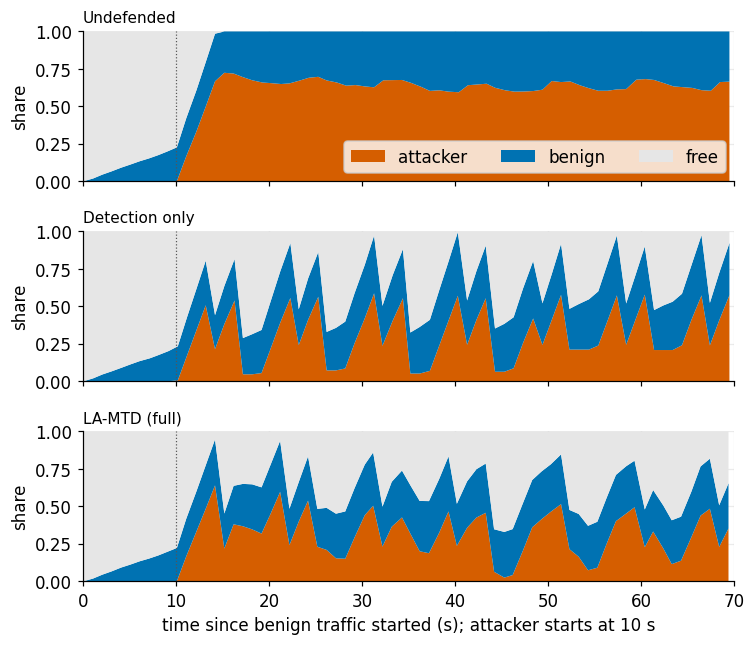

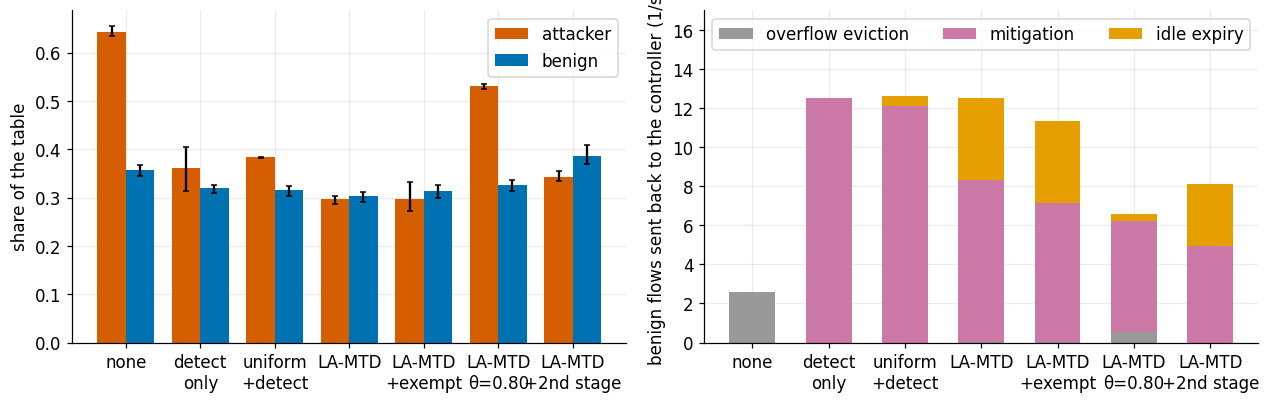

   1000 rules:     2.79 ms per epoch  (2.79 µs per rule)
   2000 rules:     2.97 ms per epoch  (1.48 µs per rule)
   5000 rules:     6.62 ms per epoch  (1.32 µs per rule)
  10000 rules:    12.84 ms per epoch  (1.28 µs per rule)
  20000 rules:    27.77 ms per epoch  (1.39 µs per rule)
  50000 rules:    75.13 ms per epoch  (1.50 µs per rule)
 100000 rules:   203.82 ms per epoch  (2.04 µs per rule)



In [ ]:
# Appendix D, step 3: the testbed results (Open vSwitch 3.3, Ryu 4.34, Mininet 2.3; Table XVI of the paper)
#
# The testbed needs root, Mininet, Open vSwitch and Ryu 4.34 in a Python 3.9 environment with
# eventlet 0.30.2, which Colab does not provide.  By default this cell shows the runs we made
# (the numbers below are copied from ryu_la_mtd/runs/summary.json).  On a Linux machine with all
# of these installed, set RUN_TESTBED = True to repeat every run (about 45 minutes) and analyse it here.
import json
import os
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_TESTBED = False

FIELDS = ['name', 'seed', 'occ_mean', 'occ_peak', 'atk_share', 'ben_share', 'ben_back_evict', 'ben_back_mitig', 'ben_back_idle', 'prec', 'rec', 'f1', 'fpr', 'cpu_frac', 'packet_in_per_s', 'ben_pin_per_s', 'tablefull_err_per_s', 'proc_ms_mean', 'proc_ms_p95', 'stats_rtt_ms_mean', 'p2s', 's2_atk_checked', 's2_atk_cleared', 's2_ben_checked', 's2_ben_cleared', 's2_ms_mean']
RUNS = [
    ('none', 1, 1, 1, 0.6392, 0.3608, 155.5, 0, 0, None, None, None, None, 0.2199, 253.5, None, None, 5.325, 7.963, 128.7, 0.1, None, None, None, None, None),
    ('none', 2, 1, 1, 0.6336, 0.3664, 165.3, 0, 0, None, None, None, None, 0.2187, 253.4, None, None, 5.531, 5.915, 122.5, 0.1, None, None, None, None, None),
    ('none', 3, 1, 1, 0.6549, 0.3451, 143.3, 0, 0, None, None, None, None, 0.2232, 250, None, None, 5.684, 6.383, 129.4, 0.1, None, None, None, None, None),
    ('detect', 1, 0.638, 0.9944, 0.3129, 0.3251, 0, 710.2, 0, 0.7509, 0.8513, 0.798, 0.2718, 0.2171, 261.8, None, None, 18.18, 77.14, 84.07, 0.1, None, None, None, None, None),
    ('detect', 2, 0.6905, 0.9861, 0.3649, 0.3255, 0, 858.4, 0, 0.7888, 0.8717, 0.8282, 0.2616, 0.2239, 263.6, None, None, 15.5, 61.11, 88.11, 0.1, None, None, None, None, None),
    ('detect', 3, 0.7147, 0.9628, 0.4055, 0.3093, 0, 685.7, 0, 0.8139, 0.8855, 0.8482, 0.2654, 0.227, 258.3, None, None, 17.44, 60.22, 90.59, 0.1, None, None, None, None, None),
    ('uniform', 1, 0.7034, 0.9094, 0.3846, 0.3188, 0, 715.1, 28.16, 0.8054, 0.8865, 0.844, 0.2584, 0.2296, 262.2, None, None, 22.91, 53.78, 93.32, 0.1, None, None, None, None, None),
    ('uniform', 2, 0.7069, 0.9033, 0.3822, 0.3248, 0, 798.4, 30.61, 0.7989, 0.8808, 0.8378, 0.2609, 0.2351, 263.2, None, None, 16.54, 56.59, 88.19, 0.1, None, None, None, None, None),
    ('uniform', 3, 0.6865, 0.8883, 0.3823, 0.3042, 0, 664.9, 34.29, 0.8139, 0.8819, 0.8466, 0.2533, 0.239, 258.4, None, None, 15.28, 51.43, 90.9, 0.1, None, None, None, None, None),
    ('full', 1, 0.6108, 0.9378, 0.3039, 0.307, 0, 467.8, 251, 0.784, 0.8499, 0.8156, 0.2318, 0.2316, 261.8, None, None, 11.79, 51.6, 79.02, 0.6635, None, None, None, None, None),
    ('full', 2, 0.5972, 0.8378, 0.2866, 0.3107, 2.449, 529, 292.7, 0.7732, 0.8415, 0.8059, 0.2277, 0.2359, 263.6, None, None, 11.29, 46.4, 77.27, 0.6646, None, None, None, None, None),
    ('full', 3, 0.5918, 0.8322, 0.3011, 0.2907, 0, 502, 209.4, 0.799, 0.8514, 0.8244, 0.2217, 0.2348, 257.8, None, None, 11.68, 45.41, 78.95, 0.6842, None, None, None, None, None),
    ('fullx', 1, 0.6572, 1, 0.3318, 0.3254, 8.571, 361.2, 241.2, 0.76, 0.8597, 0.8068, 0.2768, 0.227, 257.1, None, None, 10.88, 46.01, 82.81, 0.6448, None, None, None, None, None),
    ('fullx', 2, 0.601, 0.85, 0.2866, 0.3143, 0, 486.1, 313.5, 0.7615, 0.8453, 0.8012, 0.2415, 0.238, 261.8, None, None, 11.89, 47.85, 78.3, 0.6761, None, None, None, None, None),
    ('fullx', 3, 0.5721, 0.8589, 0.2728, 0.2994, 0, 424.9, 204.5, 0.7549, 0.8292, 0.7903, 0.2453, 0.2283, 256.6, None, None, 12.96, 50.67, 73.18, 0.583, None, None, None, None, None),
    ('full_t80', 1, 0.8525, 1, 0.5246, 0.3279, 35.51, 341.6, 15.92, 0.7853, 0.2212, 0.3451, 0.09671, 0.2404, 257.7, 53.2, 0, 20.54, 50.21, 105, 0.0349, None, None, None, None, None),
    ('full_t80', 2, 0.8708, 1, 0.5339, 0.3369, 36.73, 368.6, 24.49, 0.7861, 0.2359, 0.3629, 0.1017, 0.2471, 258.1, 53.2, 0, 19.24, 37.82, 109.3, 0.0373, None, None, None, None, None),
    ('full_t80', 3, 0.8487, 1, 0.5349, 0.3138, 20.82, 317.1, 24.49, 0.8065, 0.236, 0.3652, 0.09652, 0.2455, 254.3, 49.04, 0, 17.8, 35.98, 111.3, 0.0313, None, None, None, None, None),
    ('full_2st', 1, 0.7387, 0.9956, 0.3557, 0.383, 0, 216.7, 220.4, 0.6805, 0.897, 0.7739, 0.391, 0.2702, 244.9, 71.76, 0, 49.67, 166.5, 124.4, 0.6367, 7604, 2785, 2879, 2504, 124.2),
    ('full_2st', 2, 0.7426, 0.9089, 0.3348, 0.4078, 0, 347.8, 222.9, 0.6305, 0.8752, 0.733, 0.4211, 0.2669, 246.8, 55.43, 0, 21.95, 60.88, 114.6, 0.6626, 11279, 5480, 5462, 4969, 19.34),
    ('full_2st', 3, 0.7036, 0.8961, 0.3345, 0.3691, 0, 323.3, 126.1, 0.6664, 0.8722, 0.7555, 0.3957, 0.2668, 245.9, 51.39, 0, 27.72, 99.17, 111.8, 0.6609, 12413, 6195, 4813, 4338, 28.06),
    ('none_refuse', 1, 0.9996, 1, 0.7314, 0.2682, 8776, 0, 2.449, None, None, None, None, 0.5924, 436.4, 2394, 410, 4.883, 6.062, 134.2, 0.1, None, None, None, None, None),
    ('none_refuse', 2, 0.9996, 1, 0.7269, 0.2727, 8811, 0, 7.347, None, None, None, None, 0.6018, 440.1, 2426, 413.7, 5.719, 6.939, 135.5, 0.1, None, None, None, None, None),
    ('none_refuse', 3, 0.9995, 1, 0.7401, 0.2595, 8289, 0, 12.24, None, None, None, None, 0.579, 412.3, 2244, 387.1, 6.189, 7.492, 132.2, 0.1, None, None, None, None, None),
    ('full_refuse', 1, 0.6146, 0.8461, 0.3092, 0.3054, 0, 460.4, 296.3, 0.792, 0.8521, 0.8209, 0.2266, 0.2322, 261.7, 56.14, 0, 11.74, 51.02, 78.49, 0.6705, None, None, None, None, None),
    ('full_refuse', 2, 0.5977, 0.8733, 0.2895, 0.3083, 0, 521.6, 291.4, 0.7796, 0.8416, 0.8094, 0.2234, 0.2276, 262.5, 56.12, 0, 12.26, 50.65, 76.05, 0.6525, None, None, None, None, None),
    ('full_refuse', 3, 0.592, 0.9244, 0.3018, 0.2902, 0, 407.8, 289, 0.8005, 0.8497, 0.8244, 0.2202, 0.2366, 257.3, 52.16, 0, 11.02, 44.97, 79.61, 0.6871, None, None, None, None, None),
    ('none_noatk', 1, 0.4587, 0.5039, 0, 0.4587, 0, 0, 29.39, None, None, None, None, 0.101, 41.37, None, None, 1.821, 2.457, 58.94, 0.1, None, None, None, None, None),
    ('none_noatk', 2, 0.4691, 0.495, 0, 0.4691, 0, 0, 26.94, None, None, None, None, 0.1005, 41.16, None, None, 1.943, 2.755, 60.8, 0.1, None, None, None, None, None),
    ('full_noatk', 1, 0.4799, 0.5189, 0, 0.4799, 0, 0, 96.73, None, None, None, 0.5138, 0.1053, 42.49, None, None, 3.323, 4.828, 60.47, 0.1, None, None, None, None, None),
    ('full_noatk', 2, 0.4882, 0.5161, 0, 0.4882, 0, 0, 82.04, None, None, None, 0.5182, 0.1074, 42.08, None, None, 3.292, 3.989, 61.79, 0.1, None, None, None, None, None),
]
SERIES = {"none":{"t":[0.1,1.1,2.1,3.1,4.1,5.1,6.1,7.1,8.1,9.1,10.1,11.1,12.2,13.2,14.2,15.2,16.2,17.2,18.2,19.3,20.2,21.3,22.2,23.3,24.3,25.3,26.2,27.3,28.3,29.3,30.3,31.3,32.3,33.3,34.3,35.3,36.4,37.3,38.3,39.3,40.4,41.4,42.4,43.4,44.3,45.4,46.4,47.4,48.4,49.4,50.4,51.4,52.4,53.5,54.4,55.4,56.4,57.4,58.4,59.5,60.5,61.4,62.5,63.5,64.5,65.5,66.5,67.5,68.5,69.5],"atk":[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.165,0.332,0.498,0.667,0.724,0.719,0.695,0.674,0.659,0.655,0.649,0.653,0.672,0.691,0.697,0.673,0.659,0.638,0.642,0.633,0.627,0.674,0.675,0.676,0.656,0.629,0.603,0.607,0.598,0.594,0.641,0.646,0.651,0.624,0.607,0.598,0.599,0.602,0.611,0.669,0.662,0.666,0.639,0.621,0.604,0.604,0.613,0.615,0.678,0.682,0.676,0.654,0.633,0.628,0.623,0.608,0.604,0.662,0.665],"ben":[0.0,0.018,0.044,0.066,0.09,0.111,0.133,0.152,0.174,0.199,0.226,0.254,0.275,0.297,0.318,0.276,0.281,0.305,0.326,0.341,0.345,0.351,0.347,0.328,0.309,0.303,0.327,0.341,0.362,0.358,0.367,0.373,0.326,0.325,0.324,0.344,0.371,0.397,0.393,0.402,0.406,0.359,0.354,0.349,0.376,0.393,0.402,0.401,0.398,0.389,0.331,0.338,0.334,0.361,0.379,0.396,0.396,0.387,0.385,0.322,0.318,0.324,0.346,0.367,0.372,0.377,0.392,0.396,0.338,0.335]},"detect":{"t":[0.1,1.1,2.1,3.1,4.2,5.1,6.1,7.2,8.1,9.2,10.2,11.2,12.2,13.2,14.2,15.2,16.3,17.2,18.2,19.2,20.2,21.2,22.3,23.2,24.2,25.3,26.2,27.2,28.2,29.2,30.3,31.3,32.2,33.3,34.4,35.2,36.2,37.3,38.3,39.3,40.3,41.3,42.3,43.3,44.3,45.3,46.3,47.3,48.4,49.4,50.4,51.4,52.3,53.3,54.4,55.4,56.4,57.4,58.4,59.4,60.4,61.4,62.4,63.4,64.4,65.4,66.5,67.4,68.4,69.5],"atk":[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005,0.173,0.34,0.507,0.214,0.381,0.539,0.046,0.046,0.054,0.221,0.389,0.556,0.241,0.409,0.564,0.072,0.072,0.085,0.253,0.42,0.587,0.236,0.404,0.554,0.051,0.051,0.069,0.237,0.404,0.571,0.243,0.409,0.554,0.063,0.063,0.086,0.253,0.419,0.242,0.409,0.577,0.211,0.211,0.211,0.238,0.404,0.573,0.243,0.411,0.578,0.208,0.208,0.208,0.24,0.407,0.573,0.239,0.406,0.574],"ben":[0.0,0.019,0.045,0.066,0.091,0.112,0.134,0.153,0.174,0.201,0.228,0.256,0.276,0.298,0.227,0.254,0.277,0.242,0.268,0.288,0.316,0.342,0.367,0.239,0.276,0.299,0.257,0.284,0.313,0.334,0.357,0.386,0.267,0.304,0.328,0.274,0.311,0.341,0.37,0.395,0.424,0.296,0.326,0.351,0.289,0.32,0.341,0.364,0.384,0.278,0.306,0.341,0.272,0.304,0.336,0.362,0.382,0.4,0.276,0.297,0.322,0.267,0.298,0.323,0.344,0.364,0.403,0.284,0.316,0.349]},"full":{"t":[0.1,1.1,2.1,3.1,4.1,5.1,6.1,7.1,8.1,9.1,10.1,11.1,12.2,13.2,14.2,15.2,16.2,17.2,18.2,19.2,20.2,21.2,22.2,23.2,24.2,25.2,26.2,27.2,28.2,29.2,30.3,31.2,32.2,33.2,34.3,35.2,36.2,37.2,38.3,39.3,40.2,41.3,42.3,43.3,44.2,45.3,46.2,47.3,48.3,49.3,50.3,51.4,52.3,53.3,54.3,55.3,56.3,57.3,58.4,59.3,60.4,61.3,62.4,63.3,64.3,65.4,66.4,67.4,68.4,69.4],"atk":[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.165,0.332,0.484,0.64,0.218,0.38,0.367,0.346,0.318,0.454,0.597,0.241,0.398,0.538,0.23,0.209,0.153,0.15,0.292,0.441,0.504,0.231,0.364,0.426,0.318,0.2,0.187,0.324,0.466,0.236,0.357,0.425,0.457,0.063,0.024,0.041,0.204,0.36,0.414,0.464,0.515,0.214,0.163,0.073,0.09,0.25,0.401,0.452,0.494,0.227,0.332,0.218,0.114,0.137,0.293,0.438,0.484,0.229,0.352],"ben":[0.0,0.018,0.044,0.066,0.091,0.111,0.133,0.151,0.172,0.197,0.222,0.251,0.268,0.29,0.307,0.234,0.257,0.283,0.301,0.309,0.328,0.341,0.243,0.264,0.296,0.253,0.281,0.298,0.316,0.329,0.338,0.356,0.267,0.3,0.313,0.323,0.336,0.348,0.359,0.368,0.281,0.31,0.323,0.329,0.284,0.305,0.307,0.317,0.316,0.319,0.317,0.332,0.262,0.286,0.297,0.307,0.307,0.309,0.316,0.311,0.252,0.277,0.287,0.293,0.294,0.304,0.329,0.334,0.278,0.302]}}   # one run (seed 1) of three configurations: time, attacker and benign share of the table
CHECKS = {"C1_peak_no_attacker":{"full_noatk_s1":0.5189,"full_noatk_s2":0.5161,"none_noatk_s1":0.5039,"none_noatk_s2":0.495},"C4_seconds_to_95pct":{"none_refuse_s1":4.19,"none_refuse_s2":4.25,"none_refuse_s3":4.21,"none_s1":4.21,"none_s2":4.19,"none_s3":4.15},"C6":{"epochs":1326,"sum_violations":0,"floor_a":1.2664,"min_Ha":1.2667,"floor_violations_a":0,"floor_b":1.2085,"min_Hb":1.2088,"floor_violations_b":0},"C9":{"removals":353584,"duplicates":0,"late_for_written_off_rule":135}}   # Table IV invariants repeated on the switch (validity_testbed.py)

if RUN_TESTBED:
    assert os.geteuid() == 0, "run the notebook as root: Mininet needs it"
    for tool in ("mn", "ovs-vsctl", os.environ.get("RYU_MANAGER", "ryu-manager")):
        assert shutil.which(tool), f"{tool} not found"
    assert os.path.exists("ryu_la_mtd/second_stage.joblib"), "run Appendix E, part 3 first: it writes the second stage"
    subprocess.run(["bash", "run_all.sh"], cwd="ryu_la_mtd", check=True)
    subprocess.run(["python3", "analyze_testbed.py"], cwd="ryu_la_mtd", check=True)
    subprocess.run(["python3", "validity_testbed.py"], cwd="ryu_la_mtd", check=True, capture_output=True)
    v = json.load(open("ryu_la_mtd/runs/validity.json"))
    CHECKS = {"C1_peak_no_attacker": v["C1_peak_no_attacker"],
              "C4_seconds_to_95pct": {k: round(x["t_to_95"], 2) for k, x in v["C4_undefended"].items()},
              "C6": v["C6"], "C9": v["C9"]}
    rows = json.load(open("ryu_la_mtd/runs/summary.json"))
    for r in rows:
        r["p2s"] = r["peff_a_final"][0] if r.get("peff_a_final") else None
    tb = pd.DataFrame([{k: r.get(k) for k in FIELDS} for r in rows])
    SERIES = {n: {"t": [x[0] for x in r["series"]], "atk": [x[2] for x in r["series"]], "ben": [x[3] for x in r["series"]]}
              for r in rows for n in ("none", "detect", "full") if r["name"] == n and r["seed"] == 1}
else:
    tb = pd.DataFrame(RUNS, columns=FIELDS)

LABEL = {"none": "Undefended", "detect": "Detection only", "uniform": "Uniform + detection",
         "full": "LA-MTD (full)", "fullx": "LA-MTD + quick-return exemption", "full_t80": "LA-MTD, θ = 0.80",
         "full_2st": "LA-MTD + second stage at mitigation",
         "none_refuse": "Undefended, refuse-on-full switch", "full_refuse": "LA-MTD, refuse-on-full switch",
         "none_noatk": "Undefended, no attacker", "full_noatk": "LA-MTD, no attacker"}
for k in ("ben_back_evict", "ben_back_mitig", "ben_back_idle"):
    tb[k] = tb[k] / 60.0                                            # per minute -> per second
# a switch that refuses new rules never installs the benign flow, so "sent back" does not apply there
tb.loc[tb.name == "none_refuse", ["ben_back_evict", "ben_back_mitig", "ben_back_idle"]] = np.nan
tb["ben_back"] = tb[["ben_back_evict", "ben_back_mitig", "ben_back_idle"]].sum(axis=1, min_count=1)
# LA-A only learns when it sets the timeouts
tb.loc[~tb.name.isin(["full", "fullx", "full_t80", "full_2st", "full_refuse", "full_noatk"]), "p2s"] = np.nan
# the second stage runs only when mitigation acts, so its verdicts are not scored per epoch
tb.loc[tb.name == "full_2st", ["f1", "fpr"]] = np.nan
mean = tb.groupby("name", sort=False).mean(numeric_only=True)
table = pd.DataFrame({
    "seeds": tb.groupby("name", sort=False).size(),
    "mean occ.": mean.occ_mean, "peak occ.": mean.occ_peak,
    "attacker share": mean.atk_share, "benign share": mean.ben_share,
    "benign back (1/s)": mean.ben_back, "via mitigation": mean.ben_back_mitig, "via idle": mean.ben_back_idle,
    "F1": mean.f1, "FPR": mean.fpr, "CPU (% core)": 100 * mean.cpu_frac,
    "packet-ins/s": mean.packet_in_per_s, "LA-A p(2 s)": mean.p2s,
}).rename(index=LABEL)
pd.set_option("display.width", 200)
print(table.round(3).to_string())
print()
print("Without an attacker every flag is a false positive (mostly rules of finished flows waiting for their idle")
print("timeout), but occupancy never reaches a threshold, so mitigation never acts on them.")
print()
for n in ("none_refuse", "full_refuse"):
    print(f"{LABEL[n]}: {mean.loc[n, 'ben_pin_per_s']:.0f} benign packets/s through the controller, "
          f"{mean.loc[n, 'tablefull_err_per_s']:.0f} rejected rule installs/s")
print("full defence on the switch: epoch processing %.1f ms mean, %.1f ms p95; stats reply after %.0f ms"
      % (mean.loc["full", "proc_ms_mean"], mean.loc["full", "proc_ms_p95"], mean.loc["full", "stats_rtt_ms_mean"]))
s2 = tb[tb.name == "full_2st"][["s2_ben_checked", "s2_ben_cleared", "s2_atk_checked", "s2_atk_cleared"]].sum()
print("second stage: spared %.1f%% of the benign flagged rules it examined and %.1f%% of the attacker's"
      % (100 * s2.s2_ben_cleared / s2.s2_ben_checked, 100 * s2.s2_atk_cleared / s2.s2_atk_checked))
print()
print("Checks of Table IV repeated on the switch:")
print("  C1 peak occupancy with no attacker:", CHECKS["C1_peak_no_attacker"])
print("  C4 seconds from attack start to 95% occupancy, undefended:", CHECKS["C4_seconds_to_95pct"])
c6 = CHECKS["C6"]
print(f"  C6 {c6['epochs']} epochs: sum violations {c6['sum_violations']}, lowest entropy LA-A {c6['min_Ha']} "
      f"(floor {c6['floor_a']:.4f}), LA-B {c6['min_Hb']} (floor {c6['floor_b']:.4f})")
c9 = CHECKS["C9"]
print(f"  C9 {c9['removals']} rule removals, {c9['duplicates']} duplicates, "
      f"{c9['late_for_written_off_rule']} late for a rule already written off")

# the flow table over time (Fig. 40 of the paper)
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
for ax, n in zip(axes, ("none", "detect", "full")):
    t, atk, ben = (np.array(SERIES[n][k]) for k in ("t", "atk", "ben"))
    ax.stackplot(t, atk, ben, np.clip(1 - atk - ben, 0, 1), colors=["#D55E00", "#0072B2", "#e6e6e6"],
                 labels=["attacker", "benign", "free"])
    ax.axvline(10, color="#555555", lw=0.8, ls=":")
    ax.set_ylim(0, 1); ax.set_xlim(0, 70); ax.set_ylabel("share"); ax.set_title(LABEL[n], loc="left", fontsize=10)
axes[0].legend(loc="lower right", ncol=3)
axes[-1].set_xlabel("time since benign traffic started (s); attacker starts at 10 s")
plt.tight_layout(); plt.show()

# shares and the benign flows sent back to the controller, by cause (Fig. 41)
order = ["none", "detect", "uniform", "full", "fullx", "full_t80", "full_2st"]
x = np.arange(len(order))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = tb.groupby("name")
for j, (k, c, lab) in enumerate([("atk_share", "#D55E00", "attacker"), ("ben_share", "#0072B2", "benign")]):
    m, lo, hi = (g[k].agg(f).reindex(order).values for f in ("mean", "min", "max"))
    axes[0].bar(x + (j - 0.5) * 0.38, m, 0.38, color=c, label=lab, yerr=[m - lo, hi - m], capsize=2)
axes[0].set_ylabel("share of the table"); axes[0].legend()
bottom = np.zeros(len(order))
for k, c, lab in [("ben_back_evict", "#999999", "overflow eviction"), ("ben_back_mitig", "#CC79A7", "mitigation"),
                  ("ben_back_idle", "#E69F00", "idle expiry")]:
    m = g[k].mean().reindex(order).values
    axes[1].bar(x, m, 0.6, bottom=bottom, color=c, label=lab); bottom += m
axes[1].set_ylabel("benign flows sent back to the controller (1/s)")
axes[1].set_ylim(0, 17); axes[1].legend(loc="upper center", ncol=3)
SHORT = {"none": "none", "detect": "detect\nonly", "uniform": "uniform\n+detect", "full": "LA-MTD",
         "fullx": "LA-MTD\n+exempt", "full_t80": "LA-MTD\nθ=0.80", "full_2st": "LA-MTD\n+2nd stage"}
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels([SHORT[n] for n in order])
plt.tight_layout(); plt.show()

# controller cost per epoch as the table grows: this part runs anywhere, Colab included
out = subprocess.run(["python3", "bench_scale.py"], cwd="ryu_la_mtd", capture_output=True, text=True)
print(out.stdout or out.stderr)


## Appendix E. Head-to-head detectors, and the control for learning

*Two experiments added after review. Both run in Colab.*

**Part 1: LA-DETECT against heavier detectors on the same data.** Every detector in §20 is ours. Here LA-DETECT meets re-implementations of the two approaches it is positioned against, trained and scored on the same labelled flow sequences and the same three features:

* a **FloRa-style** detector: gradient-boosted trees on the rule's flow-table statistics at the current epoch, including its mean forwarding since installation;
* a **GRU–CatBoost-style** detector: the published recurrent part (two GRU layers, 64 and 32 units) reads the flow's sequence, and gradient-boosted trees decide on the hidden state together with the current features.

scikit-learn's histogram gradient boosting stands in for CatBoost. Thresholds are chosen on the training split. A third set of sequences, recorded under the adaptive attackers A2–A4 with policies T3 and H2, is unseen by all of them. The cell also times one epoch of each detector for a full table and traces LA-DETECT's operating curve over θ.

**Part 2: is the automaton's lower cost due to learning, or to its action set?** T1 draws from a continuous range; T3 draws from ten discrete values. Running T3 with its learning rate set to zero separates the two effects.

**Part 3: a second stage at mitigation time.** LA-DETECT's false positives are its main cost on the switch. Boosted trees re-check the rules it flags, but only when mitigation is about to act, so their cost stays out of ordinary epochs. They see only what a switch can observe. The cell trains them, scores the two stages together on the validation and unseen splits, and saves the model for the Ryu application (Appendix D shows what it did on the switch).


recorded 93790 sequences in 9 s


LA-DETECT (learned)                           val BA 0.909 F1 0.949 FPR 0.182 | unseen BA 0.905 F1 0.942 FPR 0.189 | AUC 0.956 params 5
fixed rule                                    val BA 0.762 F1 0.735 FPR 0.086 | unseen BA 0.829 F1 0.832 FPR 0.102 | AUC nan params -
FloRa-style boosted trees                     val BA 0.940 F1 0.961 FPR 0.096 | unseen BA 0.945 F1 0.962 FPR 0.093 | AUC 0.986 params 18300
GRU-CatBoost-style (GRU + boosted trees)      val BA 0.939 F1 0.959 FPR 0.097 | unseen BA 0.939 F1 0.956 FPR 0.094 | AUC 0.985 params 22689
cost (ms/epoch, 1800 rules): {'LA-DETECT (learned)': 0.039, 'FloRa-style boosted trees': 10.291, 'GRU-CatBoost-style (GRU + boosted trees)': 15.748}
LA-DETECT operating points: [(0.55, 0.248, 1.0), (0.6, 0.207, 1.0), (0.65, 0.182, 1.0), (0.7, 0.149, 0.974), (0.75, 0.123, 0.947), (0.8, 0.073, 0.821), (0.85, 0.012, 0.256), (0.9, 0.003, 0.17)]
total 187 s


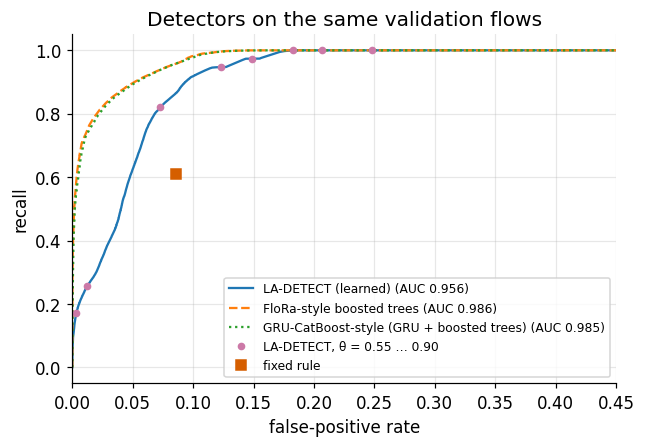

In [ ]:
# Appendix E, part 1
"""Head-to-head detectors on the same labelled flow sequences.

LA-DETECT (learned, 5 parameters) against re-implementations, on our data and
our three features, of the two published approaches it is compared with:
  * a FloRa-style detector: gradient-boosted trees on the rule's flow-table
    statistics at the current epoch, including its mean forwarding since
    installation (no recurrent memory);
  * a GRU-CatBoost-style detector: a two-layer GRU (64 and 32 units) reads the
    flow's sequence, and gradient-boosted trees decide on [h_t, x_t].
Gradient boosting here is scikit-learn's HistGradientBoostingClassifier, used
in place of CatBoost.  Every detector decides at every epoch using only that
flow's observations up to that epoch, and every decision is scored.
Thresholds are chosen on the training split (maximum balanced accuracy).
"""
import contextlib
import io
import json
import math
import os
import pickle
import time

import numpy as np

W = (LEARNED["la_w_low"], LEARNED["la_w_reg"], LEARNED["la_w_age"])
G, TH = LEARNED["la_gate"], LEARNED["la_theta"]

# ------------------------------------------------------------------ data --
TRAIN_SEEDS, VAL_SEEDS, TEST_SEEDS = [900_001, 900_002, 900_003], [900_011, 900_012], [900_021, 900_022]
TRAIN_CFGS = [CFGS.merged({"timeout": {"policy": p}, "threshold": {"policy": "H0"},
                           "attacker": {"kind": "A1", "rate_pps": 300, "target_entries": CFG.sim.capacity}})
              for p in ("T0", "T1")]
TEST_CFGS = [CFGS.merged({"timeout": {"policy": "T3"}, "threshold": {"policy": "H2"},
                          "attacker": {"kind": k, "rate_pps": 300, "target_entries": CFG.sim.capacity}})
             for k in ("A2", "A3", "A4")]
t0 = time.time()
tr = pmap(collect_trace, [(c, s) for c in TRAIN_CFGS for s in TRAIN_SEEDS])
va = pmap(collect_trace, [(c, s) for c in TRAIN_CFGS for s in VAL_SEEDS])
te = pmap(collect_trace, [(c, s) for c in TEST_CFGS for s in TEST_SEEDS])
D = {"train": to_sequences(tr), "val": to_sequences(va), "unseen": to_sequences(te)}
print(f"recorded {sum(len(v[2]) for v in D.values())} sequences in {time.time() - t0:.0f} s")


def compact(X, M):
    """Left-align each flow's observed epochs: X [n, L, 3], lengths [n]."""
    L = M.sum(1)
    Xc = np.zeros((len(L), int(L.max()), 3))
    for i in range(len(L)):
        Xc[i, :L[i]] = X[i, M[i]]
    return Xc, L


C = {k: compact(v[0], v[1]) + (v[2],) for k, v in D.items()}          # (Xc, L, y)


def flat(k, arr):
    """Per flow-epoch rows of a per-step array [n, Lmax, ...]."""
    Xc, L, y = C[k]
    m = np.arange(Xc.shape[1])[None, :] < L[:, None]
    return arr[m], np.repeat(y, L)


# ------------------------------------------------------------- detectors --
def la_scores(k):
    Xc, L, y = C[k]
    beta = evidence_score(Xc.reshape(-1, 3), W).reshape(Xc.shape[:2])
    p = np.full(len(L), 0.5)
    out = np.zeros(Xc.shape[:2])
    for t in range(Xc.shape[1]):
        m = t < L
        p = np.where(m, p + G * (beta[:, t] - p), p)
        out[:, t] = p
    return flat(k, out)


def rule_scores(k):                        # fixed rule: rate < 2 pps and age > 3 s
    Xc, L, y = C[k]
    s = ((Xc[..., 0] > 1 - 2 / 15.0) & (Xc[..., 2] > 3 / 30.0)).astype(float)
    return flat(k, s)


def stat_features(k):                      # flow-table statistics at epoch t, FloRa-style
    Xc, L, y = C[k]
    fwd = 1.0 - Xc[..., 0]
    n = np.arange(1, Xc.shape[1] + 1)[None, :]
    cum = np.cumsum(fwd, 1) / n
    F = np.concatenate([Xc, cum[..., None], (n / 60.0)[..., None].repeat(len(L), 0)], -1)
    return flat(k, F)


def best_threshold(s, y):
    qs = np.unique(np.quantile(s, np.linspace(0, 1, 401)))
    ba = [0.5 * (np.mean(s[y == 1] > q) + np.mean(s[y == 0] <= q)) for q in qs]
    return float(qs[int(np.argmax(ba))])


def metrics(s, y, thr):
    pred = s > thr
    yb = y.astype(bool)
    tp = int(np.sum(pred & yb)); fp = int(np.sum(pred & ~yb)); fn = int(np.sum(~pred & yb)); tn = int(np.sum(~pred & ~yb))
    return detection_metrics(tp, fp, fn, tn)


from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import torch

torch.manual_seed(0)
torch.set_num_threads(2)
res, curves, cost = {}, {}, {}

# LA-DETECT and the fixed rule
for name, fn_ in [("LA-DETECT (learned)", la_scores), ("fixed rule", rule_scores)]:
    s_tr, y_tr = fn_("train")
    thr = TH if name.startswith("LA") else 0.5
    res[name] = {k: metrics(*fn_(k), thr) for k in ("train", "val", "unseen")}
    if name.startswith("LA"):
        s, y = fn_("val")
        res[name]["auc"] = float(roc_auc_score(y, s)); curves[name] = roc_curve(y, s)[:2]
        res[name]["params"] = 5

# FloRa-style gradient boosting
t1 = time.time()
Ftr, ytr_ = stat_features("train")
gb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
                                    class_weight="balanced", random_state=0).fit(Ftr, ytr_)
thr = best_threshold(gb.predict_proba(Ftr)[:, 1], ytr_)
name = "FloRa-style boosted trees"
res[name] = {k: metrics(gb.predict_proba(stat_features(k)[0])[:, 1], stat_features(k)[1], thr)
             for k in ("train", "val", "unseen")}
Fva, yva_ = stat_features("val")
sv = gb.predict_proba(Fva)[:, 1]
res[name]["auc"] = float(roc_auc_score(yva_, sv)); curves[name] = roc_curve(yva_, sv)[:2]
res[name]["train_s"] = time.time() - t1
res[name]["params"] = int(sum(len(p.nodes) for est in gb._predictors for p in est)) * 1


# GRU-CatBoost-style: GRU (64, 32) + boosted trees on [h_t, x_t]
class GRUNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.g1 = torch.nn.GRU(3, 64, batch_first=True)
        self.g2 = torch.nn.GRU(64, 32, batch_first=True)
        self.head = torch.nn.Linear(32, 1)

    def forward(self, x):
        h1, _ = self.g1(x)
        h2, _ = self.g2(h1)
        return self.head(h2).squeeze(-1), h2


t1 = time.time()
net = GRUNet()
opt = torch.optim.Adam(net.parameters(), lr=2e-3)
Xc, L, y = C["train"]
Xt = torch.tensor(Xc, dtype=torch.float32)
mask = torch.tensor(np.arange(Xc.shape[1])[None, :] < L[:, None])
yt = torch.tensor(y, dtype=torch.float32)[:, None].expand(-1, Xc.shape[1])
pos_w = torch.tensor((1 - y.mean()) / y.mean())
rng = np.random.default_rng(0)
for ep in range(8):
    order = rng.permutation(len(L))
    for b in range(0, len(L), 256):
        idx = order[b:b + 256]
        lmax = int(L[idx].max())
        logit, _ = net(Xt[idx, :lmax])
        m = mask[idx, :lmax]
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logit[m], yt[idx, :lmax][m], pos_weight=pos_w)
        opt.zero_grad(); loss.backward(); opt.step()


def gru_feats(k):
    Xc, L, y = C[k]
    with torch.no_grad():
        _, h = net(torch.tensor(Xc, dtype=torch.float32))
    F = np.concatenate([h.numpy(), Xc], -1)
    return flat(k, F)


Htr, yh = gru_feats("train")
sub = np.random.default_rng(1).choice(len(yh), min(300_000, len(yh)), replace=False)
gb2 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
                                     class_weight="balanced", random_state=0).fit(Htr[sub], yh[sub])
thr = best_threshold(gb2.predict_proba(Htr[sub])[:, 1], yh[sub])
name = "GRU-CatBoost-style (GRU + boosted trees)"
res[name] = {k: metrics(gb2.predict_proba(gru_feats(k)[0])[:, 1], gru_feats(k)[1], thr)
             for k in ("train", "val", "unseen")}
Hva, yhv = gru_feats("val")
sv = gb2.predict_proba(Hva)[:, 1]
res[name]["auc"] = float(roc_auc_score(yhv, sv)); curves[name] = roc_curve(yhv, sv)[:2]
res[name]["train_s"] = time.time() - t1
res[name]["params"] = int(sum(p.numel() for p in net.parameters()))

# cost of one epoch for a full table of 1800 rules, one CPU thread
torch.set_num_threads(1)
x1 = np.random.default_rng(2).random((1800, 3))
reps = 50
tic = time.perf_counter()
p = np.full(1800, 0.5)
for _ in range(reps):
    b = evidence_score(x1, W); p = p + G * (b - p); _ = p > TH
cost["LA-DETECT (learned)"] = (time.perf_counter() - tic) / reps * 1e3
f1 = np.random.default_rng(3).random((1800, 5))
tic = time.perf_counter()
for _ in range(reps // 5):
    gb.predict_proba(f1)
cost["FloRa-style boosted trees"] = (time.perf_counter() - tic) / (reps // 5) * 1e3
cell1, cell2 = torch.nn.GRUCell(3, 64), torch.nn.GRUCell(64, 32)
h1, h2 = torch.zeros(1800, 64), torch.zeros(1800, 32)
xt = torch.tensor(x1, dtype=torch.float32)
f2 = np.random.default_rng(4).random((1800, 35))
tic = time.perf_counter()
with torch.no_grad():
    for _ in range(reps // 5):
        h1 = cell1(xt, h1); h2 = cell2(h1, h2); gb2.predict_proba(f2)
cost["GRU-CatBoost-style (GRU + boosted trees)"] = (time.perf_counter() - tic) / (reps // 5) * 1e3

# the operating curve of LA-DETECT: what a lower false-positive rate costs
s, yv = la_scores("val")
ops = []
for th in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    m_ = metrics(s, yv, th)
    ops.append({"theta": th, "fpr": m_["fpr"], "recall": m_["recall"], "precision": m_["precision"],
                "balanced_acc": m_["balanced_acc"]})

out = {"results": res, "cost_ms_per_epoch_1800_rules": cost, "la_operating_points": ops,
       "sizes": {k: {"sequences": int(len(v[2])), "flow_epochs": int(v[1].sum()),
                     "attacker_share": float(v[2].mean())} for k, v in D.items()},
       "curves": {k: [v[0][::max(1, len(v[0]) // 400)].tolist(), v[1][::max(1, len(v[1]) // 400)].tolist()]
                  for k, v in curves.items()}}
json.dump(out, open("h2h_results.json", "w"), indent=1, default=float)   # used by the paper's figure
for n, r in res.items():
    print(f"{n:45s} val BA {r['val']['balanced_acc']:.3f} F1 {r['val']['f1']:.3f} FPR {r['val']['fpr']:.3f} "
          f"| unseen BA {r['unseen']['balanced_acc']:.3f} F1 {r['unseen']['f1']:.3f} FPR {r['unseen']['fpr']:.3f}"
          f" | AUC {r.get('auc', float('nan')):.3f} params {r.get('params', '-')}")
print("cost (ms/epoch, 1800 rules):", {k: round(v, 3) for k, v in cost.items()})
print("LA-DETECT operating points:", [(o['theta'], round(o['fpr'], 3), round(o['recall'], 3)) for o in ops])
print(f"total {time.time() - t0:.0f} s")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4.2))
for (n, (fx, fy)), ls in zip(curves.items(), ["-", "--", ":"]):
    ax.plot(fx, fy, ls, label=f"{n} (AUC {res[n]['auc']:.3f})")
ax.plot([o["fpr"] for o in ops], [o["recall"] for o in ops], "o", color="#CC79A7", ms=4, label="LA-DETECT, θ = 0.55 … 0.90")
fr_ = res["fixed rule"]["val"]
ax.plot([fr_["fpr"]], [fr_["recall"]], "s", color="#D55E00", label="fixed rule")
ax.set_xlim(0, 0.45); ax.set_xlabel("false-positive rate"); ax.set_ylabel("recall")
ax.set_title("Detectors on the same validation flows"); ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# Appendix E, part 2
"""Is the automaton's lower cost due to learning, or to its discrete action set?

Adds the missing control to the security-cost experiment: T3 with its learning
switched off (a = 0), i.e. a uniform draw from the same ten candidates.  Same
attacker, detector, threshold and 32 seeds as the control experiment.
"""
import contextlib
import io
import json
import os
import time

import numpy as np

base = {"threshold": {"policy": "H0"}, "detection": {"detector": "simple"},
        "attacker": {"kind": "A1", "target_entries": CFG.sim.capacity}}
ARMS = {"T1 uniform (continuous)": {**base, "timeout": {"policy": "T1"}},
        "T3 without learning (a = 0)": {**base, "timeout": {"policy": "T3"}, "automaton": {"a": 0.0}},
        "T3 automata": {**base, "timeout": {"policy": "T3"}}}
t0 = time.time()
out = {}
for name, over in ARMS.items():
    st = arm_stats(over, CFGS)
    quiet = pmap(run_config, [(CFGS.merged(over), int(s), False) for s in SEEDS])
    pfin = np.array([q.la_a_p[-1] for q in quiet]) if quiet[0].la_a_p else None
    out[name] = {"min_attack_rate": st["min_attack_rate"], "ci95": st["ci95"],
                 "benign_expired": st["benign_expired"], "packet_ins_per_s": st["packet_ins_per_s"],
                 "per_seed_rate": st["per_seed_rate"].tolist(), "per_seed_expired": st["per_seed_expired"].tolist(),
                 "quiet_final_p": pfin.mean(0).round(4).tolist() if pfin is not None else None}
    print(f"{name:28s} rate {st['min_attack_rate']:.1f} ± {st['ci95']:.1f}  expired {st['benign_expired']:.0f}"
          f"  ({time.time() - t0:.0f} s)")


def paired(a, b):
    d = np.array(out[a]["per_seed_" + b[0]]) - np.array(out[b[1]]["per_seed_" + b[0]])
    m, ci = mean_ci95(d)
    return float(m), float(ci)


pairs = {}
for x, y in [("T3 automata", "T3 without learning (a = 0)"), ("T3 without learning (a = 0)", "T1 uniform (continuous)"),
             ("T3 automata", "T1 uniform (continuous)")]:
    pairs[f"{x} − {y}"] = {"expired": paired(x, ("expired", y)), "rate": paired(x, ("rate", y))}
out["paired"] = pairs
json.dump(out, open("ctrl2_results.json", "w"), indent=1)
for k, v in pairs.items():
    print(k, "expired %+.1f ± %.1f" % v["expired"], "rate %+.1f ± %.1f" % v["rate"])
print(f"total {time.time() - t0:.0f} s")


T1 uniform (continuous)      rate 273.2 ± 5.7  expired 3453  (68 s)


T3 without learning (a = 0)  rate 282.2 ± 3.7  expired 3472  (148 s)


T3 automata                  rate 268.9 ± 6.3  expired 3434  (230 s)
T3 automata − T3 without learning (a = 0) expired -37.9 ± 4.1 rate -13.3 ± 4.1
T3 without learning (a = 0) − T1 uniform (continuous) expired +19.3 ± 5.8 rate +8.9 ± 4.3
T3 automata − T1 uniform (continuous) expired -18.6 ± 4.5 rate -4.4 ± 3.7
total 230 s


In [ ]:
# Appendix E, part 3
"""A second stage at mitigation time: boosted trees re-check the rules LA-DETECT flags.

Only the rules LA-DETECT flags are examined, and on the switch only in epochs where
mitigation acts.  The trees see what a switch can observe (no gap regularity):
x_low, x_age, the rule's mean forwarding since installation and the epochs it has
been seen.  A flagged rule is evicted only if the trees agree.  Trained on the
flagged flow-epochs of the training split; threshold chosen there.  The model is
saved for the Ryu application (ryu_la_mtd/second_stage.joblib).  The copy used in
the paper was trained with scikit-learn 1.6.1; another version can change the last
digit of the numbers below.
"""
import time
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier


def observable_features(k):
    Xc, L, y = C[k]
    fwd = 1.0 - Xc[..., 0]
    n = np.arange(1, Xc.shape[1] + 1)[None, :].repeat(len(L), 0)
    cum = np.cumsum(fwd, 1) / n
    return flat(k, np.stack([Xc[..., 0], Xc[..., 2], cum, n / 60.0], -1))


F_tr, y_tr = observable_features("train")
p_tr, _ = la_scores("train")
flag_tr = p_tr > TH
gb2 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
                                     class_weight="balanced", random_state=0).fit(F_tr[flag_tr], y_tr[flag_tr])
s_tr = gb2.predict_proba(F_tr)[:, 1]
qs = np.unique(np.quantile(s_tr[flag_tr], np.linspace(0, 1, 401)))
ba = [metrics((flag_tr & (s_tr > q)).astype(float), y_tr, 0.5)["balanced_acc"] for q in qs]
thr2 = float(qs[int(np.argmax(ba))])

rows = []
for k in ("val", "unseen"):
    F, y = observable_features(k)
    p, _ = la_scores(k)
    flag = p > TH
    s2 = gb2.predict_proba(F)[:, 1]
    for name, pred in (("LA-DETECT", flag), ("LA-DETECT + trees at mitigation", flag & (s2 > thr2))):
        m_ = metrics(pred.astype(float), y, 0.5)
        rows.append((k, name, m_["balanced_acc"], m_["f1"], m_["fpr"], m_["recall"]))
    print(f"{k:7s} the trees clear {np.mean(s2[flag & (y == 0)] <= thr2):.1%} of the benign flags "
          f"and {np.mean(s2[flag & (y == 1)] <= thr2):.1%} of the attacker's")
import pandas as pd
print(pd.DataFrame(rows, columns=["split", "detector", "BA", "F1", "FPR", "recall"]).round(3).to_string(index=False))

x = np.random.default_rng(0).random((600, 4))
gb2.predict_proba(x)
tt = []
for _ in range(20):
    t = time.perf_counter(); gb2.predict_proba(x); tt.append(time.perf_counter() - t)
print(f"one call on 600 flagged rules: {np.median(tt) * 1e3:.1f} ms; threshold {thr2:.3f}")
joblib.dump({"model": gb2, "thr": thr2, "features": ["x_low", "x_age", "mean_fwd", "epochs/60"]},
            "ryu_la_mtd/second_stage.joblib")
print("saved ryu_la_mtd/second_stage.joblib for the Ryu application")


val     the trees clear 46.2% of the benign flags and 2.5% of the attacker's


unseen  the trees clear 49.6% of the benign flags and 1.4% of the attacker's
 split                        detector    BA    F1   FPR  recall
   val                       LA-DETECT 0.909 0.949 0.182   1.000
   val LA-DETECT + trees at mitigation 0.938 0.959 0.098   0.974
unseen                       LA-DETECT 0.905 0.942 0.189   1.000
unseen LA-DETECT + trees at mitigation 0.945 0.963 0.095   0.985
one call on 600 flagged rules: 4.5 ms; threshold 0.148
saved ryu_la_mtd/second_stage.joblib for the Ryu application
